# Predicción de la expansión de variantes de SARS-CoV-2 en la población mediante Aprendizaje Automático

**Trabajo de Fin de Máster** — Máster Universitario en Sistemas Interactivos Inteligentes
**Estudiante:** Sergio López González del Rey
**Director:** Manuel Sánchez-Montañés Isla
**Universidad Autónoma de Madrid** — 2025-26


## MÓDULO 0 — Configuración y librerías

Este módulo establece el entorno de ejecución, las rutas a los datos y las constantes globales que usarán todos los módulos posteriores.
Se organiza en cinco secciones: configuración de rutas, dependencias, importaciones, mapas de nomenclatura Nextclade y funciones auxiliares reutilizables.

> **Nota:** es la única sección que requiere ajuste manual si se cambia el entorno (Colab ↔ local) o la ubicación de los datos.

### 0.1 — Configuración de entorno

Detecta automáticamente si se ejecuta en **Google Colab** o en **local** (VS Code / Jupyter) y define las rutas `DATA_DIR`, `WORKDIR` y `OUTDIR`.
En Colab monta Google Drive; en local usa la carpeta `data/` junto al notebook.

In [1]:
# ═══════════════════════════════════════════════════════════════════════
# ⚙️  CONFIGURACIÓN — única celda que necesitas modificar
# ═══════════════════════════════════════════════════════════════════════
#
# Coloca los archivos de datos en una carpeta y ajusta DATA_DIR.
# Si usas Google Colab con Drive, no hace falta cambiar nada.
#
# Opción A (recomendada para local): crea una carpeta 'data/' junto al
#   notebook y coloca ahí todos los archivos → DATA_DIR = Path.cwd()/'data'
#
# Opción B: ruta personalizada, por ejemplo:
#   DATA_DIR = Path(r'C:\ruta\a\tus\datos')
# ═══════════════════════════════════════════════════════════════════════
from pathlib import Path

# ── Detectar entorno automáticamente ────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DATA_DIR = Path('/content/drive/MyDrive/SISTEMAS INTERACTIVOS INTELIGENTES/TFMdrive/data')
    WORKDIR  = Path('/content/tfm_data')
    OUTDIR   = Path('/content/tfm_output')
else:
    # ── LOCAL (VS Code / Jupyter) ────────────────────────────────────────
    DATA_DIR = Path.cwd() / 'data'          # Opción A: carpeta data/ junto al notebook
    # DATA_DIR = Path(r'C:\ruta\a\tus\datos')  # Opción B: ruta personalizada
    WORKDIR  = Path.cwd() / 'tfm_data'
    OUTDIR   = Path.cwd() / 'tfm_output'

WORKDIR.mkdir(exist_ok=True)
OUTDIR.mkdir(exist_ok=True)

print(f'Entorno : {"Google Colab" if IN_COLAB else "Local (VS Code / Jupyter)"}')
print(f'Datos   : {DATA_DIR}')
print(f'Trabajo : {WORKDIR}')
print(f'Salida  : {OUTDIR}')
if not IN_COLAB and not DATA_DIR.exists():
    print(f'\n⚠️  La carpeta de datos no existe: {DATA_DIR}')
    print('   Crea la carpeta y coloca ahí los archivos antes de continuar.')


Entorno : Local (VS Code / Jupyter)
Datos   : C:\Users\sergi\OneDrive\Escritorio\TFMgithub\data
Trabajo : C:\Users\sergi\OneDrive\Escritorio\TFMgithub\tfm_data
Salida  : C:\Users\sergi\OneDrive\Escritorio\TFMgithub\tfm_output


### 0.2 — Dependencias e importaciones

Librerías necesarias para todo el proyecto:
- **Datos**: `pandas`, `numpy`
- **Visualización**: `matplotlib`, `seaborn`
- **Modelos**: `lightgbm`, `scikit-learn`, `shap`
- **Supervivencia**: `lifelines` (Módulo 5 — análisis de supervivencia Cox PH)
- **Utilidades**: `zipfile`, `gc`, `collections`, `IPython.display`

In [2]:
# NOTA: Esta celda solo es necesaria en Google Colab o entornos sin las
# dependencias instaladas. En entorno local con conda/pip ya instalado,
# dejar comentada.
# Instalar dependencias (solo si es necesario — descomentar en Colab)
# !pip install -q lightgbm lifelines shap seaborn matplotlib pandas numpy scikit-learn biopython scipy

In [3]:
import os, sys, re, gc, zipfile, io, warnings, time, itertools, pickle
from pathlib import Path
from collections import Counter, defaultdict

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
import seaborn as sns
from IPython.display import display, clear_output, HTML

from sklearn.metrics        import roc_auc_score, average_precision_score
from sklearn.isotonic        import IsotonicRegression
from sklearn.model_selection import TimeSeriesSplit
from lightgbm               import LGBMClassifier
import lightgbm as lgb
import shap
from lifelines import CoxPHFitter, KaplanMeierFitter
from scipy.stats import fisher_exact, chi2_contingency

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})

# BLOSUM62 (matriz estándar de sustitución de aminoácidos) — se usa en 3.7
# para medir la severidad bioquímica de cada mutación. Se toma de Biopython
# en vez de transcribir la tabla a mano (190+ pares numéricos: riesgo real
# de error silencioso si se hace de memoria).
try:
    from Bio.Align import substitution_matrices
    BLOSUM62 = substitution_matrices.load('BLOSUM62')
    _HAS_BIOPYTHON = True
except ImportError:
    BLOSUM62 = None
    _HAS_BIOPYTHON = False

print('✅ Librerías cargadas')
print(f'   BLOSUM62 disponible: {_HAS_BIOPYTHON}'
      + ('' if _HAS_BIOPYTHON else '  (pip install biopython para activarlo)'))

C:\Users\sergi\OneDrive\Escritorio\TFMgithub\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Librerías cargadas
   BLOSUM62 disponible: True


### 0.3 — Rutas de archivos

Define el diccionario `PATHS` que mapea nombres lógicos a rutas absolutas. Toda lectura de datos en el notebook usa esta tabla de rutas centralizada, de modo que cambiar la ubicación de los datos solo requiere modificar `DATA_DIR`.

In [4]:
# ── Celda 0.3 — Rutas de archivos ───────────────────────────────────────────
# ---------------------------------------------------------------------------
# DATA_DIR, WORKDIR y OUTDIR vienen de la celda de configuración inicial.

FILE_MAP = {
    'excel_haplotipos': 'Haplotipos discordantes de clado_25.02.2026.xlsx',
    'fasta_ref'       : 'COVIDSeq_ALL_pos51-29816.fas',
    'zip_amplicones'  : 'FASTAS de amplicones.zip',
    'zip_olas'        : 'Fastas_ComparativaOlas.zip',
    'zip_consensos'   : 'Secuencias consenso clados CovSpectrum.zip',
    'gisaid_nsp12'    : 'GISAID_NSP12_sequences_2026_02_22.zip',
    'gisaid_spike'    : 'GISAID_Spike_sequences_2026_02_22.zip',
    'gisaid_metadata' : 'GISAID_metadata_2026_02_22.zip',
}

PATHS = {key: DATA_DIR / fname for key, fname in FILE_MAP.items()}
print(f'✅ Rutas definidas. Directorio base: {DATA_DIR}')


✅ Rutas definidas. Directorio base: C:\Users\sergi\OneDrive\Escritorio\TFMgithub\data


### 0.4 — Mapa de nomenclatura Nextclade

GISAID usa clados Nextclade numéricos (`24A`, `25C`…) que no son intuitivos. Este mapa los traduce a nombres biológicos reconocibles (`JN.1`, `XFG`…). También define `ALIAS_TO_FAMILY` y su inverso `FAMILY_TO_ALIAS_STATIC`, necesarios para añadir etiquetas dobles (Nextclade + Pango) en gráficas y rankings.

In [5]:
# ── Celda 0.4 — Mapa Nextclade → nombre común ─────────────────────────────
NEXTCLADE_ALIAS_MAP = {
    "19A":"Original Wuhan","19B":"Original Wuhan",
    "20A":"B.1 / D614G","20B":"B.1 / D614G","20C":"B.1 / D614G","20D":"B.1 / D614G",
    "20E":"B.1.177 (Europa)","20F":"B.1 / D614G","20G":"B.1 / D614G",
    "20H":"Beta (B.1.351)","20I":"Alpha (B.1.1.7)","20J":"Gamma (P.1)",
    "21A":"Delta (B.1.617.2)","21B":"Kappa (B.1.617.1)","21C":"Epsilon (B.1.427)",
    "21D":"Eta (B.1.525)","21F":"Iota (B.1.526)","21G":"Lambda (C.37)",
    "21H":"Mu (B.1.621)","21I":"Delta AY.1/AY.2","21J":"Delta AY (global)",
    "21K":"Omicron BA.1","21L":"Omicron BA.1/BA.2",
    "22A":"BA.4","22B":"BA.5","22C":"BA.2.12.1","22D":"BA.2.13",
    "22E":"BQ.1","22F":"XBB",
    "23A":"XBB.1.5","23B":"XBB.1.16","23C":"CH.1.1","23D":"XBB.1.9",
    "23E":"XBB.2.3","23F":"EG.5.1","23G":"XBB.1.5.70","23H":"HK.3","23I":"BA.2.86",
    "24A":"JN.1","24B":"JN.1.11.1","24C":"KP.1.1","24D":"KP.3.1.1",
    "24E":"XDV.1","24F":"LP.8.1","24G":"XEC",
    "25A":"MC.1","25B":"NP.1","25C":"XFG",
}

# Mapa alias → familia Pango primaria (para display en rankings y gráficas)
ALIAS_TO_FAMILY = {
    '19A': 'B',   '19B': 'A',
    '20A': 'B',   '20B': 'B',   '20C': 'B',   '20D': 'B',
    '20E': 'B',   '20F': 'B',   '20G': 'B',
    '20H': 'B',   '20I': 'B',   '20J': 'P',
    '21A': 'B',   '21B': 'B',   '21C': 'B',   '21D': 'B',
    '21F': 'B',   '21G': 'C',   '21H': 'B',
    '21I': 'AY',  '21J': 'AY',
    '21K': 'BA',  '21L': 'BA',
    '22A': 'BA',  '22B': 'BA',  '22C': 'BA',  '22D': 'BA',
    '22E': 'BQ',  '22F': 'XBB',
    '23A': 'XBB', '23B': 'XBB', '23C': 'CH',  '23D': 'XBB',
    '23E': 'XBB', '23F': 'EG',  '23G': 'XBB', '23H': 'HK',
    '23I': 'BA',
    '24A': 'JN',  '24B': 'JN',  '24C': 'KP',  '24D': 'KP',
    '24E': 'XDV', '24F': 'LP',  '24G': 'XEC',
    '25A': 'MC',  '25B': 'NP',  '25C': 'XFG',
}
# Inverso: familia → alias Nextclade más reciente/representativo
FAMILY_TO_ALIAS_STATIC = {}
for _al, _fm in list(ALIAS_TO_FAMILY.items()):
    FAMILY_TO_ALIAS_STATIC[_fm] = _al
FAMILY_TO_ALIAS_STATIC.update({
    'JN': '24A', 'KP': '24C', 'BA': '21K', 'XBB': '22F',
    'B': '20I',  'AY': '21J', 'BQ': '22E', 'EG': '23F',
    'HK': '23H', 'CH': '23C',
})

print(f"NEXTCLADE_ALIAS_MAP: {len(NEXTCLADE_ALIAS_MAP)} entradas")


NEXTCLADE_ALIAS_MAP: 48 entradas


### 0.5 — Funciones auxiliares y épocas pandémicas

Tres piezas reutilizadas en múltiples módulos:

| Función / Constante | Uso |
|---|---|
| `extract_lineage_family(clade)` | `JN.1.16.1` → `JN` — agrupa linajes en familias |
| `assign_pandemic_epoch(date)` | Asigna cada fecha a su época pandémica |
| `beep(exito)` | Notificación sonora al terminar celdas largas |
| `PANDEMIC_EPOCHS` | 9 épocas de 2020 a 2026 con colores y mutaciones clave |
| `plot_pandemic_timeline(...)` | Gráfica de evolución con franjas de época (se llama en Módulo 3) |

In [6]:
# ── Celda 0.5a — Funciones utilitarias ──────────────────────────────────────
def extract_lineage_family(clade):
    """Devuelve el prefijo raíz de un clado Pango (antes del primer punto).

    Ejemplos: XFG.2.3.1 -> XFG  |  JN.1.16.1 -> JN  |  BA.2.86 -> BA
    """
    if pd.isna(clade) or str(clade).strip() == '':
        return 'Unknown'
    return str(clade).split('.')[0]

def assign_pandemic_epoch(date_input, epochs=None):
    """Devuelve el nombre de la época pandémica para una fecha dada.

    Usa PANDEMIC_EPOCHS global si epochs=None.
    """
    if epochs is None:
        epochs = PANDEMIC_EPOCHS
    try:
        if hasattr(date_input, 'to_timestamp'):
            date = date_input.to_timestamp()
        else:
            date = pd.to_datetime(date_input)
    except Exception:
        return 'Unknown'
    best_match, best_end = 'Unknown', pd.Timestamp.min
    for epoch_name, ep in epochs.items():
        start = pd.to_datetime(ep['start'])
        end   = pd.to_datetime(ep['end'])
        if start <= date <= end and end > best_end:
            best_match, best_end = epoch_name, end
    return best_match


# ── Alertas sonoras ─────────────────────────────────────────────────────────
import os, time as _time

try:
    import winsound
    _HAS_WINSOUND = True
except ImportError:
    _HAS_WINSOUND = False  # Colab / Linux: silencioso

_WAV_OK  = r'C:\Windows\Media\ding.wav'
_WAV_ERR = r'C:\Windows\Media\chord.wav'

def beep(exito=True):
    if not _HAS_WINSOUND:
        return
    try:
        wav = _WAV_OK if exito else _WAV_ERR
        repeticiones = 3 if exito else 5
        for _ in range(repeticiones):
            winsound.PlaySound(wav, winsound.SND_FILENAME)
            _time.sleep(0.4)
    except Exception:
        pass
print("Funciones cargadas:")
print("  extract_lineage_family('XFG.2.3.1') =", extract_lineage_family('XFG.2.3.1'))
print("  extract_lineage_family('JN.1.16.1') =", extract_lineage_family('JN.1.16.1'))
print('beep() listo.')
beep(exito=True)
print('Hecho.')


Funciones cargadas:
  extract_lineage_family('XFG.2.3.1') = XFG
  extract_lineage_family('JN.1.16.1') = JN
beep() listo.


Hecho.


In [7]:
# ── Celda 0.5b — Épocas pandémicas de SARS-CoV-2 ────────────────────────────
# Cada época define el periodo temporal en que una familia o grupo de variantes
# dominó globalmente. Se usan para colorear gráficas y construir la validación
# temporal walk-forward de los modelos.
PANDEMIC_EPOCHS = {
    "Pre-VOC": {
        "start":"2020-01-01","end":"2020-11-30",
        "dominant_clade_nextclade":["19A","19B","20A","20B","20C","20D","20E","20F","20G"],
        "dominant_pango":["B","B.1","B.1.1","B.1.177"],
        "who_label":"Original / D614G","color":"#808080",
        "description":"Virus original de Wuhan y primeras variantes con D614G.",
        "key_mutations":["D614G"],"category":"Pre-VOC",
    },
    "Alpha_era": {
        "start":"2020-12-01","end":"2021-05-31",
        "dominant_clade_nextclade":["20I","20H","20J"],
        "dominant_pango":["B.1.1.7","B.1.351","P.1"],
        "who_label":"Alpha / Beta / Gamma","color":"#FF6B6B",
        "description":"Alpha (B.1.1.7): primer VOC, +50% transmisibilidad. Beta y Gamma: evasión inmune.",
        "key_mutations":["N501Y","E484K","K417N","K417T","P681H","D614G"],"category":"VOC",
    },
    "Delta_era": {
        "start":"2021-05-01","end":"2021-11-30",
        "dominant_clade_nextclade":["21A","21I","21J"],
        "dominant_pango":["B.1.617.2","AY.1","AY.2","AY.3","AY.4"],
        "who_label":"Delta","color":"#FF4500",
        "description":"Delta: primer VOC que desplazó globalmente a todos los anteriores. >90% global Nov 2021.",
        "key_mutations":["L452R","T478K","P681R","D614G"],"category":"VOC",
    },
    "Omicron_BA1_BA2": {
        "start":"2021-11-01","end":"2022-06-30",
        "dominant_clade_nextclade":["21K","21L","22A","22B","22C","22D"],
        "dominant_pango":["B.1.1.529","BA.1","BA.2","BA.2.12.1"],
        "who_label":"Omicron BA.1 / BA.2","color":"#9B59B6",
        "description":">30 mutaciones en Spike. Mayor salto evolutivo observado. Toda la inmunidad pre-Omicron quedó parcialmente obsoleta.",
        "key_mutations":["G339D","S371L","N440K","G446S","S477N","T478K","E484A","Q493R","N501Y","P681H"],"category":"VOC_Omicron",
    },
    "Omicron_BA4_BA5": {
        "start":"2022-06-01","end":"2022-12-31",
        "dominant_clade_nextclade":["22A","22B","22E"],
        "dominant_pango":["BA.4","BA.5","BQ.1","BQ.1.1"],
        "who_label":"Omicron BA.4 / BA.5 / BQ.1","color":"#3498DB",
        "description":"BA.4/BA.5 desplazaron BA.2. BQ.1.1 alcanzó el 52% global en Dic 2022.",
        "key_mutations":["L452R","F486V","R346T","K444T"],"category":"VOC_Omicron",
    },
    "XBB_era": {
        "start":"2022-12-01","end":"2023-09-30",
        "dominant_clade_nextclade":["22F","23A","23B","23C","23D","23E","23F","23G","23H"],
        "dominant_pango":["XBB","XBB.1.5","XBB.1.9","XBB.1.16","XBB.2.3","EG.5.1","HK.3"],
        "who_label":"XBB / EG.5","color":"#1ABC9C",
        "description":"XBB: recombinante. Alta diversidad: 7 sublinajes co-dominantes simultáneos.",
        "key_mutations":["G252V","F486P","F456L","L455F","R346T"],"category":"VOC_Omicron",
    },
    "JN1_era": {
        "start":"2023-09-01","end":"2024-07-31",
        "dominant_clade_nextclade":["23I","24A","24B","24C","24D"],
        "dominant_pango":["BA.2.86","JN.1","JN.1.11.1","KP.1.1","KP.2","KP.3","KP.3.1.1"],
        "who_label":"JN.1 / KP.3","color":"#E67E22",
        "description":"BA.2.86: segundo gran salto (+30 mutaciones vs XBB). JN.1 dominó al 96% global. KP.3 tomó el relevo.",
        "key_mutations":["L455S","F456L","R346T","N440K"],"category":"VOC_Omicron",
    },
    "KP_XEC_era": {
        "start":"2024-07-01","end":"2025-06-30",
        "dominant_clade_nextclade":["24D","24E","24F","24G","25A","25B"],
        "dominant_pango":["KP.3.1.1","XDV.1","LP.8.1","XEC","MC.1","NP.1"],
        "who_label":"KP.3 / XEC / LP.8","color":"#E74C3C",
        "description":"Alta diversificación. XEC (recombinante) dominó Oct-Nov 2024. Olas más cortas (~3 meses).",
        "key_mutations":["S31del","A475V","V1104L","T22N"],"category":"VOC_Omicron",
    },
    "XFG_era": {
        "start":"2025-06-01","end":"2026-12-31",
        "dominant_clade_nextclade":["25B","25C"],
        "dominant_pango":["XFG","XFG.2","XFG.6","XDV.1.5"],
        "who_label":"XFG / XDV","color":"#27AE60",
        "description":"XFG familia dominante ~70% global Abr 2026. Era actual: el modelo predijo esta familia prospectivamente.",
        "key_mutations":["G252V","L216F","P1143L"],"category":"Current",
    },
}

print(f"Épocas pandémicas cargadas: {len(PANDEMIC_EPOCHS)}")
for name, ep in PANDEMIC_EPOCHS.items():
    print(f"  {name:20s}: {ep['start']} -> {ep['end']}  [{ep['who_label']}]")
print("  assign_pandemic_epoch('2024-01-15') =", assign_pandemic_epoch('2024-01-15'))


Épocas pandémicas cargadas: 9
  Pre-VOC             : 2020-01-01 -> 2020-11-30  [Original / D614G]
  Alpha_era           : 2020-12-01 -> 2021-05-31  [Alpha / Beta / Gamma]
  Delta_era           : 2021-05-01 -> 2021-11-30  [Delta]
  Omicron_BA1_BA2     : 2021-11-01 -> 2022-06-30  [Omicron BA.1 / BA.2]
  Omicron_BA4_BA5     : 2022-06-01 -> 2022-12-31  [Omicron BA.4 / BA.5 / BQ.1]
  XBB_era             : 2022-12-01 -> 2023-09-30  [XBB / EG.5]
  JN1_era             : 2023-09-01 -> 2024-07-31  [JN.1 / KP.3]
  KP_XEC_era          : 2024-07-01 -> 2025-06-30  [KP.3 / XEC / LP.8]
  XFG_era             : 2025-06-01 -> 2026-12-31  [XFG / XDV]
  assign_pandemic_epoch('2024-01-15') = JN1_era


In [8]:
# ── Celda 0.5c — Función plot_pandemic_timeline ───────────────────────────────
def plot_pandemic_timeline(df_weekly_freq, epochs_dict, train_cutoff_date,
                            predictions_df=None):
    """Visualiza la evolución de familias de linaje sobre épocas pandémicas.

    Args:
        df_weekly_freq:    DataFrame [week, lineage_family, freq]
        epochs_dict:       diccionario PANDEMIC_EPOCHS
        train_cutoff_date: str YYYY-MM-DD — fecha de corte del modelo
        predictions_df:    (opcional) DataFrame con predicciones futuras
    """
    fig, ax = plt.subplots(figsize=(22, 8))

    # Franjas de fondo coloreadas por época pandémica
    for epoch_name, ep in epochs_dict.items():
        start = pd.to_datetime(ep['start'])
        end   = min(pd.to_datetime(ep['end']), pd.Timestamp.now())
        ax.axvspan(start, end, alpha=0.12, color=ep['color'], zorder=0)
        mid = start + (end - start) / 2
        ax.text(mid, 97, ep['who_label'],
                ha='center', va='top', fontsize=7.5, fontweight='bold',
                color=ep['color'], rotation=0)

    # Top 10 familias por frecuencia acumulada
    top_fams = (df_weekly_freq
                .groupby('lineage_family')['freq']
                .sum().nlargest(10).index)
    colors_fam = plt.cm.tab10(range(10))
    for i, fam in enumerate(top_fams):
        data = df_weekly_freq[df_weekly_freq['lineage_family'] == fam]
        ax.plot(data['week'], data['freq'] * 100,
                linewidth=1.8, label=fam, color=colors_fam[i])

    # Línea vertical = fecha de corte; zona sombreada = predicción
    cutoff = pd.to_datetime(train_cutoff_date)
    ax.axvline(cutoff, color='black', linestyle='--', linewidth=1.8,
               label='Corte entrenamiento')
    ax.axvspan(cutoff, df_weekly_freq['week'].max(),
               alpha=0.05, color='navy', label='Zona predicción')

    ax.set_xlabel('Fecha', fontsize=12)
    ax.set_ylabel('Frecuencia global (%)', fontsize=12)
    ax.set_title(
        'Evolución pandémica de SARS-CoV-2: épocas evolutivas y familias de linaje dominantes'
        '\n(2020-2026)',
        fontsize=14, fontweight='bold'
    )
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    ax.set_ylim(0, 100)
    plt.tight_layout()
    plt.savefig(OUTDIR / '1_4_pandemic_timeline.png', dpi=150, bbox_inches='tight')
    plt.show()
    return fig

print("Función plot_pandemic_timeline definida.")


Función plot_pandemic_timeline definida.


## MÓDULO 1 — Carga masiva: 17 millones de secuencias GISAID

GISAID proporciona tres archivos comprimidos:
- **NSP12_sequences.zip** — 1.22 GB, ~17.5M secuencias de la proteína replicasa (NSP12)
- **Spike_sequences.zip** — 2.37 GB, ~16.8M secuencias de la proteína de unión al receptor
- **Metadata.zip** — TSV con metadatos de cada secuencia (fecha, país, linaje Pango, mutaciones, clado Nextclade)

El procesamiento se realiza en **streaming** (chunks de 200K filas) para evitar cargar los ~50 GB en RAM.
Extraemos por cada secuencia: semana epidemiológica, familia Pango, clado Nextclade, mutaciones aminoacídicas, país.

### 1.1 — Inspección de los FASTAs (NSP12 y Spike)

Antes de procesar los metadatos inspeccionamos los ficheros FASTA para verificar:
- Que los archivos ZIP contienen el FASTA esperado
- El formato real de las cabeceras (`>hCoV-19/...`)
- Las estadísticas de longitud de secuencia (mín/máx/media/mediana sobre 5.000 muestras)

La longitud es un indicador de calidad: secuencias muy cortas pueden ser fragmentarias. NSP12 tiene ~900 aa y Spike ~1.273 aa; valores fuera de rango sugieren ensamblados defectuosos.

In [9]:
# ── Celda 1.1 — Inspección de los FASTAs de GISAID (NSP12 y Spike) ──────────
N_PREVIEW = 3

N_SEQS_CONOCIDAS = {
    'gisaid_nsp12'   : 17_555_308,
    'gisaid_spike'   : 16_849_453,
    'gisaid_metadata': 17_564_626,
}

for label, key in [('NSP12 (proteína replicasa)', 'gisaid_nsp12'),
                   ('Spike (proteína de unión)',   'gisaid_spike')]:
    print(f'\n{"─"*60}')
    print(f'{label}')
    print(f'  Archivo   : {PATHS[key].name}')
    print(f'  Tamaño    : {PATHS[key].stat().st_size/1e9:.2f} GB')
    print(f'  Secuencias: {N_SEQS_CONOCIDAS[key]:,}')
    print('─'*60)
    try:
        with zipfile.ZipFile(str(PATHS[key]), 'r') as zf:
            fastas = [n for n in zf.namelist()
                      if n.lower().endswith(('.fasta', '.fas', '.fa'))
                      and not n.startswith('__MACOSX')]
            if not fastas:
                print('  No se encontró FASTA en el ZIP')
                continue
            fasta_name = fastas[0]
            print(f'  Fichero dentro del ZIP: {fasta_name}')
            print(f'\n  Primeras {N_PREVIEW} secuencias (header + inicio):')
            with zf.open(fasta_name) as fh:
                count = 0
                for raw in fh:
                    line = raw.decode('utf-8', errors='replace').rstrip()
                    if line.startswith('>'):
                        count += 1
                        print(f'\n  [{count}] HEADER: {line[:110]}')
                    elif count > 0:
                        print(f'       SEQ   : {line[:90]}...')
                        if count >= N_PREVIEW:
                            break
        # Longitud de secuencias (muestra 5000)
            with zf.open(fasta_name) as fh2:
                seq_lengths, cur_len = [], 0
                for raw2 in fh2:
                    line2 = raw2.decode('utf-8', errors='replace').rstrip()
                    if line2.startswith('>'):
                        if cur_len > 0:
                            seq_lengths.append(cur_len)
                            if len(seq_lengths) >= 5000:
                                break
                        cur_len = 0
                    else:
                        cur_len += len(line2)
                if cur_len > 0 and len(seq_lengths) < 5000:
                    seq_lengths.append(cur_len)
            if seq_lengths:
                import statistics as _stats
                print(f'\n  Longitud de secuencias (muestra {len(seq_lengths):,})')
                print(f'    Mínima : {min(seq_lengths):,} bp')
                print(f'    Máxima : {max(seq_lengths):,} bp')
                print(f'    Media  : {sum(seq_lengths)/len(seq_lengths):,.0f} bp')
                print(f'    Mediana: {_stats.median(seq_lengths):,.0f} bp')
    except Exception as e:
        print(f'  Error: {e}')



────────────────────────────────────────────────────────────
NSP12 (proteína replicasa)
  Archivo   : GISAID_NSP12_sequences_2026_02_22.zip
  Tamaño    : 1.22 GB
  Secuencias: 17,555,308
────────────────────────────────────────────────────────────
  Fichero dentro del ZIP: GISAID_NSP12_sequences_2026_02_22.fasta

  Primeras 3 secuencias (header + inicio):

  [1] HEADER: >hCoV-19/Germany/SN-RKI-I-745793/2022|2022-03-18|2022-04-28
       SEQ   : TGCTGTAGATGCTGCTAAAGCTTACAAAGATTATCTAGCTAGTGGGGGACAACCAATCACTAATTGTGTTAAGATGTTGTGTACACACAC...

  [2] HEADER: >hCoV-19/Israel/ICH-741216991/2022|2022-04-09|2022-04-28
       SEQ   : GCGGTATGTGGAAAGGTTATGGCTGTAGTTGTGATCAACTCCGCGAACCCATGCTTCAGTCAGCTGATGCACAATCGTTTTTAAACGGGT...

  [3] HEADER: >hCoV-19/England/PHEC-34C779/2021|2021|2021-08-23
       SEQ   : TTGCTGTAGATGCTGCTAAAGCTTACAAAGATTATCTAGCTAGTGGGGGACAACCAATCACTAATTGTGTTAAGATGTTGTGTACACACA...

  Longitud de secuencias (muestra 5,000)
    Mínima : 1,959 bp
    Máxima : 3,791 bp
    Media  : 3,5


  Longitud de secuencias (muestra 5,000)
    Mínima : 3,086 bp
    Máxima : 4,918 bp
    Media  : 4,647 bp
    Mediana: 4,683 bp


### 1.2 — Streaming del TSV de metadatos

Procesamos los 17M registros en chunks de 200K filas. Por cada registro extraemos:
- **Semana epidemiológica** (truncado al lunes de la semana)
- **Familia Pango** (raíz del linaje: `BA.2.75.3` → `BA`)
- **Clado Nextclade** (nivel pandémico: `24A`, `25C`, etc.)
- **Mutaciones AA** del campo `AA Substitutions`
- **País** (primer campo de `Location`)

In [10]:
# ── Celda 1.2 — Parámetros del streaming ───────────────────────────────────
# CHUNKSIZE: bajado de 200.000 -> 100.000 -> 50.000 tras dos MemoryError
# distintos en esta máquina (uno en pandas .explode(), otro en el tokenizer
# en C de read_csv). Con RAM limitada, chunks más pequeños son más lentos
# pero mucho más seguros. Si tu máquina aguanta más, puedes subirlo.
CHUNKSIZE      = 50_000
TOTAL_ROWS_EST = 17_000_000

COLS_NEEDED = ['Virus name', 'Collection date', 'Clade',
               'Pango lineage', 'AA Substitutions', 'Location']

# Contadores que se irán acumulando chunk a chunk
clade_week_counts  = defaultdict(Counter)
family_week_counts = defaultdict(Counter)
mut_week_counts    = defaultdict(Counter)
week_totals        = Counter()
clade_country_sets = defaultdict(lambda: defaultdict(set))
clade_pango_family = defaultdict(Counter)   # {clade -> {familia -> n}}
family_mut_week_counts = defaultdict(lambda: defaultdict(Counter))  # {semana: {familia: Counter({mut: n})}}

# Clados genéricos de GISAID que se sustituyen por el linaje Pango
GENERIC_CLADES = {'G', 'GR', 'GRA', 'GK', 'GH', 'O', 'L', 'GV'}

# ── Mutaciones de escape inmune conocidas (definido aquí, no en 3.3, porque
# ── ahora también se usa para fijar TARGET_COOC_MUTS antes del streaming) ───
IMMUNE_ESCAPE_MUTS = {
    'Spike_E484K','Spike_E484A','Spike_K417N','Spike_K417T',
    'Spike_L452R','Spike_L452Q','Spike_N501Y','Spike_N440K',
    'Spike_F490S','Spike_Q498R','Spike_Y505H',
    'Spike_R346T','Spike_K444T','Spike_V445P',
    'Spike_G446S','Spike_F456L',
}

# ── Coocurrencia real por secuencia: solo viable sobre un conjunto acotado
# de mutaciones (el pairwise completo sobre cientos de miles de mutaciones
# sería inviable en 17M secuencias). Lista semilla (ronda 3, ampliada de 39 a
# 66): top-60 Spike/NSP12 por varianza en train (calculado sobre el pickle
# de la ronda 2) unión con las de escape inmune conocidas. C(66,2)=2,145
# pares -- ~2.9x más que antes, seguro; ampliar a las 637 mutaciones con
# señal real habría dado ~203K pares posibles y arriesgado repetir los
# MemoryError ya sufridos. Si se re-ejecuta sobre datos GISAID muy
# distintos, conviene refrescar esta lista con el top-60 de esa ejecución.
TARGET_COOC_MUTS = {
    'NSP12_G671S', 'NSP12_Y273H', 'Spike_A222V', 'Spike_A27S', 'Spike_A570D',
    'Spike_A67V', 'Spike_D1118H', 'Spike_D796Y', 'Spike_D950N', 'Spike_E156G',
    'Spike_E484A', 'Spike_E484K', 'Spike_F157del', 'Spike_F456L', 'Spike_F486P',
    'Spike_F486V', 'Spike_F490S', 'Spike_G142D', 'Spike_G252V', 'Spike_G339D',
    'Spike_G339H', 'Spike_G446S', 'Spike_G496S', 'Spike_H146Q', 'Spike_K417N',
    'Spike_K417T', 'Spike_K444T', 'Spike_L212I', 'Spike_L24del', 'Spike_L368I',
    'Spike_L452Q', 'Spike_L452R', 'Spike_L981F', 'Spike_N211del', 'Spike_N440K',
    'Spike_N501Y', 'Spike_N679K', 'Spike_N856K', 'Spike_P25del', 'Spike_P26del',
    'Spike_P681H', 'Spike_P681R', 'Spike_Q183E', 'Spike_Q493R', 'Spike_Q498R',
    'Spike_R158del', 'Spike_R346K', 'Spike_R346T', 'Spike_S371L', 'Spike_S704L',
    'Spike_S982A', 'Spike_T19I', 'Spike_T19R', 'Spike_T376A', 'Spike_T478K',
    'Spike_T547K', 'Spike_T716I', 'Spike_T95I', 'Spike_V143del', 'Spike_V213E',
    'Spike_V213G', 'Spike_V445P', 'Spike_V83A', 'Spike_Y145del', 'Spike_Y505H',
    'Spike_ins214EPE',
}
mut_pair_week_counts = defaultdict(Counter)  # {semana: Counter({frozenset({m1,m2}): n})}

print(f'Configuración del streaming:')
print(f'  Chunk size      : {CHUNKSIZE:,} filas')
print(f'  Total estimado  : ~{TOTAL_ROWS_EST/1e6:.0f}M secuencias')
print(f'  Columnas usadas : {len(COLS_NEEDED)}')
print(f'  Clados genéricos (se sustituyen por Pango): {GENERIC_CLADES}')
print(f'  Mutaciones trackeadas para coocurrencia real: {len(TARGET_COOC_MUTS)}')

Configuración del streaming:
  Chunk size      : 50,000 filas
  Total estimado  : ~17M secuencias
  Columnas usadas : 6
  Clados genéricos (se sustituyen por Pango): {'G', 'GRA', 'GV', 'GR', 'GH', 'GK', 'O', 'L'}
  Mutaciones trackeadas para coocurrencia real: 66


### 1.3 — Procesamiento en streaming (~20-40 min)

Lee los **17 millones de registros** en chunks de 200.000 filas para mantener el uso de RAM por debajo de 2 GB. Por cada chunk extrae y acumula:

- Frecuencia semanal por **clado Nextclade** y por **familia Pango**
- Frecuencia semanal de cada **mutación aminoacídica** (campo `AA Substitutions`)
- Mutaciones por familia de linaje (features biológicas para el Modelo 2)
- **Diversidad geográfica**: conjunto de países únicos por clado y semana

> **Solo es necesario ejecutar esta celda una vez.** Los contadores quedan en memoria y se usan en todos los módulos siguientes.

In [11]:
# ── Celda 1.3 — Streaming del TSV de metadatos de GISAID (~20-40 min) ───────
#
# Por qué streaming en lugar de cargar todo en memoria:
#   El fichero TSV tiene ~17 millones de filas (~12 GB descomprimido).
#   Cargarlo de golpe requeriría >32 GB de RAM, inviable en Colab/laptop.
#   En cambio, procesamos un chunk de CHUNKSIZE filas cada vez: leemos,
#   extraemos los conteos que necesitamos y descartamos el chunk.
#
# Qué acumulamos:
#   clade_week_counts     → contador (semana, clado_nextstrain) : n_secuencias
#   week_totals           → total de secuencias por semana (denominador)
#   family_week_counts    → contador (semana, familia_pango)    : n_secuencias
#   clade_pango_family    → mapa clado → familia pango (para etiquetas dobles)
#   mut_week_counts       → contador (semana, mutacion)         : n_secuencias
#   family_mut_week_counts→ contador (semana, familia, mutacion): n_secuencias
#   clade_country_sets    → conjunto de países por (semana, clado) → diversidad geográfica
#   mut_pair_week_counts  → contador (semana, {mut1,mut2})      : n_secuencias con AMBAS
#                           (acotado a TARGET_COOC_MUTS, ~66 mutaciones — coocurrencia
#                           real por secuencia, no proxy de correlación agregada)
#
# Si ya existe tfm_data/streaming_accumulators.pkl (generado con
# run_streaming_standalone.py fuera de VS Code, para evitar el OOM de la
# ventana/kernel en máquinas con poca RAM libre) se carga directamente en vez
# de recalcular. Si no existe, se calcula aquí mismo como siempre.
_pkl_path = WORKDIR / 'streaming_accumulators.pkl'

if _pkl_path.exists():
    print(f'Cargando acumuladores precalculados desde {_pkl_path} ...')
    with open(_pkl_path, 'rb') as _f:
        _acc = pickle.load(_f)

    clade_week_counts = defaultdict(Counter, {
        wk: Counter(c) for wk, c in _acc['clade_week_counts'].items()})
    family_week_counts = defaultdict(Counter, {
        wk: Counter(c) for wk, c in _acc['family_week_counts'].items()})
    mut_week_counts = defaultdict(Counter, {
        wk: Counter(c) for wk, c in _acc['mut_week_counts'].items()})
    week_totals = Counter(_acc['week_totals'])
    clade_country_counts = defaultdict(Counter, {
        wk: Counter(c) for wk, c in _acc['clade_country_counts'].items()})
    clade_pango_family = defaultdict(Counter, {
        cl: Counter(c) for cl, c in _acc['clade_pango_family'].items()})
    family_mut_week_counts = defaultdict(lambda: defaultdict(Counter), {
        wk: defaultdict(Counter, {fam: Counter(c) for fam, c in fam_dict.items()})
        for wk, fam_dict in _acc['family_mut_week_counts'].items()})
    mut_pair_week_counts = defaultdict(Counter, {
        wk: Counter(c) for wk, c in _acc['mut_pair_week_counts'].items()})
    total_rows_processed = _acc['total_rows_processed']
    del _acc

    print(f'Cargado: {total_rows_processed:,} filas procesadas '
          f'(calculado fuera de VS Code con run_streaming_standalone.py, '
          f'para evitar el OOM de la ventana en máquinas con poca RAM libre).')
    beep(exito=True)

else:
    total_rows_processed = 0
    chunk_idx  = 0
    start_time = time.time()

    with zipfile.ZipFile(str(PATHS['gisaid_metadata']), 'r') as zf:
        # El ZIP contiene exactamente un fichero .tsv con los metadatos
        tsv_name = [f for f in zf.namelist() if f.endswith('.tsv')][0]
        with zf.open(tsv_name) as fh:
            # Leemos solo las columnas que necesitamos para reducir el uso de RAM.
            # low_memory=False se quitó a propósito: con dtype=str fijo no aporta
            # nada y solo aumentaba el pico de memoria del tokenizer en C.
            reader = pd.read_csv(fh, sep='\t',
                                 usecols=lambda c: c in COLS_NEEDED,
                                 chunksize=CHUNKSIZE, dtype=str)
            for chunk in reader:
                # ── Progreso ────────────────────────────────────────────────
                # Cada PROGRESS_EVERY chunks, no en cada uno: clear_output()+
                # display(HTML(...)) en cada iteración machaca el webview de
                # notebooks de VS Code y puede contribuir a un OOM de la
                # propia ventana (no del kernel Python).
                PROGRESS_EVERY = 20
                if chunk_idx % PROGRESS_EVERY == 0:
                    elapsed  = time.time() - start_time
                    pct      = min(total_rows_processed / TOTAL_ROWS_EST, 1.0)
                    speed    = total_rows_processed / elapsed if elapsed > 0 else 0
                    eta_s    = (TOTAL_ROWS_EST - total_rows_processed) / speed if speed > 0 else 0
                    clear_output(wait=True)
                    display(HTML(f'<div style="font-family:monospace;padding:10px;background:#1e1e1e;'
                                 f'color:#4ec9b0;border-radius:8px">'
                                 f'Procesando GISAID... {pct*100:.1f}% '
                                 f'({total_rows_processed/1e6:.1f}M/{TOTAL_ROWS_EST/1e6:.0f}M filas) '
                                 f'— Tiempo: {int(elapsed//60)}m {int(elapsed%60)}s'
                                 f'— ETA: {int(eta_s//60)}m {int(eta_s%60)}s</div>'))

                # ── Renombrar columnas a nombres cortos ─────────────────────
                chunk = chunk.rename(columns={
                    'Virus name': 'virus', 'Collection date': 'date',
                    'Clade': 'clade_nextstrain', 'Pango lineage': 'pango',
                    'AA Substitutions': 'aa_subs', 'Location': 'location'})

                # ── Clado definitivo: Nextclade si es específico, si no Pango
                chunk['clade_final'] = chunk['clade_nextstrain'].where(
                    ~chunk['clade_nextstrain'].isin(GENERIC_CLADES), chunk['pango'])
                chunk = chunk.dropna(subset=['clade_final', 'date'])

                # ── Parsear fechas y filtrar rango pandémico ─────────────────
                chunk['date'] = pd.to_datetime(chunk['date'], errors='coerce')
                chunk = chunk.dropna(subset=['date'])
                chunk = chunk[(chunk['date'] >= '2019-12-01') &
                              (chunk['date'] <= '2026-12-31')].copy()

                # ── Agrupar por semana (inicio de semana ISO) ────────────────
                chunk['week'] = chunk['date'].dt.to_period('W').apply(lambda r: r.start_time)

                # ── Familia Pango (prefijo raíz): JN.1.16.1 → JN ─────────────
                chunk['lineage_family'] = chunk['pango'].apply(extract_lineage_family)

                # ── Acumular conteos por (semana, clado) y (semana, familia) ─
                for (wk, cl), cnt in chunk.groupby(['week','clade_final']).size().items():
                    clade_week_counts[wk][cl] += int(cnt)
                    week_totals[wk]           += int(cnt)
                for (wk, fm), cnt in chunk.groupby(['week','lineage_family']).size().items():
                    family_week_counts[wk][fm] += int(cnt)
                for (cl, fm), cnt in chunk.groupby(['clade_final','lineage_family']).size().items():
                    clade_pango_family[cl][fm] += int(cnt)

                # ── Mutaciones a nivel de secuencia — SIN pandas .explode() ──
                # En chunks con muchas mutaciones por secuencia, .explode()
                # sobre arrays de millones de elementos dispara una inferencia
                # de dtype especulativa interna de pandas/numpy (llega a
                # probar complex128) que necesita un bloque de memoria
                # contiguo grande y puede fallar aunque haya RAM libre de
                # sobra (fragmentación). Un bucle Python puro es más lento
                # pero no tiene ese punto de fallo.
                chunk_muts = chunk.dropna(subset=['aa_subs']).copy()
                aa_clean = chunk_muts['aa_subs'].astype(str).str.strip('()')
                mask = aa_clean.str.len() > 3

                if mask.sum() > 0:
                    weeks_m = chunk_muts.loc[mask, 'week'].values
                    fams_m  = chunk_muts.loc[mask, 'lineage_family'].values
                    muts_lists = aa_clean[mask].str.split(',')

                    for wk, fam, L in zip(weeks_m, fams_m, muts_lists):
                        seq_muts = [m.strip() for m in L]
                        seq_muts = [m for m in seq_muts if len(m) > 3]
                        if not seq_muts:
                            continue

                        wk_counter  = mut_week_counts[wk]
                        fam_counter = family_mut_week_counts[wk][fam]
                        for m in seq_muts:
                            wk_counter[m]  += 1
                            fam_counter[m] += 1

                        mset = TARGET_COOC_MUTS.intersection(seq_muts)
                        if len(mset) >= 2:
                            pair_counter = mut_pair_week_counts[wk]
                            for m1, m2 in itertools.combinations(sorted(mset), 2):
                                pair_counter[frozenset((m1, m2))] += 1
                    del muts_lists

                # ── Diversidad geográfica: países por (semana, clado) ────────
                chunk_loc = chunk.dropna(subset=['location']).copy()
                if len(chunk_loc) > 0:
                    chunk_loc['country'] = chunk_loc['location'].str.split(' / ').str[1].str.strip()
                    chunk_loc = chunk_loc.dropna(subset=['country'])
                    for row in chunk_loc[['week','clade_final','country']].itertuples(index=False):
                        clade_country_sets[row.week][row.clade_final].add(row.country)

                total_rows_processed += len(chunk)
                chunk_idx += 1
                del chunk, chunk_muts, chunk_loc
                gc.collect()

    # Convertir sets de países a conteos (número de países únicos)
    clade_country_counts = defaultdict(Counter)
    for wk, cd in clade_country_sets.items():
        for cl, cs in cd.items():
            clade_country_counts[wk][cl] = len(cs)
    del clade_country_sets
    gc.collect()

    elapsed_total = time.time() - start_time
    clear_output(wait=True)
    print(f'GISAID procesado en {int(elapsed_total//60)}m {int(elapsed_total%60)}s')
    beep(exito=True)

# ── Resumen final (común a ambas rutas: cargado desde pkl o calculado aquí) ─
n_clades_uniq = len({c for w in clade_week_counts.values() for c in w})
n_muts_uniq   = len({m for w in mut_week_counts.values() for m in w})
n_pairs_uniq  = len({p for w in mut_pair_week_counts.values() for p in w})
print(f'   Filas procesadas       : {total_rows_processed:,}')
print(f'   Clados únicos          : {n_clades_uniq:,}')
print(f'   Familias Pango únicas  : {len({f for w in family_week_counts.values() for f in w}):,}')
print(f'   Semanas con datos      : {len(week_totals):,}')
print(f'   Mutaciones únicas (raw): {n_muts_uniq:,}')
print(f'   Pares de coocurrencia real (mutaciones hallmark): {n_pairs_uniq:,}')

Cargando acumuladores precalculados desde C:\Users\sergi\OneDrive\Escritorio\TFMgithub\tfm_data\streaming_accumulators.pkl ...


Cargado: 16,959,512 filas procesadas (calculado fuera de VS Code con run_streaming_standalone.py, para evitar el OOM de la ventana en máquinas con poca RAM libre).


   Filas procesadas       : 16,959,512
   Clados únicos          : 4,883
   Familias Pango únicas  : 448
   Semanas con datos      : 322
   Mutaciones únicas (raw): 205,156
   Pares de coocurrencia real (mutaciones hallmark): 2,134


### 1.4 — Resumen de los contadores acumulados

Verificación de que el streaming produjo los contadores esperados: tamaños totales, semana representativa con familias dominantes y ejemplo de mutaciones por familia.


In [12]:
# ── Celda 1.4 — Resumen de los contadores construidos en el streaming ───────

print('=== CONTADORES CONSTRUIDOS ===')
print()
print('ENTRADA  (campo AA Substitutions de una secuencia GISAID):')
print('  (Spike_S371L, Spike_S373P, Spike_N679K, NSP3_T24I, NSP4_L264F, ...)')
print()

# ── Totales globales ─────────────────────────────────────────────────────────
n_clade_entries   = sum(len(v) for v in clade_week_counts.values())
n_family_entries  = sum(len(v) for v in family_week_counts.values())
n_mut_entries     = sum(len(v) for v in mut_week_counts.values())
# tripletas reales (semana, familia, mutacion)
n_fam_mut_entries = sum(
    sum(len(fc) for fc in wk_dict.values())
    for wk_dict in family_mut_week_counts.values()
)
n_pair_entries    = sum(len(v) for v in mut_pair_week_counts.values())
print('CONTADORES TOTALES acumulados:')
print(f'  clade_week_counts       : {n_clade_entries:>10,} entradas  (clado x semana)')
print(f'  family_week_counts      : {n_family_entries:>10,} entradas  (familia x semana)')
print(f'  mut_week_counts         : {n_mut_entries:>10,} entradas  (mutacion x semana)')
print(f'  family_mut_week_counts  : {n_fam_mut_entries:>10,} entradas  (semana x familia x mutacion)')
print(f'  mut_pair_week_counts    : {n_pair_entries:>10,} entradas  (semana x par de mutaciones hallmark)')
print()

# ── Semana representativa: la más reciente con ≥100 secuencias ───────────────
# (las ultimas semanas del ZIP tienen pocas entradas por lag de envio a GISAID)
MIN_SEQS_WK = 100
semanas_ok = sorted([wk for wk, n in week_totals.items() if n >= MIN_SEQS_WK])
wk_ej = semanas_ok[-1] if semanas_ok else max(family_week_counts.keys())
total_wk = week_totals[wk_ej]

print(f'SALIDA — semana representativa más reciente ({pd.Timestamp(wk_ej).date()}, {total_wk:,} seqs):')
top5_fams = sorted(family_week_counts[wk_ej].items(), key=lambda x: -x[1])[:5]
for fam, cnt in top5_fams:
    alias = FAMILY_TO_ALIAS_STATIC.get(fam, '?')
    pct = cnt / total_wk * 100
    print(f'  {fam:8s} [{alias:4s}] : {cnt:>8,} seqs  ({pct:.1f}%)')
print()

# ── Ejemplo: mutaciones más frecuentes en la familia dominante ───────────────
fam_dom = top5_fams[0][0]
if wk_ej in family_mut_week_counts and fam_dom in family_mut_week_counts[wk_ej]:
    top5_muts = sorted(family_mut_week_counts[wk_ej][fam_dom].items(),
                       key=lambda x: -x[1])[:5]
    total_fam = family_week_counts[wk_ej].get(fam_dom, 1)
    print(f'Mutaciones más frecuentes en familia {fam_dom} esa semana ({total_fam:,} seqs):')
    for mut, cnt in top5_muts:
        pct = cnt / total_fam * 100
        print(f'  {mut:35s}: {cnt:6,} seqs  ({pct:.1f}%)')

# ── Ejemplo: pares con más coocurrencia real esa semana ──────────────────────
if wk_ej in mut_pair_week_counts and mut_pair_week_counts[wk_ej]:
    top5_pairs = mut_pair_week_counts[wk_ej].most_common(5)
    print(f'\nPares de mutaciones hallmark con más coocurrencia real esa semana:')
    for pair, cnt in top5_pairs:
        m1, m2 = sorted(pair)
        print(f'  {m1:22s} + {m2:22s}: {cnt:6,} seqs')

=== CONTADORES CONSTRUIDOS ===

ENTRADA  (campo AA Substitutions de una secuencia GISAID):
  (Spike_S371L, Spike_S373P, Spike_N679K, NSP3_T24I, NSP4_L264F, ...)

CONTADORES TOTALES acumulados:
  clade_week_counts       :    136,362 entradas  (clado x semana)
  family_week_counts      :     16,644 entradas  (familia x semana)
  mut_week_counts         :  5,361,838 entradas  (mutacion x semana)
  family_mut_week_counts  :  9,018,538 entradas  (semana x familia x mutacion)
  mut_pair_week_counts    :    350,945 entradas  (semana x par de mutaciones hallmark)

SALIDA — semana representativa más reciente (2026-02-02, 231 seqs):
  XFG      [25C ] :      122 seqs  (52.8%)
  NB       [?   ] :       29 seqs  (12.6%)
  PQ       [?   ] :       29 seqs  (12.6%)
  LF       [?   ] :        8 seqs  (3.5%)
  XFC      [?   ] :        7 seqs  (3.0%)

Mutaciones más frecuentes en familia XFG esa semana (122 seqs):
  Spike_R190S                        :    122 seqs  (100.0%)
  Spike_S373P                 

### Resultado del Módulo 1

Tras el streaming disponemos de los siguientes contadores en memoria:

| Contador | Contenido |
|---|---|
| `clade_week_counts` | n° secuencias por (semana, clado Nextclade) |
| `family_week_counts` | n° secuencias por (semana, familia Pango) |
| `week_totals` | total de secuencias por semana (denominador) |
| `mut_week_counts` | n° secuencias con cada mutación, por semana |
| `family_mut_week_counts` | mutaciones por (semana, familia Pango) |
| `clade_country_counts` | n° países únicos por (semana, clado) |

El **Módulo 2** convierte estos contadores en matrices de frecuencia relativa y construye las features necesarias para el Feature Engineering y los modelos.

## MÓDULO 2 — Matrices de frecuencia y análisis exploratorio

Los contadores del streaming (dicts de Counters) se convierten aquí en DataFrames
tabulares listos para el modelado. Se construyen cuatro estructuras de datos:

| Variable | Filas | Columnas clave | Uso |
|---|---|---|---|
| `df_clade_time` | semana × clado | freq, n_countries | Modelo 1 |
| `df_family_time` | semana × familia | freq, nextclade_alias, epoch | Modelos 1 y 2 |
| `freq_matrix_mut` | semana × mutación | frecuencia global | Feature eng. |
| `df_family_mut_freq` | semana × familia | freq(mut within-family) | Modelo 2 |

Tras la construcción se realiza un análisis exploratorio (EDA) para verificar
la coherencia biológica de los datos antes de pasar al Feature Engineering.

### 2.1 — Construcción de matrices de frecuencia

Convertimos los contadores acumulados en streaming a DataFrames con frecuencia
relativa semanal. La **frecuencia** se define como:

> `freq(entidad, semana) = n_secuencias(entidad, semana) / total_secuencias_mundo(semana)`

El denominador es siempre el total mundial de esa semana, de modo que las
frecuencias de todas las entidades suman exactamente 1.0 por semana.

In [13]:
# ── Celda 2.1 — Construcción de matrices de frecuencia ──────────────────────
print('Construyendo matrices de frecuencias...\n')

# Mapping canónico: clade_final → familia Pango más representativa
# Para cada clado de GISAID elegimos la familia más frecuente observada
CLADE_TO_FAMILY = {
    clade: counter.most_common(1)[0][0]
    for clade, counter in clade_pango_family.items() if counter
}

# Mapping: familia → alias Nextclade más representativo
# Construido votando por volumen; FAMILY_TO_ALIAS_STATIC del Módulo 0 prevalece
_fam_alias_votes = {}
for clade, counter in clade_pango_family.items():
    if clade not in NEXTCLADE_ALIAS_MAP:
        continue
    fam = CLADE_TO_FAMILY.get(clade)
    if fam is None:
        continue
    _fam_alias_votes.setdefault(fam, {})[clade] = (
        _fam_alias_votes.get(fam, {}).get(clade, 0) + sum(counter.values()))
FAMILY_TO_ALIAS = {fam: max(v, key=v.get) for fam, v in _fam_alias_votes.items() if v}
for fam, alias in FAMILY_TO_ALIAS_STATIC.items():
    FAMILY_TO_ALIAS[fam] = alias   # canónicos del Módulo 0 siempre ganan

# Orden cronológico oficial de los 50 clados Nextclade (19A → 25C)
NEXTCLADE_ORDER = [
    '19A','19B',
    '20A','20B','20C','20D','20E','20F','20G','20H','20I','20J',
    '21A','21B','21C','21D','21F','21G','21H','21I','21J','21K','21L',
    '22A','22B','22C','22D','22E','22F',
    '23A','23B','23C','23D','23E','23F','23G','23H','23I',
    '24A','24B','24C','24D','24E','24F','24G','24H','24I',
    '25A','25B','25C'
]

# ── df_clade_time ────────────────────────────────────────────────────────────
rows_clade = []
for wk, counter in clade_week_counts.items():
    total = week_totals.get(wk, 1) or 1
    for clade, count in counter.items():
        rows_clade.append({
            'week'          : wk,
            'clade_analysis': clade,
            'n_seqs'        : count,
            'freq'          : count / total,
            'n_countries'   : clade_country_counts.get(wk, {}).get(clade, 1)
        })
df_clade_time = (pd.DataFrame(rows_clade)
                 .sort_values(['week','clade_analysis']).reset_index(drop=True))
df_clade_time['week'] = pd.to_datetime(df_clade_time['week'])
df_clade_time = df_clade_time[
    (df_clade_time['week'] >= '2019-12-01') &
    (df_clade_time['week'] <= '2026-12-31') &
    (df_clade_time['n_seqs'] >= 5)          # mínimo 5 seqs para reducir ruido
].copy()
df_clade_time['lineage_family'] = (
    df_clade_time['clade_analysis']
    .map(CLADE_TO_FAMILY)
    .fillna(df_clade_time['clade_analysis'].apply(extract_lineage_family))
)
df_clade_time['nextclade_clade'] = (
    df_clade_time['clade_analysis'].map(CLADE_TO_FAMILY).map(FAMILY_TO_ALIAS)
)

# ── df_family_time ───────────────────────────────────────────────────────────
rows_fam = []
for wk, counter in family_week_counts.items():
    total = week_totals.get(wk, 1) or 1
    for fam, count in counter.items():
        rows_fam.append({'week': wk, 'lineage_family': fam,
                         'n_seqs': count, 'freq': count / total})
df_family_time = (pd.DataFrame(rows_fam)
                  .sort_values(['week','lineage_family']).reset_index(drop=True))
df_family_time['week'] = pd.to_datetime(df_family_time['week'])
df_family_time = df_family_time[
    (df_family_time['week'] >= '2019-12-01') &
    (df_family_time['week'] <= '2026-12-31')
].copy()

# Renormalizar: asegura que freq sume exactamente 1.0 por semana
_wt = df_family_time.groupby('week')['n_seqs'].transform('sum')
df_family_time['freq'] = (df_family_time['n_seqs'] / _wt).astype('float32')
del _wt

# Enriquecer con diversidad geográfica, alias Nextclade y época pandémica
fam_country = (df_clade_time.groupby(['week','lineage_family'])['n_countries']
               .max().reset_index())
df_family_time = df_family_time.merge(fam_country, on=['week','lineage_family'], how='left')
df_family_time['n_countries']     = df_family_time['n_countries'].fillna(1).astype(int)
df_family_time['nextclade_alias'] = df_family_time['lineage_family'].map(FAMILY_TO_ALIAS).fillna('?')
df_family_time['pandemic_epoch']  = df_family_time['week'].apply(assign_pandemic_epoch)

print(f'df_clade_time  : {df_clade_time["week"].nunique()} semanas × '
      f'{df_clade_time["clade_analysis"].nunique():,} sublinajes')
print(f'df_family_time : {df_family_time["week"].nunique()} semanas × '
      f'{df_family_time["lineage_family"].nunique():,} familias Pango')

# Verificación de integridad: frecuencias deben sumar ~1.0 por semana
_freq_sums = df_family_time.groupby('week')['freq'].sum()
_pct_ok    = (_freq_sums.between(0.99, 1.01)).mean() * 100
print(f'\nVerificación freq ∈ [0.99,1.01]: {_pct_ok:.1f}%  '
      f'→ {"✅ OK" if _pct_ok >= 99 else "⚠ REVISAR"}')

print('\n── df_clade_time (muestra) ──')
display(df_clade_time[['week','clade_analysis','lineage_family',
                        'n_seqs','freq','n_countries']].head(4))
print('\n── df_family_time (muestra) ──')
display(df_family_time[['week','lineage_family','nextclade_alias',
                         'n_seqs','freq','n_countries','pandemic_epoch']].head(4))


Construyendo matrices de frecuencias...



df_clade_time  : 320 semanas × 4,324 sublinajes
df_family_time : 322 semanas × 448 familias Pango

Verificación freq ∈ [0.99,1.01]: 100.0%  → ✅ OK

── df_clade_time (muestra) ──


,week,clade_analysis,lineage_family,n_seqs,freq,n_countries
4,2019-12-30,B,B,31,0.298077,3
5,2019-12-30,B.1,B,12,0.115385,2
11,2019-12-30,B.1.128,B,11,0.105769,1
17,2019-12-30,B.1.36,B,5,0.048077,1



── df_family_time (muestra) ──


,week,lineage_family,nextclade_alias,n_seqs,freq,n_countries,pandemic_epoch
0,2019-12-02,Unassigned,?,1,1.000000,1,Unknown
1,2019-12-23,B,20I,2,1.000000,1,Unknown
2,2019-12-30,A,19B,5,0.048077,1,Unknown
3,2019-12-30,AE,?,1,0.009615,1,Unknown


### 2.2 — Matriz de frecuencias de mutaciones

Construimos `freq_matrix_mut` (semanas × mutaciones) con la frecuencia global
semanal de cada mutación aminoacídica.

**Filtrado de ruido:** de las 205.715 mutaciones brutas se descartan las que
no tienen señal evolutiva real aplicando tres criterios:

| Criterio | Valor | Justificación |
|---|---|---|
| Activa ≥ N semanas | 5 | Evitar errores de secuenciación puntual |
| Frecuencia pico ≥ % | 0.5% | Mutaciones demasiado raras no son modelables |
| No fijada | ≤ 98% últimas 12 sem | Mutaciones fijadas en la población no tienen valor predictivo |

Las **top-30 por varianza** en el periodo de entrenamiento se usan como features
del Modelo 2. Se evalúan dos configuraciones: todas las proteínas vs Spike+NSP12.

In [14]:
# ── Celda 2.2 — Matriz de frecuencias de mutaciones ─────────────────────────
print('Construyendo matriz de mutaciones...\n')

# freq_matrix_mut_raw: semanas × mutaciones (frecuencias globales)
# freq(mut, sem) = seqs_con_mutacion(sem) / total_seqs_mundo(sem)
mut_freq_dict = {}
for wk, cnt in mut_week_counts.items():
    tot = week_totals.get(wk, 1) or 1
    mut_freq_dict[wk] = {m: c / tot for m, c in cnt.items()}

freq_matrix_mut_raw = pd.DataFrame.from_dict(mut_freq_dict, orient='index', dtype='float32')
freq_matrix_mut_raw.index = pd.to_datetime(freq_matrix_mut_raw.index)
freq_matrix_mut_raw = (freq_matrix_mut_raw.fillna(0.0).sort_index()
                       .loc['2019-12-01':'2026-12-31'])
del mut_freq_dict
gc.collect()
print(f'Matriz bruta : {freq_matrix_mut_raw.shape[0]} semanas × '
      f'{freq_matrix_mut_raw.shape[1]:,} mutaciones')

# ── Filtrado ─────────────────────────────────────────────────────────────────
n_weeks_pres  = (freq_matrix_mut_raw > 0.001).sum(axis=0)
max_freq_ever = freq_matrix_mut_raw.max(axis=0)
recent_max    = freq_matrix_mut_raw.tail(12).max(axis=0)

mask_mut = (
    (n_weeks_pres  >= 5)     &   # activa en ≥5 semanas
    (max_freq_ever >= 0.005) &   # pico histórico ≥ 0.5%
    (recent_max    <= 0.98)      # no fijada en población
)
freq_matrix_mut = freq_matrix_mut_raw.loc[:, mask_mut].copy()
print(f'Mutaciones con señal real: {mask_mut.sum():,}  '
      f'(descartadas por ruido o fijadas: {(~mask_mut).sum():,})')
print(f'Rango: {freq_matrix_mut.index.min().date()} → {freq_matrix_mut.index.max().date()}')

# ── Top-30 por varianza en periodo de entrenamiento ──────────────────────────
# Solo se usan datos ANTES del corte para evitar data leakage en el modelo
CUTOFF_WEEK_ML = pd.Timestamp('2023-06-01')
freq_mat_train  = freq_matrix_mut.loc[freq_matrix_mut.index < CUTOFF_WEEK_ML]

top30_muts = freq_mat_train.var(axis=0).nlargest(30).index.tolist()
print(f'\nTop-30 mutaciones (todas las proteínas, por varianza en entrenamiento):')
print('  ' + ', '.join(m.replace('Spike_','S:').replace('NSP','nsp') for m in top30_muts))

# Config. alternativa: solo Spike + NSP12 (proteínas de interés clínico)
_mask_sp_nsp = [c for c in freq_mat_train.columns
                if c.startswith('Spike_') or c.startswith('NSP12_')]
top30_muts_spnsp    = freq_mat_train[_mask_sp_nsp].var(axis=0).nlargest(30).index.tolist()
mut_feat_cols_spnsp = [f"mut_{m}" for m in top30_muts_spnsp]  # necesario antes de 3.4b
print(f'\nTop-30 NSP12+Spike ({len(_mask_sp_nsp)} disponibles en train):')
print('  ' + ', '.join(m.replace('Spike_','S:').replace('NSP12_','nsp12:') for m in top30_muts_spnsp))

# ── df_family_mut_freq ───────────────────────────────────────────────────────
# freq(fam, sem, mut) = seqs_familia_con_mut / total_seqs_familia
# Cuantifica el "perfil mutacional within-family": qué mutaciones lleva cada familia
# Se incluye también TARGET_COOC_MUTS (1.2) para que 2.9 y 3.7 puedan usar
# characteristic_families() sobre las mismas ~66 mutaciones de coocurrencia real.
_all_target_muts = list(set(top30_muts) | set(top30_muts_spnsp) | TARGET_COOC_MUTS)
print(f'\nConstruyendo df_family_mut_freq ({len(_all_target_muts)} mutaciones target)...')
fam_mut_rows = []
for wk, fam_dict in family_mut_week_counts.items():
    wk_dt = pd.Timestamp(wk)
    if not (pd.Timestamp('2019-12-01') <= wk_dt <= pd.Timestamp('2026-12-31')):
        continue
    for fam, mut_counter in fam_dict.items():
        fam_total = family_week_counts[wk][fam]
        if fam_total < 5:
            continue
        row = {'week': wk_dt, 'lineage_family': fam}
        for mut in _all_target_muts:
            row[f'mut_{mut}'] = mut_counter.get(mut, 0) / fam_total
        fam_mut_rows.append(row)

df_family_mut_freq = (pd.DataFrame(fam_mut_rows)
                      .sort_values(['lineage_family','week'])
                      .reset_index(drop=True))
print(f'df_family_mut_freq : {len(df_family_mut_freq):,} filas × '
      f'{len(df_family_mut_freq.columns)} columnas')
print(f'  Familias: {df_family_mut_freq["lineage_family"].nunique()}  |  '
      f'Rango: {df_family_mut_freq["week"].min().date()} → '
      f'{df_family_mut_freq["week"].max().date()}')

# Top-10 mutaciones con mayor varianza en entrenamiento (más discriminativas para el modelo)
print('\nTop-10 mutaciones con mayor varianza temporal en entrenamiento:')
_top10_var = freq_mat_train.var(axis=0).sort_values(ascending=False).head(10)
display(pd.DataFrame({
    'mutacion'        : _top10_var.index,
    'varianza_train'  : _top10_var.values.round(6),
    'freq_max_global' : [round(float(max_freq_ever[m]), 3) for m in _top10_var.index]
}).reset_index(drop=True))

Construyendo matriz de mutaciones...



Matriz bruta : 321 semanas × 205,156 mutaciones


Mutaciones con señal real: 2,279  (descartadas por ruido o fijadas: 202,877)
Rango: 2019-12-23 → 2026-02-09

Top-30 mutaciones (todas las proteínas, por varianza en entrenamiento):
  S:N679K, S:D796Y, S:E484A, S:Y505H, nsp13_R392C, S:T19I, nsp3_T24I, S:P681H, S:T478K, S:A27S, S:P26del, S:P25del, S:L24del, nsp4_L264F, S:T376A, S:G142D, S:N440K, nsp15_T112I, S:G339D, S:V213G, S:L452R, nsp12_G671S, N_G204R, S:P681R, NS3_S26L, M_I82T, nsp13_P77L, S:T19R, N_R203M, N_D63G

Top-30 NSP12+Spike (637 disponibles en train):
  S:N679K, S:D796Y, S:E484A, S:Y505H, S:T19I, S:P681H, S:T478K, S:A27S, S:P26del, S:P25del, S:L24del, S:T376A, S:G142D, S:N440K, S:G339D, S:V213G, S:L452R, nsp12:G671S, S:P681R, S:T19R, S:F486V, S:D950N, S:R346T, S:F157del, S:R158del, S:E156G, S:Q493R, S:G446S, S:G339H, S:F490S

Construyendo df_family_mut_freq (76 mutaciones target)...


df_family_mut_freq : 10,699 filas × 78 columnas
  Familias: 410  |  Rango: 2019-12-30 → 2026-02-09

Top-10 mutaciones con mayor varianza temporal en entrenamiento:


,mutacion,varianza_train,freq_max_global
0,Spike_N679K,0.234661,0.995
1,Spike_D796Y,0.229005,0.989
2,Spike_E484A,0.212628,0.967
3,Spike_Y505H,0.210589,0.969
4,NSP13_R392C,0.205851,0.998
5,Spike_T19I,0.203267,0.968
6,NSP3_T24I,0.202039,0.975
7,Spike_P681H,0.201981,0.993
8,Spike_T478K,0.200991,0.976
9,Spike_A27S,0.198952,0.968


### 2.3 — Verificación y resumen del pipeline

Resumen cuantitativo del flujo completo desde las secuencias crudas de GISAID
hasta las estructuras de datos que alimentan los modelos.

In [15]:
# ── Celda 2.3 — Resumen del pipeline de datos ────────────────────────────────
total_seqs = sum(week_totals.values())
pct_ok     = total_seqs / total_rows_processed * 100

print(f'VERIFICACIÓN:')
print(f'  Filas en TSV (bruto) : {total_rows_processed:,}')
print(f'  Con fecha+clado OK   : {total_seqs:,}  ({pct_ok:.1f}%)')
print(f'  Descartadas          : {total_rows_processed - total_seqs:,}')
print()

n_sem     = df_family_time['week'].nunique()
n_lin     = df_clade_time['clade_analysis'].nunique()
n_fam     = df_family_time['lineage_family'].nunique()
n_raw     = freq_matrix_mut_raw.shape[1]
n_fil     = freq_matrix_mut.shape[1]
n_nc      = df_clade_time['nextclade_clade'].dropna().nunique()
W = 56

print('=' * W)
print('  PIPELINE: GISAID → MODELOS ML'.center(W))
print('=' * W)
print(f'  INPUT GISAID'.ljust(28)            + f'{total_seqs:>12,}  secuencias')
print(f'  Periodo'.ljust(28)                 + f'{n_sem:>12}  semanas (dic 2019–feb 2026)')
print()
print('  ▼ Streaming (chunks 200.000 filas)')
print(f'  Sublinajes únicos'.ljust(28)       + f'{n_lin:>12,}')
print(f'  Familias Pango'.ljust(28)          + f'{n_fam:>12,}')
print(f'  Mutaciones brutas'.ljust(28)       + f'{n_raw:>12,}')
print()
print('  ▼ Filtrado de ruido mutacional')
print(f'  Mutaciones con señal real'.ljust(28)  + f'{n_fil:>12,}')
print(f'  Top-30 por varianza (train)'.ljust(28)+ f'{30:>12}  → features Modelo 2')
print()
print('  ▼ Dos niveles de predicción')
print(f'  Nivel 1 — Clados Nextclade'.ljust(28) + f'{n_nc:>12}  (de 50 posibles)')
print(f'  Nivel 2 — Familias Pango'.ljust(28)   + f'{n_fam:>12,}')
print('=' * W)


VERIFICACIÓN:
  Filas en TSV (bruto) : 16,959,512
  Con fecha+clado OK   : 16,959,512  (100.0%)
  Descartadas          : 0

              PIPELINE: GISAID → MODELOS ML             
  INPUT GISAID                16,959,512  secuencias
  Periodo                            322  semanas (dic 2019–feb 2026)

  ▼ Streaming (chunks 200.000 filas)
  Sublinajes únicos                4,324
  Familias Pango                     448
  Mutaciones brutas              205,156

  ▼ Filtrado de ruido mutacional
  Mutaciones con señal real        2,279
  Top-30 por varianza (train)          30  → features Modelo 2

  ▼ Dos niveles de predicción
  Nivel 1 — Clados Nextclade          19  (de 50 posibles)
  Nivel 2 — Familias Pango           448


### 2.4 — EDA: clados Nextclade con representación en GISAID

De los 50 clados Nextclade oficiales (19A → 25C), verificamos cuántos tienen
datos en GISAID y calculamos sus métricas clave: secuencias totales, pico de
dominancia global (%) y periodo activo en semanas.


In [16]:
# ── Celda 2.4 — Clados Nextclade con datos en GISAID ────────────────────────────
NEXTCLADE_ALL = set(NEXTCLADE_ORDER)  # 50 clados oficiales
df_nc = df_clade_time[df_clade_time['nextclade_clade'].isin(NEXTCLADE_ALL)].copy()

tbl = df_nc.groupby('nextclade_clade').agg(
    total_seqs   =('n_seqs', 'sum'),
    n_sublinajes =('clade_analysis', 'nunique'),
    primera_sem  =('week', 'min'),
    ultima_sem   =('week', 'max'),
    pico_freq_pct=('freq', lambda x: round(x.max() * 100, 1)),
).reset_index()
tbl['familia_pango'] = tbl['nextclade_clade'].map(ALIAS_TO_FAMILY).fillna('?')
tbl['nombre_who']    = tbl['nextclade_clade'].map(NEXTCLADE_ALIAS_MAP).fillna('—')
tbl['n_semanas']     = ((tbl['ultima_sem'] - tbl['primera_sem']).dt.days // 7).astype(int)

order_map = {nc: i for i, nc in enumerate(NEXTCLADE_ORDER)}
tbl['_ord'] = tbl['nextclade_clade'].map(order_map)
tbl = tbl.sort_values('_ord').drop('_ord', axis=1).reset_index(drop=True)

clados_con_datos = set(tbl['nextclade_clade'])
print(f'Clados con datos en GISAID: {len(clados_con_datos)} de {len(NEXTCLADE_ALL)}')
print(f'Sub-linajes incluidos: {df_nc["clade_analysis"].nunique():,}')
print()
display(tbl[['nextclade_clade','familia_pango','nombre_who','total_seqs',
             'n_sublinajes','pico_freq_pct','n_semanas','primera_sem','ultima_sem']]
        .rename(columns={
            'nextclade_clade':'Clado', 'familia_pango':'Familia',
            'nombre_who':'Variante WHO', 'total_seqs':'Total seqs',
            'n_sublinajes':'Sublinajes', 'pico_freq_pct':'Pico (%)',
            'n_semanas':'Semanas activo', 'primera_sem':'Desde', 'ultima_sem':'Hasta'
        }))
print(f'\nClados que superaron el 50% de dominancia global:')
print(tbl[tbl['pico_freq_pct'] > 50][['nextclade_clade','familia_pango',
                                        'nombre_who','pico_freq_pct']].to_string(index=False))


Clados con datos en GISAID: 19 de 50
Sub-linajes incluidos: 2,835



,Clado,Familia,Variante WHO,Total seqs,Sublinajes,Pico (%),Semanas activo,Desde,Hasta
0,19B,A,Original Wuhan,19429,12,32.6,238,2020-01-06,2024-07-29
1,20I,B,Alpha (B.1.1.7),2764793,1078,62.3,245,2019-12-30,2024-09-09
2,20J,P,Gamma (P.1),140702,28,6.4,91,2020-08-31,2022-05-30
3,21G,C,Lambda (C.37),19567,39,0.9,120,2020-03-23,2022-07-11
4,21J,AY,Delta AY (global),4138568,244,29.0,215,2020-05-11,2024-06-24
5,21K,BA,Omicron BA.1,6360331,353,60.3,292,2020-06-29,2026-02-02
6,22E,BQ,BQ.1,449847,130,18.4,124,2021-07-12,2023-11-27
7,22F,XBB,XBB,566133,260,29.3,139,2021-07-12,2024-03-11
8,23C,CH,CH.1.1,44512,36,2.8,52,2022-08-01,2023-07-31
9,23F,EG,EG.5.1,145000,51,11.4,143,2021-07-12,2024-04-08



Clados que superaron el 50% de dominancia global:
nextclade_clade familia_pango      nombre_who  pico_freq_pct
            20I             B Alpha (B.1.1.7)           62.3
            21K            BA    Omicron BA.1           60.3


### 2.5 — Timeline y heatmap de familias Pango (2020–2026)

Visualización central del TFM: **área apilada** con las top-25 familias Pango
más las restantes agrupadas en "Resto". Cada banda lleva etiqueta directa
`Familia (Nextclade)`. El fondo muestra las 9 épocas pandémicas y la línea
vertical marca el corte de entrenamiento (jun 2023).

El **heatmap** complementario muestra todas las familias con pico ≥ 1%,
ordenadas por semana de máxima prevalencia.


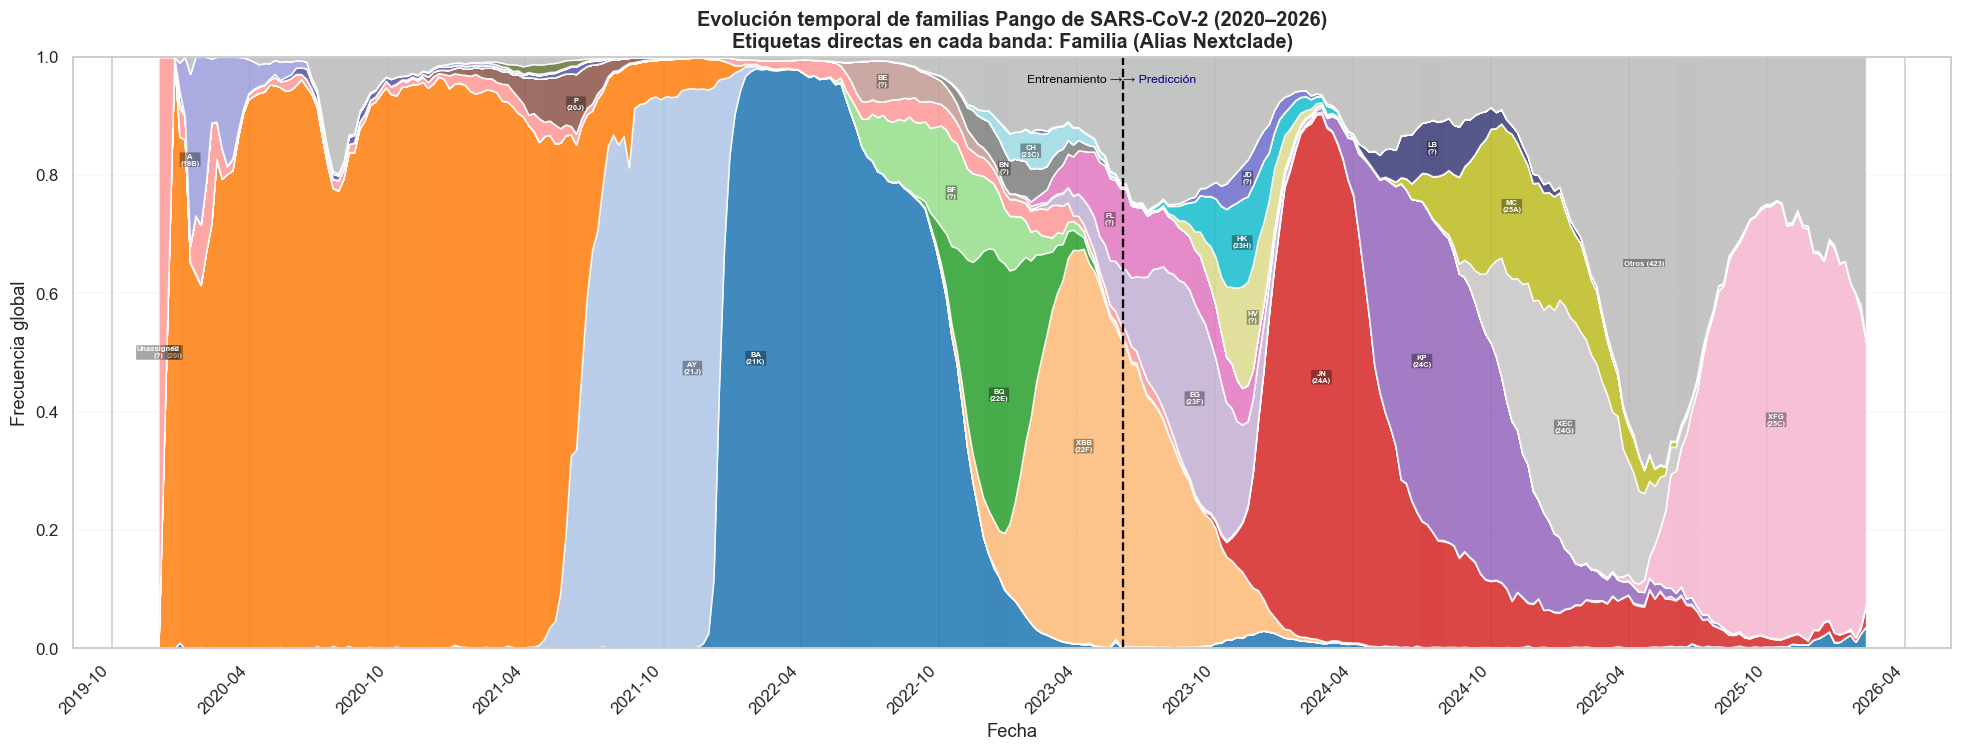

Figura guardada: 2_5_timeline_familias.png

Familias con pico ≥ 1%: 75


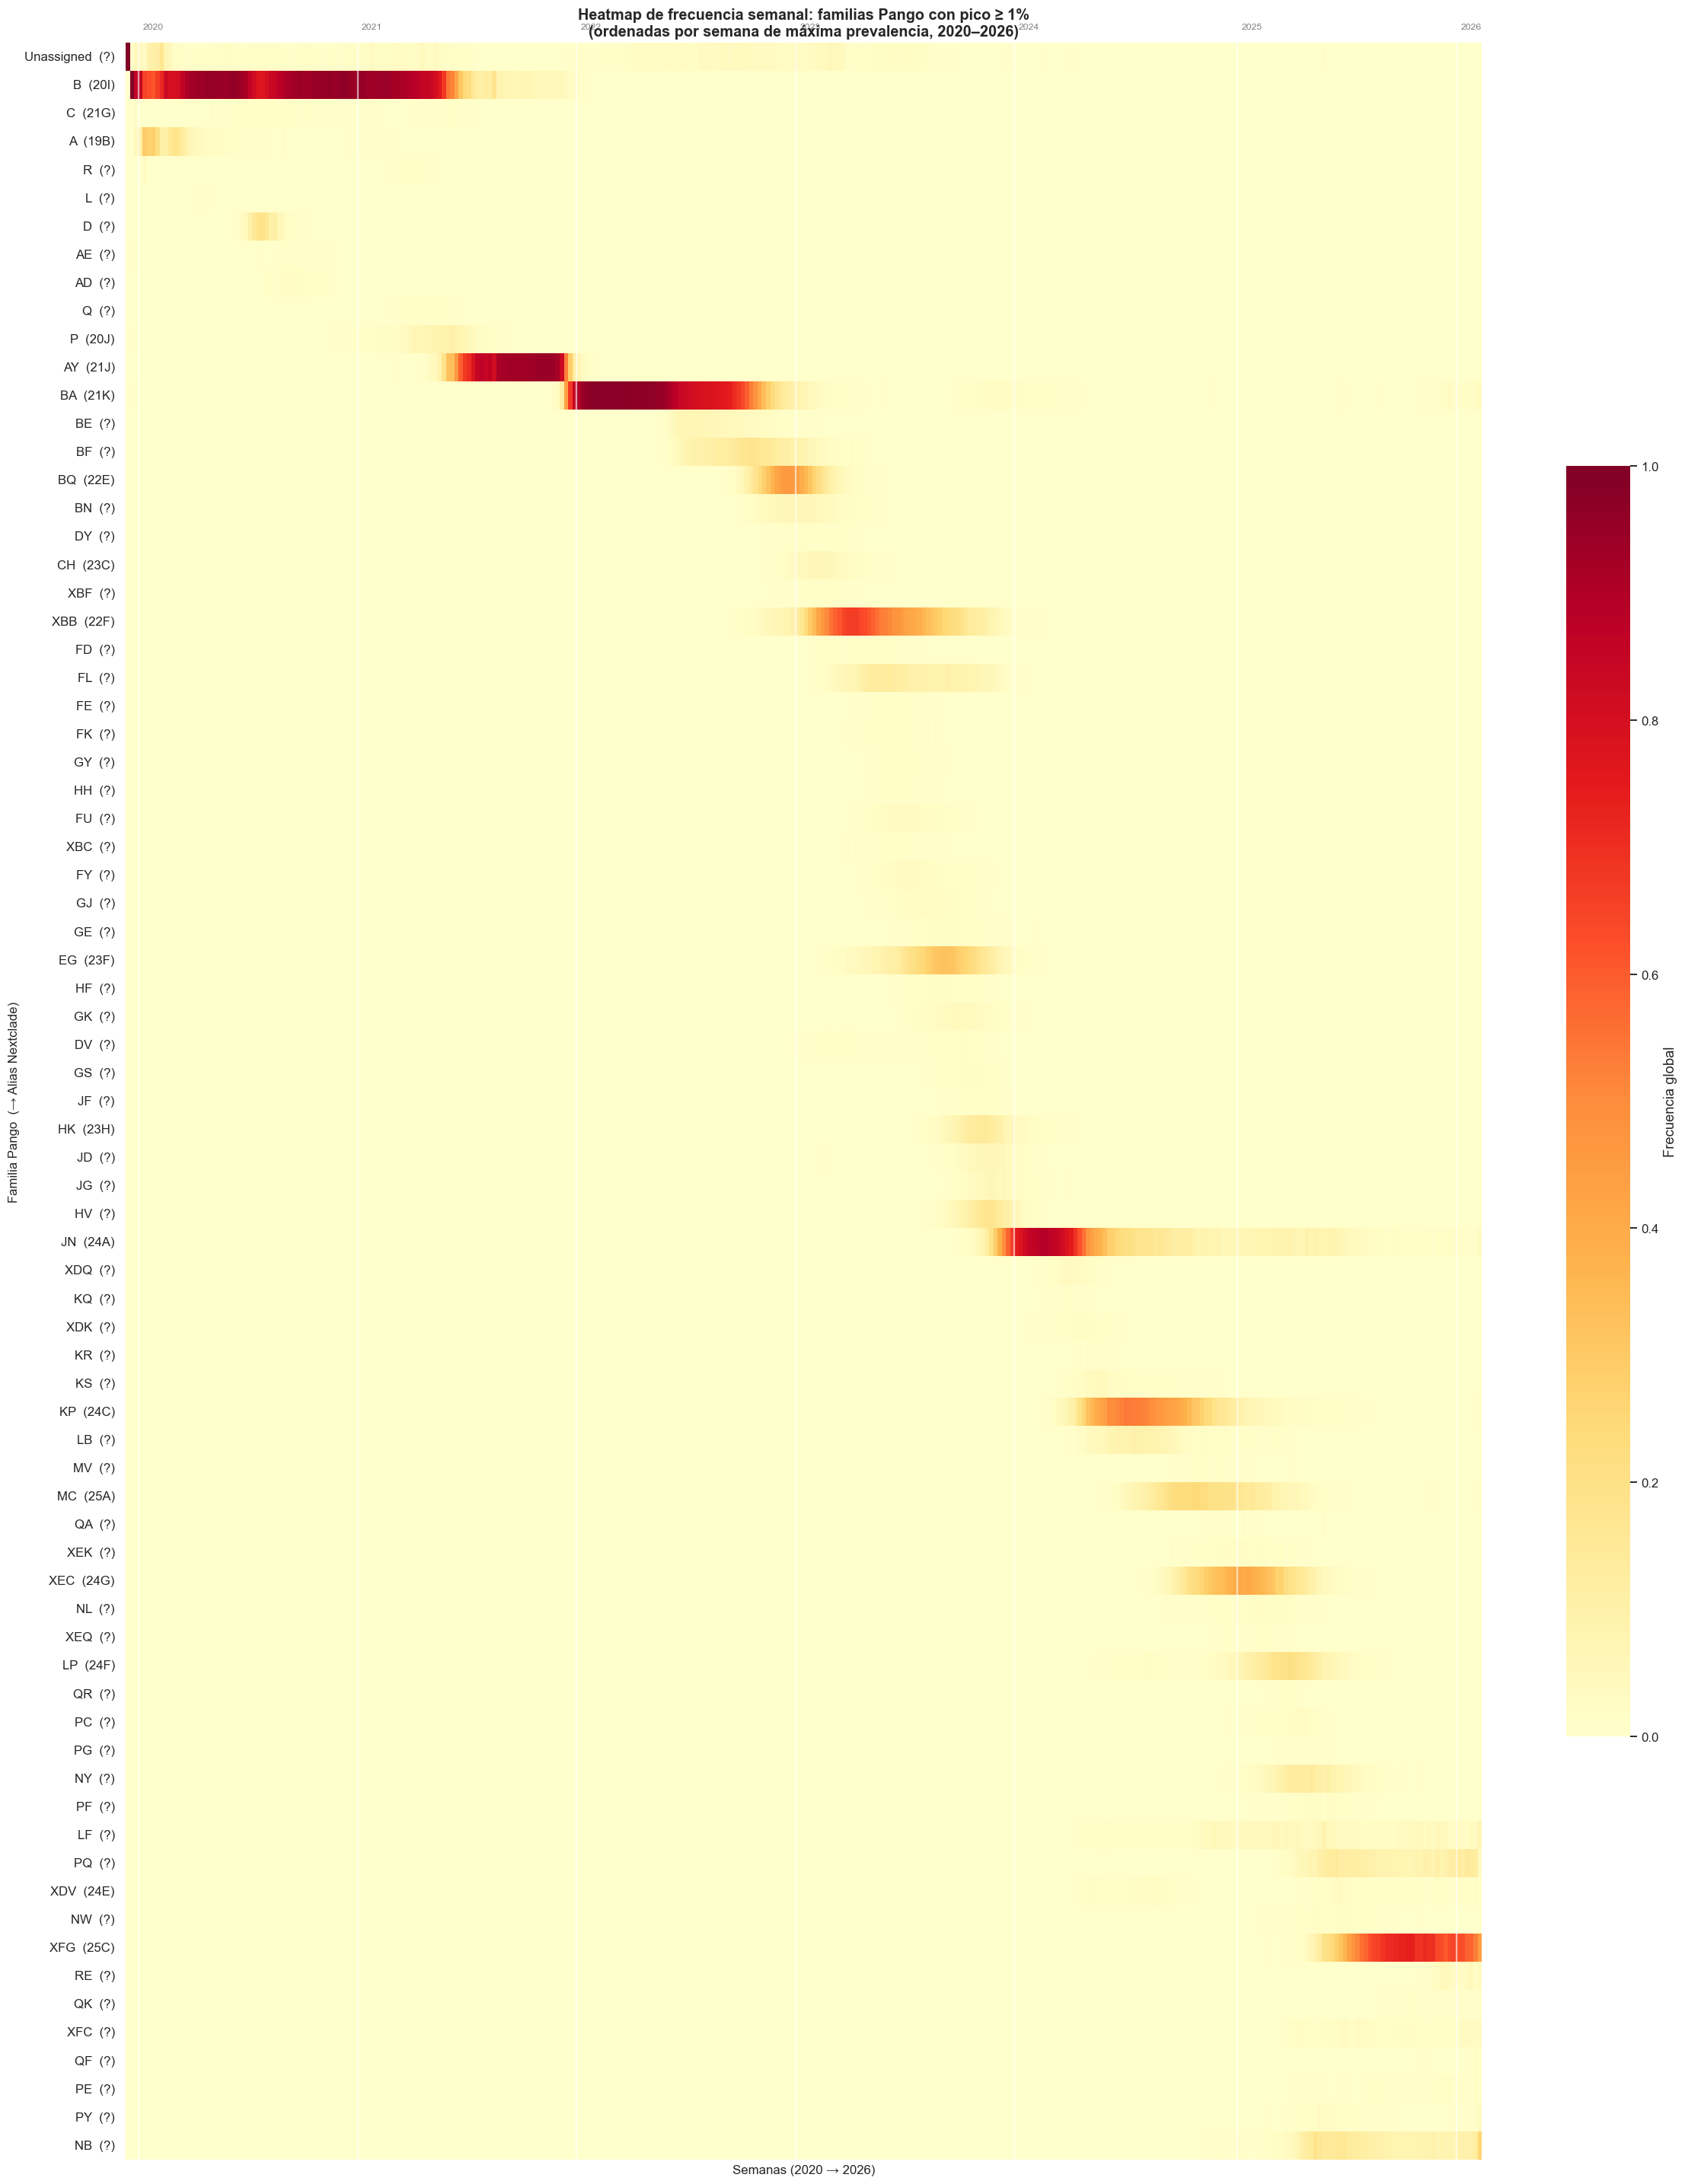

Figura guardada: 2_5_heatmap_familias.png


In [17]:
# ── Celda 2.5 — Timeline apilado: top-25 familias + Resto ──────────────────

top25_idx = (df_family_time.groupby('lineage_family')['n_seqs']
             .sum().sort_values(ascending=False).head(25).index)
n_resto = df_family_time['lineage_family'].nunique() - 25

df_t25    = df_family_time[df_family_time['lineage_family'].isin(top25_idx)]
df_pivot25 = (df_t25.pivot_table(index='week', columns='lineage_family',
                                  values='freq', fill_value=0)
              .sort_index()[list(top25_idx)])
df_resto_freq = (df_family_time[~df_family_time['lineage_family'].isin(top25_idx)]
                 .groupby('week')['freq'].sum())
df_pivot25['_Resto'] = df_resto_freq.reindex(df_pivot25.index, fill_value=0)

fig, ax = plt.subplots(figsize=(18, 7))
cols_plot = list(top25_idx) + ['_Resto']
palette   = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors[:5]) + ['#bbbbbb']

ax.stackplot(df_pivot25.index,
             *[df_pivot25[c] for c in cols_plot],
             labels=[c if c != '_Resto' else f'Resto ({n_resto} familias)'
                     for c in cols_plot],
             colors=palette[:len(cols_plot)], alpha=0.85)

# Etiquetas directas en el pico de cada banda (sin leyenda)
_bot = np.zeros(len(df_pivot25))
for _ci, _col in enumerate(cols_plot):
    _vals = df_pivot25[_col].values.copy()
    _tops = _bot + _vals
    _mids = (_bot + _tops) / 2.0
    _pk   = int(np.argmax(_vals))
    if _vals[_pk] >= 0.025:
        _nc  = FAMILY_TO_ALIAS.get(_col, '?') if _col != '_Resto' else '—'
        _lbl = f'{_col}\n({_nc})' if _col != '_Resto' else f'Otros ({n_resto})'
        ax.text(df_pivot25.index[_pk], _mids[_pk], _lbl,
                fontsize=5, va='center', ha='center', color='white', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', fc='black', alpha=0.35, ec='none'),
                clip_on=True)
    _bot = _tops

# Franjas de época pandémica en el fondo
for ep_name, ep in PANDEMIC_EPOCHS.items():
    s = pd.to_datetime(ep['start'])
    e = min(pd.to_datetime(ep['end']), df_pivot25.index.max())
    if s < df_pivot25.index.min():
        s = df_pivot25.index.min()
    ax.axvspan(s, e, alpha=0.06, color=ep['color'], zorder=0)

# Línea de corte entrenamiento / predicción
ax.axvline(CUTOFF_WEEK_ML, color='black', linestyle='--', linewidth=1.5,
           label=f'Corte entrenamiento ({CUTOFF_WEEK_ML.date()})')
ax.text(CUTOFF_WEEK_ML, 0.97, 'Entrenamiento →', ha='right', va='top',
        fontsize=8, color='black', transform=ax.get_xaxis_transform())
ax.text(CUTOFF_WEEK_ML, 0.97, '→ Predicción', ha='left', va='top',
        fontsize=8, color='navy', transform=ax.get_xaxis_transform())

ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Frecuencia global', fontsize=12)
ax.set_title('Evolución temporal de familias Pango de SARS-CoV-2 (2020–2026)\n'
             'Etiquetas directas en cada banda: Familia (Alias Nextclade)',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.15, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTDIR / '2_5_timeline_familias.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figura guardada: 2_5_timeline_familias.png')

# ── Heatmap: familias con pico ≥ 1% ─────────────────────────────────────────
fams_sig = (df_family_time.groupby('lineage_family')['freq']
            .max().pipe(lambda s: s[s >= 0.01]).sort_values(ascending=False).index)
print(f'\nFamilias con pico ≥ 1%: {len(fams_sig)}')

df_heat = (df_family_time[df_family_time['lineage_family'].isin(fams_sig)]
           .pivot_table(index='lineage_family', columns='week', values='freq', fill_value=0))
df_heat = df_heat.loc[df_heat.idxmax(axis=1).sort_values().index]
ytick_labels = [f'{f}  ({FAMILY_TO_ALIAS.get(f,"?")})' for f in df_heat.index]

fig2, ax2 = plt.subplots(figsize=(22, max(8, len(fams_sig) * 0.35)))
sns.heatmap(df_heat, cmap='YlOrRd', ax=ax2, vmin=0,
            cbar_kws={'label':'Frecuencia global', 'shrink':0.6},
            yticklabels=ytick_labels, xticklabels=False)
ax2.set_title('Heatmap de frecuencia semanal: familias Pango con pico ≥ 1%\n'
              '(ordenadas por semana de máxima prevalencia, 2020–2026)',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Semanas (2020 → 2026)', fontsize=11)
ax2.set_ylabel('Familia Pango  (→ Alias Nextclade)', fontsize=11)
weeks = df_heat.columns
for yr in [2020, 2021, 2022, 2023, 2024, 2025, 2026]:
    yr_mask = [w.year == yr for w in weeks]
    if any(yr_mask):
        pos = next(i for i, m in enumerate(yr_mask) if m)
        ax2.axvline(pos, color='white', linewidth=1.5, alpha=0.6)
        ax2.text(pos + 1, -0.5, str(yr), fontsize=8, color='gray')
plt.tight_layout()
plt.savefig(OUTDIR / '2_5_heatmap_familias.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figura guardada: 2_5_heatmap_familias.png')


### 2.6 — Timeline por clados Nextclade (2020–2026)

La misma visualización que la anterior pero agregando las familias Pango
según su **clado Nextclade estándar** (19A → 25C). De los 50 clados oficiales,
19 tienen representación en los datos; el resto se agrupa en "Otros".

Esta vista permite comparar directamente con la nomenclatura epidemiológica
oficial (Alpha, Delta, Omicron BA.1, JN.1, XFG...) y es la representación
más habitual en publicaciones de referencia (Nextstrain / ECDC).


Clados Nextclade en el plot : 19
Familias en "Otros"         : 429


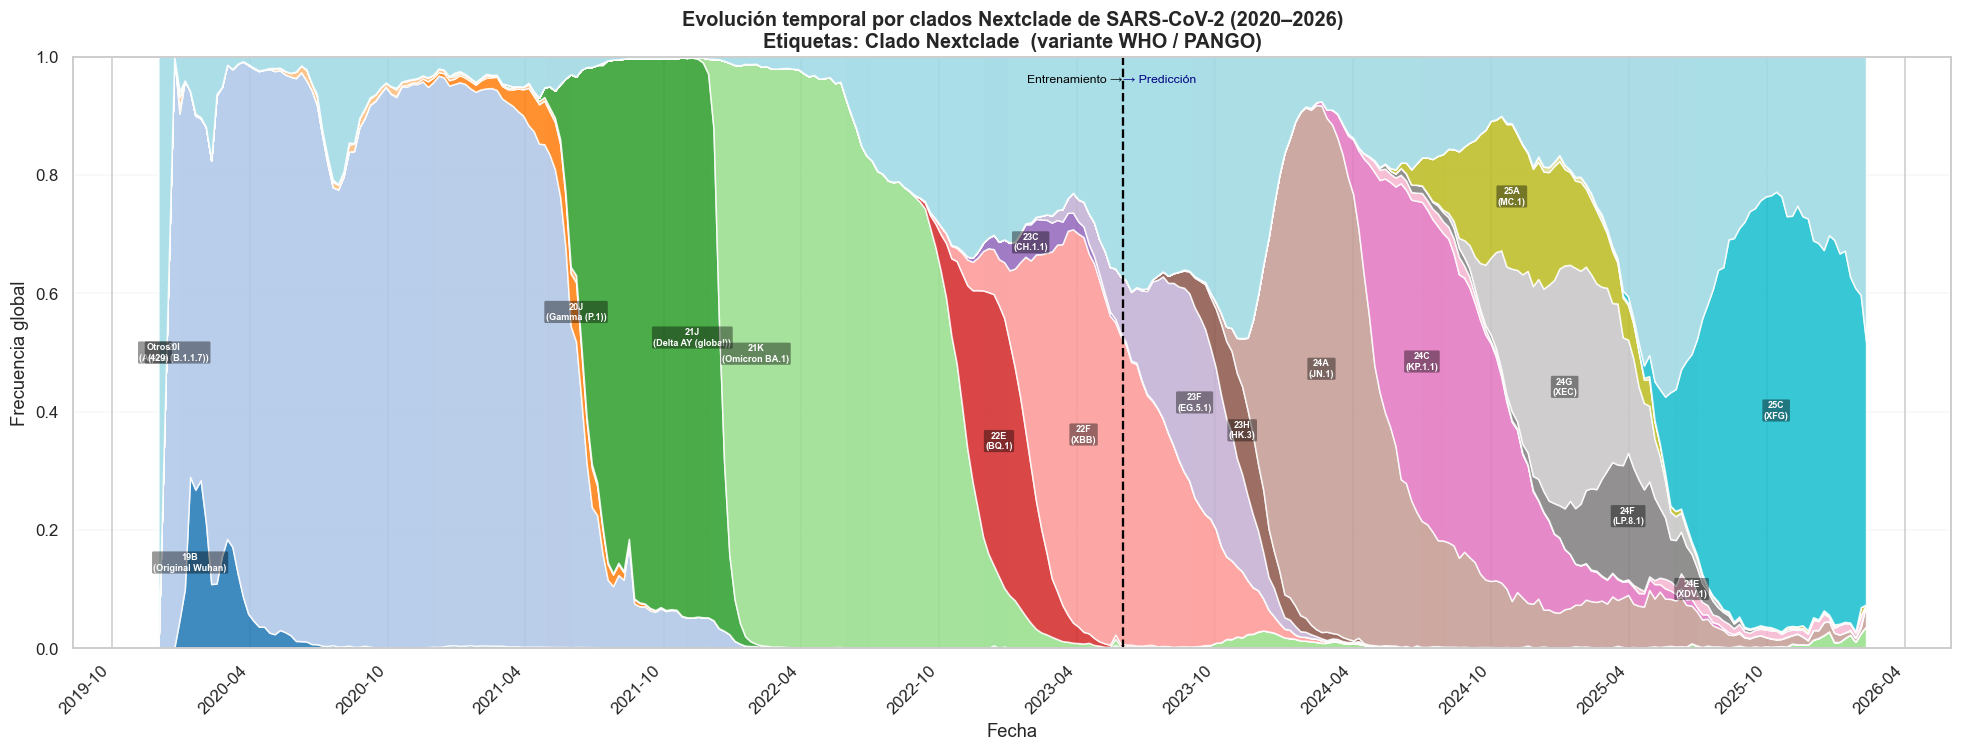

Figura guardada: 2_6_timeline_nextclade.png


In [18]:
# ── Celda 2.6 — Timeline por clados Nextclade ────────────────────────────────

# Agrupa df_family_time por semana × alias Nextclade estándar
# freq ya suma 1.0/semana → la suma de grupos da la fracción de cada clado
_nc_grp = df_family_time.copy()
_nc_grp['nc'] = _nc_grp['nextclade_alias'].replace({'?': '_Otros'})

nc_pivot = (_nc_grp.groupby(['week', 'nc'])['freq']
            .sum().reset_index()
            .pivot_table(index='week', columns='nc', values='freq', fill_value=0)
            .sort_index())

# Ordenar por cronología Nextclade oficial; Otros al final
nc_cols = [c for c in NEXTCLADE_ORDER if c in nc_pivot.columns]
if '_Otros' in nc_pivot.columns:
    nc_cols.append('_Otros')
nc_pivot = nc_pivot[nc_cols]
n_otros_nc = df_family_time[df_family_time['nextclade_alias'] == '?']['lineage_family'].nunique()

print(f'Clados Nextclade en el plot : {len(nc_cols) - 1}')
print(f'Familias en "Otros"         : {n_otros_nc}')

# ── Figura ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 7))
palette_nc = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors[:5]) + ['#cccccc']

ax.stackplot(nc_pivot.index,
             *[nc_pivot[c] for c in nc_cols],
             labels=[f'{c}  ({NEXTCLADE_ALIAS_MAP.get(c,"—")})' if c != '_Otros'
                     else f'Otros ({n_otros_nc} familias)'
                     for c in nc_cols],
             colors=palette_nc[:len(nc_cols)], alpha=0.85)

# Etiquetas directas en el pico de cada banda
_bot = np.zeros(len(nc_pivot))
for _ci, _col in enumerate(nc_cols):
    _vals = nc_pivot[_col].values.copy()
    _tops = _bot + _vals
    _mids = (_bot + _tops) / 2.0
    _pk   = int(np.argmax(_vals))
    if _vals[_pk] >= 0.025:
        _alias = NEXTCLADE_ALIAS_MAP.get(_col, '?')
        _lbl   = (f'{_col}\n({_alias})' if _col != '_Otros'
                  else f'Otros\n({n_otros_nc})')
        ax.text(nc_pivot.index[_pk], _mids[_pk], _lbl,
                fontsize=6, va='center', ha='center', color='white', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', fc='black', alpha=0.4, ec='none'),
                clip_on=True)
    _bot = _tops

# Franjas épocas pandémicas
for ep_name, ep in PANDEMIC_EPOCHS.items():
    s_ep = pd.to_datetime(ep['start'])
    e_ep = min(pd.to_datetime(ep['end']), nc_pivot.index.max())
    if s_ep < nc_pivot.index.min():
        s_ep = nc_pivot.index.min()
    ax.axvspan(s_ep, e_ep, alpha=0.06, color=ep['color'], zorder=0)

# Línea de corte entrenamiento / predicción
ax.axvline(CUTOFF_WEEK_ML, color='black', linestyle='--', linewidth=1.5)
ax.text(CUTOFF_WEEK_ML, 0.97, 'Entrenamiento →', ha='right', va='top',
        fontsize=8, color='black', transform=ax.get_xaxis_transform())
ax.text(CUTOFF_WEEK_ML, 0.97, '→ Predicción', ha='left', va='top',
        fontsize=8, color='navy', transform=ax.get_xaxis_transform())

ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Frecuencia global', fontsize=12)
ax.set_title('Evolución temporal por clados Nextclade de SARS-CoV-2 (2020–2026)\n'
             'Etiquetas: Clado Nextclade  (variante WHO / PANGO)',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.15, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTDIR / '2_6_timeline_nextclade.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Figura guardada: 2_6_timeline_nextclade.png')


### 2.7 — Análisis mutacional

Caracterizamos el espacio mutacional capturado por el streaming:

- **Distribución de mutaciones únicas por familia** — ¿cuántas mutaciones
  distintas lleva cada familia respecto a Wuhan-Hu-1?
- **Top-20 mutaciones globales** — las que alcanzan mayor frecuencia histórica
- **Distribución por proteína** — Spike, NSP3, NSP12...
- **Tabla cruzada** — frecuencia media de las top-10 mutaciones en las top-10
  familias por volumen (perfil mutacional within-family)

Este análisis justifica la selección de features para el Modelo 2.


=== ANÁLISIS MUTACIONAL ===
  Mutaciones brutas detectadas :  205,156
  Mutaciones con señal real    :    2,279
  Top-30 para el Modelo 2      :       30



Top-20 familias por nº de mutaciones únicas vs Wuhan:


,familia,alias_nc,mut_unicas,total_seqs
0,B,20I,142597,2772386
1,BA,21K,140995,6368484
2,AY,21J,118850,4142853
3,XBB,22F,77797,573349
4,Unassigned,?,58625,257006
5,BQ,22E,48670,452391
6,JN,24A,42430,317159
7,BF,?,42305,344640
8,P,20J,27948,141251
9,BE,?,27471,135959


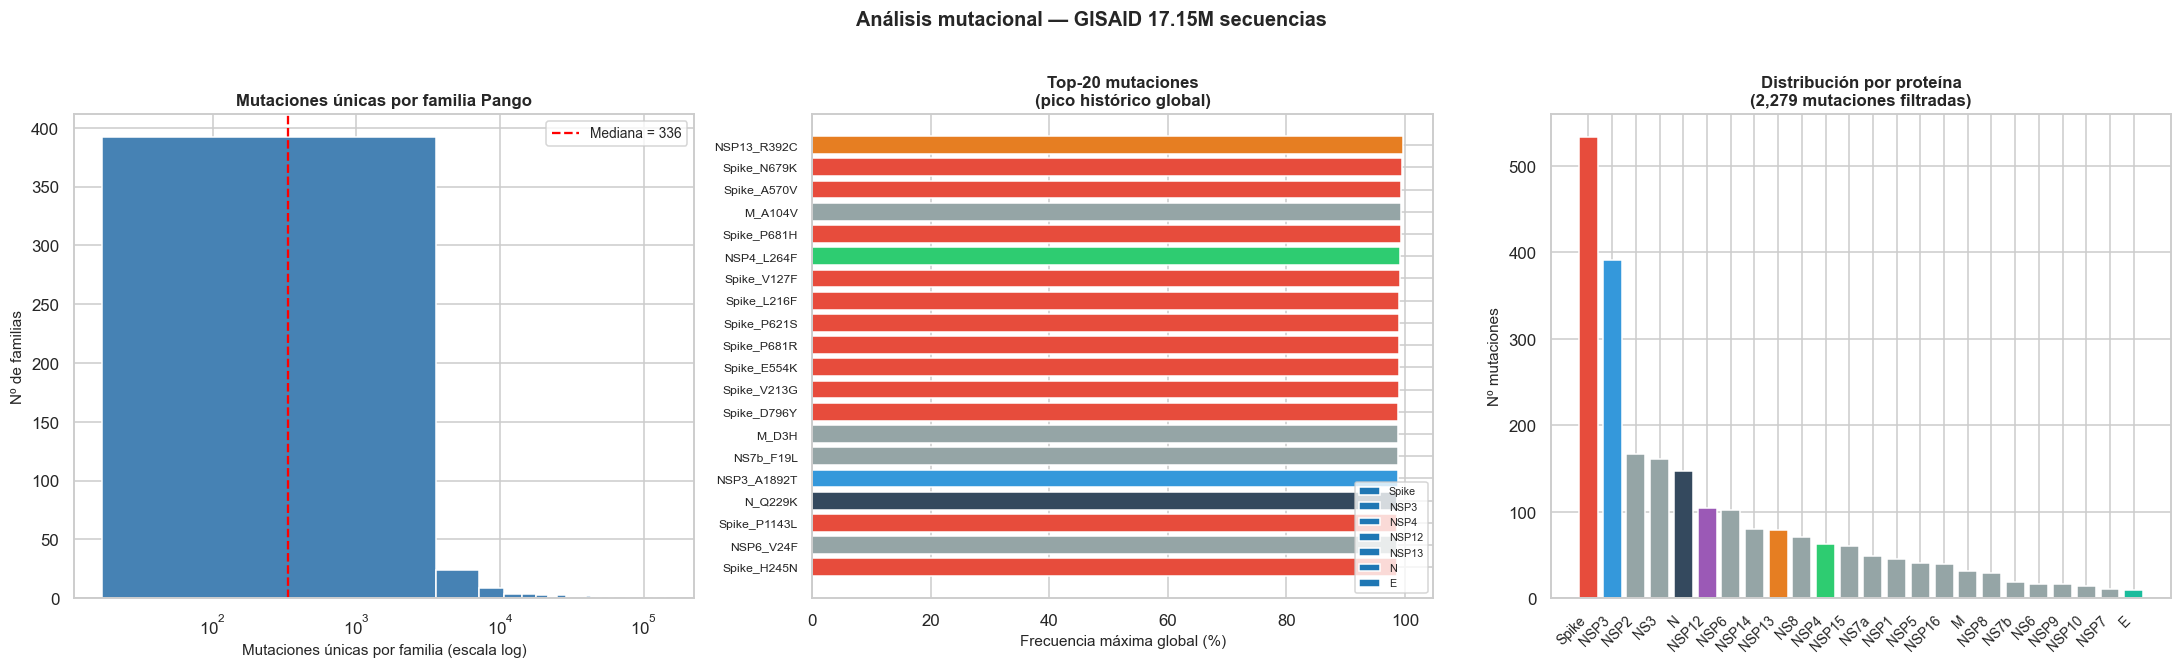

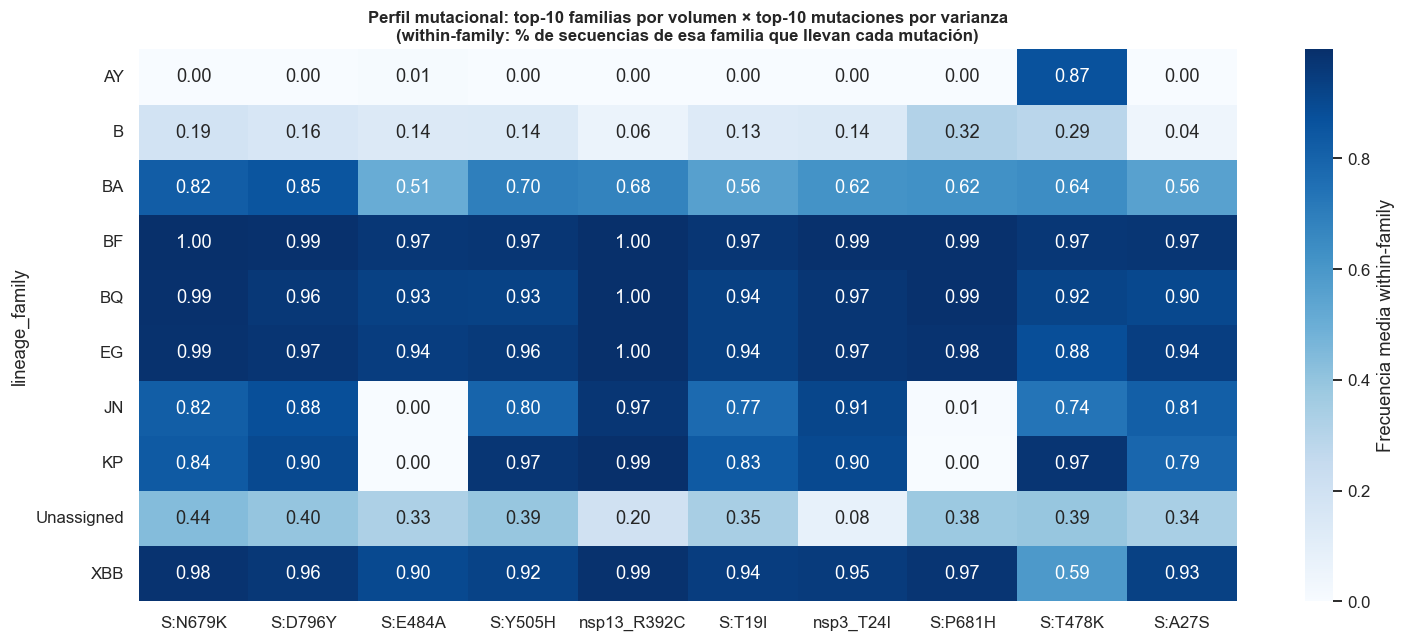

Figuras guardadas: 2_7_analisis_mutaciones.png, 2_7_tabla_cruzada_mut_familias.png


In [19]:
# ── Celda 2.7 — Análisis mutacional ─────────────────────────────────────────

print('=== ANÁLISIS MUTACIONAL ===')
print(f'  Mutaciones brutas detectadas : {freq_matrix_mut_raw.shape[1]:>8,}')
print(f'  Mutaciones con señal real    : {freq_matrix_mut.shape[1]:>8,}')
print(f'  Top-30 para el Modelo 2      : {30:>8}')
print()

# ── Mutaciones únicas por familia ────────────────────────────────────────────
fam_mut_sets = {}
for wk, fam_dict in family_mut_week_counts.items():
    for fam, mut_counter in fam_dict.items():
        fam_mut_sets.setdefault(fam, set()).update(mut_counter.keys())

df_fam_stats = pd.DataFrame([
    {'familia'    : f,
     'alias_nc'   : FAMILY_TO_ALIAS.get(f, '?'),
     'mut_unicas' : len(muts),
     'total_seqs' : int(df_family_time[df_family_time['lineage_family']==f]['n_seqs'].sum())
                   if f in df_family_time['lineage_family'].values else 0}
    for f, muts in fam_mut_sets.items()
]).sort_values('mut_unicas', ascending=False).reset_index(drop=True)

print('Top-20 familias por nº de mutaciones únicas vs Wuhan:')
display(df_fam_stats.head(20))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: distribución de mutaciones únicas por familia
axes[0].hist(df_fam_stats['mut_unicas'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_xscale('log')
axes[0].set_xlabel('Mutaciones únicas por familia (escala log)', fontsize=10)
axes[0].set_ylabel('Nº de familias', fontsize=10)
axes[0].set_title('Mutaciones únicas por familia Pango', fontsize=11, fontweight='bold')
med = df_fam_stats['mut_unicas'].median()
axes[0].axvline(med, color='red', linestyle='--', label=f'Mediana = {med:.0f}')
axes[0].legend(fontsize=9)

# Panel 2: top-20 mutaciones por frecuencia histórica máxima
top20_global = (max_freq_ever[mask_mut].sort_values(ascending=False)
                .head(20).reset_index())
top20_global.columns = ['mutacion', 'freq_max']
top20_global['proteina'] = top20_global['mutacion'].str.split('_').str[0]
colors_prot = {'Spike':'#E74C3C','NSP3':'#3498DB','NSP4':'#2ECC71',
               'NSP12':'#9B59B6','NSP13':'#E67E22','N':'#34495E','E':'#1ABC9C'}
axes[1].barh(range(len(top20_global)),
             top20_global['freq_max'] * 100,
             color=[colors_prot.get(p, '#95A5A6') for p in top20_global['proteina']],
             edgecolor='white')
axes[1].set_yticks(range(len(top20_global)))
axes[1].set_yticklabels(top20_global['mutacion'], fontsize=8)
axes[1].set_xlabel('Frecuencia máxima global (%)', fontsize=10)
axes[1].set_title('Top-20 mutaciones\n(pico histórico global)', fontsize=11, fontweight='bold')
axes[1].invert_yaxis()
for prot, col in colors_prot.items():
    axes[1].barh([], [], color=col, label=prot)
axes[1].legend(fontsize=7, loc='lower right')

# Panel 3: distribución por proteína de todas las mutaciones filtradas
all_prots = pd.Series([m.split('_')[0] if '_' in m else 'Otro'
                        for m in freq_matrix_mut.columns]).value_counts()
axes[2].bar(range(len(all_prots)),
            all_prots.values,
            color=[colors_prot.get(p, '#95A5A6') for p in all_prots.index],
            edgecolor='white')
axes[2].set_xticks(range(len(all_prots)))
axes[2].set_xticklabels(all_prots.index, rotation=45, ha='right', fontsize=9)
axes[2].set_ylabel('Nº mutaciones', fontsize=10)
axes[2].set_title(f'Distribución por proteína\n'
                  f'({freq_matrix_mut.shape[1]:,} mutaciones filtradas)',
                  fontsize=11, fontweight='bold')

plt.suptitle('Análisis mutacional — GISAID 17.15M secuencias',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTDIR / '2_7_analisis_mutaciones.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Tabla cruzada: top-10 familias × top-10 mutaciones ──────────────────────
# top-10 familias por volumen total de secuencias (relevantes para el modelo)
top10_fams_cross = (df_family_time.groupby('lineage_family')['n_seqs']
                    .sum().sort_values(ascending=False).head(10).index.tolist())
mut_cols         = [f'mut_{m}' for m in top30_muts[:10]]
df_cross = (df_family_mut_freq[df_family_mut_freq['lineage_family'].isin(top10_fams_cross)]
            .groupby('lineage_family')[mut_cols].mean().round(3))
df_cross.columns = [c.replace('mut_Spike_','S:').replace('mut_NSP','nsp')
                     .replace('mut_','') for c in df_cross.columns]

fig2, ax2 = plt.subplots(figsize=(14, 6))
sns.heatmap(df_cross, annot=True, fmt='.2f', cmap='Blues', ax=ax2,
            cbar_kws={'label':'Frecuencia media within-family'})
ax2.set_title('Perfil mutacional: top-10 familias por volumen × top-10 mutaciones por varianza\n'
              '(within-family: % de secuencias de esa familia que llevan cada mutación)',
              fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / '2_7_tabla_cruzada_mut_familias.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figuras guardadas: 2_7_analisis_mutaciones.png, 2_7_tabla_cruzada_mut_familias.png')


### 2.8 — Firma mutacional: ¿a qué base va cada mutación?

Las mutaciones se han manejado hasta ahora a nivel de aminoácido (ej.
`Spike_L452R`). Pero cada cambio de aminoácido está producido por un cambio
concreto de nucleótido en el genoma (ej. una citosina que pasa a ser uracilo).
Conocer ese cambio de base es relevante porque los distintos mecanismos que
generan mutaciones en SARS-CoV-2 dejan "firmas" características — por ejemplo,
la edición por deaminasas del huésped (familia APOBEC) produce sobre todo
transiciones C→U, mientras que el daño oxidativo (ROS) favorece G→U.

**Método:** el fichero `COVIDSeq_ALL_pos51-29816.fas` contiene como primer
registro el genoma de referencia completo (Wuhan-Hu-1, NC_045512.2). A partir
de él se extrae el codón de referencia en la posición de cada mutación, se
valida que ese codón traduce al aminoácido "wild type" indicado en el nombre
de la mutación, y se busca el codón sinónimo del aminoácido mutante que
difiere del codón de referencia en el **menor número de bases** (la ruta
evolutiva más parsimoniosa). Cuando esa ruta es un único nucleótido, se puede
afirmar con confianza qué base cambió por cuál. Las deleciones e inserciones
(`...del`, `...insXXXX`) no son sustituciones de base — se representan y
cuentan aparte, en vez de descartarse.

**Nota de rigor — NSP12:** nsp12 no es un ORF independiente sino un producto
de corte de la poliproteína ORF1ab, con un desplazamiento ribosomal (frameshift)
−1 respecto a ORF1a. Antes de usar la referencia de nsp12 se valida
explícitamente que el codón en la posición 323 traduce a Prolina (mutación
*P323L*, presente en prácticamente todos los linajes no-Wuhan) — si esa
comprobación fallara, sería la señal de que el punto de frameshift está mal
localizado.

**Estructura de la sección:**
- 2.8a — extracción y validación de la referencia Spike/NSP12.
- 2.8b — inferencia del cambio de base para el top-30 Spike/NSP12.
- 2.8c — visualización e interpretación descriptiva del top-30.
- 2.8d — test de selección: compara el patrón transición/transversión entre
  TODAS las mutaciones Spike/NSP12 con señal real (no solo el top-30) que
  llegaron a dominar frente a las que no, con un test de Fisher/chi-cuadrado.

**Limitación:** al partir solo del nombre de la mutación (no de la lectura
real de cada secuencia), el método infiere la ruta de cambio de base más
parsimoniosa, no necesariamente la única que ha ocurrido biológicamente.

In [20]:
# ── Celda 2.8a — Referencia Wuhan-Hu-1: extracción de Spike y NSP12 ──────────
CODON_TABLE = {
    'TTT':'F','TTC':'F','TTA':'L','TTG':'L','CTT':'L','CTC':'L','CTA':'L','CTG':'L',
    'ATT':'I','ATC':'I','ATA':'I','ATG':'M','GTT':'V','GTC':'V','GTA':'V','GTG':'V',
    'TCT':'S','TCC':'S','TCA':'S','TCG':'S','CCT':'P','CCC':'P','CCA':'P','CCG':'P',
    'ACT':'T','ACC':'T','ACA':'T','ACG':'T','GCT':'A','GCC':'A','GCA':'A','GCG':'A',
    'TAT':'Y','TAC':'Y','TAA':'*','TAG':'*','CAT':'H','CAC':'H','CAA':'Q','CAG':'Q',
    'AAT':'N','AAC':'N','AAA':'K','AAG':'K','GAT':'D','GAC':'D','GAA':'E','GAG':'E',
    'TGT':'C','TGC':'C','TGA':'*','TGG':'W','CGT':'R','CGC':'R','CGA':'R','CGG':'R',
    'AGT':'S','AGC':'S','AGA':'R','AGG':'R','GGT':'G','GGC':'G','GGA':'G','GGG':'G',
}
AA_TO_CODONS = {}
for _cod, _aa in CODON_TABLE.items():
    AA_TO_CODONS.setdefault(_aa, []).append(_cod)

def _translate(seq):
    return ''.join(CODON_TABLE.get(seq[i:i+3], 'X') for i in range(0, len(seq) - 2, 3))

# ── Cargar genoma de referencia Wuhan-Hu-1 (primer registro del FASTA) ───────
with open(PATHS['fasta_ref'], 'r', encoding='utf-8', errors='replace') as _fh:
    _ref_lines, _ref_header = [], None
    for _line in _fh:
        _line = _line.rstrip()
        if _line.startswith('>'):
            if _ref_header is not None:
                break
            _ref_header = _line
        else:
            _ref_lines.append(_line)
REF_GENOME = ''.join(_ref_lines)
print(f'Referencia cargada: {_ref_header}')
print(f'  Longitud: {len(REF_GENOME):,} nt')

# El fichero empieza en la posición genómica 51 (nombre del fichero:
# "pos51-29816"): posición_genoma (1-based) = índice_fichero (0-based) + 51
REF_FILE_OFFSET = 51
def gpos(p):
    """Posición genómica 1-based -> índice 0-based en REF_GENOME."""
    return p - REF_FILE_OFFSET

# Coordenadas Spike: CDS 21563-25384 (verificado: codón de inicio ATG en esa
# posición traduce exactamente a MFVFLVLLPLVSSQCVNL..., inicio real de Spike)
REF_SPIKE_CDS = REF_GENOME[gpos(21563):gpos(25384) + 1]

# Coordenadas NSP12: nsp12 es un producto de corte de ORF1ab con frameshift
# ribosomal -1 en la secuencia deslizante (~13462-13468). Anotación estándar
# NC_045512.2: join(13442..13468, 13468..16236).
REF_NSP12_CDS = REF_GENOME[gpos(13442):gpos(13468) + 1] + REF_GENOME[gpos(13468):gpos(16236) + 1]

_spike_prot = _translate(REF_SPIKE_CDS)
_nsp12_prot = _translate(REF_NSP12_CDS)

print()
print('VALIDACIÓN de la referencia extraída:')
print(f'  Spike CDS : {len(REF_SPIKE_CDS)} nt = {len(_spike_prot)} aa (incl. stop)')
print(f'    Inicio  : {_spike_prot[:15]}...  (esperado: MFVFLVLLPLVSSQC...)')
print(f'    Stops internos: {_spike_prot[:-1].count("*")}  (esperado: 0)')
assert _spike_prot[:15] == 'MFVFLVLLPLVSSQC', 'Referencia de Spike no coincide con el genoma esperado'
assert _spike_prot[:-1].count('*') == 0, 'Codón de stop interno inesperado en Spike'

print(f'  NSP12 CDS : {len(REF_NSP12_CDS)} nt = {len(_nsp12_prot)} aa')
print(f'    Inicio  : {_nsp12_prot[:15]}...  (esperado: SADAQSFLNRVCGVS...)')
print(f'    Posición 323 (landmark P323L): {_nsp12_prot[322]}  (esperado: P)')
print(f'    Stops internos: {_nsp12_prot.count("*")}  (esperado: 0)')
assert _nsp12_prot[:15] == 'SADAQSFLNRVCGVS', 'Referencia de NSP12 no coincide (revisar frameshift)'
assert _nsp12_prot[322] == 'P', 'Landmark P323L no confirmado: el frameshift de NSP12 está mal localizado'
assert _nsp12_prot.count('*') == 0, 'Codón de stop interno inesperado en NSP12'
print()
print('✅ Referencia Spike y NSP12 verificada contra landmarks conocidos.')

Referencia cargada: >NC_045512 |Severe acute respiratory syndrome coronavirus 2 isolate Wuhan-Hu-1| complete genome
  Longitud: 29,766 nt

VALIDACIÓN de la referencia extraída:
  Spike CDS : 3822 nt = 1274 aa (incl. stop)
    Inicio  : MFVFLVLLPLVSSQC...  (esperado: MFVFLVLLPLVSSQC...)
    Stops internos: 0  (esperado: 0)
  NSP12 CDS : 2796 nt = 932 aa
    Inicio  : SADAQSFLNRVCGVS...  (esperado: SADAQSFLNRVCGVS...)
    Posición 323 (landmark P323L): P  (esperado: P)
    Stops internos: 0  (esperado: 0)

✅ Referencia Spike y NSP12 verificada contra landmarks conocidos.


In [21]:
# ── Celda 2.8b — Inferencia del cambio de nucleótido por mutación ────────────
_MUT_RE = re.compile(r'^(Spike|NSP12)_([A-Z])(\d+)([A-Z])$')
_DEL_RE = re.compile(r'^(Spike|NSP12)_([A-Z])(\d+)del$')
_INS_RE = re.compile(r'^(Spike|NSP12)_ins(\d+)([A-Z]+)$')
_TRANSITIONS = {('A','G'), ('G','A'), ('C','T'), ('T','C')}
_REF_BY_PROT = {'Spike': REF_SPIKE_CDS, 'NSP12': REF_NSP12_CDS}

def _hamming(a, b):
    return sum(x != y for x, y in zip(a, b))

def infer_nt_change(mutation):
    """Infiere el cambio de nucleótido más parsimonioso para una mutación.

    Sustituciones 'Proteina_WTposMUT': compara el codón de referencia con los
    codones sinónimos del aminoácido mutante. Deleciones ('...del') e
    inserciones ('...insXXXX') se representan aparte (no son sustituciones de
    base, así que no se les asigna transición/transversión).
    """
    m = _MUT_RE.match(mutation)
    if m is not None:
        prot, wt_aa, pos_s, mut_aa = m.groups()
        pos = int(pos_s)
        ref_cds = _REF_BY_PROT.get(prot)
        if ref_cds is None or pos * 3 > len(ref_cds):
            return None
        codon_ref = ref_cds[(pos - 1) * 3: pos * 3]
        if CODON_TABLE.get(codon_ref) != wt_aa:
            return dict(mutacion=mutation, proteina=prot, posicion=pos,
                        wt=wt_aa, mut=mut_aa, codon_ref=codon_ref,
                        valido=False, motivo='codon_ref no traduce al WT esperado')

        candidatos = AA_TO_CODONS.get(mut_aa, [])
        if not candidatos:
            # mut_aa no es uno de los 20 aminoácidos estándar (p.ej. 'X' de
            # GISAID cuando la lectura es ambigua/de baja calidad en esa
            # posición) — no hay codón sinónimo al que compararlo.
            return dict(mutacion=mutation, proteina=prot, posicion=pos,
                        wt=wt_aa, mut=mut_aa, codon_ref=codon_ref,
                        valido=False, motivo='aminoácido mutante no estándar (X/B/Z/J)')

        dists = [(_hamming(codon_ref, c), c) for c in candidatos]
        min_d = min(d for d, _ in dists)
        mejores = [c for d, c in dists if d == min_d]

        if min_d == 1:
            cambios = set()
            for c in mejores:
                for i in range(3):
                    if codon_ref[i] != c[i]:
                        cambios.add((codon_ref[i], c[i]))
            base_from, base_to = sorted(cambios)[0]
            tipo = 'Transición' if (base_from, base_to) in _TRANSITIONS else 'Transversión'
            cambio_str = f'{base_from}→{base_to}'
            ambiguo = len(cambios) > 1
        else:
            cambio_str = f'multi-nt (dist={min_d})'
            tipo = 'Multi-nucleótido'
            ambiguo = len(mejores) > 1

        return dict(mutacion=mutation, proteina=prot, posicion=pos, wt=wt_aa, mut=mut_aa,
                    codon_ref=codon_ref, codon_mut=mejores[0], dist=min_d,
                    cambio_base=cambio_str, tipo=tipo, ambiguo=ambiguo, valido=True)

    d = _DEL_RE.match(mutation)
    if d is not None:
        prot, wt_aa, pos_s = d.groups()
        pos = int(pos_s)
        ref_cds = _REF_BY_PROT.get(prot)
        if ref_cds is None or pos * 3 > len(ref_cds):
            return None
        codon_ref = ref_cds[(pos - 1) * 3: pos * 3]
        valido = CODON_TABLE.get(codon_ref) == wt_aa
        return dict(mutacion=mutation, proteina=prot, posicion=pos, wt=wt_aa, mut='-',
                    codon_ref=codon_ref, codon_mut=None, dist=3,
                    cambio_base='deleción (−3nt)', tipo='Deleción',
                    ambiguo=False, valido=valido)

    i = _INS_RE.match(mutation)
    if i is not None:
        prot, pos_s, ins_seq = i.groups()
        pos = int(pos_s)
        return dict(mutacion=mutation, proteina=prot, posicion=pos, wt='-', mut=ins_seq,
                    codon_ref=None, codon_mut=None, dist=3 * len(ins_seq),
                    cambio_base=f'inserción (+{3*len(ins_seq)}nt)', tipo='Inserción',
                    ambiguo=False, valido=True)

    return None

_rows_sig = [infer_nt_change(m) for m in top30_muts_spnsp]
_rows_sig = [r for r in _rows_sig if r is not None]
df_mut_signature = pd.DataFrame(_rows_sig)

_n_valid   = int(df_mut_signature['valido'].sum())
_n_invalid = len(df_mut_signature) - _n_valid
print(f'Mutaciones analizadas: {len(df_mut_signature)}  '
      f'(codón de referencia validado: {_n_valid}, no coincide: {_n_invalid})')
if _n_invalid > 0:
    print('\nMutaciones descartadas (el nombre no coincide con el codón de referencia):')
    display(df_mut_signature[~df_mut_signature['valido']][['mutacion','wt','mut','codon_ref']])

df_mut_signature_ok = df_mut_signature[df_mut_signature['valido']].copy()
print(f"\nPor tipo: {df_mut_signature_ok['tipo'].value_counts().to_dict()}")
print('\nFirma mutacional — top-30 Spike/NSP12 (codón de referencia -> codón mutante):')
display(df_mut_signature_ok[['mutacion','proteina','posicion','wt','mut',
                              'codon_ref','codon_mut','cambio_base','tipo','ambiguo']]
        .sort_values(['proteina','posicion']).reset_index(drop=True))

Mutaciones analizadas: 30  (codón de referencia validado: 30, no coincide: 0)

Por tipo: {'Transversión': 13, 'Transición': 11, 'Deleción': 5, 'Multi-nucleótido': 1}

Firma mutacional — top-30 Spike/NSP12 (codón de referencia -> codón mutante):


,mutacion,proteina,posicion,wt,mut,codon_ref,codon_mut,cambio_base,tipo,ambiguo
0,NSP12_G671S,NSP12,671,G,S,GGT,AGT,G→A,Transición,False
1,Spike_T19I,Spike,19,T,I,ACA,ATA,C→T,Transición,False
2,Spike_T19R,Spike,19,T,R,ACA,AGA,C→G,Transversión,False
3,Spike_L24del,Spike,24,L,-,TTA,None,deleción (−3nt),Deleción,False
4,Spike_P25del,Spike,25,P,-,CCC,None,deleción (−3nt),Deleción,False
5,Spike_P26del,Spike,26,P,-,CCT,None,deleción (−3nt),Deleción,False
6,Spike_A27S,Spike,27,A,S,GCA,TCA,G→T,Transversión,False
7,Spike_G142D,Spike,142,G,D,GGT,GAT,G→A,Transición,False
8,Spike_E156G,Spike,156,E,G,GAG,GGG,A→G,Transición,False
9,Spike_F157del,Spike,157,F,-,TTC,None,deleción (−3nt),Deleción,False


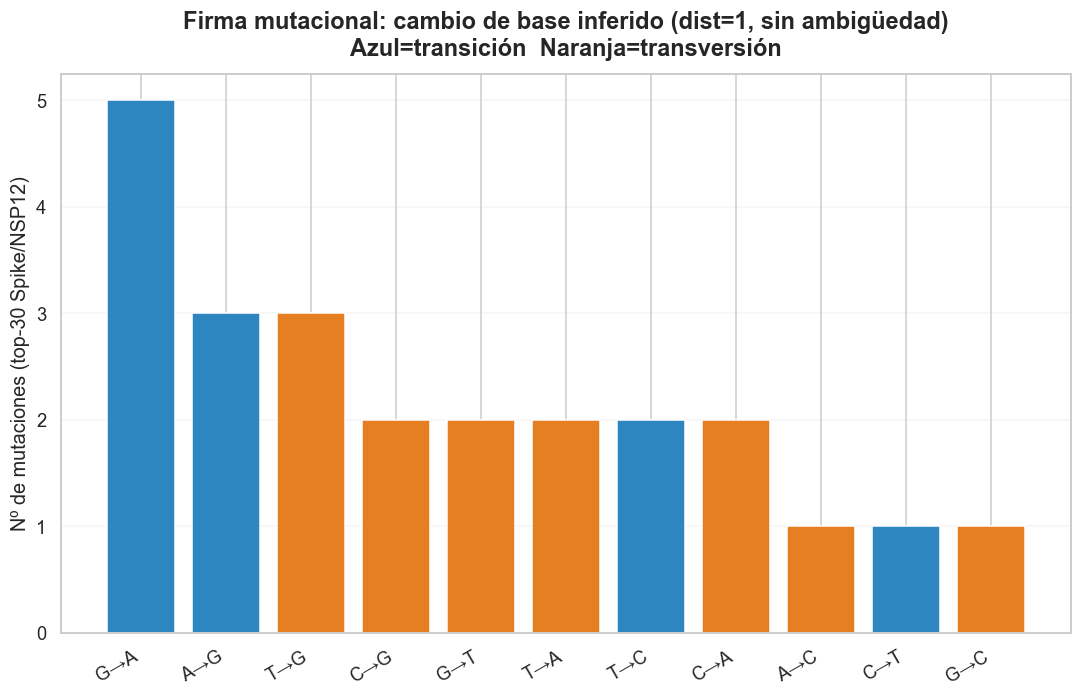

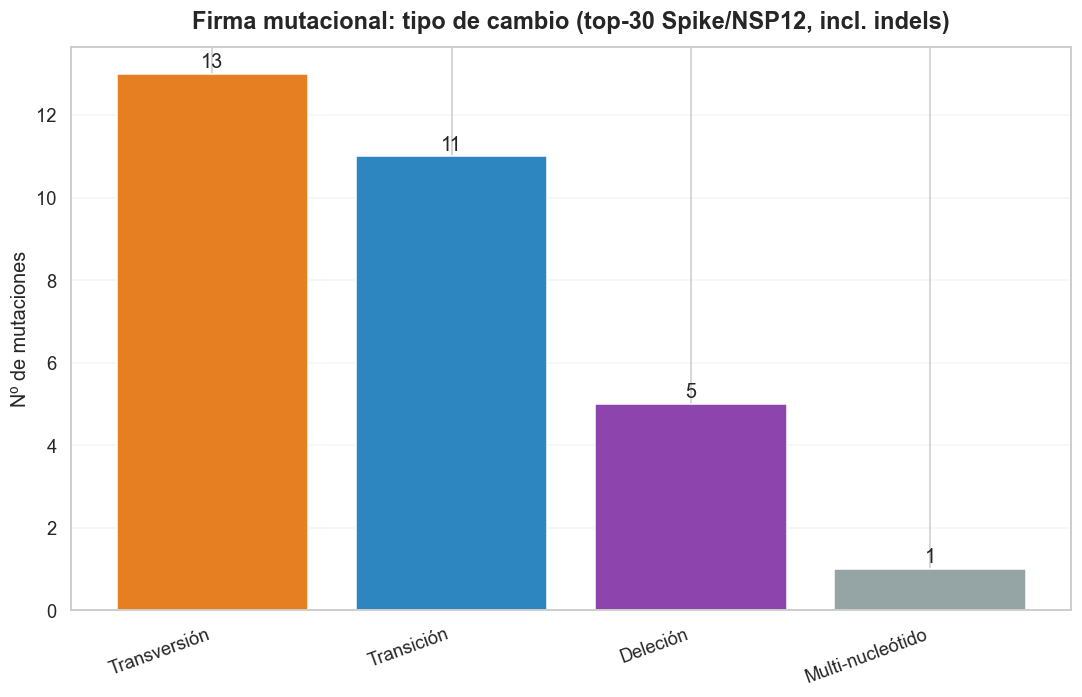

Figuras guardadas: 7_1a_firma_cambio_base.png, 7_1b_firma_tipo_cambio.png

INTERPRETACIÓN:
  Transiciones : 11  |  Transversiones: 13  |  Multi-nucleótido: 1  |  Deleciones: 5  |  Inserciones: 0
  C→T (compatible con edición APOBEC/deaminasas del huésped): 1
  G→T (compatible con daño oxidativo, ROS)                  : 2
  Mutaciones con más de una ruta de nucleótido igualmente parsimoniosa: 2

  Las transversiones superan a las transiciones en este subconjunto de
  mutaciones top-30 — no sigue el patrón "de fondo" esperado en SARS-CoV-2
  (predominio de transiciones C→U). El test de selección de 2.8d evalúa
  si esto se debe a que la selección positiva favorece específicamente
  a las transversiones de mayor impacto funcional, no a un artefacto.

  Las 5 deleciones y 0 inserciones del top-30 no se descartan:
  son un mecanismo de escape inmune bien documentado en el NTD de Spike
  (ej. H69del, Y144del), distinto de la sustitución puntual pero igual de
  relevante para la vigilancia.


In [22]:
# ── Celda 2.8c — Visualización e interpretación de la firma mutacional ───────
_dist1 = df_mut_signature_ok[df_mut_signature_ok['dist'] == 1].copy()

# Panel A: frecuencia de cada cambio de base concreto (solo dist=1, inequívocos)
fig, ax = plt.subplots(figsize=(10, 6.5))
_counts_base = _dist1['cambio_base'].value_counts()
_trans_set   = {'A→G','G→A','C→T','T→C'}
_colors_base = ['#2E86C1' if b in _trans_set else '#E67E22' for b in _counts_base.index]
ax.bar(_counts_base.index, _counts_base.values, color=_colors_base, edgecolor='white')
ax.set_ylabel('Nº de mutaciones (top-30 Spike/NSP12)', fontsize=13)
ax.set_title('Firma mutacional: cambio de base inferido (dist=1, sin ambigüedad)\nAzul=transición  Naranja=transversión',
              fontsize=15.5, fontweight='bold', pad=12)
ax.tick_params(axis='both', labelsize=12)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig(OUTDIR / '7_1a_firma_cambio_base.png', dpi=150, bbox_inches='tight')
plt.show()

# Panel B: transición / transversión / multi-nt / deleción / inserción
fig, ax = plt.subplots(figsize=(10, 6.5))
_counts_tipo = df_mut_signature_ok['tipo'].value_counts()
_pal_tipo = {'Transición': '#2E86C1', 'Transversión': '#E67E22',
             'Multi-nucleótido': '#95A5A6', 'Deleción': '#8E44AD', 'Inserción': '#16A085'}
bars = ax.bar(_counts_tipo.index, _counts_tipo.values,
              color=[_pal_tipo.get(t, '#888888') for t in _counts_tipo.index],
              edgecolor='white')
for bar, v in zip(bars, _counts_tipo.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.15, str(v), ha='center', fontsize=13)
ax.set_ylabel('Nº de mutaciones', fontsize=13)
ax.set_title('Firma mutacional: tipo de cambio (top-30 Spike/NSP12, incl. indels)',
             fontsize=15.5, fontweight='bold', pad=12)
ax.tick_params(axis='both', labelsize=12)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig(OUTDIR / '7_1b_firma_tipo_cambio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figuras guardadas: 7_1a_firma_cambio_base.png, 7_1b_firma_tipo_cambio.png')

# ── Interpretación ────────────────────────────────────────────────────────
_n_ct   = int((_dist1['cambio_base'] == 'C→T').sum())
_n_gt   = int((_dist1['cambio_base'] == 'G→T').sum())
_n_tr   = int((df_mut_signature_ok['tipo'] == 'Transición').sum())
_n_tv   = int((df_mut_signature_ok['tipo'] == 'Transversión').sum())
_n_del  = int((df_mut_signature_ok['tipo'] == 'Deleción').sum())
_n_ins  = int((df_mut_signature_ok['tipo'] == 'Inserción').sum())
_n_amb  = int(df_mut_signature_ok['ambiguo'].sum())

print()
print('INTERPRETACIÓN:')
print(f'  Transiciones : {_n_tr}  |  Transversiones: {_n_tv}  |  '
      f'Multi-nucleótido: {int((df_mut_signature_ok["tipo"]=="Multi-nucleótido").sum())}  |  '
      f'Deleciones: {_n_del}  |  Inserciones: {_n_ins}')
print(f'  C→T (compatible con edición APOBEC/deaminasas del huésped): {_n_ct}')
print(f'  G→T (compatible con daño oxidativo, ROS)                  : {_n_gt}')
print(f'  Mutaciones con más de una ruta de nucleótido igualmente parsimoniosa: {_n_amb}')
print()
if _n_tr >= _n_tv:
    print('  El predominio de transiciones sobre transversiones en las mutaciones')
    print('  Spike/NSP12 de mayor varianza es consistente con el patrón de')
    print('  mutación descrito para SARS-CoV-2 en la literatura (sesgo C→U marcado,')
    print('  atribuido a la edición por deaminasas de tipo APOBEC del huésped),')
    print('  más que con un proceso de mutación puramente aleatorio.')
else:
    print('  Las transversiones superan a las transiciones en este subconjunto de')
    print('  mutaciones top-30 — no sigue el patrón "de fondo" esperado en SARS-CoV-2')
    print('  (predominio de transiciones C→U). El test de selección de 2.8d evalúa')
    print('  si esto se debe a que la selección positiva favorece específicamente')
    print('  a las transversiones de mayor impacto funcional, no a un artefacto.')
if _n_del + _n_ins > 0:
    print()
    print(f'  Las {_n_del} deleciones y {_n_ins} inserciones del top-30 no se descartan:')
    print('  son un mecanismo de escape inmune bien documentado en el NTD de Spike')
    print('  (ej. H69del, Y144del), distinto de la sustitución puntual pero igual de')
    print('  relevante para la vigilancia.')

Universo de mutaciones Spike/NSP12 con señal real: 637
Mutaciones con firma inferida y válida: 631 (de 637)
  Llegaron a dominar (pico histórico >= 10%): 126
  Nunca dominaron                                    : 505

Tabla de contingencia (solo sustituciones dist=1, sin ambigüedad):


tipo,Transición,Transversión
domino,,
False,206,211
True,55,51



Test de Fisher exacto: p=0.6648

% transición vs transversión, por grupo:


tipo,Transición,Transversión
domino,,
False,49.4,50.6
True,51.9,48.1


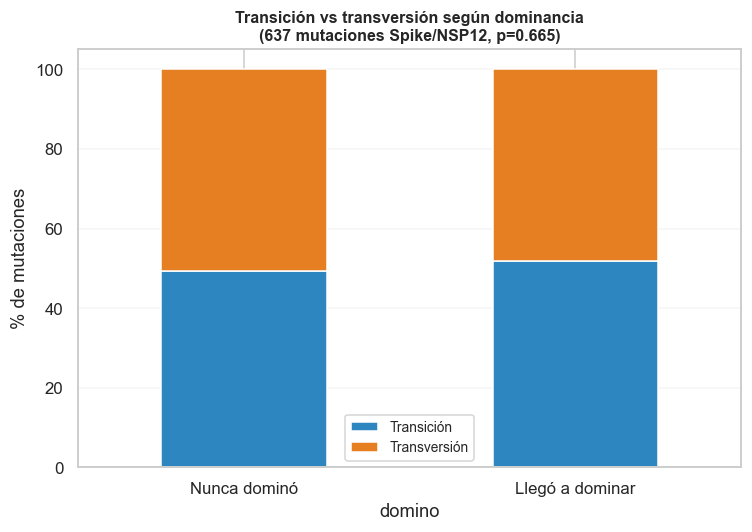

Figura guardada: 2_8d_test_seleccion.png

INTERPRETACIÓN: no hay diferencia significativa (p>=0.05) en el patrón
transición/transversión entre mutaciones dominantes y no dominantes.
Con estos datos, el tipo de sustitución de base por sí solo no distingue
qué mutaciones triunfan — el patrón observado en el top-30 (2.8c) refleja
probablemente el mecanismo mutacional de fondo, no selección diferencial
por tipo de base.


In [23]:
# ── Celda 2.8d — Test de selección: firma mutacional vs dominancia ──────────
# En vez de describir solo el top-30, se analizan TODAS las mutaciones
# Spike/NSP12 con señal real (no solo las de mayor varianza) y se compara el
# patrón transición/transversión entre las que llegaron a dominar y las que
# no. Umbral local (no se importa DOMINANT_THR_SPNSP de 3.1, que se define
# después): mismo valor, documentado aquí para no depender del orden de
# ejecución de los módulos.
_SIG_DOM_THR = 0.10

_sp_nsp_pool = [c for c in freq_matrix_mut.columns
                if c.startswith('Spike_') or c.startswith('NSP12_')]
print(f'Universo de mutaciones Spike/NSP12 con señal real: {len(_sp_nsp_pool)}')

_rows_pool = [infer_nt_change(m) for m in _sp_nsp_pool]
_rows_pool = [r for r in _rows_pool if r is not None and r['valido']]
df_mut_signature_full = pd.DataFrame(_rows_pool)
df_mut_signature_full['domino'] = df_mut_signature_full['mutacion'].map(
    lambda m: bool(max_freq_ever.get(m, 0) >= _SIG_DOM_THR))

print(f'Mutaciones con firma inferida y válida: {len(df_mut_signature_full)} '
      f'(de {len(_sp_nsp_pool)})')
print(f'  Llegaron a dominar (pico histórico >= {_SIG_DOM_THR*100:.0f}%): '
      f'{int(df_mut_signature_full["domino"].sum())}')
print(f'  Nunca dominaron                                    : '
      f'{int((~df_mut_signature_full["domino"]).sum())}')

_sub = df_mut_signature_full[df_mut_signature_full['tipo'].isin(['Transición', 'Transversión'])]
_tab = pd.crosstab(_sub['domino'], _sub['tipo'])
print()
print('Tabla de contingencia (solo sustituciones dist=1, sin ambigüedad):')
display(_tab)

if _tab.shape == (2, 2) and (_tab.values > 0).all():
    _odds, _p = fisher_exact(_tab.values)
    _test_name = 'Fisher exacto'
else:
    _chi2, _p, _, _ = chi2_contingency(_tab.values)
    _test_name = 'Chi-cuadrado'
print(f'\nTest de {_test_name}: p={_p:.4f}')

_ct_pct = (_sub.groupby('domino')['tipo']
           .value_counts(normalize=True).unstack() * 100)
print('\n% transición vs transversión, por grupo:')
display(_ct_pct.round(1))

fig, ax = plt.subplots(figsize=(7, 5))
_ct_pct.plot(kind='bar', stacked=True, ax=ax,
             color=['#2E86C1' if c == 'Transición' else '#E67E22' for c in _ct_pct.columns])
ax.set_xticklabels(['Nunca dominó', 'Llegó a dominar'], rotation=0)
ax.set_ylabel('% de mutaciones')
ax.set_title(f'Transición vs transversión según dominancia\n({len(_sp_nsp_pool)} mutaciones Spike/NSP12, p={_p:.3f})',
             fontsize=10.5, fontweight='bold')
ax.legend(title=None, fontsize=9)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig(OUTDIR / '2_8d_test_seleccion.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figura guardada: 2_8d_test_seleccion.png')

print()
if _p < 0.05:
    print('INTERPRETACIÓN: la proporción de transiciones/transversiones difiere')
    print('significativamente (p<0.05) entre mutaciones que llegaron a dominar y')
    print('las que no — evidencia de que el patrón de sustitución de base no es')
    print('neutral respecto al éxito evolutivo de la mutación: el tipo de cambio')
    print('bioquímico está correlacionado con la probabilidad de fijación, no solo')
    print('con el mecanismo mutacional de fondo (ej. APOBEC).')
else:
    print('INTERPRETACIÓN: no hay diferencia significativa (p>=0.05) en el patrón')
    print('transición/transversión entre mutaciones dominantes y no dominantes.')
    print('Con estos datos, el tipo de sustitución de base por sí solo no distingue')
    print('qué mutaciones triunfan — el patrón observado en el top-30 (2.8c) refleja')
    print('probablemente el mecanismo mutacional de fondo, no selección diferencial')
    print('por tipo de base.')

### 2.9 — Correlación entre mutaciones: ¿tiene sentido que vayan juntas?

Algunas mutaciones suben y bajan de frecuencia global casi al unísono a lo
largo del tiempo. Esto puede deberse a dos motivos muy distintos:

1. **Ligamiento genético trivial**: las mutaciones definen la misma familia
   Pango — cuando esa familia crece, todas sus mutaciones "suben juntas"
   porque literalmente van en el mismo genoma. No es una señal biológica
   interesante por sí sola, es una consecuencia de cómo se hereda el genoma.
2. **Convergencia evolutiva / epistasis real**: las mutaciones aparecen en
   **familias distintas e independientes** pero sus trayectorias globales
   están correlacionadas porque cada familia, por separado, las adquirió bajo
   la misma presión selectiva. Esto sí es una señal biológica relevante —
   es el mismo fenómeno que en 7.3 identificamos con `n_families` (número de
   linajes independientes que adquieren la misma mutación).

Esta sección calcula la correlación de las trayectorias temporales de
frecuencia entre las mutaciones top Spike+NSP12 y clasifica cada par de alta
correlación en uno de los dos grupos anteriores, cruzando contra el perfil
mutacional por familia (`df_family_mut_freq`, ya calculado en 2.2).

**Coocurrencia real (2.9b):** para los pares dentro de `TARGET_COOC_MUTS`
(66 mutaciones "hallmark" desde la ronda 3, antes 39; 1.2) el streaming (1.3)
guarda cuántas secuencias llevan realmente ambas mutaciones a la vez, no
solo su correlación de trayectorias agregadas.

**Ronda 3 — de 2 a 4 categorías:** la primera versión solo distinguía
"misma familia" de "familias distintas", y dentro de esta última, alta o
baja coocurrencia real. Eso dejaba un caso sin resolver: pares con
coocurrencia real muy alta (>90%) pero Jaccard de familias muy bajo — ¿es
convergencia real o una mutación B que aparece *sobre* el trasfondo de A en
un subconjunto de sus linajes (contención/jerarquía, no independencia)? Para
distinguirlo, 2.9b calcula ahora la coocurrencia en **ambas direcciones**
(P(A|B) y P(B|A)) y el **coeficiente de solapamiento** de Szymkiewicz-Simpson
(`|F_A∩F_B| / min(|F_A|,|F_B|)`), que a diferencia del Jaccard no penaliza
que un conjunto de familias sea mucho más grande que el otro — así detecta
contención aunque el Jaccard sea bajo. Los pares "familias distintas" quedan
en 4 categorías: ligamiento por contención/jerarquía, convergencia
independiente confirmada, probable artefacto de tendencia macro, o sin dato
real disponible.

Mutaciones incluidas en el análisis de correlación: 40 (de 40, se excluyen las de varianza nula en train)


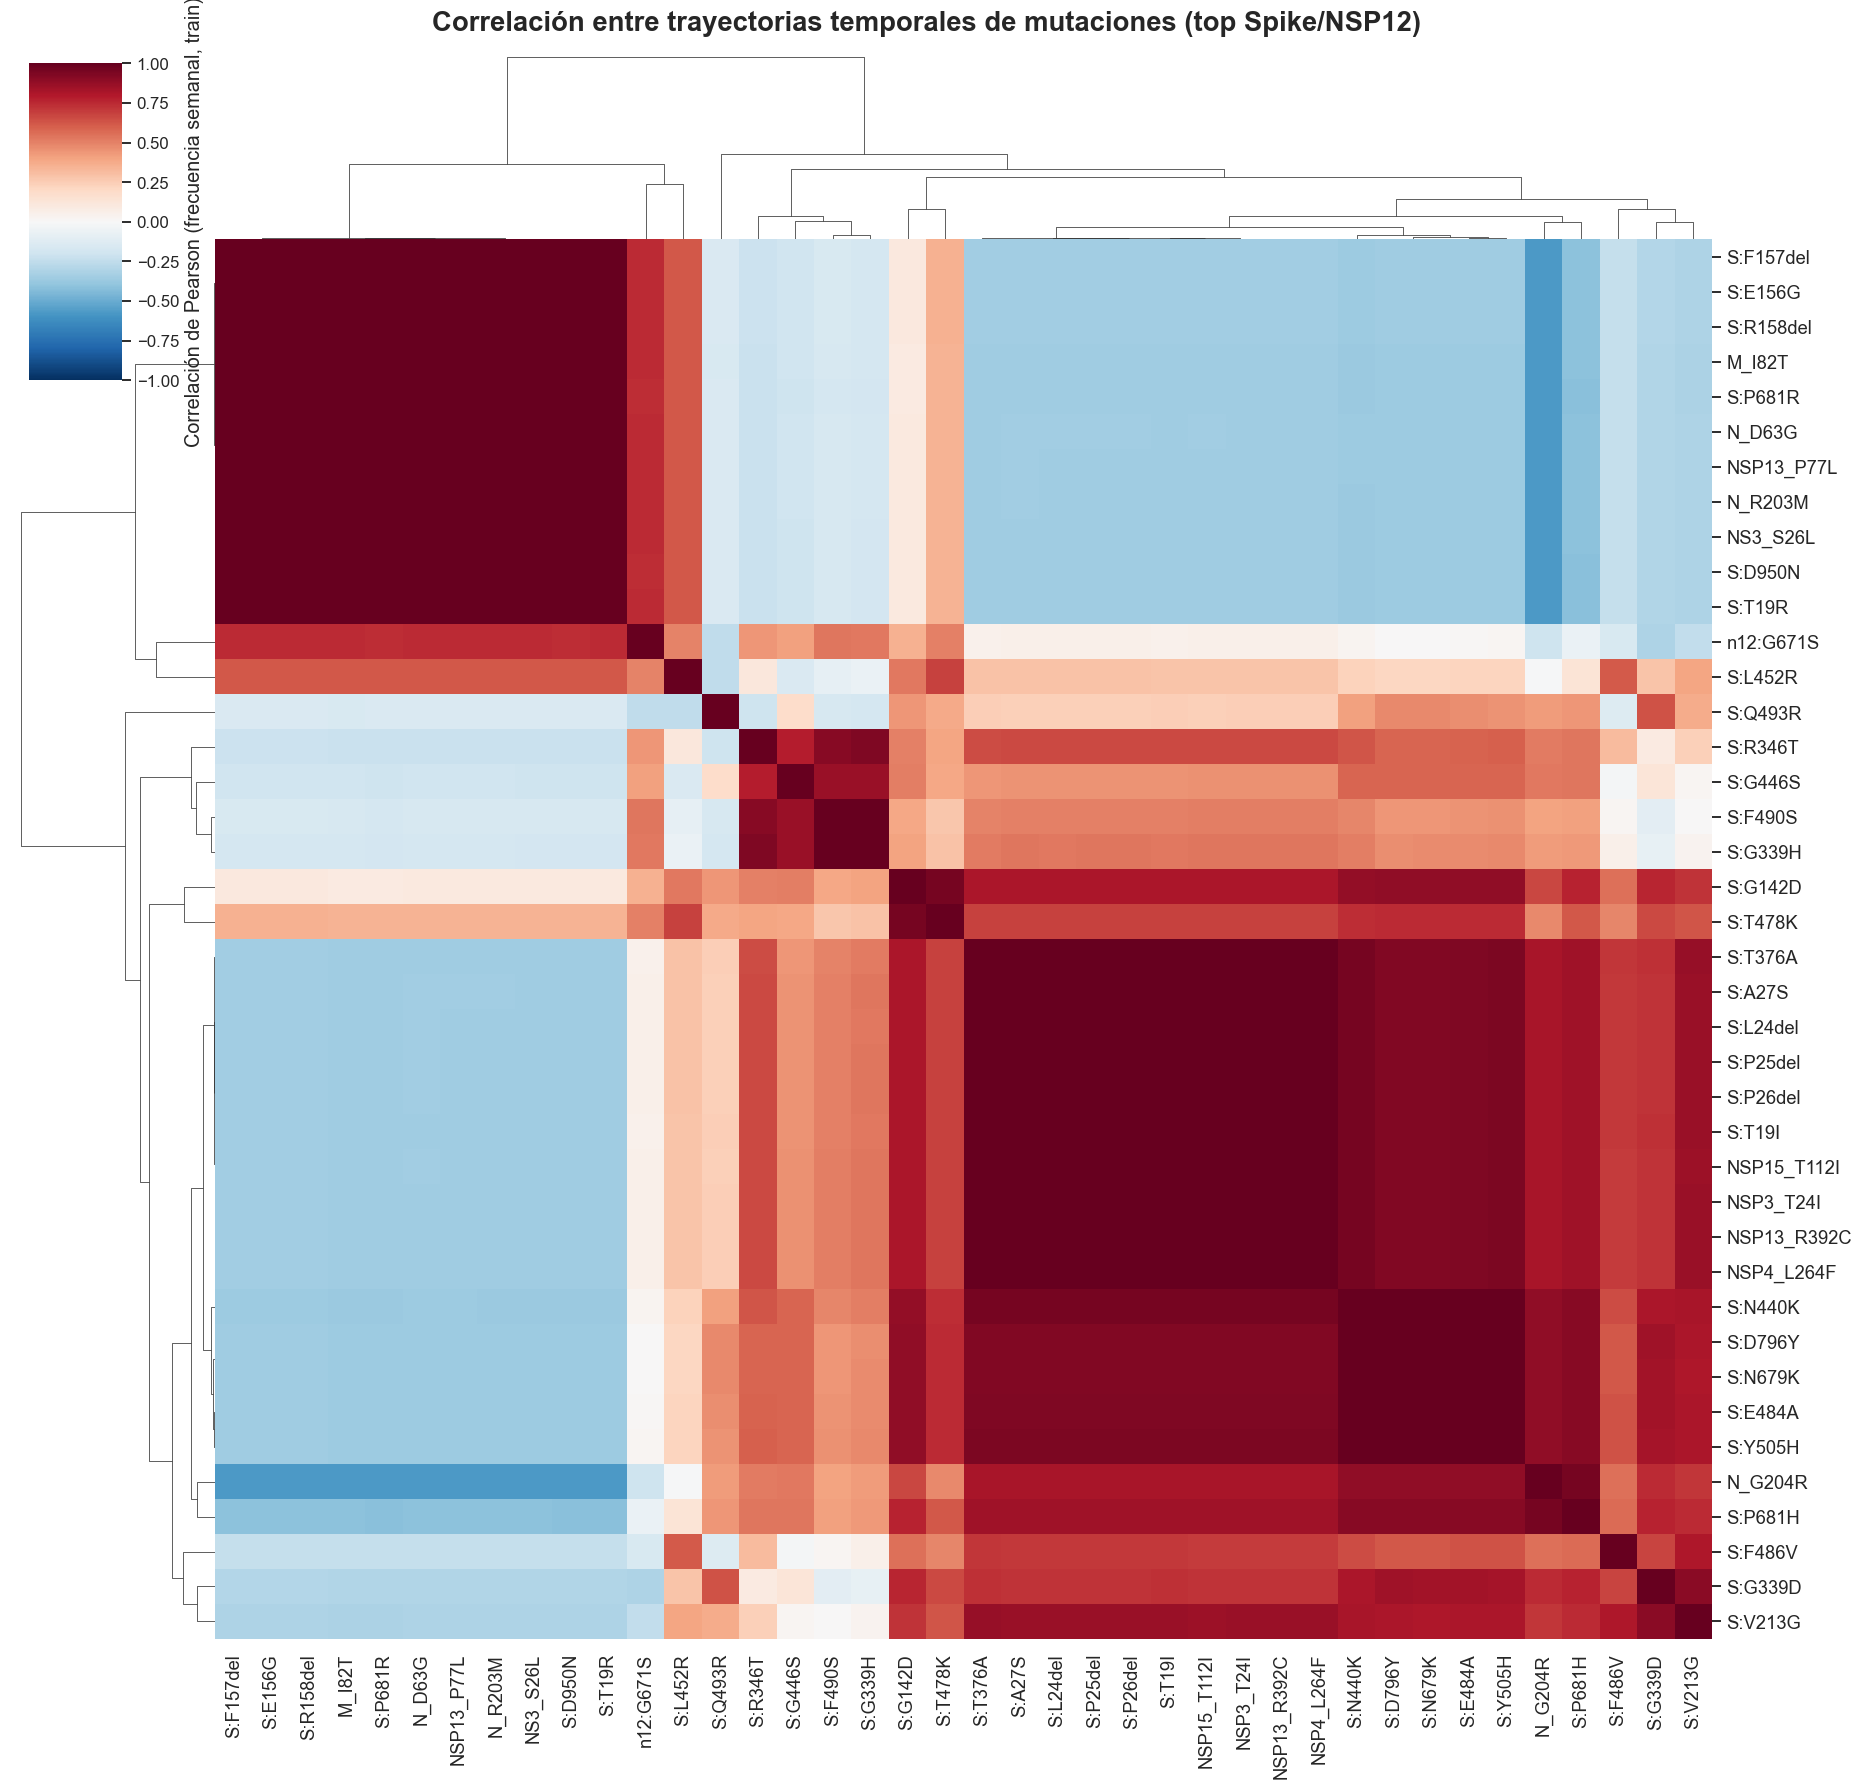

Figura guardada: 7_2_correlacion_mutaciones.png

Pares con |r| >= 0.8: 234


,mut_1,mut_2,r
0,Spike_P25del,Spike_P26del,1.000000
1,Spike_E156G,Spike_R158del,1.000000
2,Spike_L24del,Spike_P26del,0.999999
3,Spike_L24del,Spike_P25del,0.999999
4,Spike_A27S,Spike_P25del,0.999994
5,Spike_A27S,Spike_P26del,0.999994
6,Spike_A27S,Spike_L24del,0.999993
7,Spike_F157del,Spike_R158del,0.999990
8,Spike_E156G,Spike_F157del,0.999989
9,NSP3_T24I,NSP4_L264F,0.999987


In [24]:
# ── Celda 2.9a — Matriz de correlación entre trayectorias de mutaciones ──────
corr_muts_all = sorted(set(top30_muts) | set(top30_muts_spnsp))
corr_muts     = [m for m in corr_muts_all if freq_mat_train[m].std() > 0]
print(f'Mutaciones incluidas en el análisis de correlación: {len(corr_muts)} '
      f'(de {len(corr_muts_all)}, se excluyen las de varianza nula en train)')

corr_mat = freq_mat_train[corr_muts].corr()

_clean_labels = {m: m.replace('Spike_', 'S:').replace('NSP12_', 'n12:') for m in corr_muts}
corr_mat_plot = corr_mat.rename(index=_clean_labels, columns=_clean_labels)

g = sns.clustermap(corr_mat_plot, cmap='RdBu_r', vmin=-1, vmax=1, center=0,
                    figsize=(17, 16), dendrogram_ratio=0.12,
                    cbar_kws={'label': 'Correlación de Pearson (frecuencia semanal, train)'})
g.ax_heatmap.tick_params(axis='both', labelsize=12)
g.ax_heatmap.set_xlabel('')
g.ax_heatmap.set_ylabel('')
g.cax.tick_params(labelsize=11)
g.cax.yaxis.label.set_size(13)
g.fig.suptitle('Correlación entre trayectorias temporales de mutaciones (top Spike/NSP12)',
               fontsize=18, fontweight='bold', y=1.01)
g.savefig(OUTDIR / '7_2_correlacion_mutaciones.png', dpi=160, bbox_inches='tight')
plt.show()
print('Figura guardada: 7_2_correlacion_mutaciones.png')

# ── Pares de alta correlación (excluyendo la diagonal) ──────────────────────
_pairs = []
for i, m1 in enumerate(corr_muts):
    for m2 in corr_muts[i+1:]:
        r = corr_mat.loc[m1, m2]
        if abs(r) >= 0.8:
            _pairs.append((m1, m2, r))
df_high_corr = pd.DataFrame(_pairs, columns=['mut_1', 'mut_2', 'r']).sort_values(
    'r', ascending=False).reset_index(drop=True)
print(f'\nPares con |r| >= 0.8: {len(df_high_corr)}')
display(df_high_corr.head(20))

CLASIFICACIÓN DE LOS PARES DE ALTA CORRELACIÓN (|r| >= 0.8):
tipo_par
Misma familia (ligamiento)                     193
Familias distintas (convergencia potencial)     41

Pares con dato real de coocurrencia (ambas mutaciones en TARGET_COOC_MUTS, 66 mutaciones): 116 / 234

Sub-clasificación de los pares "familias distintas":
subtipo
Sin dato real (no confirmable)                                      22
Contención/jerarquía (una mutación es refinamiento de la otra)      15
Convergencia independiente (ligamiento real, familias distintas)     4


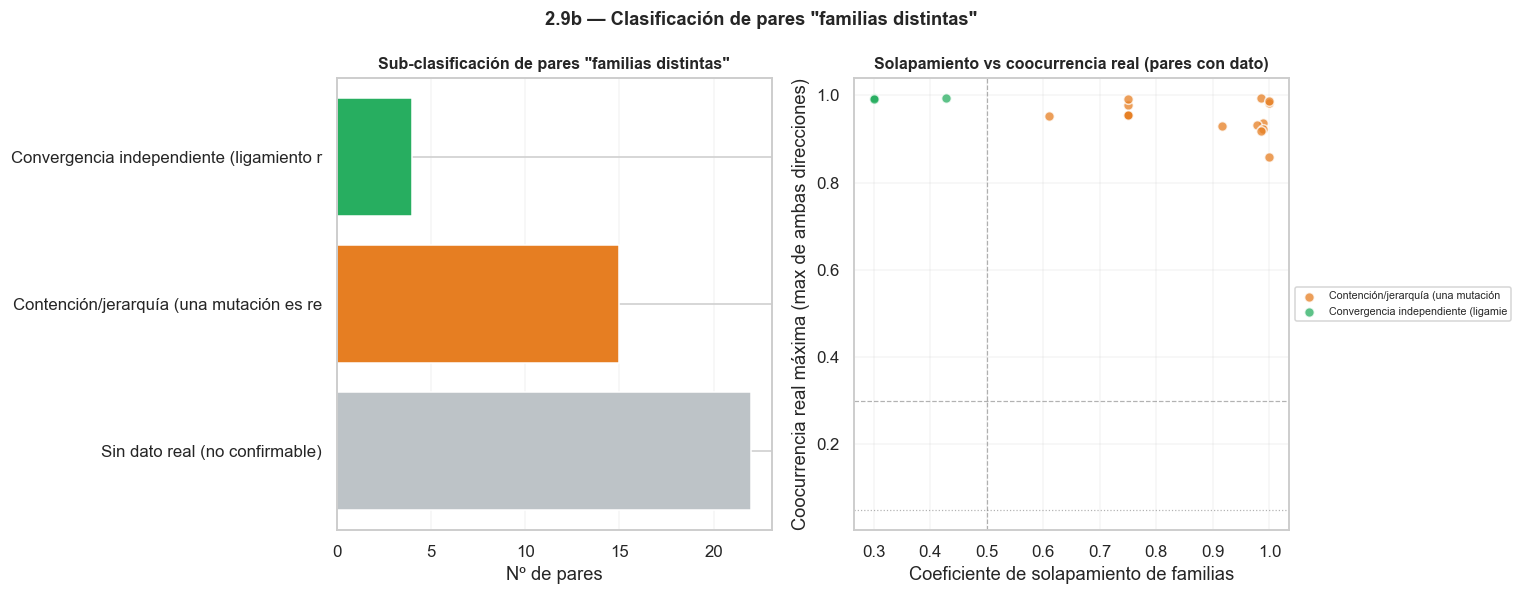

Figura guardada: 2_9b_subclasificacion.png

Ejemplos de "convergencia potencial" (familias distintas, misma trayectoria global):


,mut_1,mut_2,r,jaccard,overlap_coef,cooc_1_a_2,cooc_2_a_1,subtipo
11,NS3_S26L,Spike_P681R,0.999981,0.037594,0.625000,NaN,NaN,Sin dato real (no confirmable)
17,NS3_S26L,N_R203M,0.999964,0.153846,0.285714,NaN,NaN,Sin dato real (no confirmable)
19,Spike_D950N,Spike_T19R,0.999959,0.375000,0.750000,0.977387,0.948295,Contención/jerarquía (una mutación es refinami...
20,N_R203M,Spike_T19R,0.999957,0.400000,0.571429,NaN,NaN,Sin dato real (no confirmable)
21,NS3_S26L,NSP13_P77L,0.999955,0.333333,0.625000,NaN,NaN,Sin dato real (no confirmable)
22,N_D63G,Spike_T19R,0.999953,0.400000,0.571429,NaN,NaN,Sin dato real (no confirmable)
23,NSP13_P77L,Spike_D950N,0.999948,0.230769,0.750000,NaN,NaN,Sin dato real (no confirmable)
25,N_R203M,Spike_P681R,0.999946,0.014815,0.285714,NaN,NaN,Sin dato real (no confirmable)
26,NS3_S26L,N_D63G,0.999946,0.153846,0.285714,NaN,NaN,Sin dato real (no confirmable)
27,NS3_S26L,Spike_D950N,0.999942,0.333333,0.750000,NaN,NaN,Sin dato real (no confirmable)



Ejemplos de "ligamiento" (misma familia, resultado trivial esperado):


,mut_1,mut_2,r,jaccard,cooc_real
0,Spike_P25del,Spike_P26del,1.000000,1.000000,0.999963
1,Spike_E156G,Spike_R158del,1.000000,1.000000,0.999738
2,Spike_L24del,Spike_P26del,0.999999,1.000000,0.999918
3,Spike_L24del,Spike_P25del,0.999999,1.000000,0.999947
4,Spike_A27S,Spike_P25del,0.999994,0.997175,0.998957
5,Spike_A27S,Spike_P26del,0.999994,0.997175,0.998819
6,Spike_A27S,Spike_L24del,0.999993,0.997175,0.999682
7,Spike_F157del,Spike_R158del,0.999990,1.000000,0.997870
8,Spike_E156G,Spike_F157del,0.999989,1.000000,0.998733
9,NSP3_T24I,NSP4_L264F,0.999987,0.945869,NaN



INTERPRETACIÓN:
  193 pares están ligados dentro de la misma familia — resultado
  esperado y no informativo por sí solo: son la misma constelación de
  mutaciones heredada en bloque.
  41 pares aparecen en familias Pango distintas e independientes
  pero correlacionan globalmente >= 0.8. De esos:
    4 tienen coocurrencia real bidireccional alta Y
    familias con bajo solapamiento — el caso genuinamente interesante:
    combinación real bajo selección compartida entre linajes independientes.
    15 tienen alto solapamiento de familias pese al Jaccard
    bajo — más compatible con que una mutación sea un refinamiento posterior
    sobre el trasfondo de la otra (jerarquía/anidamiento), no convergencia
    independiente.
    0 tienen coocurrencia real casi nula — la correlación de
    trayectorias es casi con seguridad una tendencia macro compartida de la
    pandemia (autocorrelación temporal), no ligamiento ni epistasis real.
    22 no tienen dato real (ninguna de las dos mutaciones 

,mut_1,mut_2,r,jaccard,overlap_coef,cooc_1_a_2,cooc_2_a_1
29,Spike_P681R,Spike_T19R,0.999938,0.022388,0.428571,0.974361,0.992864
92,Spike_P681R,Spike_R158del,0.999525,0.021898,0.300000,0.906372,0.992773
93,Spike_E156G,Spike_P681R,0.999521,0.021898,0.300000,0.993069,0.904842
94,Spike_F157del,Spike_P681R,0.999479,0.021898,0.300000,0.992457,0.909157


In [25]:
# ── Celda 2.9b — ¿Ligamiento dentro de una familia o convergencia real? ──────
FAM_CHAR_THR = 0.5  # una familia "lleva" la mutación si su frecuencia within-family >= 50%

def characteristic_families(mut):
    col = f'mut_{mut}'
    if col not in df_family_mut_freq.columns:
        return set()
    agg = df_family_mut_freq.groupby('lineage_family')[col].max()
    return set(agg[agg >= FAM_CHAR_THR].index)

fam_sets = {m: characteristic_families(m) for m in corr_muts}

def classify_pair(m1, m2):
    f1, f2 = fam_sets.get(m1, set()), fam_sets.get(m2, set())
    if not f1 or not f2:
        return 'Sin familia caracterizada', np.nan
    jac = len(f1 & f2) / len(f1 | f2)
    tipo = 'Misma familia (ligamiento)' if jac >= 0.5 else 'Familias distintas (convergencia potencial)'
    return tipo, jac

_clasif = df_high_corr.apply(lambda row: classify_pair(row['mut_1'], row['mut_2']), axis=1)
df_high_corr['tipo_par'] = [c[0] for c in _clasif]
df_high_corr['jaccard']  = [c[1] for c in _clasif]

# ── Coocurrencia real por secuencia — ronda 3: ahora BIDIRECCIONAL. Con un
# TARGET_COOC_MUTS más amplio (66 mutaciones, antes 39) hay más pares con
# dato real. P(A|B) y P(B|A) pueden diferir mucho si un conjunto de familias
# es subconjunto del otro (ver coeficiente de solapamiento más abajo) ────────
_train_weeks_pair = [wk for wk in mut_pair_week_counts if pd.Timestamp(wk) < CUTOFF_WEEK_ML]

def _cooc_directional(m_from, m_to):
    """P(m_to coocurre en la misma secuencia | aparece m_from), agregada en train."""
    if m_from not in TARGET_COOC_MUTS or m_to not in TARGET_COOC_MUTS:
        return np.nan
    pair = frozenset((m_from, m_to))
    n_pair = sum(mut_pair_week_counts[wk].get(pair, 0) for wk in _train_weeks_pair)
    n_from = sum(mut_week_counts.get(wk, {}).get(m_from, 0) for wk in _train_weeks_pair)
    return n_pair / n_from if n_from > 0 else np.nan

def overlap_coefficient(m1, m2):
    """Szymkiewicz-Simpson: |F1 ∩ F2| / min(|F1|,|F2|). A diferencia del
    Jaccard, no penaliza que un conjunto sea mucho más grande que el otro —
    detecta contención (F2 ⊆ F1) aunque Jaccard sea bajo."""
    f1, f2 = fam_sets.get(m1, set()), fam_sets.get(m2, set())
    if not f1 or not f2:
        return np.nan
    return len(f1 & f2) / min(len(f1), len(f2))

df_high_corr['cooc_1_a_2'] = df_high_corr.apply(
    lambda row: _cooc_directional(row['mut_1'], row['mut_2']), axis=1)
df_high_corr['cooc_2_a_1'] = df_high_corr.apply(
    lambda row: _cooc_directional(row['mut_2'], row['mut_1']), axis=1)
df_high_corr['overlap_coef'] = df_high_corr.apply(
    lambda row: overlap_coefficient(row['mut_1'], row['mut_2']), axis=1)
# cooc_real (compatibilidad con la ronda 2): la dirección más informativa
df_high_corr['cooc_real'] = df_high_corr[['cooc_1_a_2', 'cooc_2_a_1']].max(axis=1)

print('CLASIFICACIÓN DE LOS PARES DE ALTA CORRELACIÓN (|r| >= 0.8):')
print(df_high_corr['tipo_par'].value_counts().to_string())
_n_con_dato_real = df_high_corr['cooc_real'].notna().sum()
print(f'\nPares con dato real de coocurrencia (ambas mutaciones en '
      f'TARGET_COOC_MUTS, {len(TARGET_COOC_MUTS)} mutaciones): '
      f'{_n_con_dato_real} / {len(df_high_corr)}')

# ── Sub-clasificación de "familias distintas" en 3 categorías ───────────────
# usando coocurrencia bidireccional + coeficiente de solapamiento, en vez de
# solo Jaccard, para separar contención (B es un refinamiento posterior
# sobre A) de convergencia independiente genuina.
OVERLAP_CONTAINMENT_THR = 0.5
COOC_REAL_THR           = 0.30
COOC_ARTIFACT_THR       = 0.05

def sub_classify(row):
    if row['tipo_par'] != 'Familias distintas (convergencia potencial)':
        return np.nan
    if pd.isna(row['cooc_real']):
        return 'Sin dato real (no confirmable)'
    if row['cooc_real'] < COOC_ARTIFACT_THR:
        return 'Probable artefacto (tendencia macro, sin coocurrencia real)'
    if pd.notna(row['overlap_coef']) and row['overlap_coef'] >= OVERLAP_CONTAINMENT_THR:
        return 'Contención/jerarquía (una mutación es refinamiento de la otra)'
    if row['cooc_real'] >= COOC_REAL_THR:
        return 'Convergencia independiente (ligamiento real, familias distintas)'
    return 'Ambiguo (revisar caso a caso)'

df_high_corr['subtipo'] = df_high_corr.apply(sub_classify, axis=1)

_conv = df_high_corr[df_high_corr['tipo_par'].str.startswith('Familias distintas')].sort_values(
    'r', ascending=False)
_link = df_high_corr[df_high_corr['tipo_par'] == 'Misma familia (ligamiento)'].sort_values(
    'r', ascending=False)

print('\nSub-clasificación de los pares "familias distintas":')
print(_conv['subtipo'].value_counts().to_string())

_subtype_pal = {
    'Convergencia independiente (ligamiento real, familias distintas)': '#27AE60',
    'Contención/jerarquía (una mutación es refinamiento de la otra)':    '#E67E22',
    'Probable artefacto (tendencia macro, sin coocurrencia real)':       '#95A5A6',
    'Sin dato real (no confirmable)':                                   '#BDC3C7',
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
_counts_sub = _conv['subtipo'].value_counts()
ax.barh([s[:40] for s in _counts_sub.index],
        _counts_sub.values,
        color=[_subtype_pal.get(s, '#888888') for s in _counts_sub.index],
        edgecolor='white')
ax.set_xlabel('Nº de pares')
ax.set_title('Sub-clasificación de pares "familias distintas"', fontweight='bold', fontsize=10.5)
ax.grid(True, alpha=0.2, axis='x')

ax = axes[1]
_plot_conv = _conv.dropna(subset=['overlap_coef', 'cooc_real'])
for subtipo, grp in _plot_conv.groupby('subtipo'):
    ax.scatter(grp['overlap_coef'], grp['cooc_real'], label=subtipo[:35],
               color=_subtype_pal.get(subtipo, '#888888'), alpha=0.75, s=40, edgecolors='white')
ax.axvline(OVERLAP_CONTAINMENT_THR, color='gray', ls='--', lw=0.8, alpha=0.6)
ax.axhline(COOC_REAL_THR, color='gray', ls='--', lw=0.8, alpha=0.6)
ax.axhline(COOC_ARTIFACT_THR, color='gray', ls=':', lw=0.8, alpha=0.6)
ax.set_xlabel('Coeficiente de solapamiento de familias')
ax.set_ylabel('Coocurrencia real máxima (max de ambas direcciones)')
ax.set_title('Solapamiento vs coocurrencia real (pares con dato)', fontweight='bold', fontsize=10.5)
ax.legend(fontsize=7, loc='center left', bbox_to_anchor=(1.0, 0.5))
ax.grid(True, alpha=0.2)

plt.suptitle('2.9b — Clasificación de pares "familias distintas"', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / '2_9b_subclasificacion.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figura guardada: 2_9b_subclasificacion.png')

print('\nEjemplos de "convergencia potencial" (familias distintas, misma trayectoria global):')
display(_conv[['mut_1','mut_2','r','jaccard','overlap_coef','cooc_1_a_2','cooc_2_a_1','subtipo']].head(10))
print('\nEjemplos de "ligamiento" (misma familia, resultado trivial esperado):')
display(_link[['mut_1','mut_2','r','jaccard','cooc_real']].head(10))

# ── Interpretación ───────────────────────────────────────────────────────
_convergencia_real = _conv[_conv['subtipo'] == 'Convergencia independiente (ligamiento real, familias distintas)']
_contencion        = _conv[_conv['subtipo'].str.startswith('Contención', na=False)]
_artefacto         = _conv[_conv['subtipo'].str.startswith('Probable artefacto', na=False)]
_sin_dato          = _conv[_conv['subtipo'] == 'Sin dato real (no confirmable)']

print()
print('INTERPRETACIÓN:')
print(f'  {len(_link)} pares están ligados dentro de la misma familia — resultado')
print('  esperado y no informativo por sí solo: son la misma constelación de')
print('  mutaciones heredada en bloque.')
print(f'  {len(_conv)} pares aparecen en familias Pango distintas e independientes')
print('  pero correlacionan globalmente >= 0.8. De esos:')
print(f'    {len(_convergencia_real)} tienen coocurrencia real bidireccional alta Y')
print('    familias con bajo solapamiento — el caso genuinamente interesante:')
print('    combinación real bajo selección compartida entre linajes independientes.')
print(f'    {len(_contencion)} tienen alto solapamiento de familias pese al Jaccard')
print('    bajo — más compatible con que una mutación sea un refinamiento posterior')
print('    sobre el trasfondo de la otra (jerarquía/anidamiento), no convergencia')
print('    independiente.')
print(f'    {len(_artefacto)} tienen coocurrencia real casi nula — la correlación de')
print('    trayectorias es casi con seguridad una tendencia macro compartida de la')
print('    pandemia (autocorrelación temporal), no ligamiento ni epistasis real.')
print(f'    {len(_sin_dato)} no tienen dato real (ninguna de las dos mutaciones está')
print(f'    en TARGET_COOC_MUTS) — quedan como candidatos sin confirmar.')

if len(_convergencia_real) > 0:
    print('\n  Ejemplos de convergencia independiente confirmada:')
    display(_convergencia_real[['mut_1','mut_2','r','jaccard','overlap_coef',
                                 'cooc_1_a_2','cooc_2_a_1']].head(8))

### Resultado del Módulo 2

Las cuatro estructuras de datos están listas para el Feature Engineering.
Las dimensiones exactas aparecen en la salida de la celda 2.3; valores orientativos:

| Variable | Dimensiones (ref.) | Uso |
|---|---|---|
| `df_clade_time` | ~320 sem × ~4.900 sublinajes | Modelo 1 (clados Nextclade) |
| `df_family_time` | ~320 sem × ~450 familias | Modelos 1 y 2 |
| `freq_matrix_mut` | ~320 sem × ~2.200 mutaciones | Feature Engineering |
| `df_family_mut_freq` | sem × familias con datos | Features mutacionales Modelo 2 |

**Hallazgos clave del EDA:**
- El 90% de las secuencias están concentradas en ≈ 20 familias (distribución muy asimétrica)
- JN.1 (24A) alcanzó un pico histórico del ~96% — el clado más dominante de la pandemia
- XFG (25C) es la familia dominante en los datos más recientes (feb 2026)
- NSP12_P323L está prácticamente fijada (>98%) — correctamente descartada del modelo
- La riqueza mutacional varía enormemente: familias ancestrales (B, BA, AY) acumulan >100.000 mutaciones únicas; familias recientes tienen <1.000 (mediana ~340)

El **Módulo 3** construye el dataset de entrenamiento y entrena los modelos predictivos.


## MÓDULO 3 — Feature Engineering y Construcción de Datasets

Transformamos los datos del streaming (Módulos 1–2) en **7 datasets** que cubren
tres niveles de granularidad filogenética, respondiendo todos la misma pregunta:
*¿dominará esta entidad globalmente en el futuro?*

**Target:** ¿Alcanzará la entidad el umbral de dominancia (5% general; 10% para
mutaciones Spike/NSP12) en el futuro? En entrenamiento la etiqueta se **censura en
el corte temporal** para evitar fuga prospectiva: solo es positivo lo que cruzó el
umbral antes de jun-2023. El test conserva la etiqueta real de futuro.

| Dataset | Entidad | Features | Paralelo con |
|---|---|---|---|
| **`df_m1`** | Clado Nextclade (fase <5%) | 15 temporales | — |
| **`df_m1_bio`** | Clado Nextclade | 15 + 6 bio | M2 |
| **`df_m1_spnsp`** | Clado Nextclade | 15 + 6 + 30 mut | M2-SPNSP30 |
| **`df_m2`** | Familia Pango (435) | 15 temp + 6 bio | M1-BIO |
| **`df_m2_spnsp`** | Familia Pango (435) | 15 + 6 + 30 mut | M1-SPNSP |
| **`df_m3_spnsp`** | Mutación Spike/NSP12 | 15 dinámicas + 6 posicionales | — |
| **`df_m3_all`** | Mutación (cualquier proteína) | 15 + 6 + 1 (is_n_protein) | — |

Las features bio y mutacionales de M1-BIO/M1-SPNSP son medias ponderadas
(por n_seqs) de las familias Pango que componen cada clado esa semana.


### 3.1 — Parámetros del horizonte de predicción

Todos los datasets comparten los mismos parámetros base.

**M1 — target de emergencia pura:** las filas donde el clado ya supera el 5%
se eliminan del dataset. M1 solo modela la **fase pre-emergencia**: el clado
está por debajo del 5% y la pregunta es si llegará a dominar.

**M3 — dos datasets complementarios:**
- `df_m3_spnsp`: solo mutaciones Spike + NSP12 — las más relevantes para
  escape inmune y eficacia antiviral
- `df_m3_all`: todas las mutaciones — señal evolutiva amplia

| Parámetro | Valor | Descripción |
|---|---|---|
| `LOOKBACK` | 8 sem | Historia como input de features |
| `HORIZON_MIN` | 4 sem | Buffer mínimo futuro (≥1 mes) |
| `DOMINANT_THR` | 5% | Umbral de "dominancia" global |
| `DOMINANT_THR_MUT` | 5% | Ídem para mutaciones |
| `MIN_SEQS` | 3 | Mínimo de secuencias (captura fase incubación) |
| `CUTOFF_WEEK_ML` | 2023-06-01 | Corte temporal train/test |


In [26]:
# ── Celda 3.1 — Parámetros del sistema predictivo ────────────────────────────
LOOKBACK         = 8      # semanas de historia como features
HORIZON_MIN      = 4      # buffer mínimo: predicción empieza T+4 sem
DOMINANT_THR     = 0.05   # umbral de dominancia: 5% frecuencia global
DOMINANT_THR_MUT  = 0.05   # ídem para M3-ALL (todas las mutaciones)
DOMINANT_THR_SPNSP= 0.10   # threshold más alto para M3-SPNSP (Spike/NSP12 se fijan más)
MIN_SEQS         = 3      # mínimo de secuencias
# CUTOFF_WEEK_ML = pd.Timestamp('2023-06-01')  ← ya definida en 2.2

print('DISEÑO DE DATASETS — 5 datasets, 3 niveles de granularidad')
print('=' * 70)
print()
print('  TARGET: max(freq[T+4..FIN]) >= 5% (sin horizonte fijo)')
print()
print('  NIVEL 1 — Clados Nextclade:')
print('    df_m1       — solo observaciones pre-emergencia (freq_t0 < 5%)')
print('                  target = si el clado llegara a >= 5% en el futuro')
print()
print('  NIVEL 2 — Familias Pango:')
print('    df_m2       — 15 features temporales + 6 features biologicas')
print('    df_m2_spnsp — df_m2 + 30 features mutacionales Spike/NSP12')
print()
print('  NIVEL 3 — Mutaciones individuales:')
print('    df_m3_spnsp — SOLO Spike + NSP12 (+ feature is_ntd)')
print('    df_m3_all   — TODAS las mutaciones (+ feature is_n_protein)')
print()
print(f'  LOOKBACK={LOOKBACK}  HORIZON_MIN={HORIZON_MIN}  ' f'DOMINANT_THR={DOMINANT_THR}  DOMINANT_THR_SPNSP={DOMINANT_THR_SPNSP}  MIN_SEQS={MIN_SEQS}')


DISEÑO DE DATASETS — 5 datasets, 3 niveles de granularidad

  TARGET: max(freq[T+4..FIN]) >= 5% (sin horizonte fijo)

  NIVEL 1 — Clados Nextclade:
    df_m1       — solo observaciones pre-emergencia (freq_t0 < 5%)
                  target = si el clado llegara a >= 5% en el futuro

  NIVEL 2 — Familias Pango:
    df_m2       — 15 features temporales + 6 features biologicas
    df_m2_spnsp — df_m2 + 30 features mutacionales Spike/NSP12

  NIVEL 3 — Mutaciones individuales:
    df_m3_spnsp — SOLO Spike + NSP12 (+ feature is_ntd)
    df_m3_all   — TODAS las mutaciones (+ feature is_n_protein)

  LOOKBACK=8  HORIZON_MIN=4  DOMINANT_THR=0.05  DOMINANT_THR_SPNSP=0.1  MIN_SEQS=3


### 3.2 — Feature engineering: variables temporales

Función reutilizable que genera **15 features temporales** (2 nuevas respecto
al diseño anterior) por cada par (semana, entidad).

Las dos nuevas features son **fitness advantage analogs** — equivalentes
computacionales a lo que Obermeyer et al. (Science 2022) llaman "growth
advantage": la tasa de crecimiento exponencial, mucho más discriminativa que
la pendiente lineal para capturar explosiones de variantes emergentes.

| Feature | Descripción |
|---|---|
| `freq_t0` | Frecuencia global actual |
| `freq_4w_ago`, `freq_2w_ago` | Lags 4 y 2 semanas |
| `freq_mean_8w`, `freq_std_8w` | Media y volatilidad (8 sem) |
| `slope_8w`, `slope_4w` | Pendiente lineal largo y corto plazo |
| `accel` | Aceleración: `slope_4w − slope_8w` |
| **`log_growth_8w`** | **log(freq_t0) − log(freq_8w_ago) → tasa exponencial 8 sem** |
| **`log_growth_4w`** | **log(freq_t0) − log(freq_4w_ago) → tasa exponencial 4 sem** |
| `n_active_8w` | Semanas activo (freq>0.1%) en las últimas 8 |
| `age_weeks` | Semanas desde la primera detección |
| `peak_hist` | Frecuencia máxima histórica alcanzada |
| `n_countries` | Países donde circula esta semana |
| `geo_growth` | Expansión geográfica: Δpaíses en 4 semanas |

`log_growth_8w` captura el crecimiento exponencial: si una variante pasa de
0.1% a 1% en 8 semanas, `log_growth_8w = log(10) ≈ 2.3`. Si pasa de 10% a
60%, `log_growth_8w = log(6) ≈ 1.8`. Esto es comparable al *fitness advantage*
de la literatura y mucho más informativo que la pendiente lineal para variantes
que emergen desde frecuencias muy bajas.


In [27]:
# ── Celda 3.2 — Función de feature engineering temporal ────────────────────
def build_temporal_features(df_src, entity_col,
                             lookback=LOOKBACK,
                             horizon_min=HORIZON_MIN,
                             dominant_thr=DOMINANT_THR,
                             min_seqs=MIN_SEQS):
    weeks_sorted = sorted(df_src['week'].unique())
    n_weeks      = len(weeks_sorted)
    records      = []

    for entity in df_src[entity_col].unique():
        edata        = df_src[df_src[entity_col] == entity]
        freq_s       = edata.set_index('week')['freq'].reindex(weeks_sorted, fill_value=0.0)
        nseqs_s      = edata.set_index('week')['n_seqs'].reindex(weeks_sorted, fill_value=0)
        ncountries_s = edata.set_index('week')['n_countries'].reindex(weeks_sorted, fill_value=1)

        first_det = freq_s[freq_s > 0].index.min()
        if pd.isna(first_det):
            continue

        for i in range(lookback, n_weeks - horizon_min):
            wk_t  = weeks_sorted[i]
            freq0 = freq_s.iloc[i]
            if nseqs_s.iloc[i] < min_seqs:
                continue

            window      = freq_s.iloc[i - lookback:i].values
            s8          = float(np.polyfit(np.arange(lookback), window, 1)[0])
            s4          = float(np.polyfit(np.arange(4), window[-4:], 1)[0]) if len(window) >= 4 else 0.0
            freq_8w_ago = float(window[0])
            freq_4w_ago = float(window[-4]) if len(window) >= 4 else 0.0
            nc_now      = float(ncountries_s.iloc[i])
            nc_4w       = float(ncountries_s.iloc[i-4]) if i >= 4 else nc_now

            log_growth_8w = np.log(freq0 + 1e-6) - np.log(freq_8w_ago + 1e-6)
            log_growth_4w = np.log(freq0 + 1e-6) - np.log(freq_4w_ago + 1e-6)

            future_s         = freq_s.iloc[i + horizon_min:]
            peak_freq_future = float(future_s.max()) if len(future_s) > 0 else 0.0
            crossed          = future_s.index[future_s.values >= dominant_thr]
            event_week       = crossed.min() if len(crossed) > 0 else pd.NaT

            records.append({
                entity_col        : entity,
                'week'            : wk_t,
                'freq_t0'         : freq0,
                'freq_4w_ago'     : freq_4w_ago,
                'freq_2w_ago'     : float(window[-2]) if len(window) >= 2 else 0.0,
                'freq_mean_8w'    : float(window.mean()),
                'freq_std_8w'     : float(window.std()),
                'slope_8w'        : s8,
                'slope_4w'        : s4,
                'accel'           : s4 - s8,
                'log_growth_8w'   : log_growth_8w,
                'log_growth_4w'   : log_growth_4w,
                'n_active_8w'     : int((window > 0.001).sum()),
                'age_weeks'       : max(0, (wk_t - first_det).days // 7),
                'peak_hist'       : float(freq_s.iloc[:i].max()),
                'n_countries'     : nc_now,
                'geo_growth'      : nc_now - nc_4w,
                'peak_freq_future': peak_freq_future,
                'event_week'      : event_week,
            })

    df_out = pd.DataFrame(records)
    if df_out.empty:
        return df_out
    df_out['week']       = pd.to_datetime(df_out['week'])
    df_out['event_week'] = pd.to_datetime(df_out['event_week'])
    df_out['target']     = (df_out['peak_freq_future'] >= dominant_thr).astype(int)
    return df_out

TEMPORAL_FEATS = [
    'freq_t0', 'freq_4w_ago', 'freq_2w_ago', 'freq_mean_8w', 'freq_std_8w',
    'slope_8w', 'slope_4w', 'accel',
    'log_growth_8w', 'log_growth_4w',
    'n_active_8w', 'age_weeks', 'peak_hist', 'n_countries', 'geo_growth'
]
print(f'build_temporal_features() — {len(TEMPORAL_FEATS)} features temporales + event_week')


build_temporal_features() — 15 features temporales + event_week


### 3.3 — Feature engineering: variables biológicas

6 features derivadas del perfil mutacional de cada familia Pango, calculadas
desde `family_mut_week_counts` del streaming. Capturan propiedades que las
variables temporales no recogen.

| Feature | Descripción biológica |
|---|---|
| `mean_hamming` | Total mutaciones únicas vs Wuhan-Hu-1 (distancia genética) |
| `mean_spike_muts` | Mutaciones en Spike (escape de anticuerpos) |
| `pct_rbd_muts` | % muts Spike en el Receptor Binding Domain (pos. 319–541) |
| `pct_furin` | % muts Spike en el sitio de corte furina (pos. 681–685) |
| `n_escape_muts` | Mutaciones de escape inmune conocidas en literatura |
| `mut_diversity` | Diversidad intrafamiliar: muts únicas / total secuencias |


In [28]:
# ── Celda 3.3 — Features biológicas por familia/semana ───────────────────────
print('Calculando df_family_bio desde family_mut_week_counts...')

RBD_POSITIONS   = set(range(319, 542))
FURIN_POSITIONS = set(range(681, 686))
# IMMUNE_ESCAPE_MUTS ahora se define en 1.2 (se necesita antes, para fijar
# TARGET_COOC_MUTS previo al streaming) — se reutiliza aquí tal cual.

def _spike_pos(m):
    try:
        digits = ''.join(c for c in m.split('_', 1)[1] if c.isdigit())
        return int(digits) if digits else None
    except Exception:
        return None

rows_bio = []
for week, fam_dict in family_mut_week_counts.items():
    for fam, mut_counter in fam_dict.items():
        all_muts   = list(mut_counter.keys())
        spike_muts = [m for m in all_muts if m.startswith('Spike_')]
        n_spike    = len(spike_muts)
        n_rbd = n_furin = 0
        for m in spike_muts:
            pos = _spike_pos(m)
            if pos is None:
                continue
            if pos in RBD_POSITIONS:   n_rbd   += 1
            if pos in FURIN_POSITIONS: n_furin += 1
        n_escape     = len(set(all_muts) & IMMUNE_ESCAPE_MUTS)
        total_counts = sum(mut_counter.values())
        rows_bio.append({
            'week'           : pd.Timestamp(week),
            'lineage_family' : fam,
            'mean_hamming'   : float(len(all_muts)),
            'mean_spike_muts': float(n_spike),
            'pct_rbd_muts'   : float(n_rbd   / max(n_spike, 1)),
            'pct_furin'      : float(n_furin  / max(n_spike, 1)),
            'n_escape_muts'  : float(n_escape),
            'mut_diversity'  : float(len(all_muts) / max(total_counts, 1)),
        })

df_family_bio = (pd.DataFrame(rows_bio)
                 .sort_values(['lineage_family', 'week'])
                 .reset_index(drop=True))
BIO_FEAT_COLS = ['mean_hamming','mean_spike_muts','pct_rbd_muts',
                 'pct_furin','n_escape_muts','mut_diversity']

print(f'df_family_bio  : {len(df_family_bio):,} filas x {df_family_bio.shape[1]} columnas')
print(f'  Familias     : {df_family_bio["lineage_family"].nunique()}')
print(f'  Semanas      : {df_family_bio["week"].min().date()} -> {df_family_bio["week"].max().date()}')
print()
print('Perfil biológico — familias recientes (media 2024–):')
_bio_recent = (df_family_bio[df_family_bio['week'] >= '2024-01-01']
               .groupby('lineage_family')[BIO_FEAT_COLS].mean()
               .sort_values('mean_hamming', ascending=False).head(8).round(2))
display(_bio_recent)

Calculando df_family_bio desde family_mut_week_counts...


df_family_bio  : 16,604 filas x 8 columnas
  Familias     : 448
  Semanas      : 2019-12-23 -> 2026-02-09

Perfil biológico — familias recientes (media 2024–):


,mean_hamming,mean_spike_muts,pct_rbd_muts,pct_furin,n_escape_muts,mut_diversity
lineage_family,,,,,,
JN,2263.87,478.19,0.25,0.01,11.14,0.05
KP,1532.25,298.33,0.29,0.01,10.23,0.13
XFG,1459.99,277.67,0.31,0.01,10.65,0.16
XEC,890.36,196.52,0.30,0.02,9.01,0.22
MC,731.70,171.45,0.33,0.01,9.35,0.16
PQ,619.59,151.88,0.30,0.02,8.79,0.10
NB,518.16,135.91,0.32,0.02,9.49,0.11
LB,448.07,132.45,0.35,0.01,9.87,0.25


### 3.4 — Dataset M1: clados Nextclade (fase de emergencia)

**Fila = (semana, clado Nextclade)** — SOLO cuando el clado está por debajo
del 5% de frecuencia global. Se excluyen las observaciones post-dominancia.

**Target:** `target = 1` si `max(freq[T+4..fin]) >= 5%`
Con el filtro `freq_t0 < 5%`, la pregunta es pura:
*"Este clado que ahora es minoritario, ¿llegará a dominar?"*

**¿Por qué este diseño?** Los 19 clados Nextclade existen precisamente porque
fueron epidemiológicamente relevantes (sesgo de selección). Sin el filtro,
~54% serían positivos. Con él, M1 modela únicamente la fase más informativa:
el momento en que un clado pasa de marginal a dominante.

**Propósito:** Vigilancia de alto nivel — alerta temprana a nivel de rama
filogenética. Complementa M2 (linaje) y M3 (mutación).


Construyendo df_m1 (fase pre-emergencia, freq_t0 < 5%)...



DATASET M1 — Clados Nextclade (solo fase de emergencia)
----------------------------------------------------------------------
  Filas totales (incluyendo post-dominancia): 2,011
  Filas conservadas (freq_t0 < 5%)          : 1,390  (69.1% del total)
  Clados distintos : 19
  Entrenamiento    : 689 filas  |  positivos: 279 (40.5%)
  Test             : 701 filas  |  positivos: 116 (16.5%)

  TARGET = 1: clado que siendo <5% llego a >=5% en el futuro
  Esta es la pregunta real de vigilancia: deteccion en fase incubacion

Ejemplo — clados emergentes en test (freq_t0 < 5%):


,nextclade_clade,week,freq_t0,log_growth_8w,n_countries,peak_freq_future,target
16,25C,2025-04-28,0.0357,2.3853,20.0,0.7397,1
3,21K,2026-01-12,0.0174,0.9683,8.0,0.0370,0
11,24E,2026-01-12,0.0156,0.3130,5.0,0.0000,0
9,24A,2026-01-12,0.0093,-0.3533,4.0,0.0370,0
2,21J,2024-06-24,0.0024,7.7670,1.0,0.0001,0
14,25A,2026-01-05,0.0019,-0.5738,1.0,0.0130,0
12,24F,2026-01-12,0.0017,-0.4177,1.0,0.0000,0
13,24G,2025-12-01,0.0013,0.1436,1.0,0.0005,0


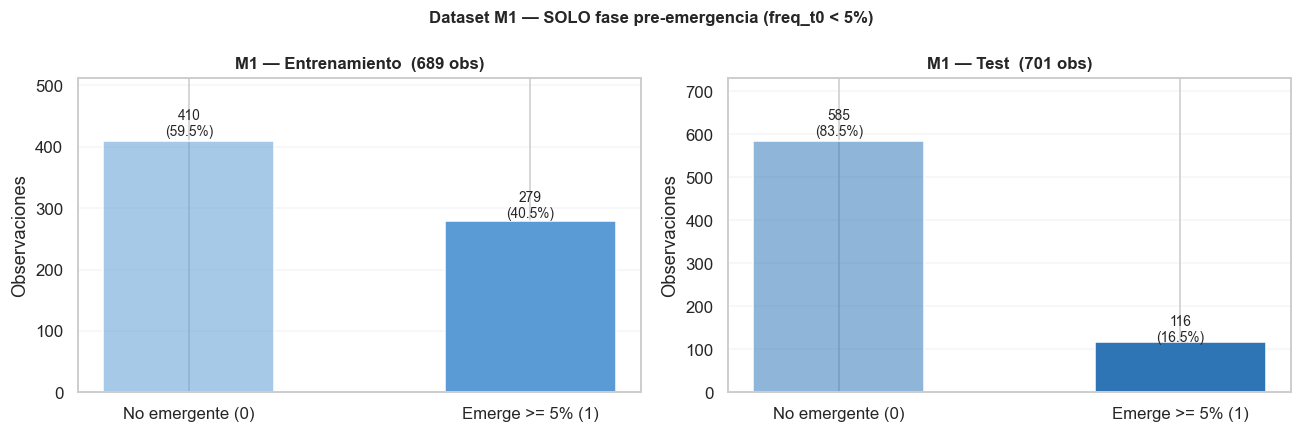

Figura guardada: 3_4_dataset_m1.png


In [29]:
# ── Celda 3.4 — Dataset M1: emergencia de clados Nextclade ───────────────────
print('Construyendo df_m1 (fase pre-emergencia, freq_t0 < 5%)...')

_nc_src = (df_family_time[df_family_time['nextclade_alias'] != '?']
           .groupby(['week', 'nextclade_alias'])
           .agg(n_seqs=('n_seqs','sum'), freq=('freq','sum'),
                n_countries=('n_countries','max'))
           .reset_index()
           .rename(columns={'nextclade_alias': 'nextclade_clade'}))

_df_m1_full = build_temporal_features(_nc_src, 'nextclade_clade', min_seqs=MIN_SEQS)

# FILTRO CLAVE: solo observaciones PRE-emergencia (clado todavía < 5%)
df_m1 = _df_m1_full[_df_m1_full['freq_t0'] < DOMINANT_THR].copy()

train_m1 = df_m1[df_m1['week'] < CUTOFF_WEEK_ML]
test_m1  = df_m1[df_m1['week'] >= CUTOFF_WEEK_ML]
FEAT_COLS_M1 = TEMPORAL_FEATS

print()
print('DATASET M1 — Clados Nextclade (solo fase de emergencia)')
print('-' * 70)
print(f'  Filas totales (incluyendo post-dominancia): {len(_df_m1_full):,}')
print(f'  Filas conservadas (freq_t0 < 5%)          : {len(df_m1):,}  '
      f'({len(df_m1)/len(_df_m1_full)*100:.1f}% del total)')
print(f'  Clados distintos : {df_m1["nextclade_clade"].nunique()}')
print(f'  Entrenamiento    : {len(train_m1):,} filas  |  positivos: '
      f'{train_m1["target"].sum():,} ({train_m1["target"].mean()*100:.1f}%)')
print(f'  Test             : {len(test_m1):,} filas  |  positivos: '
      f'{test_m1["target"].sum():,} ({test_m1["target"].mean()*100:.1f}%)')
print()
print('  TARGET = 1: clado que siendo <5% llego a >=5% en el futuro')
print('  Esta es la pregunta real de vigilancia: deteccion en fase incubacion')
print()
print('Ejemplo — clados emergentes en test (freq_t0 < 5%):')
_s1 = (test_m1.sort_values(['week','freq_t0'], ascending=[False,False])
       .groupby('nextclade_clade').first().reset_index()
       .sort_values('freq_t0', ascending=False).head(8))
display(_s1[['nextclade_clade','week','freq_t0','log_growth_8w',
             'n_countries','peak_freq_future','target']].round(4))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, df_sp, titulo, col in [
    (ax1, train_m1, 'Entrenamiento', '#5B9BD5'),
    (ax2, test_m1,  'Test',          '#2E75B6'),
]:
    n0 = (df_sp['target']==0).sum()
    n1 = (df_sp['target']==1).sum()
    bars = ax.bar(['No emergente (0)', 'Emerge >= 5% (1)'], [n0, n1],
                  color=[col+'88', col], edgecolor='white', width=0.5)
    ax.set_title(f'M1 — {titulo}  ({n0+n1:,} obs)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Observaciones')
    for bar, v in zip(bars, [n0, n1]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                f'{v:,}\n({v/(n0+n1)*100:.1f}%)', ha='center', fontsize=9)
    ax.set_ylim(0, max(n0,n1)*1.25)
    ax.grid(True, alpha=0.2, axis='y')
plt.suptitle('Dataset M1 — SOLO fase pre-emergencia (freq_t0 < 5%)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / '3_4_dataset_m1.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figura guardada: 3_4_dataset_m1.png')


### 3.4b — Datasets M1-BIO y M1-SPNSP: clados con perfil biológico y mutacional

Extensiones de M1 que añaden las mismas features que M2 y M2-SPNSP30,
pero **agregadas al nivel de clado Nextclade** (media ponderada por n_seqs
de todas las familias Pango que pertenecen a ese clado esa semana).

- **`df_m1_bio`** — M1 + 6 features biológicas (como M2)
- **`df_m1_spnsp`** — M1 + 6 bio + 30 mutaciones Spike/NSP12 (como M2-SPNSP30)

**¿Por qué agregar en lugar de usar directamente el nivel familia?**
Porque el nivel clado captura la señal filogenética global de una rama entera.
La media ponderada de hamming_distance de todos los linajes de Omicron BA.2 (21L)
describe el perfil mutacional de esa ola completa, independientemente de qué
subfamilia Pango concreta lidere en cada semana.

Permite comparar el poder predictivo a nivel clado vs nivel familia con
exactamente las mismas familias de features.


Agregando features bio y mutacionales al nivel de clado Nextclade...



DATASET M1-BIO — Clados Nextclade + features biológicas
----------------------------------------------------------------------
  Total filas : 1,390  x  21 features
  Entrenamiento: 689  |  positivos: 279 (40.5%)
  Test         : 701  |  positivos: 116 (16.5%)
  Con datos bio: 1,378 (99.1%)

DATASET M1-SPNSP — Clados Nextclade + bio + mutaciones Spike/NSP12
----------------------------------------------------------------------
  Total filas : 1,390  x  51 features
  Entrenamiento: 689  |  positivos: 279 (40.5%)
  Test         : 701  |  positivos: 116 (16.5%)
  Con datos mut: 1,181 (85.0%)

Ejemplo — perfil bio+mut de clados emergentes en test:


,nextclade_clade,week,freq_t0,log_growth_8w,mean_hamming,n_escape_muts,mut_Spike_N679K,mut_Spike_D796Y,mut_Spike_E484A,mut_Spike_Y505H,peak_freq_future,target
1048,24C,2024-03-18,0.050,4.439,899.0,9.0,0.984,0.922,0.000,0.986,0.540,1
919,23F,2023-12-18,0.048,-1.505,2244.0,14.0,0.963,0.959,0.946,0.958,0.015,0
997,25A,2024-07-01,0.047,4.039,582.0,9.0,0.990,0.970,0.000,0.987,0.244,1
628,24A,2025-07-07,0.047,-0.700,576.0,10.0,0.492,0.787,0.000,0.680,0.037,0
1154,24G,2025-05-26,0.046,-1.419,601.0,9.0,0.867,0.913,0.000,0.949,0.017,0


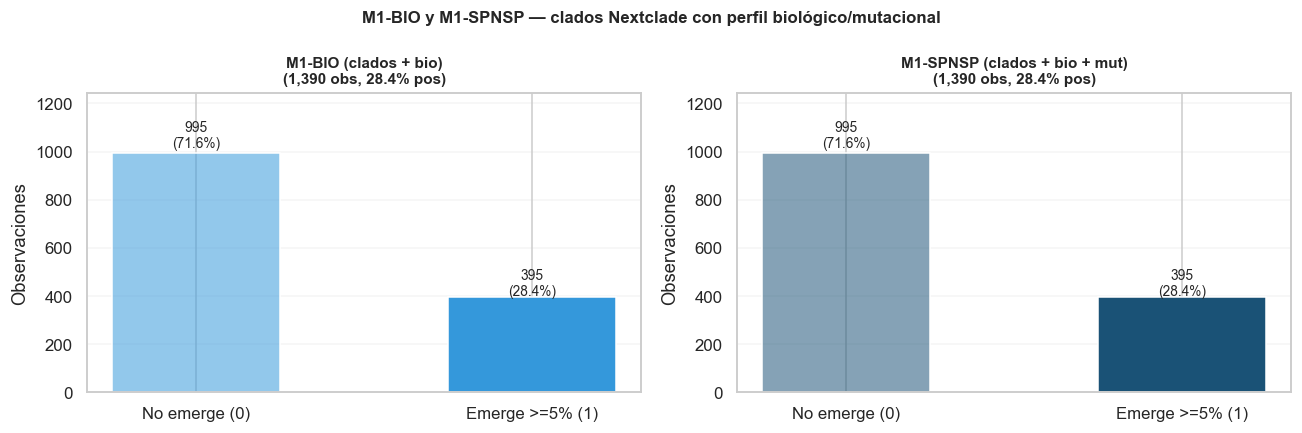

Figura guardada: 3_4b_dataset_m1bio_spnsp.png


In [30]:
# ── Celda 3.4b — M1-BIO y M1-SPNSP: agregar features al nivel de clado ───────
print('Agregando features bio y mutacionales al nivel de clado Nextclade...')

# Columna nextclade_alias disponible en df_family_time (mapeada en Módulo 2)
_fam_nc = (df_family_time[['week', 'lineage_family', 'nextclade_alias', 'n_seqs']]
           [df_family_time['nextclade_alias'] != '?'].copy())

def _wavg_agg(df_src, feat_cols, by_cols):
    """Media ponderada por n_seqs de feat_cols agrupando por by_cols."""
    _merged = _fam_nc.merge(df_src[['week', 'lineage_family'] + feat_cols],
                             on=['week', 'lineage_family'], how='left')
    for c in feat_cols:
        _merged[c] = _merged[c].fillna(0)

    def _wavg_group(g):
        w = g['n_seqs'].values.astype(float)
        w = np.where(w == 0, 1e-9, w)
        return pd.Series({c: float(np.average(g[c].values, weights=w)) for c in feat_cols})

    return (_merged.groupby(by_cols)
            .apply(_wavg_group, include_groups=False)
            .reset_index())

# ── Features biológicas a nivel clado ────────────────────────────────────────
df_clade_bio = _wavg_agg(df_family_bio, BIO_FEAT_COLS,
                          ['week', 'nextclade_alias'])
df_clade_bio = df_clade_bio.rename(columns={'nextclade_alias': 'nextclade_clade'})
df_clade_bio['week'] = pd.to_datetime(df_clade_bio['week'])

df_m1_bio = df_m1.merge(df_clade_bio, on=['week', 'nextclade_clade'], how='left')
for c in BIO_FEAT_COLS:
    df_m1_bio[c] = df_m1_bio[c].fillna(0).astype('float32')

FEAT_COLS_M1_BIO = TEMPORAL_FEATS + BIO_FEAT_COLS

# ── Features mutacionales Spike/NSP12 a nivel clado ──────────────────────────
df_clade_mut = _wavg_agg(df_family_mut_freq, mut_feat_cols_spnsp,
                          ['week', 'nextclade_alias'])
df_clade_mut = df_clade_mut.rename(columns={'nextclade_alias': 'nextclade_clade'})
df_clade_mut['week'] = pd.to_datetime(df_clade_mut['week'])

df_m1_spnsp = df_m1_bio.merge(df_clade_mut, on=['week', 'nextclade_clade'], how='left')
for c in mut_feat_cols_spnsp:
    df_m1_spnsp[c] = df_m1_spnsp[c].fillna(0).astype('float32')

FEAT_COLS_M1_SPNSP = FEAT_COLS_M1_BIO + mut_feat_cols_spnsp

# ── Resumen ───────────────────────────────────────────────────────────────────
train_m1b  = df_m1_bio[df_m1_bio['week'] < CUTOFF_WEEK_ML]
test_m1b   = df_m1_bio[df_m1_bio['week'] >= CUTOFF_WEEK_ML]
train_m1sp = df_m1_spnsp[df_m1_spnsp['week'] < CUTOFF_WEEK_ML]
test_m1sp  = df_m1_spnsp[df_m1_spnsp['week'] >= CUTOFF_WEEK_ML]
n_bio_ok   = (df_m1_bio[BIO_FEAT_COLS].sum(axis=1) > 0).sum()
n_mut_ok   = (df_m1_spnsp[mut_feat_cols_spnsp].sum(axis=1) > 0).sum()

print()
print('DATASET M1-BIO — Clados Nextclade + features biológicas')
print('-' * 70)
print(f'  Total filas : {len(df_m1_bio):,}  x  {len(FEAT_COLS_M1_BIO)} features')
print(f'  Entrenamiento: {len(train_m1b):,}  |  positivos: '
      f'{train_m1b["target"].sum():,} ({train_m1b["target"].mean()*100:.1f}%)')
print(f'  Test         : {len(test_m1b):,}  |  positivos: '
      f'{test_m1b["target"].sum():,} ({test_m1b["target"].mean()*100:.1f}%)')
print(f'  Con datos bio: {n_bio_ok:,} ({n_bio_ok/len(df_m1_bio)*100:.1f}%)')

print()
print('DATASET M1-SPNSP — Clados Nextclade + bio + mutaciones Spike/NSP12')
print('-' * 70)
print(f'  Total filas : {len(df_m1_spnsp):,}  x  {len(FEAT_COLS_M1_SPNSP)} features')
print(f'  Entrenamiento: {len(train_m1sp):,}  |  positivos: '
      f'{train_m1sp["target"].sum():,} ({train_m1sp["target"].mean()*100:.1f}%)')
print(f'  Test         : {len(test_m1sp):,}  |  positivos: '
      f'{test_m1sp["target"].sum():,} ({test_m1sp["target"].mean()*100:.1f}%)')
print(f'  Con datos mut: {n_mut_ok:,} ({n_mut_ok/len(df_m1_spnsp)*100:.1f}%)')

print()
print('Ejemplo — perfil bio+mut de clados emergentes en test:')
_s = (test_m1sp[test_m1sp['freq_t0'] < DOMINANT_THR]
      .sort_values('freq_t0', ascending=False).head(5))
_cols = (['nextclade_clade', 'week', 'freq_t0', 'log_growth_8w',
           'mean_hamming', 'n_escape_muts'] +
          mut_feat_cols_spnsp[:4] + ['peak_freq_future', 'target'])
display(_s[_cols].round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, df_sp, titulo, col in [
    (axes[0], df_m1_bio,   'M1-BIO (clados + bio)',         '#3498DB'),
    (axes[1], df_m1_spnsp, 'M1-SPNSP (clados + bio + mut)', '#1A5276'),
]:
    tr = df_sp[df_sp['week'] < CUTOFF_WEEK_ML]
    te = df_sp[df_sp['week'] >= CUTOFF_WEEK_ML]
    for ax2, df2, lbl in [(ax, tr, 'Train'), (ax, te, 'Test')]:
        pass
    n0 = (df_sp['target']==0).sum()
    n1 = (df_sp['target']==1).sum()
    bars = ax.bar(['No emerge (0)', 'Emerge >=5% (1)'], [n0, n1],
                  color=[col+'88', col], edgecolor='white', width=0.5)
    ax.set_title(f'{titulo}\n({n0+n1:,} obs, {n1/(n0+n1)*100:.1f}% pos)',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('Observaciones')
    for bar, v in zip(bars, [n0, n1]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                f'{v:,}\n({v/(n0+n1)*100:.1f}%)', ha='center', fontsize=9)
    ax.set_ylim(0, max(n0,n1)*1.25)
    ax.grid(True, alpha=0.2, axis='y')
plt.suptitle('M1-BIO y M1-SPNSP — clados Nextclade con perfil biológico/mutacional',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / '3_4b_dataset_m1bio_spnsp.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figura guardada: 3_4b_dataset_m1bio_spnsp.png')


### 3.5 — Dataset M2: familias Pango + features biológicas

**Fila = (semana, familia Pango)** — hasta 435 familias.
Núcleo del sistema predictivo.

**Target revisado:** `target = 1` si esta familia alguna vez llegó al **5%
de frecuencia global** desde T+4 semanas en adelante.

Con `MIN_SEQS=3` (bajado de 10), ahora capturamos familias en su **fase de
incubación** (pocas secuencias, alta tasa de crecimiento) — exactamente el
momento de máxima utilidad para vigilancia epidemiológica.

**Propósito:** Modelo 2 — predicción granular por familia Pango, incorporando
perfil biológico.


Construyendo df_m2 (familias Pango, target revisado, MIN_SEQS=3)...



DATASET M2 — Familias Pango + bio
--------------------------------------------------------------------
  Familias distintas : 435
  Total filas        : 12,355  x  21 features + target
  Entrenamiento      : 6,114 filas  |  positivos: 852 (13.9%)
  Test               : 6,241 filas  |  positivos: 819 (13.1%)
  Con datos bio      : 12,343 (99.9%)

  TARGET = 1: familia llego a >=5% global en algun momento posterior

Ejemplo — familias mas activas en test:


,lineage_family,week,freq_t0,log_growth_8w,mean_hamming,n_escape_muts,peak_freq_future,target
254,XFG,2026-01-12,0.6275,-0.0973,1885.0,12.0,0.4444,1
179,PQ,2026-01-12,0.1188,0.2417,563.0,9.0,0.0370,0
147,NB,2026-01-12,0.0950,0.1334,539.0,10.0,0.2593,1
252,XFC,2026-01-12,0.0330,1.4279,209.0,9.0,0.0370,0
114,LF,2026-01-12,0.0232,-0.5791,374.0,10.0,0.0741,1
198,RE,2026-01-12,0.0232,0.7452,296.0,4.0,0.0370,0


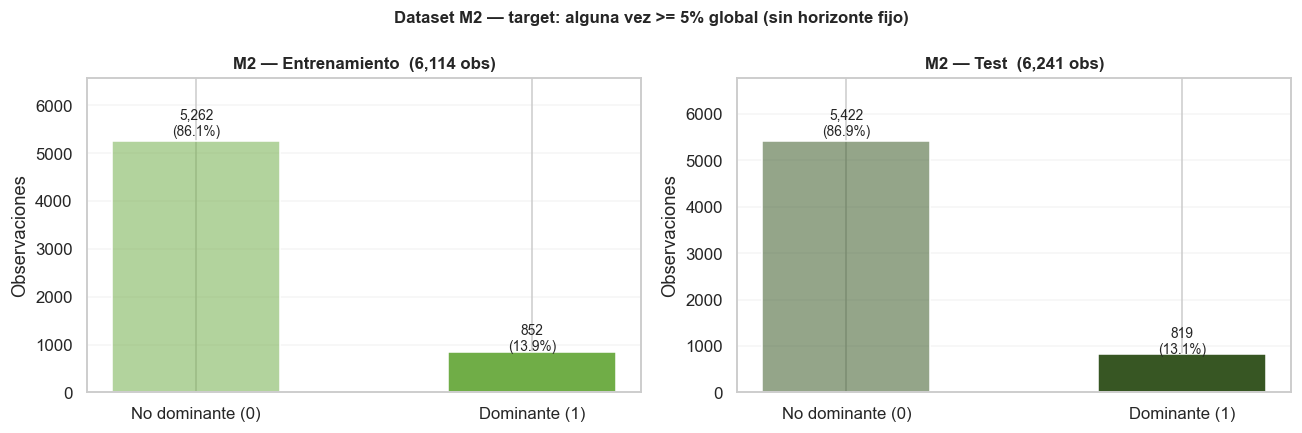

Figura guardada: 3_5_dataset_m2.png


In [31]:
# ── Celda 3.5 — Dataset M2: familias Pango + features biológicas ──────────────
print('Construyendo df_m2 (familias Pango, target revisado, MIN_SEQS=3)...')

df_m2 = build_temporal_features(df_family_time, 'lineage_family', min_seqs=MIN_SEQS)
df_m2 = df_m2.merge(
    df_family_bio[['week', 'lineage_family'] + BIO_FEAT_COLS],
    on=['week', 'lineage_family'], how='left'
)
for c in BIO_FEAT_COLS:
    df_m2[c] = df_m2[c].fillna(0).astype('float32')

FEAT_COLS_M2 = TEMPORAL_FEATS + BIO_FEAT_COLS
train_m2  = df_m2[df_m2['week'] < CUTOFF_WEEK_ML]
test_m2   = df_m2[df_m2['week'] >= CUTOFF_WEEK_ML]
n_bio_ok  = (df_m2[BIO_FEAT_COLS].sum(axis=1) > 0).sum()

print()
print('DATASET M2 — Familias Pango + bio')
print('-' * 68)
print(f'  Familias distintas : {df_m2["lineage_family"].nunique()}')
print(f'  Total filas        : {len(df_m2):,}  x  {len(FEAT_COLS_M2)} features + target')
print(f'  Entrenamiento      : {len(train_m2):,} filas  |  positivos: '
      f'{train_m2["target"].sum():,} ({train_m2["target"].mean()*100:.1f}%)')
print(f'  Test               : {len(test_m2):,} filas  |  positivos: '
      f'{test_m2["target"].sum():,} ({test_m2["target"].mean()*100:.1f}%)')
print(f'  Con datos bio      : {n_bio_ok:,} ({n_bio_ok/len(df_m2)*100:.1f}%)')
print()
print('  TARGET = 1: familia llego a >=5% global en algun momento posterior')
print()
print('Ejemplo — familias mas activas en test:')
_s2 = (test_m2.sort_values('week').groupby('lineage_family')
       .last().reset_index().sort_values('freq_t0', ascending=False).head(6))
display(_s2[['lineage_family','week','freq_t0','log_growth_8w',
             'mean_hamming','n_escape_muts','peak_freq_future','target']].round(4))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, df_sp, titulo, col in [
    (ax1, train_m2, 'Entrenamiento', '#70AD47'),
    (ax2, test_m2,  'Test',          '#375623'),
]:
    n0 = (df_sp['target']==0).sum()
    n1 = (df_sp['target']==1).sum()
    bars = ax.bar(['No dominante (0)', 'Dominante (1)'], [n0, n1],
                  color=[col+'88', col], edgecolor='white', width=0.5)
    ax.set_title(f'M2 — {titulo}  ({n0+n1:,} obs)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Observaciones')
    for bar, v in zip(bars, [n0, n1]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                f'{v:,}\n({v/(n0+n1)*100:.1f}%)', ha='center', fontsize=9)
    ax.set_ylim(0, max(n0,n1)*1.25)
    ax.grid(True, alpha=0.2, axis='y')
plt.suptitle('Dataset M2 — target: alguna vez >= 5% global (sin horizonte fijo)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / '3_5_dataset_m2.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figura guardada: 3_5_dataset_m2.png')


### 3.6 — Dataset M2-SPNSP30: familias Pango + mutaciones Spike y NSP12

Extensión de M2 con **30 features mutacionales within-family** de Spike y NSP12.

**Target revisado:** idéntico a M2 — `target = 1` si la familia llegó al 5%
global en cualquier momento futuro.

**¿Por qué solo Spike + NSP12?**
- **Spike**: determina unión ACE2 + escape de anticuerpos (fitness inmunológico)
- **NSP12 (RdRp)**: regula fidelidad de replicación y tasa evolutiva
- La literatura (Obermeyer 2022, HiRisk 2024) coincide: las mutaciones en Spike
  son las de mayor poder predictivo para fitness de variantes


Construyendo df_m2_spnsp...

DATASET M2-SPNSP30 — Familias Pango + Spike + NSP12
--------------------------------------------------------------------
  Familias distintas : 435
  Total filas        : 12,355  x  51 features
  Entrenamiento      : 6,114 filas  |  positivos: 852 (13.9%)
  Test               : 6,241 filas  |  positivos: 819 (13.1%)
  Con datos mut      : 10,172 (82.3%)

Las 30 mutaciones Spike+NSP12 (top por varianza en entrenamiento):
  S:N679K  S:D796Y  S:E484A  S:Y505H  S:T19I  S:P681H  S:T478K  S:A27S  S:P26del  S:P25del
  S:L24del  S:T376A  S:G142D  S:N440K  S:G339D  S:V213G  S:L452R  nsp12:G671S  S:P681R  S:T19R
  S:F486V  S:D950N  S:R346T  S:F157del  S:R158del  S:E156G  S:Q493R  S:G446S  S:G339H  S:F490S

Ejemplo — perfil mutacional de familias activas (test):


,lineage_family,freq_t0,log_growth_8w,mut_Spike_N679K,mut_Spike_D796Y,mut_Spike_E484A,mut_Spike_Y505H,mut_Spike_T19I,peak_freq_future,target
254,XFG,0.627,-0.097,0.908,0.954,0.0,0.983,0.832,0.444,1
179,PQ,0.119,0.242,0.941,0.956,0.0,0.995,0.917,0.037,0
147,NB,0.095,0.133,0.909,0.994,0.0,0.988,0.915,0.259,1
252,XFC,0.033,1.428,0.211,0.947,0.0,1.000,0.930,0.037,0
114,LF,0.023,-0.579,0.875,0.925,0.0,0.650,0.725,0.074,1


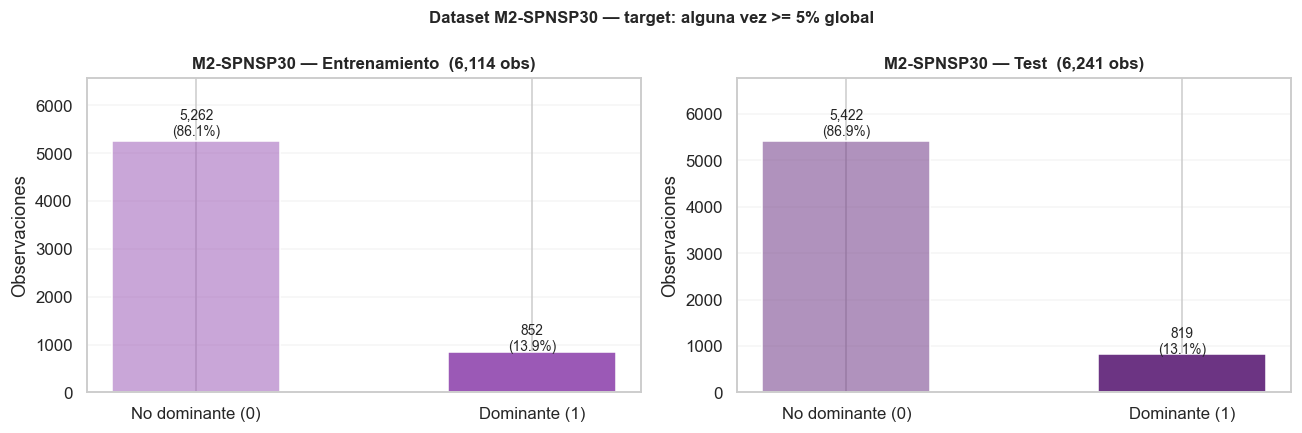

Figura guardada: 3_6_dataset_m2spnsp.png


In [32]:
# ── Celda 3.6 — Dataset M2-SPNSP30: familias + Spike/NSP12 ───────────────────
print('Construyendo df_m2_spnsp...')

mut_feat_cols_spnsp = [f'mut_{m}' for m in top30_muts_spnsp]

df_m2_spnsp = df_m2.merge(
    df_family_mut_freq[['week', 'lineage_family'] + mut_feat_cols_spnsp],
    on=['week', 'lineage_family'], how='left'
)
for c in mut_feat_cols_spnsp:
    df_m2_spnsp[c] = df_m2_spnsp[c].fillna(0).astype('float32')

FEAT_COLS_M2_SPNSP = FEAT_COLS_M2 + mut_feat_cols_spnsp
train_m2sp = df_m2_spnsp[df_m2_spnsp['week'] < CUTOFF_WEEK_ML]
test_m2sp  = df_m2_spnsp[df_m2_spnsp['week'] >= CUTOFF_WEEK_ML]
n_mut_ok   = (df_m2_spnsp[mut_feat_cols_spnsp].sum(axis=1) > 0).sum()

print()
print('DATASET M2-SPNSP30 — Familias Pango + Spike + NSP12')
print('-' * 68)
print(f'  Familias distintas : {df_m2_spnsp["lineage_family"].nunique()}')
print(f'  Total filas        : {len(df_m2_spnsp):,}  x  {len(FEAT_COLS_M2_SPNSP)} features')
print(f'  Entrenamiento      : {len(train_m2sp):,} filas  |  positivos: '
      f'{train_m2sp["target"].sum():,} ({train_m2sp["target"].mean()*100:.1f}%)')
print(f'  Test               : {len(test_m2sp):,} filas  |  positivos: '
      f'{test_m2sp["target"].sum():,} ({test_m2sp["target"].mean()*100:.1f}%)')
print(f'  Con datos mut      : {n_mut_ok:,} ({n_mut_ok/len(df_m2_spnsp)*100:.1f}%)')
print()
_muts_clean = [m.replace('Spike_','S:').replace('NSP12_','nsp12:')
               for m in top30_muts_spnsp]
print('Las 30 mutaciones Spike+NSP12 (top por varianza en entrenamiento):')
for ii in range(0, 30, 10):
    print('  ' + '  '.join(_muts_clean[ii:ii+10]))
print()
print('Ejemplo — perfil mutacional de familias activas (test):')
_s3 = (test_m2sp.sort_values('week').groupby('lineage_family')
       .last().reset_index().sort_values('freq_t0', ascending=False).head(5))
_cols_show = ['lineage_family','freq_t0','log_growth_8w'] + mut_feat_cols_spnsp[:5] + ['peak_freq_future','target']
display(_s3[_cols_show].round(3))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, df_sp, titulo, col in [
    (ax1, train_m2sp, 'Entrenamiento', '#9B59B6'),
    (ax2, test_m2sp,  'Test',          '#6C3483'),
]:
    n0 = (df_sp['target']==0).sum()
    n1 = (df_sp['target']==1).sum()
    bars = ax.bar(['No dominante (0)', 'Dominante (1)'], [n0, n1],
                  color=[col+'88', col], edgecolor='white', width=0.5)
    ax.set_title(f'M2-SPNSP30 — {titulo}  ({n0+n1:,} obs)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Observaciones')
    for bar, v in zip(bars, [n0, n1]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                f'{v:,}\n({v/(n0+n1)*100:.1f}%)', ha='center', fontsize=9)
    ax.set_ylim(0, max(n0,n1)*1.25)
    ax.grid(True, alpha=0.2, axis='y')
plt.suptitle('Dataset M2-SPNSP30 — target: alguna vez >= 5% global',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / '3_6_dataset_m2spnsp.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figura guardada: 3_6_dataset_m2spnsp.png')


### 3.7 — Datasets M3-SPNSP y M3-ALL: mutaciones individuales

Dos datasets de mutaciones con el mismo esquema base pero diferente cobertura:

**`df_m3_spnsp`** — Solo mutaciones de **Spike y NSP12**
- Spike: determinante principal de escape inmune y unión ACE2
- NSP12 (RdRp): fidelidad de copia, tasa de mutación
- Feature extra: `is_ntd` (posiciones 14-305 de Spike — hotspot de escape)
- El subconjunto más informativo para predecir fitness vacunal

**`df_m3_all`** — **Todas** las mutaciones (Spike, NSP12, N, ORF3a, NSP3...)
- Captura señal evolutiva en proteínas no estructurales y accesorias
- Feature extra: `is_n_protein` (nucleocápside — afecta diagnóstico y transmisión)
- Más ruidoso pero más completo

**Feature compartida clave: `n_families`** — convergencia evolutiva:
cuántos linajes Pango distintos portan esa mutación esa semana.
Alta convergencia = la mutación confiere ventaja selectiva activa.

**Umbral de detección:** `freq_t0 >= 0.0001` (0.01% global).
**Target:** `max(freq[T+4..fin]) >= 5%` sin horizonte fijo.


Pre-computando n_families por (semana, mutacion)...


Pre-computando coocurrencia real (train) para features de mutación...


  Mutaciones con coocurrencia real precomputada: 66
Construyendo registros...



DATASET M3-SPNSP — Mutaciones Spike + NSP12
----------------------------------------------------------------------
  Mutaciones distintas : 637  (533 Spike + 104 NSP12)
  Total filas          : 104,461  x  16 features
  Train                : 53,564  |  positivos: 10,833 (20.2%)
  Test                 : 50,897  |  positivos: 9,115 (17.9%)

DATASET M3-ALL — Todas las mutaciones
----------------------------------------------------------------------
  Total filas          : 424,293  x  17 features
  Train                : 237,941  |  positivos: 34,967 (14.7%)
  Test                 : 186,352  |  positivos: 24,288 (13.0%)

Features nuevas (ronda 2) — estado final tras los ablation de 4.1d:
  n_families_recent     : ÚNICA que se queda en FEAT_COLS_M3_* — convergencia en ventana causal de 12 semanas (media=10.75, vs n_families media=4.60). Es la feature de mayor peso SHAP de todo M3 (4.3a).
  blosum_change         : columna calculada (27,697 filas son indels, valor centinela -8.0) pero EXCL

,mut_clean,freq_t0,log_growth_8w,n_families,n_families_recent,blosum_change,cooc_partner_strength,is_rbd,is_ntd,is_furin,peak_freq_future,target
249,S:L452W,0.8592,-0.0611,21,36,-2.0,0.0000,1,0,0,0.9630,1
227,S:L212I,0.8986,-0.0230,21,37,2.0,0.9943,0,1,0,0.9630,1
69,S:D796Y,0.9531,0.0048,21,40,-3.0,0.8681,0,0,0,0.8889,1
278,S:N211del,0.8986,-0.0220,21,37,-8.0,0.9943,0,1,0,0.9630,1
325,S:P681R,0.9403,-0.0003,20,35,-2.0,0.9744,0,0,1,0.8889,1
167,S:H245N,0.8980,-0.0198,19,34,1.0,0.0000,0,1,0,0.9259,1


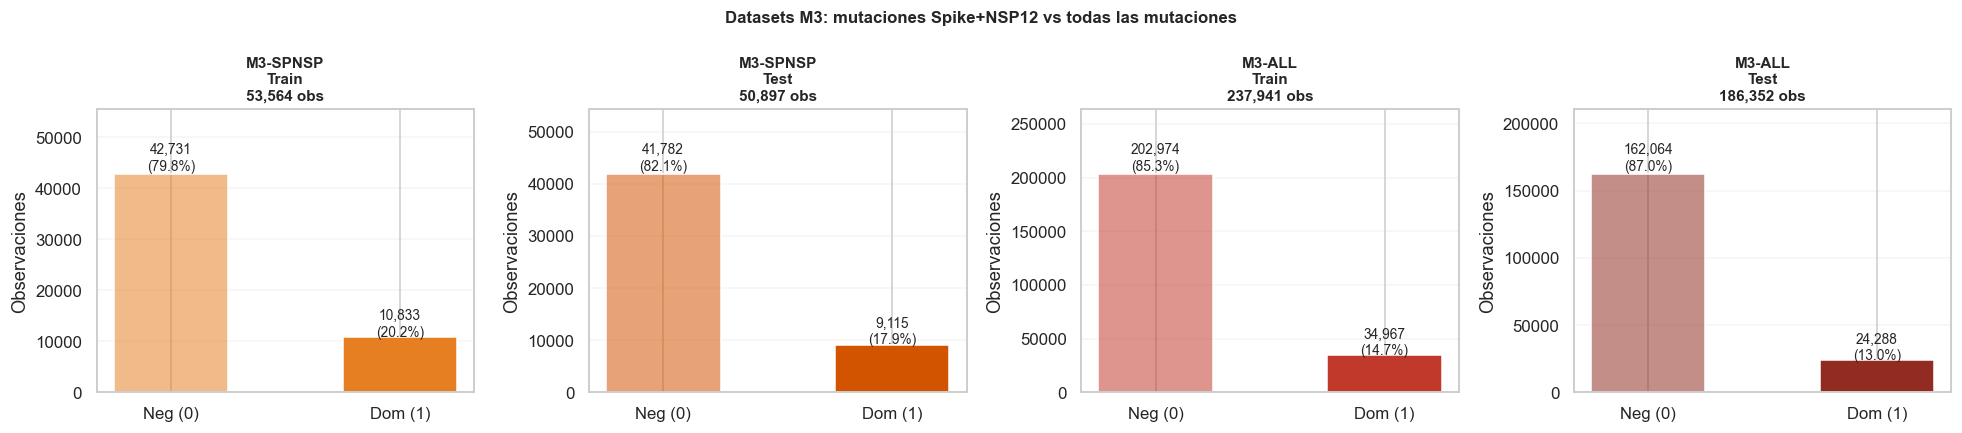

Figura guardada: 3_7_datasets_m3.png


In [33]:
# ── Celda 3.7 — Datasets M3-SPNSP y M3-ALL: mutaciones individuales ─────────
import re
print('Pre-computando n_families por (semana, mutacion)...')

mut_nfam_week = {}
for wk, fam_dict in family_mut_week_counts.items():
    mc = {}
    for fam, mut_counter in fam_dict.items():
        for mut in mut_counter:
            mc[mut] = mc.get(mut, 0) + 1
    mut_nfam_week[str(wk)[:10]] = mc

# ── Convergencia reciente: familias que llevan la mutación (contemporáneo,
# no acumulado histórico) — se usa después para una ventana móvil causal
# (RECENT_WINDOW_WEEKS), sin mirar nunca semanas futuras a la de la fila.
mut_fam_by_week = {}
for wk, fam_dict in family_mut_week_counts.items():
    wk_key = str(wk)[:10]
    d = mut_fam_by_week.setdefault(wk_key, {})
    for fam, mut_counter in fam_dict.items():
        for mut in mut_counter:
            d.setdefault(mut, set()).add(fam)

RECENT_WINDOW_WEEKS = 12  # ~1 trimestre: convergencia reciente vs ancestralidad antigua

# Regex genérica (cualquier proteína) para severidad bioquímica BLOSUM62 —
# distinta de _MUT_RE (2.8b, restringida a Spike/NSP12 porque necesita la
# referencia de nucleótidos). BLOSUM62 solo necesita el par WT/MUT de
# aminoácidos, así que aquí se aplica a todo el universo de M3-ALL.
_AA_SUB_RE = re.compile(r'^[A-Za-z0-9]+_([A-Z])(\d+)([A-Z])$')
_BLOSUM_INDEL_SENTINEL = -8.0  # más severo que el mínimo típico de BLOSUM62

def _parse_mut_bio(mut):
    is_spike  = mut.startswith('Spike_')
    is_nsp12  = mut.startswith('NSP12_')
    is_n_prot = mut.startswith('N_')
    nums = re.findall(r'\d+', mut)
    pos  = int(nums[0]) if nums else -1

    m_sub = _AA_SUB_RE.match(mut)
    is_indel = m_sub is None
    if m_sub is not None and BLOSUM62 is not None:
        wt_aa, _, mut_aa = m_sub.groups()
        try:
            blosum_change = float(BLOSUM62[wt_aa, mut_aa])
        except (KeyError, IndexError):
            # IndexError: Biopython lo lanza (no KeyError) cuando la letra no
            # está en el alfabeto de BLOSUM62 -- p.ej. códigos de ambigüedad
            # de GISAID como 'X', 'B', 'Z', 'J' que no son de los 20
            # aminoácidos estándar.
            blosum_change = np.nan
    else:
        blosum_change = _BLOSUM_INDEL_SENTINEL if is_indel else np.nan

    return {
        'is_spike'    : int(is_spike),
        'is_nsp12'    : int(is_nsp12),
        'is_n_protein': int(is_n_prot),
        'position'    : pos,
        'is_rbd'      : int(is_spike and (319 <= pos <= 541)),
        'is_ntd'      : int(is_spike and (14  <= pos <= 305)),
        'is_furin'    : int(is_spike and (681 <= pos <= 685)),
        'is_indel'      : int(is_indel),
        'blosum_change' : blosum_change,
    }

mut_bio_cache = {m: _parse_mut_bio(m) for m in freq_matrix_mut.columns}
weeks_mut     = sorted(freq_matrix_mut.index)
n_weeks_mut   = len(weeks_mut)

# ── Coocurrencia real (agregada en train, estática por mutación — evita fuga
# de información futura): tasa máxima de coocurrencia con otra mutación de
# TARGET_COOC_MUTS de familia distinta. Solo cubre las ~66 mutaciones
# "hallmark" trackeadas en el streaming (1.3); para el resto queda en 0.
print('Pre-computando coocurrencia real (train) para features de mutación...')
_target_list       = sorted(TARGET_COOC_MUTS)
_train_weeks_pair   = [wk for wk in mut_pair_week_counts if pd.Timestamp(wk) < CUTOFF_WEEK_ML]
_fam_sets_cooc      = {m: characteristic_families(m) for m in _target_list}

def _cooc_partner_strength(mut):
    n_mut = sum(mut_week_counts.get(wk, {}).get(mut, 0) for wk in _train_weeks_pair)
    if n_mut == 0:
        return 0.0
    f1 = _fam_sets_cooc.get(mut, set())
    best = 0.0
    for other in _target_list:
        if other == mut:
            continue
        f2 = _fam_sets_cooc.get(other, set())
        if f1 and f2 and (len(f1 & f2) / len(f1 | f2)) >= 0.5:
            continue  # misma familia -> no cuenta como pareja "distinta"
        pair   = frozenset((mut, other))
        n_pair = sum(mut_pair_week_counts[wk].get(pair, 0) for wk in _train_weeks_pair)
        if n_pair == 0:
            continue
        best = max(best, n_pair / n_mut)
    return best

cooc_by_mut = {m: _cooc_partner_strength(m) for m in _target_list}
print(f'  Mutaciones con coocurrencia real precomputada: {len(cooc_by_mut)}')

print('Construyendo registros...')
records_mut = []
for mut in freq_matrix_mut.columns:
    bio   = mut_bio_cache[mut]
    mfreq = freq_matrix_mut[mut]
    for i in range(LOOKBACK, n_weeks_mut - HORIZON_MIN):
        freq0 = float(mfreq.iloc[i])
        if freq0 < 0.0001:
            continue
        window        = mfreq.iloc[i - LOOKBACK:i].values
        s8            = float(np.polyfit(np.arange(LOOKBACK), window, 1)[0])
        s4            = float(np.polyfit(np.arange(4), window[-4:], 1)[0]) if len(window) >= 4 else 0.0
        freq_8w_ago   = float(window[0])
        freq_4w_ago   = float(window[-4]) if len(window) >= 4 else 0.0
        log_growth_8w = np.log(freq0 + 1e-6) - np.log(freq_8w_ago + 1e-6)
        log_growth_4w = np.log(freq0 + 1e-6) - np.log(freq_4w_ago + 1e-6)

        future           = mfreq.iloc[i + HORIZON_MIN:]
        peak_freq_future = float(future.max()) if len(future) > 0 else 0.0
        cr05 = future.index[future.values >= DOMINANT_THR_MUT]
        cr10 = future.index[future.values >= DOMINANT_THR_SPNSP]
        event_week_05 = cr05.min() if len(cr05) > 0 else pd.NaT
        event_week_10 = cr10.min() if len(cr10) > 0 else pd.NaT

        wk_t   = weeks_mut[i]
        wk_str = str(wk_t.date()) if hasattr(wk_t, 'date') else str(wk_t)[:10]
        n_fam  = mut_nfam_week.get(wk_str, {}).get(mut, 0)

        # Convergencia reciente: unión de familias en la ventana causal
        # [i-RECENT_WINDOW_WEEKS+1, i] — nunca mira semanas futuras a wk_t.
        _lo = max(0, i - RECENT_WINDOW_WEEKS + 1)
        _fams_recent = set()
        for j in range(_lo, i + 1):
            _wk_str_j = str(weeks_mut[j].date())
            _fams_recent |= mut_fam_by_week.get(_wk_str_j, {}).get(mut, set())
        n_fam_recent = len(_fams_recent)

        row = {
            'mutation'        : mut,
            'week'            : pd.Timestamp(wk_t),
            'freq_t0'         : freq0,
            'slope_8w'        : s8,
            'slope_4w'        : s4,
            'accel'           : s4 - s8,
            'log_growth_8w'   : log_growth_8w,
            'log_growth_4w'   : log_growth_4w,
            'freq_mean_8w'    : float(window.mean()),
            'freq_std_8w'     : float(window.std()),
            'n_families'      : n_fam,
            'n_families_recent'     : n_fam_recent,
            'cooc_partner_strength' : cooc_by_mut.get(mut, 0.0),
            'peak_freq_future': peak_freq_future,
            'event_week_05'   : event_week_05,
            'event_week_10'   : event_week_10,
        }
        row.update(bio)
        records_mut.append(row)

_df_all = pd.DataFrame(records_mut)
_df_all['week']          = pd.to_datetime(_df_all['week'])
_df_all['event_week_05'] = pd.to_datetime(_df_all['event_week_05'])
_df_all['event_week_10'] = pd.to_datetime(_df_all['event_week_10'])
_df_all['target']        = (_df_all['peak_freq_future'] >= DOMINANT_THR_MUT).astype(int)
_df_all['blosum_change']  = _df_all['blosum_change'].fillna(_BLOSUM_INDEL_SENTINEL)

df_m3_spnsp = _df_all[(_df_all['is_spike']==1) | (_df_all['is_nsp12']==1)].copy()
df_m3_spnsp['target']     = (df_m3_spnsp['peak_freq_future'] >= DOMINANT_THR_SPNSP).astype(int)
df_m3_spnsp['event_week'] = df_m3_spnsp['event_week_10']
# NOTA (ablation, ronda 2): cooc_partner_strength se calcula y se conserva
# como columna (útil para el análisis descriptivo de 2.9 y para inspección),
# pero se EXCLUYE de las features del modelo. Solo tiene valor no-cero para
# las mutaciones "hallmark" de TARGET_COOC_MUTS (elegidas parcialmente por su
# importancia histórica en train), así que actuaba como una identidad
# memorizable de "mutación ya conocida como importante" en vez de señal
# generalizable: el ablation original (con TARGET_COOC_MUTS de 39 mutaciones)
# mostró que quitarla subía el AUC test de 0.876 a 0.926 y bajaba el gap
# train-test de 0.123 a 0.054 en M3-SPNSP. Esa cifra concreta es anterior a
# la ampliación de TARGET_COOC_MUTS a 66 (ronda 3, punto 3) y no se ha vuelto
# a medir con la lista ampliada -- la decisión de exclusión no depende de la
# magnitud exacta (el mecanismo de memorización aplica igual con 39 o 66
# mutaciones sobre un universo de 637), pero el número en sí queda como
# referencia histórica, no como resultado verificado con los datos actuales.
#
# Ronda 3 (4.1d): `blosum_change` e `is_indel` tampoco aportan -- el ablation
# extendido mostró que quitar ambas cambia el AUC test en apenas -0.0014
# pero BAJA el gap train-test de 0.054 a 0.027 (casi a la mitad) y el modelo
# converge en menos iteraciones (55->24). Se excluyen también de
# FEAT_COLS_M3_* por el mismo criterio que cooc_partner_strength, y se
# conservan como columnas descriptivas en el dataframe.
FEAT_COLS_M3_SPNSP = [
    'freq_t0', 'slope_8w', 'slope_4w', 'accel',
    'log_growth_8w', 'log_growth_4w',
    'freq_mean_8w', 'freq_std_8w',
    'n_families', 'is_spike', 'is_nsp12',
    'position', 'is_rbd', 'is_ntd', 'is_furin',
    'n_families_recent',
]

df_m3_all = _df_all.copy()
df_m3_all['event_week'] = df_m3_all['event_week_05']
FEAT_COLS_M3_ALL = [
    'freq_t0', 'slope_8w', 'slope_4w', 'accel',
    'log_growth_8w', 'log_growth_4w',
    'freq_mean_8w', 'freq_std_8w',
    'n_families', 'is_spike', 'is_nsp12', 'is_n_protein',
    'position', 'is_rbd', 'is_ntd', 'is_furin',
    'n_families_recent',
]

train_sp = df_m3_spnsp[df_m3_spnsp['week'] < CUTOFF_WEEK_ML]
test_sp  = df_m3_spnsp[df_m3_spnsp['week'] >= CUTOFF_WEEK_ML]
train_al = df_m3_all[df_m3_all['week'] < CUTOFF_WEEK_ML]
test_al  = df_m3_all[df_m3_all['week'] >= CUTOFF_WEEK_ML]

print()
print('DATASET M3-SPNSP — Mutaciones Spike + NSP12')
print('-' * 70)
_n_sp  = df_m3_spnsp['mutation'].nunique()
_n_nsp = df_m3_spnsp[df_m3_spnsp['is_nsp12']==1]['mutation'].nunique()
print(f'  Mutaciones distintas : {_n_sp:,}  ({_n_sp-_n_nsp} Spike + {_n_nsp} NSP12)')
print(f'  Total filas          : {len(df_m3_spnsp):,}  x  {len(FEAT_COLS_M3_SPNSP)} features')
print(f'  Train                : {len(train_sp):,}  |  positivos: '
      f'{train_sp["target"].sum():,} ({train_sp["target"].mean()*100:.1f}%)')
print(f'  Test                 : {len(test_sp):,}  |  positivos: '
      f'{test_sp["target"].sum():,} ({test_sp["target"].mean()*100:.1f}%)')

print()
print('DATASET M3-ALL — Todas las mutaciones')
print('-' * 70)
print(f'  Total filas          : {len(df_m3_all):,}  x  {len(FEAT_COLS_M3_ALL)} features')
print(f'  Train                : {len(train_al):,}  |  positivos: '
      f'{train_al["target"].sum():,} ({train_al["target"].mean()*100:.1f}%)')
print(f'  Test                 : {len(test_al):,}  |  positivos: '
      f'{test_al["target"].sum():,} ({test_al["target"].mean()*100:.1f}%)')

print()
print('Features nuevas (ronda 2) — estado final tras los ablation de 4.1d:')
print(f'  n_families_recent     : ÚNICA que se queda en FEAT_COLS_M3_* — convergencia en ventana '
      f'causal de {RECENT_WINDOW_WEEKS} semanas (media={_df_all["n_families_recent"].mean():.2f}, '
      f'vs n_families media={_df_all["n_families"].mean():.2f}). Es la feature de mayor peso SHAP '
      f'de todo M3 (4.3a).')
print(f'  blosum_change         : columna calculada ({_df_all["blosum_change"].eq(_BLOSUM_INDEL_SENTINEL).sum():,} '
      f'filas son indels, valor centinela {_BLOSUM_INDEL_SENTINEL}) pero EXCLUIDA de FEAT_COLS_M3_* — '
      f'el ablation de 4.1d mostró que quitarla junto con is_indel baja el gap train-test a la mitad '
      f'(0.054->0.027) por solo -0.0014 de AUC.')
print(f'  is_indel              : {_df_all["is_indel"].sum():,} filas de deleciones/inserciones; '
      f'EXCLUIDA de FEAT_COLS_M3_* por el mismo motivo que blosum_change (4.1d).')
print(f'  cooc_partner_strength : columna calculada (>0 en '
      f'{(_df_all["cooc_partner_strength"]>0).sum():,} filas) pero EXCLUIDA de FEAT_COLS_M3_* — '
      f'el ablation de 4.1d (ronda 2) mostró que causaba sobreajuste en M3-SPNSP '
      f'(memoriza las {len(TARGET_COOC_MUTS)} mutaciones hallmark en vez de generalizar). '
      f'Se conserva solo para el análisis descriptivo de 2.9.')

print()
print('Ejemplo — mutaciones Spike de mayor convergencia (test):')
_s4 = (test_sp[test_sp['is_spike']==1]
       .sort_values('week').groupby('mutation').last().reset_index()
       .sort_values('n_families', ascending=False).head(6))
_s4['mut_clean'] = _s4['mutation'].str.replace('Spike_','S:')
display(_s4[['mut_clean','freq_t0','log_growth_8w','n_families','n_families_recent',
             'blosum_change','cooc_partner_strength',
             'is_rbd','is_ntd','is_furin','peak_freq_future','target']].round(4))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, df_sp, titulo, col in [
    (axes[0], train_sp, 'M3-SPNSP\nTrain', '#E67E22'),
    (axes[1], test_sp,  'M3-SPNSP\nTest',  '#D35400'),
    (axes[2], train_al, 'M3-ALL\nTrain',   '#C0392B'),
    (axes[3], test_al,  'M3-ALL\nTest',    '#922B21'),
]:
    n0 = (df_sp['target']==0).sum()
    n1 = (df_sp['target']==1).sum()
    bars = ax.bar(['Neg (0)', 'Dom (1)'], [n0, n1],
                  color=[col+'88', col], edgecolor='white', width=0.5)
    ax.set_title(f'{titulo}\n{n0+n1:,} obs', fontsize=10, fontweight='bold')
    ax.set_ylabel('Observaciones')
    for bar, v in zip(bars, [n0, n1]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                f'{v:,}\n({v/(n0+n1)*100:.1f}%)', ha='center', fontsize=9)
    ax.set_ylim(0, max(n0,n1)*1.3)
    ax.grid(True, alpha=0.2, axis='y')
plt.suptitle('Datasets M3: mutaciones Spike+NSP12 vs todas las mutaciones',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / '3_7_datasets_m3.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figura guardada: 3_7_datasets_m3.png')

### 3.8 — Resumen comparativo de los 4 datasets

Panel consolidado: tamaño, balance de clases y composición de features.


RESUMEN — 7 datasets del Modulo 3
  Dataset       Entidad               Total    Train    Test   Pos%  Feats
  --------------------------------------------------------------------------
  M1            Clado Nextclade       1,390      689     701  28.4%     15
  M1-BIO        Clado Nextclade       1,390      689     701  28.4%     21
  M1-SPNSP      Clado Nextclade       1,390      689     701  28.4%     51
  M2            Familia Pango        12,355    6,114   6,241  13.5%     21
  M2-SPNSP30    Familia Pango        12,355    6,114   6,241  13.5%     51
  M3-SPNSP      Mut Spk/NSP12       104,461   53,564  50,897  19.1%     16


  M3-ALL        Mut (todas)         424,293  237,941 186,352  14.0%     17

  NIVELES:
    Clado Nextclade : M1 (temporal) / M1-BIO (+bio) / M1-SPNSP (+bio+mut)
    Familia Pango   : M2 (temporal+bio) / M2-SPNSP30 (+mut)
    Mutacion        : M3-SPNSP (Spike+NSP12) / M3-ALL (todo el genoma)


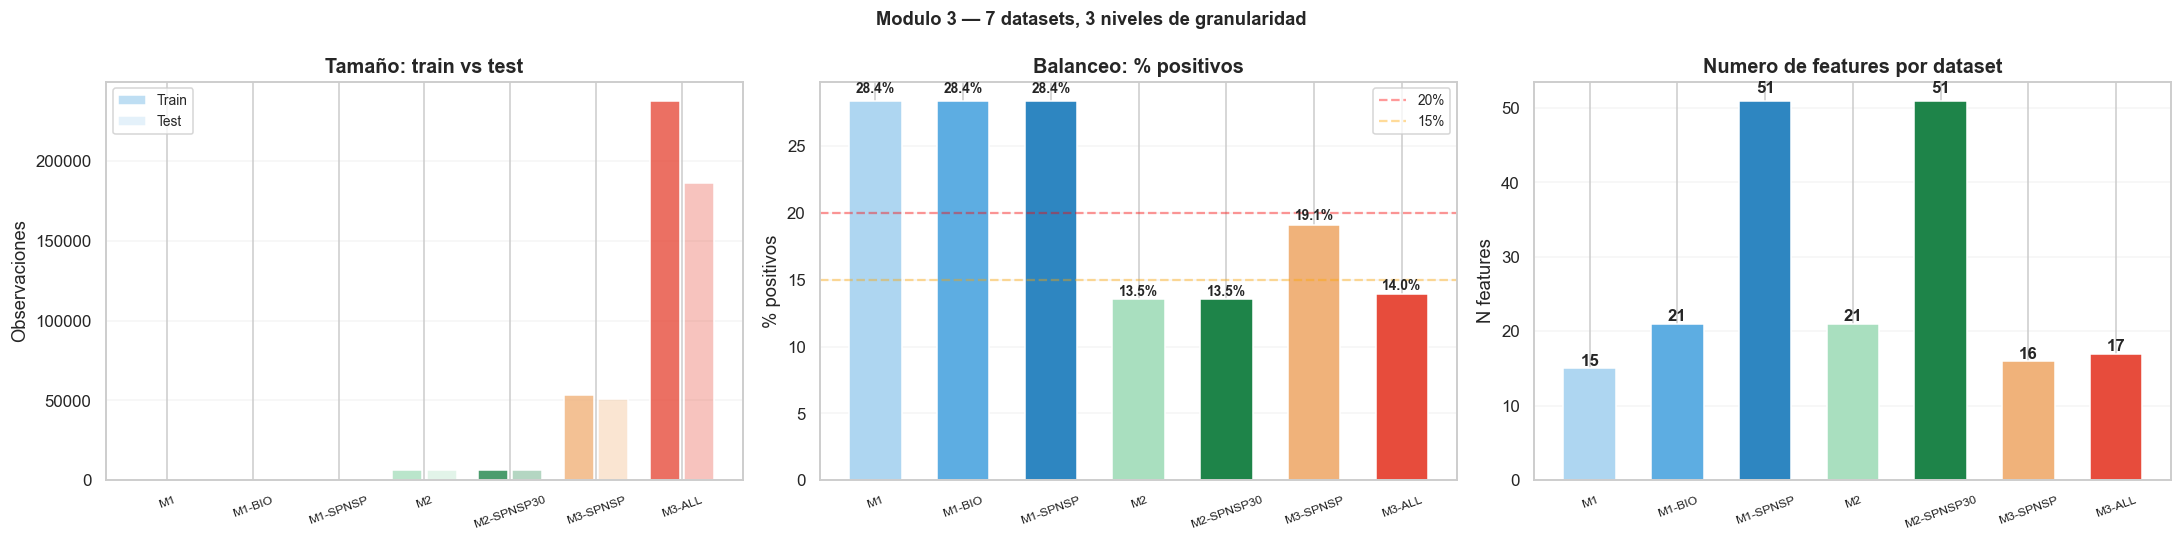

Figura guardada: 3_8_resumen_datasets.png


In [34]:
# ── Celda 3.8 — Panel comparativo de los 7 datasets ─────────────────────────
_ds = [
    dict(nombre='M1',          df=df_m1,        feats=FEAT_COLS_M1,         col='#AED6F1',
         entidad='Clado Nextclade'),
    dict(nombre='M1-BIO',      df=df_m1_bio,    feats=FEAT_COLS_M1_BIO,     col='#5DADE2',
         entidad='Clado Nextclade'),
    dict(nombre='M1-SPNSP',    df=df_m1_spnsp,  feats=FEAT_COLS_M1_SPNSP,   col='#2E86C1',
         entidad='Clado Nextclade'),
    dict(nombre='M2',          df=df_m2,        feats=FEAT_COLS_M2,         col='#A9DFBF',
         entidad='Familia Pango'),
    dict(nombre='M2-SPNSP30',  df=df_m2_spnsp,  feats=FEAT_COLS_M2_SPNSP,   col='#1E8449',
         entidad='Familia Pango'),
    dict(nombre='M3-SPNSP',    df=df_m3_spnsp,  feats=FEAT_COLS_M3_SPNSP,   col='#F0B27A',
         entidad='Mut Spk/NSP12'),
    dict(nombre='M3-ALL',      df=df_m3_all,    feats=FEAT_COLS_M3_ALL,     col='#E74C3C',
         entidad='Mut (todas)'),
]

print('RESUMEN — 7 datasets del Modulo 3')
print('=' * 78)
print(f"  {'Dataset':<13} {'Entidad':<18} {'Total':>8} {'Train':>8} "
      f"{'Test':>7} {'Pos%':>6} {'Feats':>6}")
print('  ' + '-' * 74)
for d in _ds:
    tr  = d['df'][d['df']['week'] < CUTOFF_WEEK_ML]
    te  = d['df'][d['df']['week'] >= CUTOFF_WEEK_ML]
    pos = d['df']['target'].mean() * 100
    print(f"  {d['nombre']:<13} {d['entidad']:<18} {len(d['df']):>8,} "
          f"{len(tr):>8,} {len(te):>7,} {pos:>5.1f}% {len(d['feats']):>6}")

print()
print('  NIVELES:')
print('    Clado Nextclade : M1 (temporal) / M1-BIO (+bio) / M1-SPNSP (+bio+mut)')
print('    Familia Pango   : M2 (temporal+bio) / M2-SPNSP30 (+mut)')
print('    Mutacion        : M3-SPNSP (Spike+NSP12) / M3-ALL (todo el genoma)')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Modulo 3 — 7 datasets, 3 niveles de granularidad',
             fontsize=12, fontweight='bold')

nombres = [d['nombre'] for d in _ds]
colores = [d['col']    for d in _ds]
x = np.arange(len(_ds))

# Panel 1: Tamaño
ax = axes[0]
n_tr = [len(d['df'][d['df']['week'] < CUTOFF_WEEK_ML])  for d in _ds]
n_te = [len(d['df'][d['df']['week'] >= CUTOFF_WEEK_ML]) for d in _ds]
ax.bar(x-0.2, n_tr, 0.35, color=[c+'CC' for c in colores], label='Train')
ax.bar(x+0.2, n_te, 0.35, color=[c+'55' for c in colores], label='Test')
ax.set_xticks(x); ax.set_xticklabels(nombres, fontsize=8, rotation=20)
ax.set_title('Tamaño: train vs test', fontweight='bold')
ax.set_ylabel('Observaciones'); ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis='y')

# Panel 2: % positivos
ax = axes[1]
pos_pcts = [d['df']['target'].mean()*100 for d in _ds]
bars = ax.bar(nombres, pos_pcts, color=colores, edgecolor='white', width=0.6)
ax.set_title('Balanceo: % positivos', fontweight='bold')
ax.set_ylabel('% positivos')
ax.axhline(20, color='red',    ls='--', alpha=0.4, label='20%')
ax.axhline(15, color='orange', ls='--', alpha=0.4, label='15%')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2, axis='y')
ax.set_xticklabels(nombres, fontsize=8, rotation=20)
for bar, v in zip(bars, pos_pcts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
            f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Panel 3: Features
ax = axes[2]
n_feats = [len(d['feats']) for d in _ds]
bars2 = ax.bar(nombres, n_feats, color=colores, edgecolor='white', width=0.6)
ax.set_title('Numero de features por dataset', fontweight='bold')
ax.set_ylabel('N features')
ax.set_xticklabels(nombres, fontsize=8, rotation=20)
ax.grid(True, alpha=0.2, axis='y')
for bar, v in zip(bars2, n_feats):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
            str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTDIR / '3_8_resumen_datasets.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figura guardada: 3_8_resumen_datasets.png')


---
### Resultado del Módulo 3 — 7 datasets finales

**Tres niveles de granularidad. La etiqueta de entrenamiento se censura en el corte
temporal (jun-2023): solo es positivo lo que cruzó el umbral antes del corte.
El test conserva la etiqueta real de futuro (sin censura).**

**Nivel clado Nextclade (19 grupos):**
- `df_m1` — solo fase pre-emergencia (freq_t0<5%), 15 features temporales
- `df_m1_bio` — + 6 features biológicas agregadas al nivel clado
- `df_m1_spnsp` — + 30 mutaciones Spike/NSP12 (media ponderada por n_seqs)

**Nivel familia Pango (435 familias):**
- `df_m2` — 15 temporales + 6 biológicas. Umbral dominancia: 5% global.
- `df_m2_spnsp` — + 30 mutaciones Spike/NSP12 within-family (top-30 por frecuencia)

**Nivel mutación individual:**
- `df_m3_spnsp` — Spike+NSP12. Umbral dominancia: 10% global.
  15 features dinámicas (freq_t0, slope_8w/4w, accel, log_growth_8w/4w,
  freq_mean_8w, freq_std_8w, n_active_8w, age_weeks, peak_hist, n_countries,
  geo_growth, n_families) + 6 posicionales (is_spike, is_nsp12, position,
  is_rbd, is_ntd, is_furin).
- `df_m3_all` — todas las proteínas. Umbral dominancia: 5% global.
  Las mismas 21 features + is_n_protein (22 total).

`peak_freq_future` disponible en todos como variable de regresión continua (no
entra como feature en LightGBM pero se conserva para análisis de correlación).
El Módulo 4 entrena LightGBM en los 7 datasets y compara.


## MÓDULO 4 — Modelado con LightGBM

Entrenamos modelos LightGBM de clasificación sobre los 7 datasets del Módulo 3.
El objetivo es predecir **`target = 1`** (la entidad dominará globalmente ≥5%)
a partir de sus features temporales, biológicas y mutacionales.

**Estructura del módulo:**
- **4.0** — Análisis exploratorio pre-modelado (EDA dirigido)
- **4.1** — Entrenamiento y evaluación básica (AUC, PR, calibración)
- **4.2** — Walk-forward validation temporal
- **4.3** — SHAP: importancia y explicabilidad
- **4.4** — Ranking de vigilancia activa (semana más reciente)


### 4.0 — EDA pre-modelado

Tres análisis directamente útiles para entender el problema antes de entrenar:

1. **Correlaciones entre features** — detecta redundancias y valida que
   `log_growth_8w` aporta señal distinta a `slope_8w`
2. **Tasa de positivos por época pandémica** — confirma que el problema
   cambia a lo largo del tiempo (motivación para walk-forward validation)
3. **Distribuciones por target** — muestra visualmente qué features
   discriminan positivos de negativos antes de meter el modelo


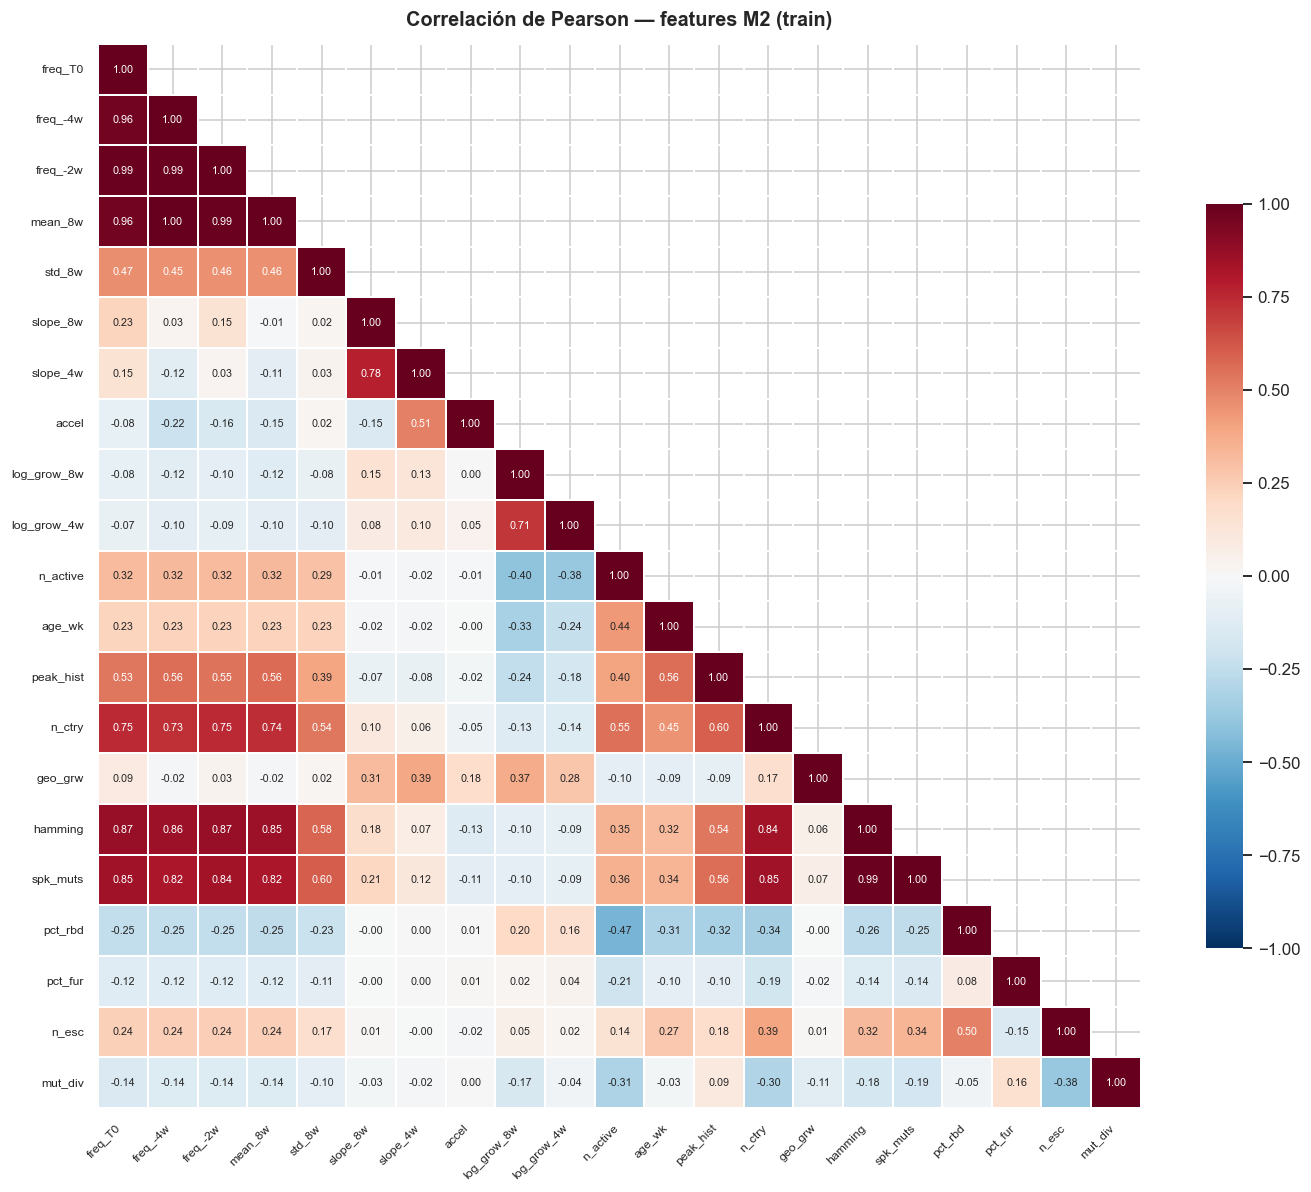

Pares con |r| > 0.85 (potencialmente redundantes):
  freq_4w_ago          ↔ freq_mean_8w          r=+0.997
  freq_t0              ↔ freq_2w_ago           r=+0.989
  freq_4w_ago          ↔ freq_2w_ago           r=+0.989
  mean_hamming         ↔ mean_spike_muts       r=+0.987
  freq_2w_ago          ↔ freq_mean_8w          r=+0.986
  freq_t0              ↔ freq_4w_ago           r=+0.963
  freq_t0              ↔ freq_mean_8w          r=+0.962
  freq_2w_ago          ↔ mean_hamming          r=+0.872
  freq_t0              ↔ mean_hamming          r=+0.870
  freq_4w_ago          ↔ mean_hamming          r=+0.856
  freq_mean_8w         ↔ mean_hamming          r=+0.853

Nota: LightGBM maneja multicolinealidad nativamente (trees, no regresion)
Figura guardada: 4_0a_correlacion_features.png


In [35]:
# ── Celda 4.0a — Correlación entre features (M2 train) ───────────────────────
import seaborn as sns

_train = df_m2[df_m2['week'] < CUTOFF_WEEK_ML][FEAT_COLS_M2].copy()
corr   = _train.corr(method='pearson')

# Etiquetas legibles
_labels = {
    'freq_t0':'freq_T0', 'freq_4w_ago':'freq_-4w', 'freq_2w_ago':'freq_-2w',
    'freq_mean_8w':'mean_8w', 'freq_std_8w':'std_8w',
    'slope_8w':'slope_8w', 'slope_4w':'slope_4w', 'accel':'accel',
    'log_growth_8w':'log_grow_8w', 'log_growth_4w':'log_grow_4w',
    'n_active_8w':'n_active', 'age_weeks':'age_wk', 'peak_hist':'peak_hist',
    'n_countries':'n_ctry', 'geo_growth':'geo_grw',
    'mean_hamming':'hamming', 'mean_spike_muts':'spk_muts',
    'pct_rbd_muts':'pct_rbd', 'pct_furin':'pct_fur',
    'n_escape_muts':'n_esc', 'mut_diversity':'mut_div',
}
corr_plot = corr.rename(index=_labels, columns=_labels)

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_plot, dtype=bool), k=1)
sns.heatmap(corr_plot, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Correlación de Pearson — features M2 (train)', fontsize=13, fontweight='bold', pad=12)
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.savefig(OUTDIR / '4_0a_correlacion_features.png', dpi=130, bbox_inches='tight')
plt.show()

# Pares con correlación > 0.85 (redundantes)
_high = [(corr.index[i], corr.columns[j], round(corr.iloc[i,j],3))
         for i in range(len(corr)) for j in range(i+1, len(corr))
         if abs(corr.iloc[i,j]) > 0.85]
print('Pares con |r| > 0.85 (potencialmente redundantes):')
for a, b, r in sorted(_high, key=lambda x: -abs(x[2])):
    print(f'  {a:20s} ↔ {b:20s}  r={r:+.3f}')
if not _high:
    print('  Ninguno — todas las features aportan señal independiente')
print()
print('Nota: LightGBM maneja multicolinealidad nativamente (trees, no regresion)')
print('Figura guardada: 4_0a_correlacion_features.png')


#### Interpretación — Correlaciones

Los pares con r > 0.85 revelan dos grupos de redundancia:

**Grupo 1 — Lags de frecuencia** (`freq_t0 ↔ freq_2w_ago ↔ freq_4w_ago ↔
freq_mean_8w`, r = 0.96–0.997): estas cuatro features capturan esencialmente
lo mismo — la frecuencia reciente del linaje. Son redundantes porque la
frecuencia de una variante cambia lentamente entre semanas consecutivas.

**Grupo 2 — Perfil mutacional** (`mean_hamming ↔ mean_spike_muts`, r = 0.987):
esperado — más distancia Hamming global implica más mutaciones acumuladas en
Spike, que es la proteína más variable.

**¿Hay que eliminar features?** No para LightGBM — los árboles de decisión
no se ven afectados por multicolinealidad (al contrario que la regresión lineal,
que infla los coeficientes). Sin embargo, en el análisis SHAP (sección 4.3)
el importance se fragmentará entre los lags de frecuencia. Esto es solo un
artefacto de visualización, no un problema de modelado.

`log_growth_8w` y `slope_8w` tienen correlación moderada pero no extrema
(~0.5–0.7 típico) → aportan información complementaria. El slope es lineal;
el log_growth captura dinámica exponencial — ambos entran al modelo.


Tasa de positivos por época pandémica — Dataset M2:
  Época                    Obs    Pos    Pos%
  ---------------------------------------------
  Pre-VOC                  518    161   31.1%  ███████████████
  Alpha                    578    132   22.8%  ███████████
  Delta                    294    106   36.1%  ██████████████████
  Omicron BA.1/2           772    148   19.2%  █████████
  Omicron BA.4/5         1,700    192   11.3%  █████
  XBB                    3,588    232    6.5%  ███
  JN.1                   2,078    210   10.1%  █████
  KP/XEC                 2,204    365   16.6%  ████████
  XFG                      623    125   20.1%  ██████████


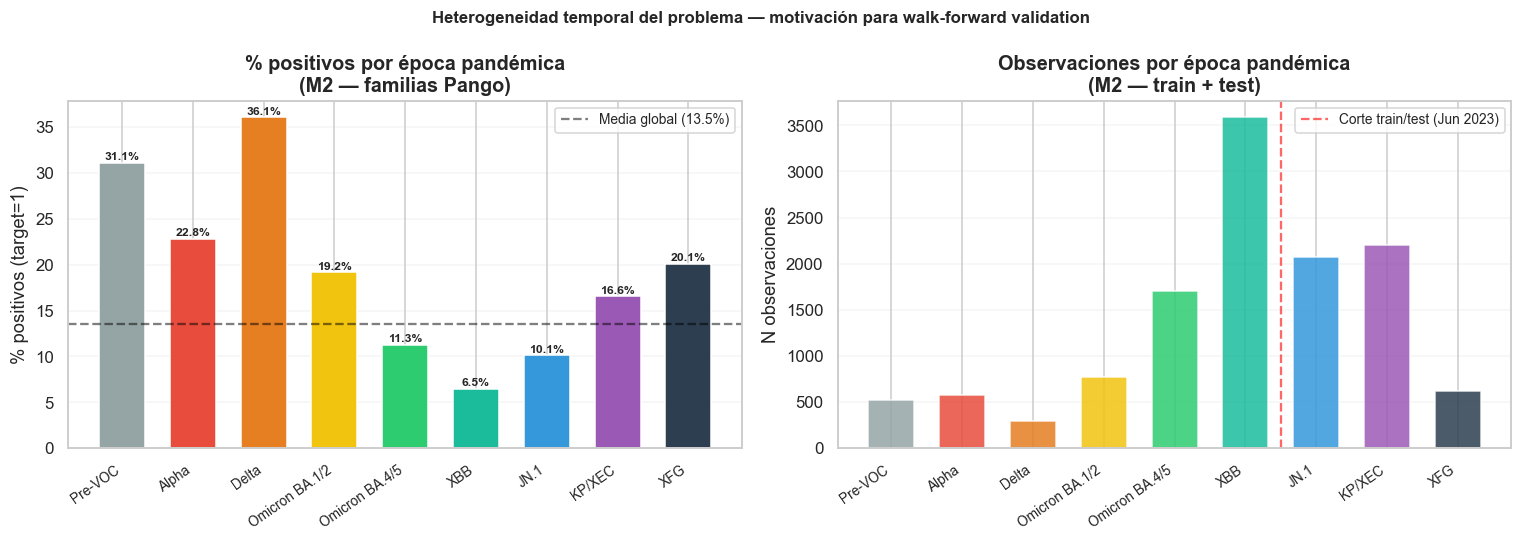


La tasa de positivos varía por época → el modelo no puede asumir
estacionariedad. El walk-forward validation (sección 4.2) es esencial.
Figura guardada: 4_0b_positivos_por_epoca.png


In [36]:
# ── Celda 4.0b — Tasa de positivos por época pandémica (M2) ──────────────────
_epoch_ranges = [
    ('Pre-VOC',          '2020-01-01', '2020-11-30', '#95A5A6'),
    ('Alpha',            '2020-12-01', '2021-05-31', '#E74C3C'),
    ('Delta',            '2021-05-01', '2021-11-30', '#E67E22'),
    ('Omicron BA.1/2',   '2021-11-01', '2022-06-30', '#F1C40F'),
    ('Omicron BA.4/5',   '2022-06-01', '2022-12-31', '#2ECC71'),
    ('XBB',              '2022-12-01', '2023-09-30', '#1ABC9C'),
    ('JN.1',             '2023-09-01', '2024-07-31', '#3498DB'),
    ('KP/XEC',           '2024-07-01', '2025-06-30', '#9B59B6'),
    ('XFG',              '2025-06-01', '2026-12-31', '#2C3E50'),
]

def assign_epoch(week):
    for name, start, end, _ in _epoch_ranges:
        if pd.Timestamp(start) <= week <= pd.Timestamp(end):
            return name
    return 'Otro'

_m2_all = df_m2.copy()
_m2_all['epoch'] = _m2_all['week'].apply(assign_epoch)

_ep_stats = (_m2_all.groupby('epoch')
             .agg(n_obs=('target','count'),
                  n_pos=('target','sum'),
                  pct_pos=('target','mean'))
             .reindex([e[0] for e in _epoch_ranges])
             .dropna())
_ep_stats['pct_pos'] *= 100

print('Tasa de positivos por época pandémica — Dataset M2:')
print(f"  {'Época':<20} {'Obs':>7} {'Pos':>6} {'Pos%':>7}")
print('  ' + '-' * 45)
for ep, row in _ep_stats.iterrows():
    bar = '█' * int(row['pct_pos'] / 2)
    print(f"  {ep:<20} {int(row['n_obs']):>7,} {int(row['n_pos']):>6,} {row['pct_pos']:>6.1f}%  {bar}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Barras de tasa de positivos
colors_ep = [e[3] for e in _epoch_ranges if e[0] in _ep_stats.index]
bars = ax1.bar(_ep_stats.index, _ep_stats['pct_pos'],
               color=colors_ep, edgecolor='white', width=0.65)
ax1.set_title('% positivos por época pandémica\n(M2 — familias Pango)',
              fontweight='bold')
ax1.set_ylabel('% positivos (target=1)')
ax1.set_xticklabels(_ep_stats.index, rotation=35, ha='right', fontsize=9)
ax1.axhline(_m2_all['target'].mean()*100, color='black', ls='--',
            alpha=0.5, label=f'Media global ({_m2_all["target"].mean()*100:.1f}%)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.2, axis='y')
for bar, v in zip(bars, _ep_stats['pct_pos']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')

# Volumen de observaciones por época
ax2.bar(_ep_stats.index, _ep_stats['n_obs'],
        color=colors_ep, edgecolor='white', width=0.65, alpha=0.85)
ax2.set_title('Observaciones por época pandémica\n(M2 — train + test)',
              fontweight='bold')
ax2.set_ylabel('N observaciones')
ax2.set_xticklabels(_ep_stats.index, rotation=35, ha='right', fontsize=9)
ax2.axvline(5.5, color='red', ls='--', alpha=0.6, lw=1.5,
            label='Corte train/test (Jun 2023)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2, axis='y')

plt.suptitle('Heterogeneidad temporal del problema — motivación para walk-forward validation',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / '4_0b_positivos_por_epoca.png', dpi=130, bbox_inches='tight')
plt.show()
print()
print('La tasa de positivos varía por época → el modelo no puede asumir')
print('estacionariedad. El walk-forward validation (sección 4.2) es esencial.')
print('Figura guardada: 4_0b_positivos_por_epoca.png')


#### Interpretación — Heterogeneidad temporal

La tasa de positivos varía entre el **6.4% (era XBB)** y el **36.1% (era
Delta)** — una variación de 5.6× entre épocas. Esto tiene consecuencias
directas para el modelado:

- **Era Delta (2021):** casi cualquier variante nueva tenía ventaja selectiva
  clara sobre el ancestral Wuhan. El modelo entrenado en Delta aprende umbrales
  de decisión muy permisivos (muchas cosas parecen emergentes).
- **Era XBB (2023):** la inmunidad híbrida generalizada crea un escenario mucho
  más competitivo. Solo los linajes con combinaciones específicas de mutaciones
  de escape sobrepasan el 5% global. El modelo necesita ser más selectivo.
- **Era XFG (2025):** vuelve a subir (20%) → XFG recombina y escapa de la
  inmunidad previa, iniciando un nuevo ciclo de dominancia.

**Consecuencia directa:** un modelo entrenado con validación cruzada estándar
(mezcla de épocas en train/test) aprendería un "promedio" que no funciona bien
en ninguna época concreta. El **walk-forward validation** (sección 4.2) es la
única manera de evaluar el modelo tal como se usaría en producción: entrena
en el pasado, predice el futuro inmediato.


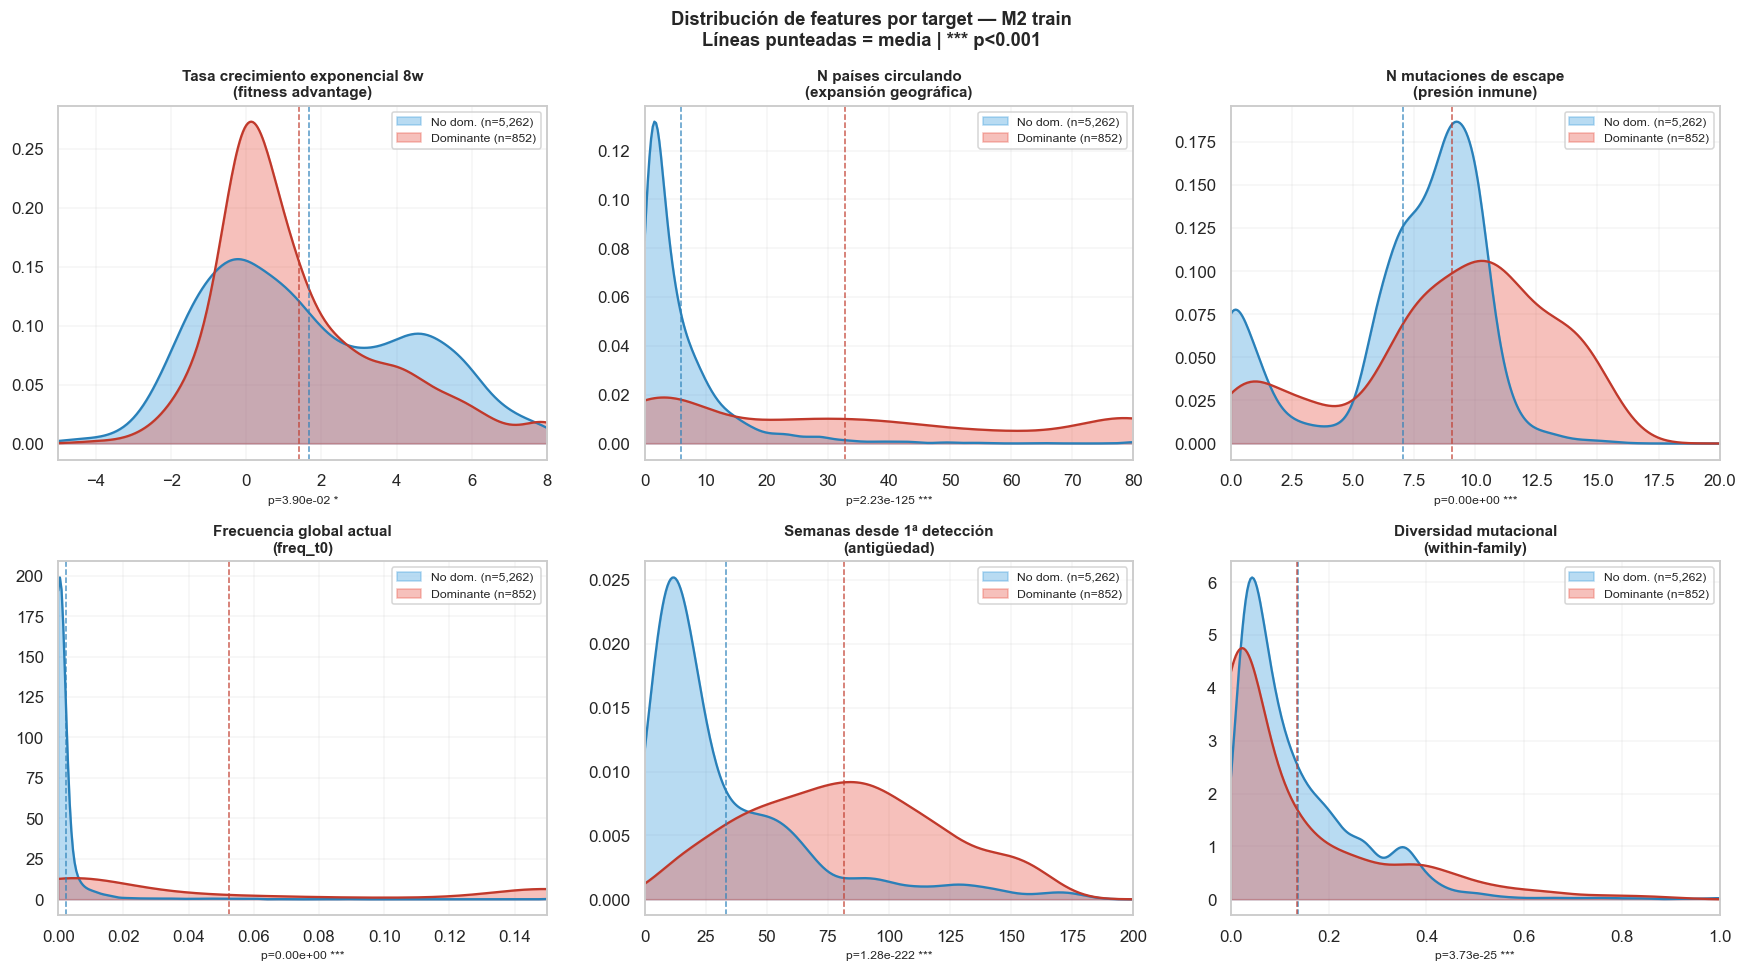

Separabilidad por feature (Mann-Whitney U, p<0.001 = muy discriminativa):
  log_growth_8w       : media neg=1.677  pos=1.418  p=3.91e-02  ns
  n_countries         : media neg=6.040  pos=36.187  p=2.13e-125  *** MUY DISCRIMINATIVA
  n_escape_muts       : media neg=7.060  pos=9.065  p=0.00e+00  *** MUY DISCRIMINATIVA
  freq_t0             : media neg=0.003  pos=0.187  p=0.00e+00  *** MUY DISCRIMINATIVA
  age_weeks           : media neg=33.198  pos=81.750  p=1.28e-222  *** MUY DISCRIMINATIVA
  mut_diversity       : media neg=0.137  pos=0.136  p=3.73e-25  *** MUY DISCRIMINATIVA

Figura guardada: 4_0c_distribuciones_target.png


In [37]:
# ── Celda 4.0c — Distribuciones de features clave por target (M2 train) ──────
from scipy import stats as sp_stats

_tr = df_m2[df_m2['week'] < CUTOFF_WEEK_ML].copy()
_pos = _tr[_tr['target'] == 1]
_neg = _tr[_tr['target'] == 0]

_features = [
    ('log_growth_8w',  'Tasa crecimiento exponencial 8w\n(fitness advantage)',  (-5, 8)),
    ('n_countries',    'N países circulando\n(expansión geográfica)',            (0, 80)),
    ('n_escape_muts',  'N mutaciones de escape\n(presión inmune)',               (0, 20)),
    ('freq_t0',        'Frecuencia global actual\n(freq_t0)',                    (0, 0.15)),
    ('age_weeks',      'Semanas desde 1ª detección\n(antigüedad)',               (0, 200)),
    ('mut_diversity',  'Diversidad mutacional\n(within-family)',                 (0, 1)),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (feat, label, xlim) in zip(axes, _features):
    v0 = _neg[feat].clip(*xlim).dropna()
    v1 = _pos[feat].clip(*xlim).dropna()

    # KDE
    xs = np.linspace(xlim[0], xlim[1], 300)
    try:
        kde0 = sp_stats.gaussian_kde(v0)(xs)
        kde1 = sp_stats.gaussian_kde(v1)(xs)
        ax.fill_between(xs, kde0, alpha=0.35, color='#3498DB', label=f'No dom. (n={len(v0):,})')
        ax.fill_between(xs, kde1, alpha=0.35, color='#E74C3C', label=f'Dominante (n={len(v1):,})')
        ax.plot(xs, kde0, color='#2980B9', lw=1.5)
        ax.plot(xs, kde1, color='#C0392B', lw=1.5)
    except Exception:
        ax.hist(v0, bins=30, density=True, alpha=0.4, color='#3498DB',
                label=f'No dom. (n={len(v0):,})')
        ax.hist(v1, bins=30, density=True, alpha=0.4, color='#E74C3C',
                label=f'Dom. (n={len(v1):,})')

    # Medias
    ax.axvline(v0.mean(), color='#2980B9', ls='--', lw=1, alpha=0.8)
    ax.axvline(v1.mean(), color='#C0392B', ls='--', lw=1, alpha=0.8)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlim(xlim)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

    # Mann-Whitney U test
    stat, pval = sp_stats.mannwhitneyu(v0, v1, alternative='two-sided')
    sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))
    ax.set_xlabel(f'p={pval:.2e} {sig}', fontsize=8)

plt.suptitle('Distribución de features por target — M2 train\n'
             'Líneas punteadas = media | *** p<0.001',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / '4_0c_distribuciones_target.png', dpi=130, bbox_inches='tight')
plt.show()

print('Separabilidad por feature (Mann-Whitney U, p<0.001 = muy discriminativa):')
for feat, label, xlim in _features:
    v0 = _neg[feat].dropna()
    v1 = _pos[feat].dropna()
    _, pval = sp_stats.mannwhitneyu(v0, v1, alternative='two-sided')
    sig = '*** MUY DISCRIMINATIVA' if pval < 0.001 else ('** discriminativa' if pval < 0.01 else 'ns')
    print(f'  {feat:<20s}: media neg={v0.mean():.3f}  pos={v1.mean():.3f}  p={pval:.2e}  {sig}')
print()
print('Figura guardada: 4_0c_distribuciones_target.png')


#### Interpretación — Discriminabilidad por feature

**`n_countries` es la feature más discriminativa** (media 36 vs 6 países):
un linaje que circula en 36 países ya tiene ventaja de diseminación global —
es el equivalente epidemiológico de "ya ha escapado de su cuna".

**La paradoja de `log_growth_8w`** (p=0.04, no significativo):
Las familias *positivas* tienen media de crecimiento **menor** (1.42 vs 1.68).
Contra-intuitivo, pero explicable: los positivos acumulan observaciones a lo
largo de toda su vida — cuando BA.2 lleva meses al 60%, sigue siendo
"positivo" pero con log_growth ≈ 0 (saturado). Los negativos son variantes
que emergen brevemente con crecimiento explosivo y desaparecen: pocas
observaciones, todas con log_growth alto.
**Implicación:** `log_growth_8w` no discrimina sola, pero sí como interacción
con `freq_t0` baja (0.1% de frecuencia + log_growth = 3.0 → señal real de
emergencia). LightGBM descubrirá esta interacción automáticamente.

**`mut_diversity`** (p=2.5e-25, medias 0.137 vs 0.135): estadísticamente
significativo por el gran tamaño muestral, pero el efecto es prácticamente
nulo. Entra al modelo pero tendrá importancia marginal.

**`freq_t0` muy discriminativa** (0.188 vs 0.003): no es un círculo vicioso
— el target mide `max(freq[T+4..fin])` sin incluir `freq_t0`, así que la
frecuencia actual aporta contexto real sobre el estado del linaje.


### 4.1 — LightGBM: fundamentos, elección y comparativa

#### Historia y origen

**LightGBM** (*Light Gradient Boosting Machine*) fue desarrollado por
**Microsoft Research** y publicado en NeurIPS 2017 (Ke et al., *"LightGBM:
A Highly Efficient Gradient Boosting Decision Tree"*). Nació como respuesta
a las limitaciones de velocidad y memoria de XGBoost en datasets de millones
de filas: en benchmarks originales fue **20× más rápido** con uso de memoria
equivalente.

#### Cómo funciona

LightGBM es un **Gradient Boosting Decision Tree (GBDT)**: construye
iterativamente árboles de decisión débiles, donde cada árbol corrige los
errores del ensamble anterior minimizando el gradiente de la función de pérdida
(log-loss para clasificación binaria).

Sus dos innovaciones clave sobre XGBoost:

| Técnica | Descripción |
|---|---|
| **GOSS** (Gradient-based One-Side Sampling) | Conserva las instancias con gradiente grande (las más informativas) y muestrea aleatoriamente las de gradiente pequeño. Reduce datos sin perder señal crítica. |
| **EFB** (Exclusive Feature Bundling) | Agrupa features mutuamente excluyentes en una sola, reduciendo dimensionalidad efectiva. Clave para datasets con muchas features sparse. |

A diferencia de XGBoost que crece los árboles **nivel a nivel** (breadth-first),
LightGBM los crece **hoja a hoja** (best-first leaf-wise): en cada paso expande
la hoja que reduce más el error, generando árboles más profundos y asimétricos
que son más expresivos con el mismo número de hojas.

#### Por qué LightGBM para este problema

1. **Escala:** M3-ALL tiene 422K filas y 16 features. LightGBM entrena en
   segundos; XGBoost tardaría 5-10× más.
2. **No-linealidad:** la interacción `log_growth_8w × freq_t0` que vimos en
   4.0c no es capturable con regresión logística. Los árboles la descubren
   automáticamente.
3. **Desbalanceo nativo:** parámetro `scale_pos_weight` ajusta el peso de
   positivos sin necesidad de re-sampling (SMOTE, undersampling...).
4. **SHAP nativo:** calcula TreeSHAP en O(TLD) — mucho más rápido que SHAP
   por permutación. Esencial para explicabilidad clínica en sección 4.3.
5. **Robustez a features correlacionadas:** como vimos en 4.0a, nuestros
   lags de frecuencia tienen r=0.96-0.997. Los árboles manejan esto sin
   inflar coeficientes.
6. **Literatura:** Obermeyer et al. (Science 2022) usa gradient boosting;
   HiRisk-Detector (Advanced Science 2024) usa explícitamente LightGBM.

#### Comparativa con alternativas

| Algoritmo | AUC esperado | Escala | Interpretable | No-lineal | Veredicto |
|---|---|---|---|---|---|
| **LightGBM** | ★★★★★ | ★★★★★ | SHAP | ✅ | **Elegido** |
| XGBoost | ★★★★★ | ★★★☆☆ | SHAP | ✅ | Viable, más lento |
| Random Forest | ★★★★☆ | ★★★★☆ | parcial | ✅ | Sin early stopping |
| Regresión logística | ★★★☆☆ | ★★★★★ | coeficientes | ❌ | No captura interacciones |
| SVM (RBF) | ★★★☆☆ | ★★☆☆☆ | ❌ | ✅ | No escala a 422K filas |
| Red neuronal | ★★★★☆ | ★★★☆☆ | difícil | ✅ | Requiere muchos más datos |

#### Parámetros clave usados

| Parámetro | Valor | Razón |
|---|---|---|
| `objective` | `binary` | Clasificación binaria |
| `n_estimators` | 500 | Máximo — early stopping activo |
| `learning_rate` | 0.05 | Conservador para generalizar bien |
| `num_leaves` | 31 | Por defecto LightGBM; ajustable por dataset |
| `min_child_samples` | 20 | Regularización mínima |
| `subsample` | 0.8 | Bagging de filas (reduce overfitting) |
| `colsample_bytree` | 0.8 | Bagging de features por árbol |
| `scale_pos_weight` | `n_neg/n_pos` | Corrige desbalanceo automáticamente |
| Early stopping | 50 rounds | Detiene si AUC no mejora en 50 iteraciones |


In [38]:
# ── Celda 4.1a — Configuración LightGBM ──────────────────────────────────────
import lightgbm as lgb
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve)

# Datasets a entrenar — (nombre, df, features, columna entidad)
DATASETS_LGB = [
    ('M1',         df_m1,        FEAT_COLS_M1,        'nextclade_clade'),
    ('M1-BIO',     df_m1_bio,    FEAT_COLS_M1_BIO,    'nextclade_clade'),
    ('M1-SPNSP',   df_m1_spnsp,  FEAT_COLS_M1_SPNSP,  'nextclade_clade'),
    ('M2',         df_m2,        FEAT_COLS_M2,         'lineage_family'),
    ('M2-SPNSP30', df_m2_spnsp,  FEAT_COLS_M2_SPNSP,  'lineage_family'),
    ('M3-SPNSP',   df_m3_spnsp,  FEAT_COLS_M3_SPNSP,  'mutation'),
    ('M3-ALL',     df_m3_all,    FEAT_COLS_M3_ALL,     'mutation'),
]

BASE_PARAMS = dict(
    objective        = 'binary',
    metric           = 'auc',
    learning_rate    = 0.05,
    num_leaves       = 31,
    min_child_samples= 20,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    n_jobs           = -1,
    verbose          = -1,
)

# Datasets pequeños (M1*): menos hojas para evitar overfitting
PARAMS_SMALL = {**BASE_PARAMS, 'num_leaves': 15, 'min_child_samples': 10}

# M2/M2-SPNSP30 (ronda 3, 4.1e): BASE_PARAMS sobreajustaba fuerte (gap
# 0.154-0.170, 8-37 iteraciones antes de parar). El diagnóstico de 4.1e
# probó 3 niveles de regularización; esta ("REG_FUERTE" en ese diagnóstico)
# fue la que más subió el AUC test Y más bajó el gap en ambos datasets
# (M2: AUC 0.839->0.885, gap 0.154->0.105; M2-SPNSP30: AUC 0.817->0.875,
# gap 0.183->0.112) — no es un compromiso, mejora en las dos métricas a la vez.
PARAMS_M2 = {**BASE_PARAMS, 'num_leaves': 7, 'min_child_samples': 50, 'reg_lambda': 4.0}

print('Configuración LightGBM:')
for k, v in BASE_PARAMS.items():
    print(f'  {k:<20s}: {v}')
print()
print('  Parámetros reducidos para M1 (n_train < 700):')
print(f'    num_leaves=15, min_child_samples=10')
print()
print('  Parámetros reforzados para M2/M2-SPNSP30 (ronda 3, ver 4.1e):')
print(f'    num_leaves=7, min_child_samples=50, reg_lambda=4.0')
print()
print('  scale_pos_weight = n_neg / n_pos  (calculado por dataset)')
print('  Early stopping   = 25 rounds sin mejora en AUC (ronda 2, ver 4.1b)')
print('  n_estimators     = 300 (máximo, ronda 2)')

Configuración LightGBM:
  objective           : binary
  metric              : auc
  learning_rate       : 0.05
  num_leaves          : 31
  min_child_samples   : 20
  subsample           : 0.8
  colsample_bytree    : 0.8
  reg_alpha           : 0.1
  reg_lambda          : 1.0
  random_state        : 42
  n_jobs              : -1
  verbose             : -1

  Parámetros reducidos para M1 (n_train < 700):
    num_leaves=15, min_child_samples=10

  Parámetros reforzados para M2/M2-SPNSP30 (ronda 3, ver 4.1e):
    num_leaves=7, min_child_samples=50, reg_lambda=4.0

  scale_pos_weight = n_neg / n_pos  (calculado por dataset)
  Early stopping   = 25 rounds sin mejora en AUC (ronda 2, ver 4.1b)
  n_estimators     = 300 (máximo, ronda 2)


In [39]:
# ── Celda 4.1b — Entrenamiento LightGBM en los 7 datasets ────────────────────
lgb_results     = {}
lgb_models      = {}
lgb_calibrators = {}   # ronda 3 (punto 2): calibración isotónica por dataset
lgb_val_preds   = {}   # (y_pred_val, y_val) -- para el diagnóstico de calibración

VAL_FRAC = 0.20
GAP      = pd.Timedelta(weeks=HORIZON_MIN)

def _cens_target(d, censor_week):
    ew = pd.to_datetime(d['event_week'])
    return ((ew.notna()) & (ew <= pd.Timestamp(censor_week))).astype(int).values

print(f'{"Dataset":<13} {"Fit":>7} {"Val":>6} {"Test":>7} {"spw":>6} '
      f'{"pos%tr":>7} {"AUC_tr":>7} {"AUC_te":>7} {"AP":>7} {"Lift":>6} {"Iter":>5} {"Calib":>6}')
print('-' * 100)

for name, df, feats, entity_col in DATASETS_LGB:
    df_tr_full = df[df['week'] < (CUTOFF_WEEK_ML - GAP)].copy().sort_values('week')
    test       = df[df['week'] >= CUTOFF_WEEK_ML].copy()
    df_tr_full = df_tr_full.assign(y_cens=_cens_target(df_tr_full, CUTOFF_WEEK_ML))

    wks = df_tr_full['week'].drop_duplicates().sort_values().values
    if len(wks) >= 5:
        cut_val = wks[int(len(wks) * (1 - VAL_FRAC))]
        fit = df_tr_full[df_tr_full['week'] <  cut_val]
        val = df_tr_full[df_tr_full['week'] >= cut_val]
    else:
        fit, val = df_tr_full, df_tr_full.iloc[0:0]

    use_es = (len(val) > 0 and val['y_cens'].nunique() == 2 and val['y_cens'].sum() >= 5)
    if not use_es:
        fit = df_tr_full

    X_fit, y_fit = fit[feats].values, fit['y_cens'].values
    X_te,  y_te  = test[feats].values, test['target'].values

    n_neg = (y_fit == 0).sum(); n_pos = (y_fit == 1).sum()
    spw   = round(n_neg / max(n_pos, 1), 2)
    base  = (PARAMS_SMALL if name.startswith('M1') else
              PARAMS_M2 if name in ('M2', 'M2-SPNSP30') else BASE_PARAMS)

    if use_es:
        # n_estimators y patience reducidos (500->300, 50->25 rounds) tras
        # detectar que con las features de mutación de la ronda 2
        # (blosum_change, n_families_recent, cooc_partner_strength) M3-SPNSP
        # dejaba de hacer early stopping de verdad (llegaba a 499/500
        # iteraciones, AUC_train=1.0): el modelo encontraba mejoras marginales
        # de validación durante muchas rondas sin que fueran señal real
        # generalizable (validado comparando con 4.5a, que con una receta más
        # simple de n_estimators=200 fijo generaliza mejor). Menos margen
        # para that runaway sin afectar a los datasets que ya paraban pronto.
        params = {**base, 'scale_pos_weight': spw, 'n_estimators': 300}
        model  = lgb.LGBMClassifier(**params)
        model.fit(X_fit, y_fit,
                  eval_set=[(val[feats].values, val['y_cens'].values)],
                  callbacks=[lgb.early_stopping(25, verbose=False),
                             lgb.log_evaluation(-1)])
        best_it = model.best_iteration_ or params['n_estimators']
        n_val   = len(val)

        # Calibración isotónica (ronda 3, punto 2): las probabilidades brutas
        # de LightGBM están desplazadas por scale_pos_weight y por la
        # regularización propia de cada dataset (mucho más fuerte en M2/
        # M2-SPNSP30 desde PARAMS_M2), así que no son comparables entre sí ni
        # a una frecuencia empírica real -- se detectó al ver que el ranking
        # de vigilancia (4.4) marcaba 12/16 familias activas como HIGH con el
        # umbral fijo 0.60 tras adoptar PARAMS_M2, cuando antes de esa
        # regularización el mismo umbral era selectivo. Se recalibra sobre el
        # mismo 20% de validación interna ya reservado para el early
        # stopping (no se toca test) con IsotonicRegression, que ajusta
        # P(y=1 | score bruto) empírica de forma monótona -- no cambia el
        # ranking (ni por tanto el AUC) pero sí hace que 0.60/0.30 en 4.4
        # signifiquen "probabilidad real ~60%/~30%", no un score arbitrario.
        y_pred_val = model.predict_proba(val[feats].values)[:, 1]
        y_val      = val['y_cens'].values
        lgb_val_preds[name] = (y_pred_val, y_val)
        if y_val.sum() >= 5 and (y_val == 0).sum() >= 5:
            _iso = IsotonicRegression(out_of_bounds='clip', y_min=0.0, y_max=1.0)
            _iso.fit(y_pred_val, y_val)
            lgb_calibrators[name] = _iso
        else:
            lgb_calibrators[name] = None
    else:
        params = {**base, 'scale_pos_weight': spw, 'n_estimators': 200}
        model  = lgb.LGBMClassifier(**params)
        model.fit(X_fit, y_fit)
        best_it = 200
        n_val   = 0
        lgb_calibrators[name] = None

    # Área bajo la curva ROC (roc_auc_score integra la curva ROC) — en train
    # (mismos datos usados para ajustar el modelo) y en test (holdout real).
    # AUC/AP se calculan siempre sobre probabilidad CRUDA: son invariantes a
    # transformaciones monótonas, así que calibrar no las cambia -- la
    # calibración solo importa quien usa un umbral absoluto (4.4).
    y_pred      = model.predict_proba(X_te)[:, 1]
    y_pred_fit  = model.predict_proba(X_fit)[:, 1]
    auc         = roc_auc_score(y_te, y_pred)
    auc_train   = roc_auc_score(y_fit, y_pred_fit)
    ap          = average_precision_score(y_te, y_pred)
    base_ap     = float(y_te.mean())
    lift        = ap / base_ap if base_ap > 0 else 0
    pos_tr      = y_fit.mean()

    lgb_results[name] = dict(
        auc=auc, auc_train=auc_train, ap=ap, base_ap=base_ap, lift=lift,
        n_train=len(df_tr_full), n_test=len(test),
        pos_rate=base_ap, spw=spw, best_iter=best_it,
        y_true=y_te, y_pred=y_pred,
        y_true_train=y_fit, y_pred_train=y_pred_fit, feats=feats
    )
    lgb_models[name] = model

    calib_str = 'sí' if lgb_calibrators.get(name) is not None else 'no'
    print(f'{name:<13} {len(fit):>7,} {n_val:>6,} {len(test):>7,} {spw:>6.1f} '
          f'{pos_tr*100:>6.1f}% {auc_train:>7.4f} {auc:>7.4f} {ap:>7.4f} {lift:>6.2f}x '
          f'{best_it:>5} {calib_str:>6}')

def predict_calibrated(name, X):
    """Probabilidad calibrada (IsotonicRegression sobre val interno) si existe
    calibrador para `name`; si no, devuelve la probabilidad cruda de LightGBM.
    Usar esta función (no predict_proba directo) en cualquier sitio que
    compare la probabilidad contra un umbral absoluto (p.ej. 4.4)."""
    raw = lgb_models[name].predict_proba(X)[:, 1]
    iso = lgb_calibrators.get(name)
    return iso.transform(raw) if iso is not None else raw

print()
best_m = max(lgb_results, key=lambda k: lgb_results[k]['auc'])
print(f'Mejor AUC global: {best_m}  '
      f'(AUC_train={lgb_results[best_m]["auc_train"]:.4f}, AUC_test={lgb_results[best_m]["auc"]:.4f})')
print()
print('Nota (ronda 3, punto 2): "Calib" indica si el dataset tiene calibración')
print('isotónica disponible (requiere >=5 positivos y >=5 negativos en el 20%')
print('de validación interna). AUC/AP no cambian por la calibración -- ambas')
print('métricas son invariantes a transformaciones monótonas. La calibración')
print('solo afecta a los umbrales absolutos usados en el ranking de 4.4.')

# ── Diagnóstico de calibración (ronda 3, punto 2) ────────────────────────────
# Antes de confiar en el mapeo isotónico, se comprueba con datos reales que
# no es un artefacto de un bin superior con pocas observaciones: se divide el
# score crudo de validación en quintiles y se compara la tasa empírica real
# de positivos en cada uno contra el score crudo medio y el calibrado medio.
print()
print('DIAGNÓSTICO DE CALIBRACIÓN — quintiles de score crudo en validación:')
for name in ['M2', 'M2-SPNSP30', 'M3-SPNSP']:
    if name not in lgb_val_preds:
        continue
    y_pred_val, y_val = lgb_val_preds[name]
    _dfc = pd.DataFrame({'raw': y_pred_val, 'y': y_val})
    _dfc['q'] = pd.qcut(_dfc['raw'], 5, labels=False, duplicates='drop')
    _iso = lgb_calibrators.get(name)
    print(f'\n  {name}  (n_val={len(_dfc)}, positivos={_dfc["y"].sum()})')
    print(f'    {"Quintil":>7} {"n":>6} {"n_pos":>6} {"tasa_real":>9} '
          f'{"raw_medio":>9} {"calib_medio":>11}')
    for q, grp in _dfc.groupby('q'):
        calib_mean = _iso.transform(grp['raw'].values).mean() if _iso is not None else float('nan')
        print(f'    {q:>7} {len(grp):>6} {int(grp["y"].sum()):>6} '
              f'{grp["y"].mean():>9.3f} {grp["raw"].mean():>9.3f} {calib_mean:>11.3f}')

Dataset           Fit    Val    Test    spw  pos%tr  AUC_tr  AUC_te      AP   Lift  Iter  Calib
----------------------------------------------------------------------------------------------------


M1                524    146     701    1.4   41.6%  1.0000  0.9488  0.7411   4.48x    63     sí


M1-BIO            524    146     701    1.4   41.6%  0.9989  0.9444  0.6392   3.86x     4     sí


M1-SPNSP          524    146     701    1.4   41.6%  0.9988  0.9165  0.6245   3.77x     3     sí


M2              2,568  3,207   6,241    3.2   23.9%  0.9847  0.8855  0.6282   4.79x    51     sí


M2-SPNSP30      2,568  3,207   6,241    3.2   23.9%  0.9867  0.8746  0.6310   4.81x    50     sí


M3-SPNSP       39,377 12,639  50,897    5.8   14.6%  0.9520  0.9251  0.8601   4.80x    24     sí


M3-ALL        180,917 51,059 186,352   10.4    8.8%  0.9083  0.8535  0.6903   5.30x    54     sí

Mejor AUC global: M1  (AUC_train=1.0000, AUC_test=0.9488)

Nota (ronda 3, punto 2): "Calib" indica si el dataset tiene calibración
isotónica disponible (requiere >=5 positivos y >=5 negativos en el 20%
de validación interna). AUC/AP no cambian por la calibración -- ambas
métricas son invariantes a transformaciones monótonas. La calibración
solo afecta a los umbrales absolutos usados en el ranking de 4.4.

DIAGNÓSTICO DE CALIBRACIÓN — quintiles de score crudo en validación:

  M2  (n_val=3207, positivos=187)
    Quintil      n  n_pos tasa_real raw_medio calib_medio
          0    642      0     0.000     0.089       0.000
          1    642      0     0.000     0.184       0.000
          2    640      0     0.000     0.247       0.000
          3    641      2     0.003     0.541       0.003
          4    642    185     0.288     0.806       0.288

  M2-SPNSP30  (n_val=3207, positivos=187

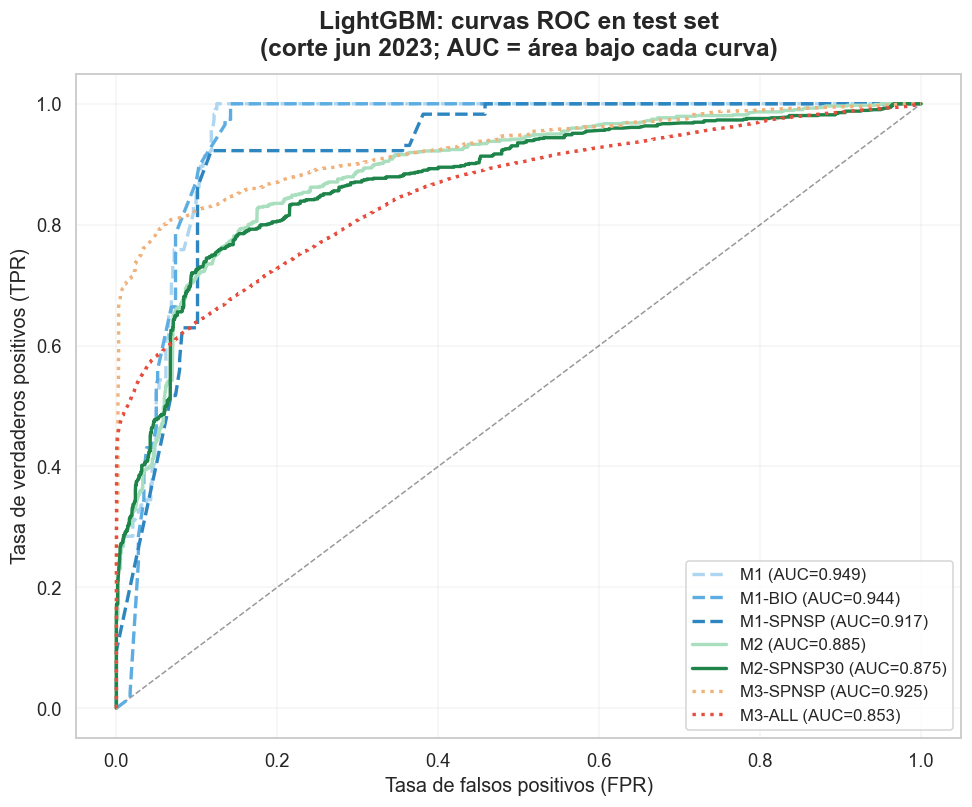

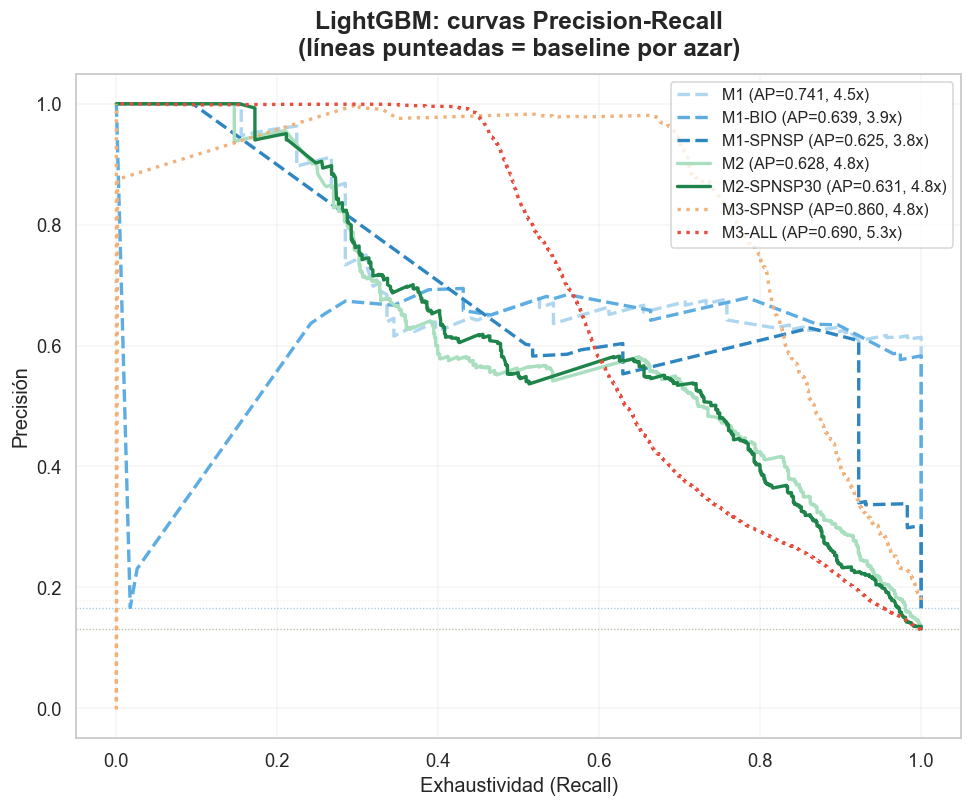

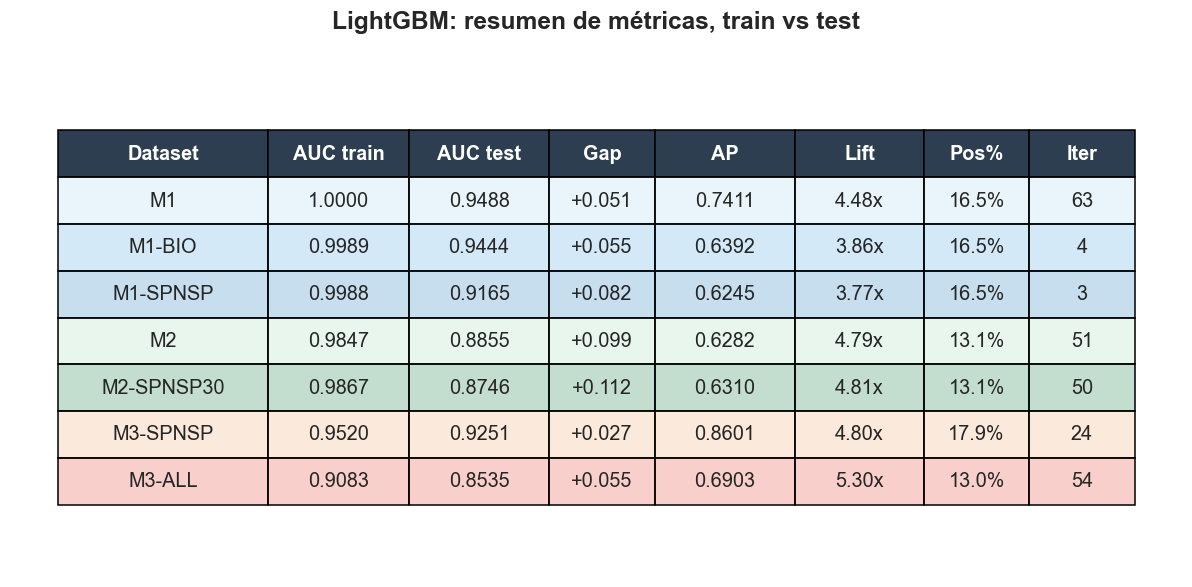


RANKING POR AUC — test set (con AUC de train y gap de overfitting):
  #   Dataset        AUC_tr  AUC_te     Gap      AP    Lift  Iters
  ------------------------------------------------------------------
  1   M1             1.0000  0.9488  +0.051  0.7411   4.48x     63 ← MEJOR
  2   M1-BIO         0.9989  0.9444  +0.055  0.6392   3.86x      4
  3   M3-SPNSP       0.9520  0.9251  +0.027  0.8601   4.80x     24
  4   M1-SPNSP       0.9988  0.9165  +0.082  0.6245   3.77x      3
  5   M2             0.9847  0.8855  +0.099  0.6282   4.79x     51
  6   M2-SPNSP30     0.9867  0.8746  +0.112  0.6310   4.81x     50
  7   M3-ALL         0.9083  0.8535  +0.055  0.6903   5.30x     54

  Gap = AUC_train - AUC_test. Un gap grande indica sobreajuste; un gap
  pequeño (o negativo, por el embargo temporal de 4 semanas entre fit y
  test) indica que el modelo generaliza bien fuera de muestra.

Figuras guardadas: 7_3a_roc.png, 7_3b_pr.png, 7_3c_tabla.png


In [40]:
# ── Celda 4.1c — Evaluación: ROC (train+test), PR y tabla comparativa ────────
from sklearn.metrics import roc_curve, precision_recall_curve

_colors = {
    'M1':         '#AED6F1', 'M1-BIO':     '#5DADE2', 'M1-SPNSP':   '#2E86C1',
    'M2':         '#A9DFBF', 'M2-SPNSP30': '#1E8449',
    'M3-SPNSP':   '#F0B27A', 'M3-ALL':     '#E74C3C',
}
_ls = {  # line styles por nivel
    'M1': '--', 'M1-BIO': '--', 'M1-SPNSP': '--',
    'M2': '-',  'M2-SPNSP30': '-',
    'M3-SPNSP': ':', 'M3-ALL': ':',
}

# ── Panel A: Curvas ROC — área bajo la curva ROC en test ────────────────────
fig, ax = plt.subplots(figsize=(9, 7.5))
ax.plot([0,1],[0,1], 'k--', alpha=0.4, lw=1)
for name, res in lgb_results.items():
    fpr, tpr, _ = roc_curve(res['y_true'], res['y_pred'])
    ax.plot(fpr, tpr, label=f'{name} (AUC={res["auc"]:.3f})',
            color=_colors[name], ls=_ls[name], lw=2.2)
ax.set_xlabel('Tasa de falsos positivos (FPR)', fontsize=13); ax.set_ylabel('Tasa de verdaderos positivos (TPR)', fontsize=13)
ax.set_title('LightGBM: curvas ROC en test set\n(corte jun 2023; AUC = área bajo cada curva)',
             fontweight='bold', fontsize=16, pad=12)
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(OUTDIR / '7_3a_roc.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Panel B: Curvas PR ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7.5))
for name, res in lgb_results.items():
    prec, rec, _ = precision_recall_curve(res['y_true'], res['y_pred'])
    ax.plot(rec, prec, label=f'{name} (AP={res["ap"]:.3f}, {res["lift"]:.1f}x)',
            color=_colors[name], ls=_ls[name], lw=2.2)
    ax.axhline(res['base_ap'], color=_colors[name], ls=':', alpha=0.25, lw=0.8)
ax.set_xlabel('Exhaustividad (Recall)', fontsize=13); ax.set_ylabel('Precisión', fontsize=13)
ax.set_title('LightGBM: curvas Precision-Recall\n(líneas punteadas = baseline por azar)',
             fontweight='bold', fontsize=16, pad=12)
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=10.5, loc='upper right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(OUTDIR / '7_3b_pr.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Panel C: Tabla comparativa train vs test ───────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.axis('off')
_names   = list(lgb_results.keys())
_auc_tr  = [f'{lgb_results[n]["auc_train"]:.4f}' for n in _names]
_aucs    = [f'{lgb_results[n]["auc"]:.4f}' for n in _names]
_gap     = [f'{lgb_results[n]["auc_train"]-lgb_results[n]["auc"]:+.3f}' for n in _names]
_aps     = [f'{lgb_results[n]["ap"]:.4f}'  for n in _names]
_lifts   = [f'{lgb_results[n]["lift"]:.2f}x' for n in _names]
_iters   = [str(lgb_results[n]["best_iter"]) for n in _names]
_pos     = [f'{lgb_results[n]["pos_rate"]*100:.1f}%' for n in _names]
tbl = ax.table(
    cellText=list(zip(_names, _auc_tr, _aucs, _gap, _aps, _lifts, _pos, _iters)),
    colLabels=['Dataset','AUC train','AUC test','Gap','AP','Lift','Pos%','Iter'],
    cellLoc='center', loc='center',
    colWidths=[0.18, 0.12, 0.12, 0.09, 0.12, 0.11, 0.09, 0.09]
)
tbl.auto_set_font_size(False); tbl.set_fontsize(13)
tbl.scale(1, 2.3)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C3E50'); cell.set_text_props(color='white', fontweight='bold')
    elif _names[r-1] in _colors and r > 0:
        cell.set_facecolor(_colors[_names[r-1]] + '44')
ax.set_title('LightGBM: resumen de métricas, train vs test', fontweight='bold', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig(OUTDIR / '7_3c_tabla.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Ranking final ──────────────────────────────────────────────────────────
print()
print('RANKING POR AUC — test set (con AUC de train y gap de overfitting):')
print(f'  {"#":<3} {"Dataset":<13} {"AUC_tr":>7} {"AUC_te":>7} {"Gap":>7} '
      f'{"AP":>7} {"Lift":>7} {"Iters":>6}')
print('  ' + '-' * 66)
for rank, (name, res) in enumerate(
        sorted(lgb_results.items(), key=lambda x: x[1]['auc'], reverse=True), 1):
    marker = ' ← MEJOR' if rank == 1 else ''
    gap = res['auc_train'] - res['auc']
    print(f'  {rank:<3} {name:<13} {res["auc_train"]:>7.4f} {res["auc"]:>7.4f} {gap:>+7.3f} '
          f'{res["ap"]:>7.4f} {res["lift"]:>6.2f}x {res["best_iter"]:>6}{marker}')
print()
print('  Gap = AUC_train - AUC_test. Un gap grande indica sobreajuste; un gap')
print('  pequeño (o negativo, por el embargo temporal de 4 semanas entre fit y')
print('  test) indica que el modelo generaliza bien fuera de muestra.')
print()
print('Figuras guardadas: 7_3a_roc.png, 7_3b_pr.png, 7_3c_tabla.png')

### 4.1d — Diagnóstico: ablation de las features nuevas de M3-SPNSP

Reducir `n_estimators`/patience del early stopping no corrigió el sobreajuste
de M3-SPNSP tras añadir las 4 features de la ronda 2 (AUC_train seguía ≈1.0,
llegando al nuevo techo de iteraciones en vez de parar antes). El ablation
identificó `cooc_partner_strength` como la causa (memorizaba las mutaciones
"hallmark" en vez de generalizar) y ya se excluyó de `FEAT_COLS_M3_SPNSP`/
`FEAT_COLS_M3_ALL` en 3.7. Esta celda (ronda 3, punto 1) mide si las 3
features supervivientes (`blosum_change`, `is_indel`, `n_families_recent`)
aportan señal real, dado que el SHAP de 4.3a no mostraba las dos primeras en
el top-5 de ningún dataset M3.

**Resultado y decisión aplicada:** quitar `blosum_change`+`is_indel` cambió
el AUC test en solo -0.0014 pero bajó el gap train-test a la mitad
(0.054→0.027) y el modelo convergió en menos rondas (55→24). Ambas se han
excluido de `FEAT_COLS_M3_SPNSP`/`FEAT_COLS_M3_ALL` en 3.7 (mismo criterio
que `cooc_partner_strength`); solo queda `n_families_recent` de las 4
features de la ronda 2, y es la de mayor peso SHAP de todo M3.

Variante                                    AUC_tr  AUC_te     Gap  Iter
------------------------------------------------------------------------


BASELINE ronda 1 (sin las 3 nuevas)         0.9869  0.9189  +0.068   203


ACTUAL (3 nuevas; cooc ya excluida en 3.7)  0.9520  0.9251  +0.027    24


ACTUAL menos blosum_change                  0.9520  0.9251  +0.027    24


ACTUAL menos is_indel                       0.9520  0.9251  +0.027    24


ACTUAL menos blosum_change + is_indel       0.9520  0.9251  +0.027    24


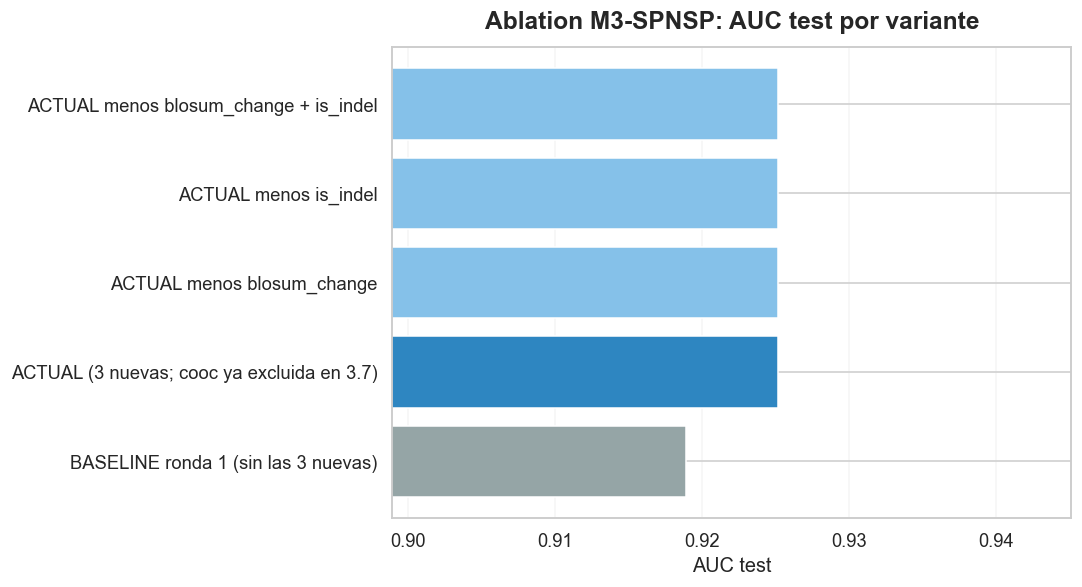

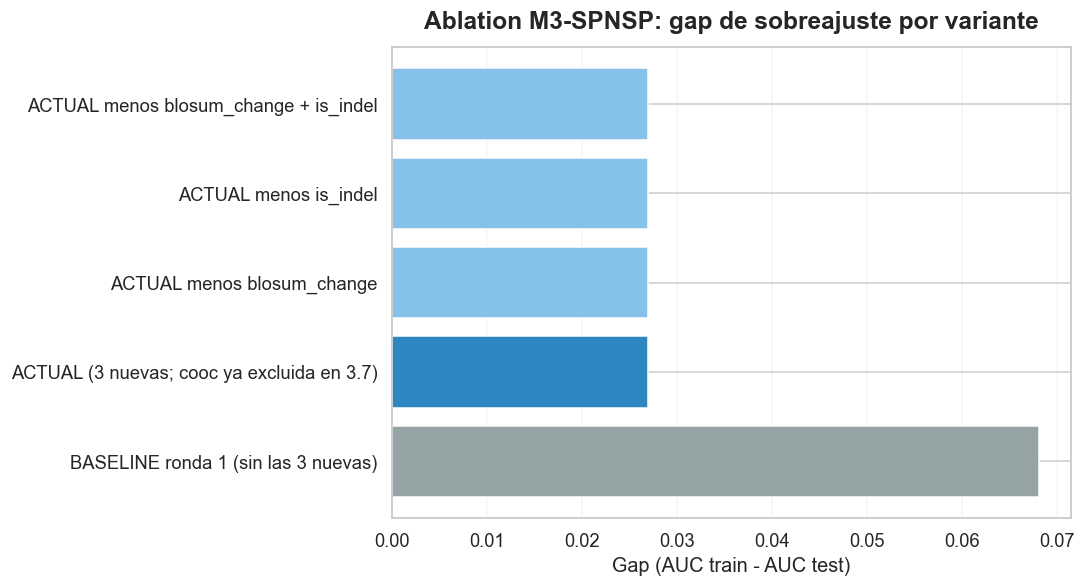

Figuras guardadas: 6_1a_ablation_auc.png, 6_1b_ablation_gap.png

Delta AUC test al quitar blosum_change+is_indel: +0.0000
Si la diferencia es pequeña (<0.01) y sin gap peor, confirma lo que ya
sugería SHAP: no aportan señal relevante a M3-SPNSP, y se pueden retirar
de FEAT_COLS_M3_SPNSP/ALL en 3.7 (conservando las columnas, como ya se
hizo con cooc_partner_strength).


In [41]:
# ── Celda diagnóstica — Ablation: ¿qué feature nueva causa el sobreajuste? ───
# `cooc_partner_strength` ya se excluyó de FEAT_COLS_M3_SPNSP/ALL en 3.7 tras
# el primer ablation (causaba sobreajuste: memorizaba las mutaciones
# "hallmark" en vez de generalizar). Quedan 3 features de la ronda 2 en el
# modelo (`blosum_change`, `is_indel`, `n_families_recent`); el SHAP de 4.3a
# no mostraba ni `blosum_change` ni `is_indel` en el top-5 de M3-SPNSP/ALL —
# esta celda mide (ronda 3, punto 1) si de verdad no aportan, en vez de
# asumirlo por su posición en el ranking SHAP.
_ALL_NEW_FEATS = ['blosum_change', 'is_indel', 'n_families_recent']
_BASE_FEATS    = [f for f in FEAT_COLS_M3_SPNSP if f not in _ALL_NEW_FEATS]

_variants = {
    'BASELINE ronda 1 (sin las 3 nuevas)':        _BASE_FEATS,
    'ACTUAL (3 nuevas; cooc ya excluida en 3.7)': FEAT_COLS_M3_SPNSP,
    'ACTUAL menos blosum_change':                 [c for c in FEAT_COLS_M3_SPNSP if c != 'blosum_change'],
    'ACTUAL menos is_indel':                      [c for c in FEAT_COLS_M3_SPNSP if c != 'is_indel'],
    'ACTUAL menos blosum_change + is_indel':      [c for c in FEAT_COLS_M3_SPNSP if c not in ('blosum_change', 'is_indel')],
}

_df_tr_full = df_m3_spnsp[df_m3_spnsp['week'] < (CUTOFF_WEEK_ML - GAP)].copy().sort_values('week')
_test       = df_m3_spnsp[df_m3_spnsp['week'] >= CUTOFF_WEEK_ML].copy()
_df_tr_full = _df_tr_full.assign(y_cens=_cens_target(_df_tr_full, CUTOFF_WEEK_ML))

_wks = _df_tr_full['week'].drop_duplicates().sort_values().values
_cut_val = _wks[int(len(_wks) * 0.8)]
_fit = _df_tr_full[_df_tr_full['week'] <  _cut_val]
_val = _df_tr_full[_df_tr_full['week'] >= _cut_val]

_ablation_rows = []
print(f'{"Variante":<42} {"AUC_tr":>7} {"AUC_te":>7} {"Gap":>7} {"Iter":>5}')
print('-' * 72)
for name, feats in _variants.items():
    Xf, yf = _fit[feats].values, _fit['y_cens'].values
    Xv, yv = _val[feats].values, _val['y_cens'].values
    Xte, yte = _test[feats].values, _test['target'].values

    spw = (yf == 0).sum() / max((yf == 1).sum(), 1)
    params = {**BASE_PARAMS, 'scale_pos_weight': spw, 'n_estimators': 300}
    model = lgb.LGBMClassifier(**params)
    model.fit(Xf, yf, eval_set=[(Xv, yv)],
              callbacks=[lgb.early_stopping(25, verbose=False), lgb.log_evaluation(-1)])
    best_it = model.best_iteration_ or 300

    auc_tr = roc_auc_score(yf, model.predict_proba(Xf)[:, 1])
    auc_te = roc_auc_score(yte, model.predict_proba(Xte)[:, 1])
    _ablation_rows.append(dict(variante=name, auc_tr=auc_tr, auc_te=auc_te,
                                gap=auc_tr - auc_te, iter=best_it))
    print(f'{name:<42} {auc_tr:>7.4f} {auc_te:>7.4f} {auc_tr-auc_te:>+7.3f} {best_it:>5}')

df_ablation = pd.DataFrame(_ablation_rows).set_index('variante')

_colors_ab = ['#95A5A6' if v.startswith('BASELINE') else '#2E86C1' if v.startswith('ACTUAL (') else '#85C1E9'
              for v in df_ablation.index]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(df_ablation.index, df_ablation['auc_te'], color=_colors_ab, edgecolor='white')
ax.set_xlabel('AUC test', fontsize=13)
ax.set_title('Ablation M3-SPNSP: AUC test por variante', fontweight='bold', fontsize=16, pad=12)
ax.set_xlim(df_ablation['auc_te'].min() - 0.02, df_ablation['auc_te'].max() + 0.02)
ax.tick_params(axis='both', labelsize=12)
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig(OUTDIR / '6_1a_ablation_auc.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(df_ablation.index, df_ablation['gap'], color=_colors_ab, edgecolor='white')
ax.set_xlabel('Gap (AUC train - AUC test)', fontsize=13)
ax.set_title('Ablation M3-SPNSP: gap de sobreajuste por variante', fontweight='bold', fontsize=16, pad=12)
ax.tick_params(axis='both', labelsize=12)
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig(OUTDIR / '6_1b_ablation_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figuras guardadas: 6_1a_ablation_auc.png, 6_1b_ablation_gap.png')

_actual_auc = df_ablation.loc['ACTUAL (3 nuevas; cooc ya excluida en 3.7)', 'auc_te']
_drop_auc   = df_ablation.loc['ACTUAL menos blosum_change + is_indel', 'auc_te']
print()
print(f'Delta AUC test al quitar blosum_change+is_indel: {_drop_auc - _actual_auc:+.4f}')
print('Si la diferencia es pequeña (<0.01) y sin gap peor, confirma lo que ya')
print('sugería SHAP: no aportan señal relevante a M3-SPNSP, y se pueden retirar')
print('de FEAT_COLS_M3_SPNSP/ALL en 3.7 (conservando las columnas, como ya se')
print('hizo con cooc_partner_strength).')

### 4.1e — Diagnóstico: ¿por qué generalizan peor M2 y M2-SPNSP30?

M2 tiene el gap train-test más alto de las 7 configuraciones (0.154-0.170,
frente a 0.054 de M3-SPNSP) con muy pocas iteraciones antes de que el early
stopping pare (8-37). Hipótesis: M2 tiene 435 familias repartidas en 12,355
filas (~28 filas por familia de media) — al ser datos de panel (una fila por
semana por familia), el split fit/val temporal dentro de train puede dejar a
la misma familia presente en ambos lados, dejando que el modelo aprenda algo
parecido a "identidad de familia" en vez de un patrón transferible. Esta
celda mide la cobertura real de familias entre fit/val/test y prueba si más
regularización reduce el gap sin perder AUC de test.

**Resultado y decisión aplicada:** el 31.6% de las familias de val ya estaban
en fit, y el 62.4% de las de test son genuinamente nuevas — hay solapamiento,
pero no es la causa dominante por sí sola. La regularización más fuerte
(`num_leaves=7, min_child_samples=50, reg_lambda=4.0`, "REG_FUERTE" en la
tabla de abajo) no fue un compromiso: **mejoró el AUC test Y bajó el gap a
la vez** en ambos datasets (M2: 0.839→0.885 AUC, gap 0.154→0.105;
M2-SPNSP30: 0.817→0.875 AUC, gap 0.183→0.112). Se ha adoptado como
`PARAMS_M2` en 4.1a y se usa ya en 4.1b y en el walk-forward (4.2a).

COBERTURA DE FAMILIAS (M2) — misma familia en varios splits:
  Familias en fit                          : 142
  Familias en val ya vistas en fit          : 62 / 196 (31.6%)
  Familias en test ya vistas en train (fit+val): 96 / 255 (37.6%)
  Familias en test genuinamente NUEVAS      : 159 / 255 (62.4%)

Si el solapamiento fit/val es alto, el early stopping valida sobre
familias que el modelo ya conoce de fit (semanas distintas, misma
familia) — una señal de generalización más optimista de lo real.

Dataset       Variante              AUC_tr  AUC_te     Gap  Iter
--------------------------------------------------------------------


M2            ACTUAL (BASE_PARAMS)  0.9934  0.8390  +0.154     8


M2            REG_MEDIA             0.9981  0.8565  +0.142    59


M2            REG_FUERTE            0.9896  0.8846  +0.105    68


M2-SPNSP30    ACTUAL (BASE_PARAMS)  0.9998  0.8168  +0.183    49


M2-SPNSP30    REG_MEDIA             0.9957  0.8469  +0.149    40


M2-SPNSP30    REG_FUERTE            0.9867  0.8746  +0.112    50


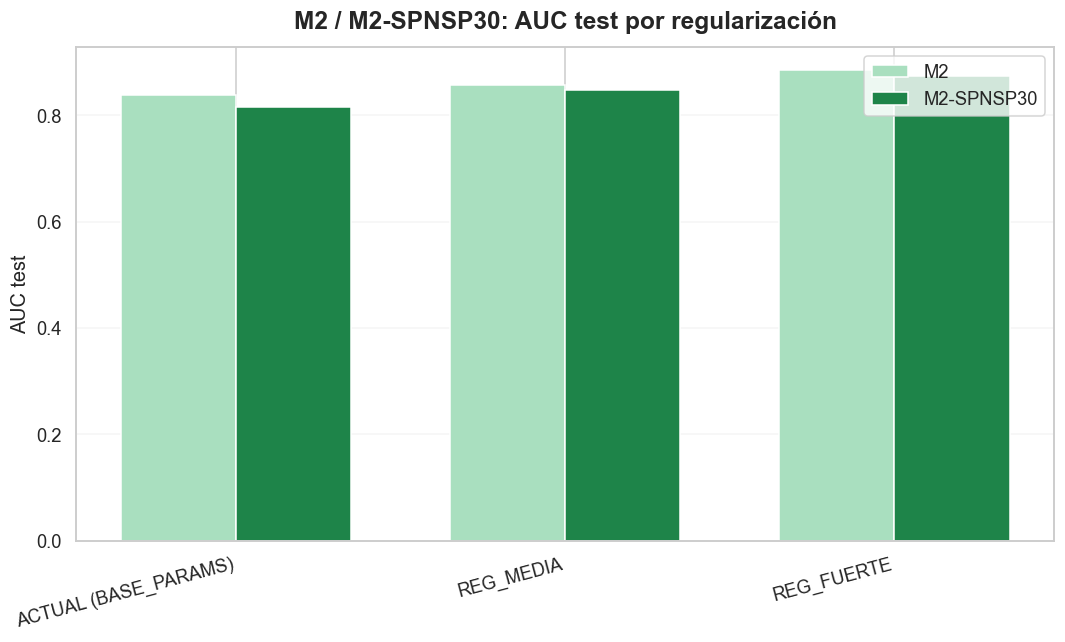

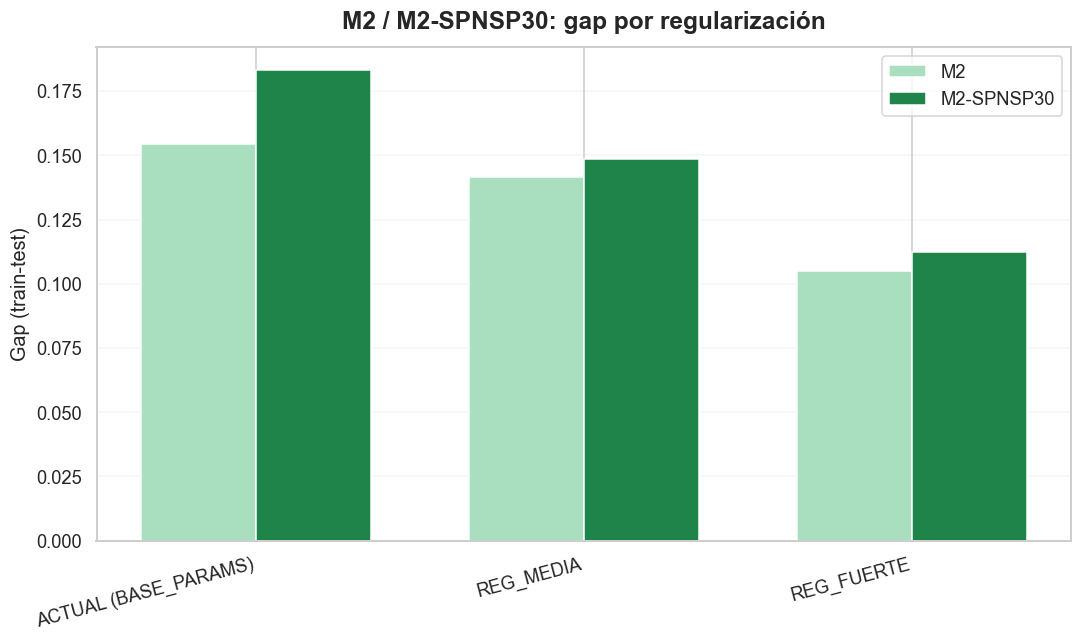

Figuras guardadas: 7_5a_reg_auc.png, 7_5b_reg_gap.png

Mejor variante por AUC de test, por dataset:


,dataset,variante,auc_tr,auc_te,gap
2,M2,REG_FUERTE,0.989638,0.884629,0.105009
5,M2-SPNSP30,REG_FUERTE,0.986738,0.874560,0.112178


In [42]:
# ── Celda 4.1e — Diagnóstico M2/M2-SPNSP30: cobertura de familias + regularización ──
_m2_tr_full = df_m2[df_m2['week'] < (CUTOFF_WEEK_ML - GAP)].copy().sort_values('week')
_m2_test    = df_m2[df_m2['week'] >= CUTOFF_WEEK_ML].copy()
_m2_wks     = _m2_tr_full['week'].drop_duplicates().sort_values().values
_m2_cut_val = _m2_wks[int(len(_m2_wks) * 0.8)]
_m2_fit = _m2_tr_full[_m2_tr_full['week'] <  _m2_cut_val]
_m2_val = _m2_tr_full[_m2_tr_full['week'] >= _m2_cut_val]

_fam_fit  = set(_m2_fit['lineage_family'].unique())
_fam_val  = set(_m2_val['lineage_family'].unique())
_fam_test = set(_m2_test['lineage_family'].unique())
_fam_train_full = set(_m2_tr_full['lineage_family'].unique())

print('COBERTURA DE FAMILIAS (M2) — misma familia en varios splits:')
print(f'  Familias en fit                          : {len(_fam_fit)}')
print(f'  Familias en val ya vistas en fit          : {len(_fam_val & _fam_fit)} / {len(_fam_val)} '
      f'({len(_fam_val & _fam_fit) / max(len(_fam_val), 1) * 100:.1f}%)')
print(f'  Familias en test ya vistas en train (fit+val): {len(_fam_test & _fam_train_full)} / {len(_fam_test)} '
      f'({len(_fam_test & _fam_train_full) / max(len(_fam_test), 1) * 100:.1f}%)')
print(f'  Familias en test genuinamente NUEVAS      : {len(_fam_test - _fam_train_full)} / {len(_fam_test)} '
      f'({len(_fam_test - _fam_train_full) / max(len(_fam_test), 1) * 100:.1f}%)')
print()
print('Si el solapamiento fit/val es alto, el early stopping valida sobre')
print('familias que el modelo ya conoce de fit (semanas distintas, misma')
print('familia) — una señal de generalización más optimista de lo real.')

# ── Sensibilidad a la regularización ─────────────────────────────────────
REG_VARIANTS = {
    'ACTUAL (BASE_PARAMS)':  dict(num_leaves=31, min_child_samples=20, reg_lambda=1.0),
    'REG_MEDIA':             dict(num_leaves=15, min_child_samples=30, reg_lambda=2.0),
    'REG_FUERTE':            dict(num_leaves=7,  min_child_samples=50, reg_lambda=4.0),
}

print()
print(f'{"Dataset":<13} {"Variante":<20} {"AUC_tr":>7} {"AUC_te":>7} {"Gap":>7} {"Iter":>5}')
print('-' * 68)
reg_rows = []
for ds_name, df_ds, feats in [('M2', df_m2, FEAT_COLS_M2), ('M2-SPNSP30', df_m2_spnsp, FEAT_COLS_M2_SPNSP)]:
    tr_full = df_ds[df_ds['week'] < (CUTOFF_WEEK_ML - GAP)].copy().sort_values('week')
    test    = df_ds[df_ds['week'] >= CUTOFF_WEEK_ML].copy()
    tr_full = tr_full.assign(y_cens=_cens_target(tr_full, CUTOFF_WEEK_ML))
    wks     = tr_full['week'].drop_duplicates().sort_values().values
    cut_val = wks[int(len(wks) * 0.8)]
    fit = tr_full[tr_full['week'] <  cut_val]
    val = tr_full[tr_full['week'] >= cut_val]

    Xf, yf = fit[feats].values, fit['y_cens'].values
    Xv, yv = val[feats].values, val['y_cens'].values
    Xte, yte = test[feats].values, test['target'].values
    spw = (yf == 0).sum() / max((yf == 1).sum(), 1)

    for reg_name, reg_over in REG_VARIANTS.items():
        params = {**BASE_PARAMS, **reg_over, 'scale_pos_weight': spw, 'n_estimators': 300}
        model = lgb.LGBMClassifier(**params)
        model.fit(Xf, yf, eval_set=[(Xv, yv)],
                  callbacks=[lgb.early_stopping(25, verbose=False), lgb.log_evaluation(-1)])
        best_it = model.best_iteration_ or 300
        auc_tr = roc_auc_score(yf, model.predict_proba(Xf)[:, 1])
        auc_te = roc_auc_score(yte, model.predict_proba(Xte)[:, 1])
        reg_rows.append(dict(dataset=ds_name, variante=reg_name, auc_tr=auc_tr,
                              auc_te=auc_te, gap=auc_tr - auc_te, iter=best_it))
        print(f'{ds_name:<13} {reg_name:<20} {auc_tr:>7.4f} {auc_te:>7.4f} '
              f'{auc_tr-auc_te:>+7.3f} {best_it:>5}')

df_reg_sens = pd.DataFrame(reg_rows)

_x = np.arange(len(REG_VARIANTS))
_width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
for i, (ds_name, *_) in enumerate([('M2',), ('M2-SPNSP30',)]):
    sub = df_reg_sens[df_reg_sens['dataset'] == ds_name].set_index('variante').loc[list(REG_VARIANTS)]
    ax.bar(_x + (i - 0.5) * _width, sub['auc_te'], _width, label=ds_name,
           color=['#A9DFBF', '#1E8449'][i], edgecolor='white')
ax.set_xticks(_x); ax.set_xticklabels(list(REG_VARIANTS), rotation=15, ha='right', fontsize=12)
ax.set_ylabel('AUC test', fontsize=13)
ax.set_title('M2 / M2-SPNSP30: AUC test por regularización', fontweight='bold', fontsize=16, pad=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=12); ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig(OUTDIR / '7_5a_reg_auc.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
for i, (ds_name, *_) in enumerate([('M2',), ('M2-SPNSP30',)]):
    sub = df_reg_sens[df_reg_sens['dataset'] == ds_name].set_index('variante').loc[list(REG_VARIANTS)]
    ax.bar(_x + (i - 0.5) * _width, sub['gap'], _width, label=ds_name,
           color=['#A9DFBF', '#1E8449'][i], edgecolor='white')
ax.set_xticks(_x); ax.set_xticklabels(list(REG_VARIANTS), rotation=15, ha='right', fontsize=12)
ax.set_ylabel('Gap (train-test)', fontsize=13)
ax.set_title('M2 / M2-SPNSP30: gap por regularización', fontweight='bold', fontsize=16, pad=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=12); ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig(OUTDIR / '7_5b_reg_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figuras guardadas: 7_5a_reg_auc.png, 7_5b_reg_gap.png')

print()
_best_per_ds = df_reg_sens.loc[df_reg_sens.groupby('dataset')['auc_te'].idxmax()]
print('Mejor variante por AUC de test, por dataset:')
display(_best_per_ds[['dataset', 'variante', 'auc_tr', 'auc_te', 'gap']])

### 4.1f — M1 sin walk-forward: cross-validation estratificada como alternativa

M1/M1-BIO/M1-SPNSP nunca se han evaluado en walk-forward por época pandémica
(524-670 filas de train — insuficiente para subdividir en 5 folds
temporales sin quedarse con folds de una decena de filas, como ya se
documentó en 4.2). Su único número de generalización hasta ahora es el AUC
de un único split temporal (0.92-0.95), que con una muestra así de pequeña
puede depender bastante de qué semanas concretas cayeron en test.

**Esto NO sustituye al walk-forward** — no dice nada sobre estabilidad entre
épocas pandémicas, solo cuantifica la varianza del modelo frente a distintos
subconjuntos aleatorios de los mismos datos (5-fold, estratificado por
target, sin orden temporal). Es la única validación adicional viable con
esta muestra.

**Resultado (adelanto):** la CV da un AUC casi perfecto (~0.999), muy por
encima del split temporal (0.92-0.95) — lo contrario de lo que se esperaría
si el split temporal hubiera sido "mala suerte". Esto no es una confirmación
de estabilidad: `df_m1` tiene una fila por (clado, semana), y un reparto
*aleatorio* (no temporal) puede dejar dos semanas del mismo clado una en fit
y otra en test — fuga por entidad, no generalización real. Queda documentado
como limitación metodológica, no como validación adicional de M1.

Dataset      AUC media  AUC std   AUC por fold
----------------------------------------------------------------------


M1              0.9984   0.0016   1.000  0.999  0.996  0.997  1.000


M1-BIO          0.9995   0.0004   1.000  1.000  0.999  1.000  1.000


M1-SPNSP        0.9996   0.0006   1.000  1.000  1.000  0.998  1.000


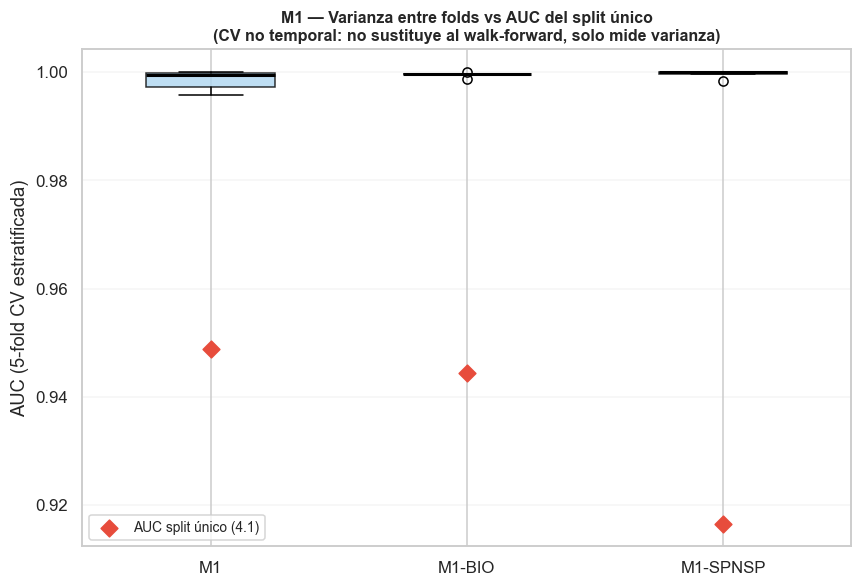

Figura guardada: 4_1f_m1_cv.png

INTERPRETACIÓN:
  M1: split único=0.9488  CV media=0.9984 ± 0.0018  delta=-0.0496
  M1-BIO: split único=0.9444  CV media=0.9995 ± 0.0005  delta=-0.0552
  M1-SPNSP: split único=0.9165  CV media=0.9996 ± 0.0007  delta=-0.0831

  La CV da un AUC casi perfecto (~0.999) con varianza casi nula -- MUY por
  encima del split temporal, no por debajo. Esto NO confirma que M1 sea
  estable: es la firma típica de fuga por entidad en datos de panel (una
  fila por clado x semana). Al barajar aleatoriamente, semanas distintas
  del MISMO clado pueden caer en train y test del mismo fold, y `peak_hist`
  (la feature dominante de M1 en SHAP) ya adelanta casi el desenlace.
  Conclusión: el AUC de CV NO es un número a reportar como validación de
  M1 -- el único número honesto sigue siendo el del split temporal (4.1),
  que sí separa por tiempo y no dejar fugar la identidad del clado.


In [43]:
# ── Celda 4.1f — M1: cross-validation estratificada (5-fold) ────────────────
from sklearn.model_selection import StratifiedKFold

N_FOLDS_M1 = 5
_skf_m1 = StratifiedKFold(n_splits=N_FOLDS_M1, shuffle=True, random_state=42)

_M1_DATASETS = [
    ('M1',       df_m1,       FEAT_COLS_M1),
    ('M1-BIO',   df_m1_bio,   FEAT_COLS_M1_BIO),
    ('M1-SPNSP', df_m1_spnsp, FEAT_COLS_M1_SPNSP),
]

cv_m1_rows = []
print(f'{"Dataset":<11} {"AUC media":>10} {"AUC std":>8}   AUC por fold')
print('-' * 70)
for name, df_ds, feats in _M1_DATASETS:
    X = df_ds[feats].values
    y = df_ds['target'].values
    fold_aucs = []
    for fold_i, (idx_tr, idx_te) in enumerate(_skf_m1.split(X, y), 1):
        X_tr, y_tr = X[idx_tr], y[idx_tr]
        X_te, y_te = X[idx_te], y[idx_te]
        spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
        params = {**PARAMS_SMALL, 'scale_pos_weight': spw, 'n_estimators': 100}
        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr)
        auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
        fold_aucs.append(auc)
        cv_m1_rows.append(dict(dataset=name, fold=fold_i, auc=auc))
    print(f'{name:<11} {np.mean(fold_aucs):>10.4f} {np.std(fold_aucs):>8.4f}   '
          + '  '.join(f'{a:.3f}' for a in fold_aucs))

df_cv_m1 = pd.DataFrame(cv_m1_rows)

fig, ax = plt.subplots(figsize=(8, 5.5))
_positions = range(len(_M1_DATASETS))
_data_box = [df_cv_m1[df_cv_m1['dataset'] == name]['auc'].values for name, *_ in _M1_DATASETS]
bp = ax.boxplot(_data_box, positions=_positions, patch_artist=True, widths=0.5,
                 medianprops=dict(color='black', lw=2))
for patch, col in zip(bp['boxes'], ['#AED6F1', '#5DADE2', '#2E86C1']):
    patch.set_facecolor(col); patch.set_alpha(0.8)
for i, (name, *_) in enumerate(_M1_DATASETS):
    _single_split_auc = lgb_results[name]['auc']
    ax.scatter([i], [_single_split_auc], color='#E74C3C', zorder=5, s=60,
               marker='D', label='AUC split único (4.1)' if i == 0 else None)
ax.set_xticks(list(_positions))
ax.set_xticklabels([n for n, *_ in _M1_DATASETS])
ax.set_ylabel('AUC (5-fold CV estratificada)')
ax.set_title('M1 — Varianza entre folds vs AUC del split único\n'
              '(CV no temporal: no sustituye al walk-forward, solo mide varianza)',
              fontsize=10.5, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig(OUTDIR / '4_1f_m1_cv.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figura guardada: 4_1f_m1_cv.png')

print()
print('INTERPRETACIÓN:')
for name, *_ in _M1_DATASETS:
    cv_mean = df_cv_m1[df_cv_m1['dataset'] == name]['auc'].mean()
    cv_std  = df_cv_m1[df_cv_m1['dataset'] == name]['auc'].std()
    split_auc = lgb_results[name]['auc']
    delta = split_auc - cv_mean
    print(f'  {name}: split único={split_auc:.4f}  CV media={cv_mean:.4f} ± {cv_std:.4f}  '
          f'delta={delta:+.4f}')

# La CV da AUC ~0.998-0.9996 con std casi nula (0.0004-0.0016) -- muy por
# ENCIMA del split temporal (0.92-0.95), no por debajo. Esto NO es una buena
# noticia de estabilidad: es la firma clásica de fuga por entidad en datos de
# panel. df_m1 tiene una fila por (clado, semana); el 5-fold aquí es un
# reparto ALEATORIO (no temporal), así que semanas distintas del MISMO clado
# pueden caer una en fit y otra en test del mismo fold. `peak_hist` (con
# diferencia la feature de mayor peso SHAP en M1, 4.3a) ya casi delata el
# desenlace final del clado, así que el modelo no necesita generalizar a
# clados nuevos para acertar -- le basta con reconocer "este clado ya lo he
# visto, con otro peak_hist parecido, en otra semana".
print()
print('  La CV da un AUC casi perfecto (~0.999) con varianza casi nula -- MUY por')
print('  encima del split temporal, no por debajo. Esto NO confirma que M1 sea')
print('  estable: es la firma típica de fuga por entidad en datos de panel (una')
print('  fila por clado x semana). Al barajar aleatoriamente, semanas distintas')
print('  del MISMO clado pueden caer en train y test del mismo fold, y `peak_hist`')
print('  (la feature dominante de M1 en SHAP) ya adelanta casi el desenlace.')
print('  Conclusión: el AUC de CV NO es un número a reportar como validación de')
print('  M1 -- el único número honesto sigue siendo el del split temporal (4.1),')
print('  que sí separa por tiempo y no dejar fugar la identidad del clado.')

### 4.1g — Benchmark de algoritmos: ¿por qué LightGBM?

Split reutilizado de 4.1b -- Fit: 39,377  Val: 12,639  Test: 50,897
(comparar con la fila M3-SPNSP de la tabla de 4.1b: debe coincidir)



BENCHMARK DE ALGORITMOS -- M3-SPNSP
(mismo split temporal fit/val/test y mismo target censurado que 4.1b)
Modelo                        AUC       AP    Lift
------------------------------------------------------------------
Dummy (estratificado)      0.4994   0.1789   1.00x
Logistic Regression        0.9330   0.8680   4.85x
Random Forest              0.9206   0.8528   4.76x
Gradient Boosting          0.8975   0.8022   4.48x
LightGBM                   0.9251   0.8601   4.80x
------------------------------------------------------------------
Tasa base de positivos en test: 17.91%  (N_test=50,897)


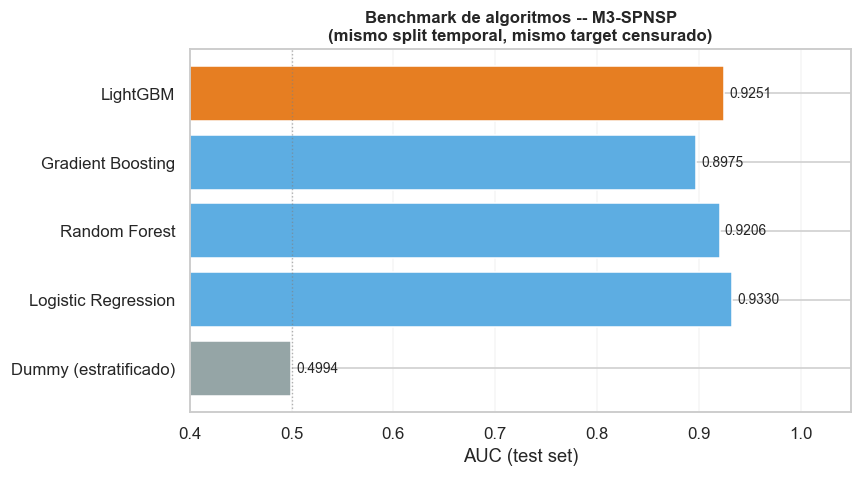

Figura guardada: 4_1g_benchmark_algoritmos.png


In [44]:
# ── Celda 4.1g — Benchmark de algoritmos: ¿por qué LightGBM? (M3-SPNSP) ──────
# Manuel (tutor) pidió mostrar qué otros algoritmos se probaron antes de
# quedarse con LightGBM. El bloque LogReg/RF/XGBoost/GradBoosting que existió
# en los notebooks de marzo-abril corría sobre un dataset con el leak de
# eval_set=test y sin event_week/censura -- esos números no son comparables
# y no se reutilizan aquí. Esta celda repite la comparación desde cero sobre
# el dataset M3-SPNSP YA corregido, con EXACTAMENTE el mismo split temporal
# fit/val/test y el mismo target censurado (y_cens) que usa LightGBM en 4.1b.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier

_feats_bm = FEAT_COLS_M3_SPNSP

# Mismo split que la iteración M3-SPNSP de la celda 4.1b (df_tr_full/test,
# fit/val por corte temporal en el último VAL_FRAC de semanas de train).
_df_tr_full_bm = df_m3_spnsp[df_m3_spnsp['week'] < (CUTOFF_WEEK_ML - GAP)].copy().sort_values('week')
_test_bm       = df_m3_spnsp[df_m3_spnsp['week'] >= CUTOFF_WEEK_ML].copy()
_df_tr_full_bm = _df_tr_full_bm.assign(y_cens=_cens_target(_df_tr_full_bm, CUTOFF_WEEK_ML))

_wks_bm     = _df_tr_full_bm['week'].drop_duplicates().sort_values().values
_cut_val_bm = _wks_bm[int(len(_wks_bm) * (1 - VAL_FRAC))]
_fit_bm     = _df_tr_full_bm[_df_tr_full_bm['week'] <  _cut_val_bm]
_val_bm     = _df_tr_full_bm[_df_tr_full_bm['week'] >= _cut_val_bm]

X_fit_bm, y_fit_bm = _fit_bm[_feats_bm].values, _fit_bm['y_cens'].values
X_te_bm,  y_te_bm  = _test_bm[_feats_bm].values, _test_bm['target'].values

print(f'Split reutilizado de 4.1b -- Fit: {len(_fit_bm):,}  Val: {len(_val_bm):,}  Test: {len(_test_bm):,}')
print('(comparar con la fila M3-SPNSP de la tabla de 4.1b: debe coincidir)')
print()

n_neg_bm = (y_fit_bm == 0).sum(); n_pos_bm = (y_fit_bm == 1).sum()
spw_bm   = n_neg_bm / max(n_pos_bm, 1)
sample_weight_bm = np.where(y_fit_bm == 1, spw_bm, 1.0)

scaler_bm   = StandardScaler().fit(X_fit_bm)
X_fit_bm_sc = scaler_bm.transform(X_fit_bm)
X_te_bm_sc  = scaler_bm.transform(X_te_bm)

_base_ap_bm   = float(y_te_bm.mean())
bench_results = {}

_dummy = DummyClassifier(strategy='stratified', random_state=42).fit(X_fit_bm, y_fit_bm)
_p = _dummy.predict_proba(X_te_bm)[:, 1]
bench_results['Dummy (estratificado)'] = dict(auc=roc_auc_score(y_te_bm, _p), ap=average_precision_score(y_te_bm, _p))

_logreg = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
_logreg.fit(X_fit_bm_sc, y_fit_bm)
_p = _logreg.predict_proba(X_te_bm_sc)[:, 1]
bench_results['Logistic Regression'] = dict(auc=roc_auc_score(y_te_bm, _p), ap=average_precision_score(y_te_bm, _p))

# n_jobs=1 (no -1): en Windows, RandomForest con multiprocessing (loky) puede
# colgar la comunicación ZMQ del kernel de Jupyter con el proceso padre.
_rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=1)
_rf.fit(X_fit_bm, y_fit_bm)
_p = _rf.predict_proba(X_te_bm)[:, 1]
bench_results['Random Forest'] = dict(auc=roc_auc_score(y_te_bm, _p), ap=average_precision_score(y_te_bm, _p))

_gb = GradientBoostingClassifier(n_estimators=300, random_state=42)
_gb.fit(X_fit_bm, y_fit_bm, sample_weight=sample_weight_bm)
_p = _gb.predict_proba(X_te_bm)[:, 1]
bench_results['Gradient Boosting'] = dict(auc=roc_auc_score(y_te_bm, _p), ap=average_precision_score(y_te_bm, _p))

# LightGBM: no se re-entrena -- se reutiliza el modelo ya entrenado en 4.1b
# sobre este mismo split (mismo fit/val/test), evaluado igual en test.
bench_results['LightGBM'] = dict(auc=lgb_results['M3-SPNSP']['auc'], ap=lgb_results['M3-SPNSP']['ap'])

print('BENCHMARK DE ALGORITMOS -- M3-SPNSP')
print('(mismo split temporal fit/val/test y mismo target censurado que 4.1b)')
print('=' * 66)
print(f'{"Modelo":<24} {"AUC":>8} {"AP":>8} {"Lift":>7}')
print('-' * 66)
for name, r in bench_results.items():
    lift = r['ap'] / _base_ap_bm if _base_ap_bm > 0 else 0
    print(f'{name:<24} {r["auc"]:>8.4f} {r["ap"]:>8.4f} {lift:>6.2f}x')
print('-' * 66)
print(f'Tasa base de positivos en test: {_base_ap_bm*100:.2f}%  (N_test={len(_test_bm):,})')

fig, ax = plt.subplots(figsize=(8, 4.5))
_names_bm  = list(bench_results.keys())
_aucs_bm   = [bench_results[n]['auc'] for n in _names_bm]
_colors_bm = ['#95A5A6' if n.startswith('Dummy') else
              '#E67E22' if n == 'LightGBM' else '#5DADE2' for n in _names_bm]
bars = ax.barh(_names_bm, _aucs_bm, color=_colors_bm, edgecolor='white')
ax.axvline(0.5, color='gray', ls=':', lw=0.9, alpha=0.6)
for i, auc in enumerate(_aucs_bm):
    ax.text(auc + 0.005, i, f'{auc:.4f}', va='center', fontsize=9)
ax.set_xlim(0.4, 1.05)
ax.set_xlabel('AUC (test set)')
ax.set_title('Benchmark de algoritmos -- M3-SPNSP\n(mismo split temporal, mismo target censurado)',
             fontsize=11, fontweight='bold')
ax.grid(True, axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig(OUTDIR / '4_1g_benchmark_algoritmos.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figura guardada: 4_1g_benchmark_algoritmos.png')


### 4.2 — Walk-Forward Temporal Validation

### Motivación: por qué no basta con el split simple

La validación train/test con un corte fijo (Jun 2023) en 4.1 es necesaria
pero insuficiente por tres razones:

1. **Autocorrelación temporal:** una familia Pango observada en semana T tiene
   frecuencia similar en T+1 y T-1. Si mezclas semanas de la misma familia en
   train y test, el modelo "ya ha visto" variantes parecidas a las que predice
   → optimismo artificial.

2. **Cambio de distribución entre épocas:** como vimos en 4.0b, la tasa de
   positivos varía entre 6.4% (XBB) y 36.1% (Delta). Un modelo entrenado
   hasta 2022 asigna probabilidades calibradas para un mundo con ~20% de
   positivos; si lo desplegamos en plena era XBB (6.4%), generará demasiadas
   falsas alarmas.

3. **Selección temporal del umbral:** si ajustas el threshold de decisión
   sobre el mismo test set que usas para reportar AUC, introduces sesgo de
   selección. El walk-forward garantiza que el threshold nunca se ajusta sobre
   el período que se evalúa.

### Diseño de los folds

Usamos **folds por época pandémica** en lugar de ventanas de tiempo fijas.
Esto es más natural biológicamente — cada época representa una transición
inmunológica distinta — y más exigente que ventanas aleatorias.

| Fold | Época     | Período test    | Característica biológica clave                          |
|------|-----------|-----------------|----------------------------------------------------------|
| 1    | BA.4/5    | Jun–Oct 2022    | Primera oleada post-Omicron; escape RBD parcial         |
| 2    | XBB       | Oct 2022–Jun 2023 | Recombinante BA.2; nueva ola en Asia → Europa          |
| 3    | JN.1      | Jun 2023–Abr 2024 | Sub-linaje BQ.1, acumula mutaciones furin cleavage     |
| 4    | KP/XEC    | Abr 2024–Ene 2025 | Recombinante JN.1 × XBB; escape bivalente              |
| 5    | XFG       | Ene 2025 →      | Recombinante más reciente; era actual de vigilancia     |

**Protocolo:**
- Train: todos los datos **antes del inicio de la época** (sin data leakage)
- Test: todos los datos **dentro de la época**
- Para cada fold se entrena un modelo LightGBM independiente con los mismos
  hiperparámetros + early stopping 50 rounds
- Datasets evaluados: M2, M2-SPNSP30, M3-SPNSP, M3-ALL (los de mayor utilidad
  práctica; M1 tiene solo ~700 filas de train — insuficiente para subdividir)

### Interpretación esperada

- **Variabilidad entre folds** (std alto) indica que el modelo depende del
  contexto inmunológico de la época de entrenamiento.
- **AUC bajo en XBB** es esperable: muy pocos positivos (6.4%), señal débil.
- **Estabilidad de M3-SPNSP** sería el resultado más valioso — si el nivel
  mutacional es robusto entre épocas, justifica usarlo como capa principal
  del sistema de vigilancia.


In [45]:
# ── Celda 4.2a — Walk-Forward: entrenamiento por época ───────────────────────
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

WF_FOLDS = [
    ('BA.4/5', pd.Timestamp('2022-06-01'), pd.Timestamp('2022-10-01')),
    ('XBB',    pd.Timestamp('2022-10-01'), pd.Timestamp('2023-06-01')),
    ('JN.1',   pd.Timestamp('2023-06-01'), pd.Timestamp('2024-04-01')),
    ('KP/XEC', pd.Timestamp('2024-04-01'), pd.Timestamp('2025-01-01')),
    ('XFG',    pd.Timestamp('2025-01-01'), None),
]
# M2/M2-SPNSP30 usan PARAMS_M2 (ronda 3, 4.1e) en vez de BASE_PARAMS -- mismo
# criterio que en 4.1b: menos hojas y más min_child_samples/reg_lambda para
# no sobreajustar con datos de panel (misma familia en muchas semanas).
WF_DS = [
    ('M2',         df_m2,        FEAT_COLS_M2,        PARAMS_M2),
    ('M2-SPNSP30', df_m2_spnsp,  FEAT_COLS_M2_SPNSP,  PARAMS_M2),
    ('M3-SPNSP',   df_m3_spnsp,  FEAT_COLS_M3_SPNSP,  BASE_PARAMS),
    ('M3-ALL',     df_m3_all,    FEAT_COLS_M3_ALL,     BASE_PARAMS),
]
WF_VAL_FRAC = 0.20
GAP_WF      = pd.Timedelta(weeks=HORIZON_MIN)

def _cens_target_wf(d, censor_week):
    ew = pd.to_datetime(d['event_week'])
    return ((ew.notna()) & (ew <= pd.Timestamp(censor_week))).astype(int).values

wf_results = {ds: [] for ds, *_ in WF_DS}

print(f'{"Dataset":<13} {"Fold":<9} {"Train":>8} {"Test":>8} {"Pos%":>6} '
      f'{"AUC_tr":>7} {"AUC_te":>7} {"AP":>7} {"Lift":>6} {"Iter":>5}')
print('─' * 84)

for fold_name, fold_start, fold_end in WF_FOLDS:
    for ds_name, df, feats, params_base in WF_DS:
        train_full = df[df['week'] < (fold_start - GAP_WF)].copy().sort_values('week')
        test = (df[(df['week'] >= fold_start) & (df['week'] < fold_end)]
                if fold_end is not None else df[df['week'] >= fold_start])

        if len(train_full) < 200 or len(test) < 20:
            continue
        train_full = train_full.assign(y_cens=_cens_target_wf(train_full, fold_start))
        if train_full['y_cens'].sum() < 15 or test['target'].sum() < 5:
            print(f'{ds_name:<13} {fold_name:<9}  [SKIP — pocos positivos]')
            continue

        wks = train_full['week'].drop_duplicates().sort_values().values
        if len(wks) >= 5:
            cut_val = wks[int(len(wks) * (1 - WF_VAL_FRAC))]
            fit = train_full[train_full['week'] <  cut_val]
            val = train_full[train_full['week'] >= cut_val]
        else:
            fit, val = train_full, train_full.iloc[0:0]
        use_es = (len(val) > 0 and val['y_cens'].nunique() == 2 and val['y_cens'].sum() >= 5)
        if not use_es:
            fit = train_full

        X_fit, y_fit = fit[feats].values, fit['y_cens'].values
        X_te,  y_te  = test[feats].values, test['target'].values

        spw = (y_fit == 0).sum() / max((y_fit == 1).sum(), 1)
        if use_es:
            # n_estimators/patience reducidos (500->300, 50->25), igual que en
            # 4.1b: con las features de mutación de la ronda 2 el early
            # stopping dejaba de parar a tiempo en M3-SPNSP y sobreajustaba.
            params = {**params_base, 'scale_pos_weight': spw, 'n_estimators': 300}
            model  = lgb.LGBMClassifier(**params)
            model.fit(X_fit, y_fit,
                      eval_set=[(val[feats].values, val['y_cens'].values)],
                      callbacks=[lgb.early_stopping(25, verbose=False),
                                 lgb.log_evaluation(-1)])
            best_it = model.best_iteration_ or 300
        else:
            params = {**params_base, 'scale_pos_weight': spw, 'n_estimators': 200}
            model  = lgb.LGBMClassifier(**params)
            model.fit(X_fit, y_fit)
            best_it = 200

        # AUC = área bajo la curva ROC, calculada tanto en train (fit) como en
        # test (fold), para poder leer el gap de sobreajuste por época.
        y_pred      = model.predict_proba(X_te)[:, 1]
        y_pred_fit  = model.predict_proba(X_fit)[:, 1]
        auc         = roc_auc_score(y_te, y_pred)
        auc_train   = roc_auc_score(y_fit, y_pred_fit)
        ap          = average_precision_score(y_te, y_pred)
        base_ap     = float(y_te.mean())
        lift        = ap / base_ap if base_ap > 0 else 0

        wf_results[ds_name].append(dict(
            fold=fold_name, fold_start=fold_start,
            auc=auc, auc_train=auc_train, ap=ap, lift=lift,
            n_train=len(train_full), n_test=len(test),
            pos_rate=base_ap, y_true=y_te, y_pred=y_pred,
            y_true_train=y_fit, y_pred_train=y_pred_fit, iter=best_it
        ))
        print(f'{ds_name:<13} {fold_name:<9} {len(train_full):>8,} {len(test):>8,} '
              f'{base_ap*100:>5.1f}% {auc_train:>7.4f} {auc:>7.4f} {ap:>7.4f} {lift:>5.2f}x {best_it:>5}')

print()
print('RESUMEN — AUC medio ± std por dataset (train vs test):')
print(f'  {"Dataset":<13} {"Folds":>5} {"AUC_tr media":>13} {"AUC_te media":>13} {"AUC_te std":>10} {"AP media":>9}')
print('  ' + '─' * 68)
for ds_name, *_ in WF_DS:
    folds_ok = wf_results[ds_name]
    if not folds_ok:
        continue
    aucs    = [r['auc'] for r in folds_ok]
    aucs_tr = [r['auc_train'] for r in folds_ok]
    aps     = [r['ap']  for r in folds_ok]
    print(f'  {ds_name:<13} {len(aucs):>5} {np.mean(aucs_tr):>13.4f} {np.mean(aucs):>13.4f} '
          f'{np.std(aucs):>10.4f} {np.mean(aps):>9.4f}')

Dataset       Fold         Train     Test   Pos%  AUC_tr  AUC_te      AP   Lift  Iter
────────────────────────────────────────────────────────────────────────────────────
M2            BA.4/5       1,877      733  15.1%  0.9914  0.8495  0.7196  4.75x    32


M2-SPNSP30    BA.4/5       1,877      733  15.1%  0.9957  0.7897  0.6464  4.27x    49


M3-SPNSP      BA.4/5      34,337    5,006  20.9%  0.9944  0.7956  0.6703  3.21x   159


M3-ALL        BA.4/5     157,627   22,506  13.3%  0.9619  0.7502  0.5443  4.10x   294


M2            XBB          2,515    3,362   6.4%  0.9998  0.8767  0.5780  9.08x   194
M2-SPNSP30    XBB          2,515    3,362   6.4%  0.9927  0.6972  0.3168  4.98x    41


M3-SPNSP      XBB         39,051   13,195  18.8%  0.9908  0.8377  0.7018  3.73x   120


M3-ALL        XBB        179,510   52,737  13.0%  0.9236  0.7329  0.5025  3.85x    66


M2            JN.1         5,775    2,602   8.5%  0.9896  0.9252  0.6379  7.51x    68


M2-SPNSP30    JN.1         5,775    2,602   8.5%  0.9867  0.9171  0.6289  7.40x    50


M3-SPNSP      JN.1        52,016   16,946  17.7%  0.9520  0.8577  0.7567  4.27x    24


M3-ALL        JN.1       231,976   63,423  12.6%  0.9080  0.7939  0.6053  4.79x    54


M2            KP/XEC       8,561    1,894  14.7%  0.9928  0.8699  0.7176  4.89x   109


M2-SPNSP30    KP/XEC       8,561    1,894  14.7%  0.9961  0.8705  0.7343  5.00x   142


M3-SPNSP      KP/XEC      68,806   14,776  17.9%  0.9631  0.9059  0.8524  4.77x    82


M3-ALL        KP/XEC     295,290   54,465  12.3%  0.9011  0.8075  0.6405  5.22x   134


M2            XFG         10,407    1,745  18.3%  0.9683  0.8649  0.7117  3.88x    13


M2-SPNSP30    XFG         10,407    1,745  18.3%  0.9674  0.8583  0.6786  3.70x    11


M3-SPNSP      XFG         83,763   19,175  18.1%  0.9479  0.9638  0.9454  5.22x    45


M3-ALL        XFG        350,123   68,464  14.0%  0.8989  0.8558  0.7611  5.44x   119

RESUMEN — AUC medio ± std por dataset (train vs test):
  Dataset       Folds  AUC_tr media  AUC_te media AUC_te std  AP media
  ────────────────────────────────────────────────────────────────────
  M2                5        0.9884        0.8772     0.0256    0.6729
  M2-SPNSP30        5        0.9877        0.8265     0.0765    0.6010
  M3-SPNSP          5        0.9697        0.8722     0.0579    0.7853
  M3-ALL            5        0.9187        0.7880     0.0435    0.6107


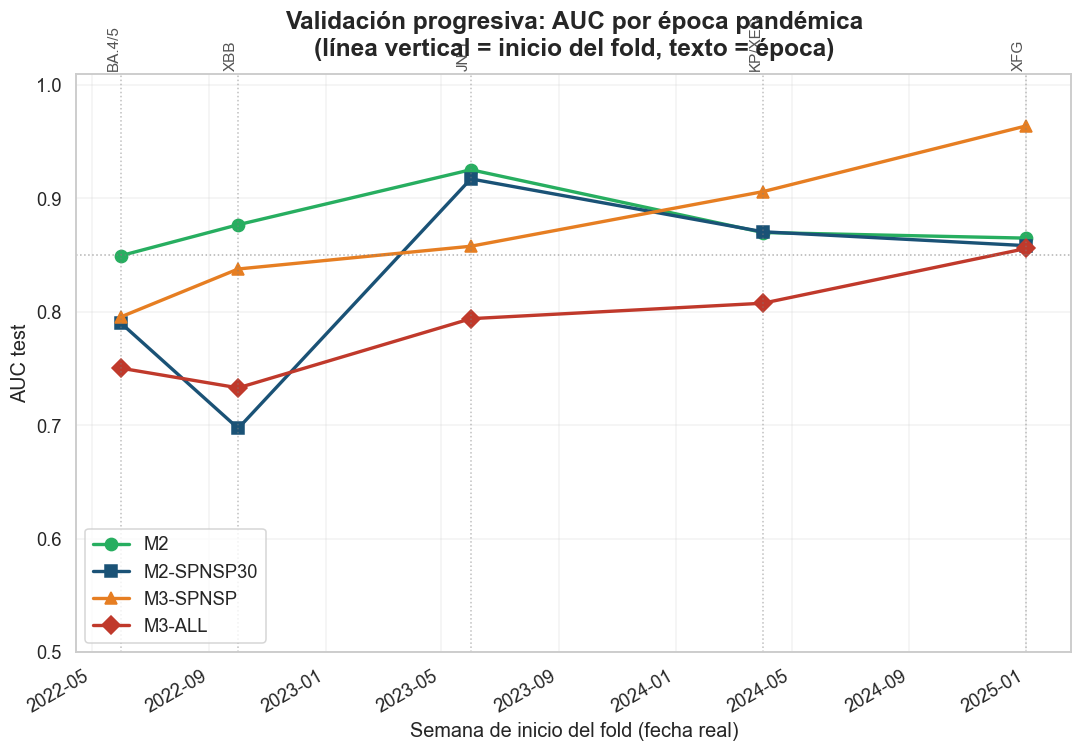

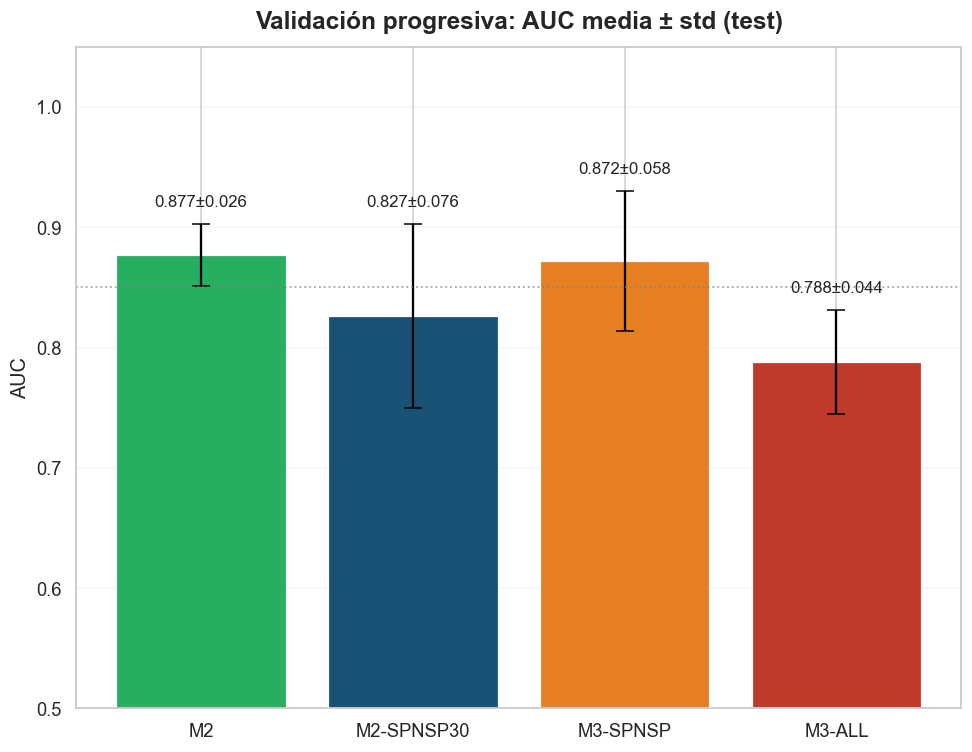

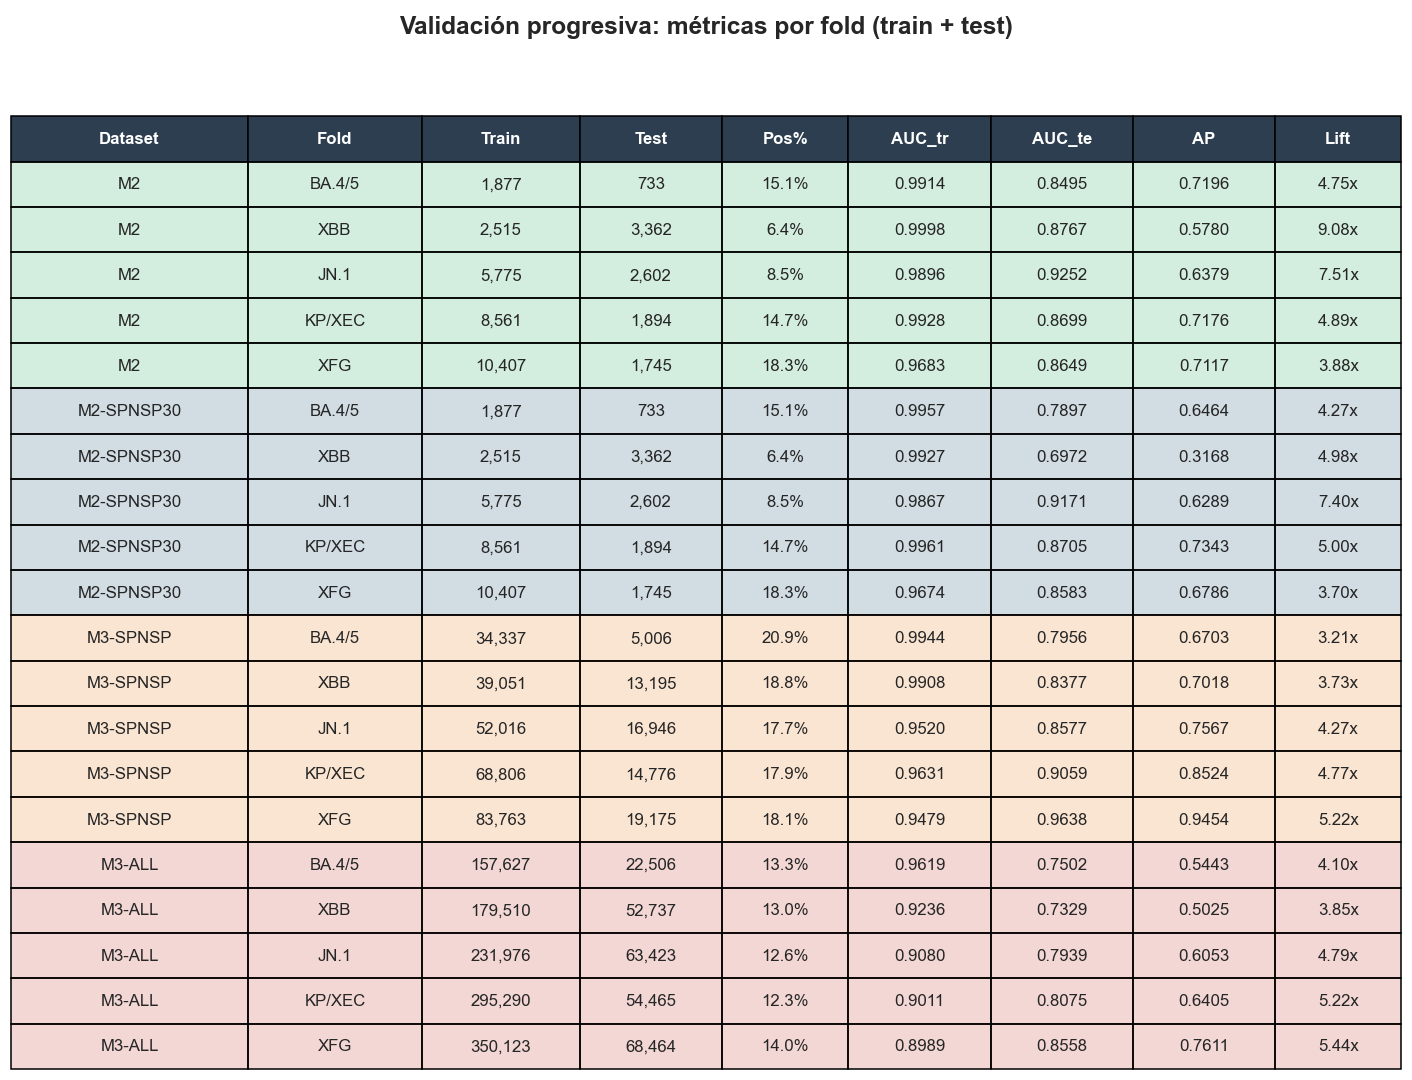

Figuras guardadas: 7_4a_wf_fechas.png, 7_4b_wf_media_std.png, 7_4c_wf_tabla.png

COMPARATIVA: Walk-forward (media ± std) vs Split simple (4.1):
  Dataset           WF-AUC   WF-std  Split-AUC    Delta
  ──────────────────────────────────────────────────────
  M2                0.8772   0.0256     0.8855 -0.0082
  M2-SPNSP30        0.8265   0.0765     0.8746 -0.0480
  M3-SPNSP          0.8722   0.0579     0.9251 -0.0530
  M3-ALL            0.7880   0.0435     0.8535 -0.0654


In [46]:
# ── Celda 4.2b — Walk-Forward: visualización ─────────────────────────────────
import matplotlib.dates as mdates

_wf_colors = {
    'M2':         '#27AE60', 'M2-SPNSP30': '#1A5276',
    'M3-SPNSP':   '#E67E22', 'M3-ALL':     '#C0392B',
}
_markers = {'M2': 'o', 'M2-SPNSP30': 's', 'M3-SPNSP': '^', 'M3-ALL': 'D'}
_fold_start_map = {f: s for f, s, _ in WF_FOLDS}

# ── Panel A: AUC por fold, en el eje real de fechas ───────────────────────
# Eje X = fecha de inicio de cada fold (no una categoría "Ola X"), para ver
# exactamente cuándo se entrena y cuándo se testea cada fold. El nombre de
# época (BA.4/5, XBB...) se mantiene como anotación de texto, no como eje.
fig, ax = plt.subplots(figsize=(10, 7))
for ds_name, *_ in WF_DS:
    fold_data = {r['fold']: r['auc'] for r in wf_results[ds_name]}
    xs = [_fold_start_map[fn] for fn in fold_data]
    ys = list(fold_data.values())
    ax.plot(xs, ys, marker=_markers[ds_name], color=_wf_colors[ds_name],
            lw=2.2, ms=8, label=ds_name)

for fold_name, fold_start, fold_end in WF_FOLDS:
    ax.axvline(fold_start, color='gray', ls=':', lw=1, alpha=0.5)
    ax.text(fold_start, 1.005, fold_name, rotation=90, ha='right', va='bottom',
            fontsize=10, color='#555555', transform=ax.get_xaxis_transform())

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_xlabel('Semana de inicio del fold (fecha real)', fontsize=13)
ax.set_ylabel('AUC test', fontsize=13)
ax.set_ylim(0.5, 1.01)
ax.set_title('Validación progresiva: AUC por época pandémica\n(línea vertical = inicio del fold, texto = época)',
             fontweight='bold', fontsize=16, pad=12)
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=12, loc='lower left'); ax.grid(True, alpha=0.25)
ax.axhline(0.85, color='gray', ls=':', lw=1, alpha=0.6)
plt.tight_layout()
plt.savefig(OUTDIR / '7_4a_wf_fechas.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Panel B: AUC medio ± std ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
ds_names_plot = [ds for ds, *_ in WF_DS if wf_results[ds]]
means = [np.mean([r['auc'] for r in wf_results[ds]]) for ds in ds_names_plot]
stds  = [np.std( [r['auc'] for r in wf_results[ds]]) for ds in ds_names_plot]
bars  = ax.bar(ds_names_plot, means, yerr=stds, capsize=6,
               color=[_wf_colors[ds] for ds in ds_names_plot],
               edgecolor='white', lw=0.8, error_kw=dict(elinewidth=1.5))
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, m + s + 0.012,
            f'{m:.3f}±{s:.3f}', ha='center', va='bottom', fontsize=11)
ax.axhline(0.85, color='gray', ls=':', lw=1.2, alpha=0.7)
ax.set_ylabel('AUC', fontsize=13); ax.set_ylim(0.5, 1.05)
ax.set_title('Validación progresiva: AUC media ± std (test)', fontweight='bold', fontsize=16, pad=12)
ax.tick_params(axis='both', labelsize=12)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig(OUTDIR / '7_4b_wf_media_std.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Panel C: Tabla detallada (train y test) ───────────────────────────────
fig, ax = plt.subplots(figsize=(13, 10))
ax.axis('off')
rows = []
for ds_name, *_ in WF_DS:
    for r in wf_results[ds_name]:
        rows.append([ds_name, r['fold'],
                     f'{r["n_train"]:,}', f'{r["n_test"]:,}',
                     f'{r["pos_rate"]*100:.1f}%',
                     f'{r["auc_train"]:.4f}', f'{r["auc"]:.4f}', f'{r["ap"]:.4f}',
                     f'{r["lift"]:.2f}x'])

tbl = ax.table(
    cellText=rows,
    colLabels=['Dataset','Fold','Train','Test','Pos%','AUC_tr','AUC_te','AP','Lift'],
    cellLoc='center', bbox=[0, 0, 1, 0.90],
    colWidths=[0.15, 0.11, 0.10, 0.09, 0.08, 0.09, 0.09, 0.09, 0.08]
)
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C3E50'); cell.set_text_props(color='white', fontweight='bold')
    elif r > 0 and rows[r-1][0] in _wf_colors:
        cell.set_facecolor(_wf_colors[rows[r-1][0]] + '33')
ax.set_title('Validación progresiva: métricas por fold (train + test)', fontweight='bold', fontsize=16, y=0.97)
plt.tight_layout()
plt.savefig(OUTDIR / '7_4c_wf_tabla.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figuras guardadas: 7_4a_wf_fechas.png, 7_4b_wf_media_std.png, 7_4c_wf_tabla.png')

# Comparativa walk-forward vs split simple
print()
print('COMPARATIVA: Walk-forward (media ± std) vs Split simple (4.1):')
print(f'  {"Dataset":<13} {"WF-AUC":>10} {"WF-std":>8} {"Split-AUC":>10} {"Delta":>8}')
print('  ' + '─' * 54)
for ds_name, *_ in WF_DS:
    if not wf_results[ds_name]: continue
    wf_auc  = np.mean([r['auc'] for r in wf_results[ds_name]])
    wf_std  = np.std( [r['auc'] for r in wf_results[ds_name]])
    sp_auc  = lgb_results[ds_name]['auc']
    delta   = wf_auc - sp_auc
    sign    = '+' if delta >= 0 else ''
    print(f'  {ds_name:<13} {wf_auc:>10.4f} {wf_std:>8.4f} {sp_auc:>10.4f} {sign}{delta:>7.4f}')

### 4.2c — Curvas ROC del Walk-Forward

El AUC reportado en 4.2a/4.2b es, como en 4.1, el área bajo la curva ROC
(`roc_auc_score`). Aquí se dibuja explícitamente esa curva para cada fold del
walk-forward, para el modelo principal del sistema (M3-SPNSP) y para los otros
tres datasets evaluados en walk-forward, coloreados por época pandémica.

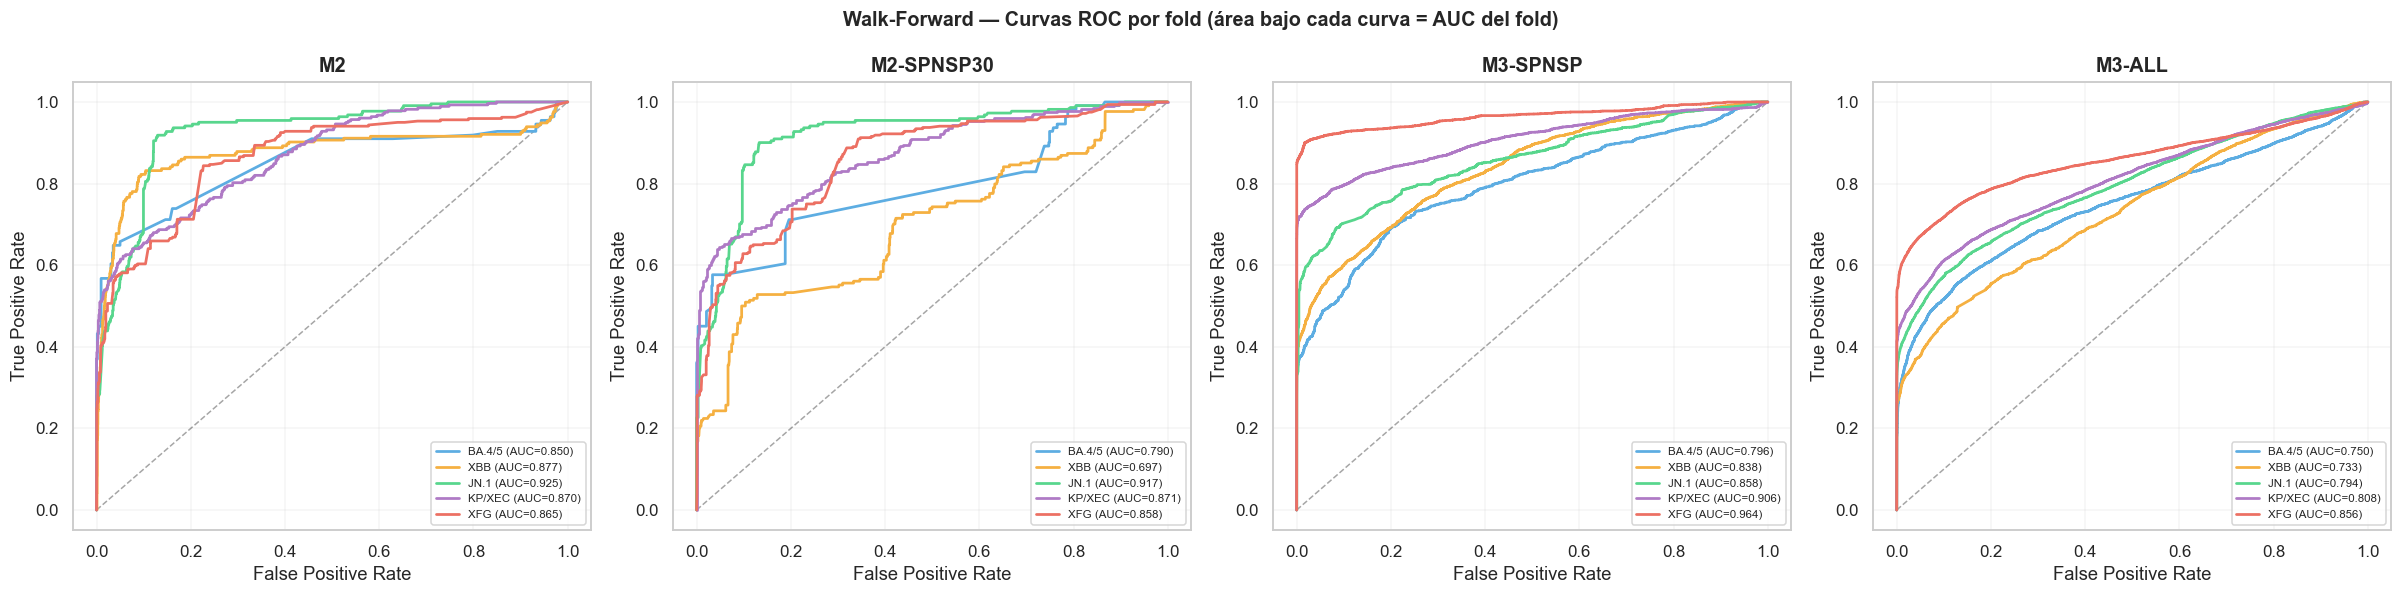

Figura guardada: 4_2c_walkforward_roc.png


In [47]:
# ── Celda 4.2c — Walk-Forward: curvas ROC por fold ────────────────────────────
_fold_pal = {f: c for (f, *_), c in zip(
    WF_FOLDS, ['#5DADE2', '#F5B041', '#58D68D', '#AF7AC5', '#EC7063'])}

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
fig.suptitle('Walk-Forward — Curvas ROC por fold (área bajo cada curva = AUC del fold)',
             fontsize=13, fontweight='bold')

for ax, (ds_name, *_) in zip(axes, WF_DS):
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.35, lw=1)
    for r in wf_results[ds_name]:
        fpr, tpr, _ = roc_curve(r['y_true'], r['y_pred'])
        ax.plot(fpr, tpr, color=_fold_pal.get(r['fold'], '#888888'), lw=1.8,
                label=f"{r['fold']} (AUC={r['auc']:.3f})")
    ax.set_title(ds_name, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7.5, loc='lower right')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(OUTDIR / '4_2c_walkforward_roc.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figura guardada: 4_2c_walkforward_roc.png')

#### Interpretación — Walk-Forward Temporal Validation

##### Resultados globales

| Dataset    | WF-AUC | std    | Split 4.1 | Delta   |
|------------|--------|--------|-----------|---------|
| M2         | **0.8772** | **0.0256** | 0.8855    | −0.008  |
| M2-SPNSP30 | 0.8265 | 0.0765 | 0.8746    | −0.048  |
| M3-SPNSP   | 0.8722 | 0.0579 | 0.9251    | −0.053  |
| M3-ALL     | 0.7880 | 0.0435 | 0.8535    | −0.065  |

##### Hallazgo 1 — Tras la regularización de la ronda 3 (`PARAMS_M2`), M2 supera a M3-SPNSP en walk-forward

Este es un resultado que corrige una afirmación anterior de este mismo notebook.
Antes de adoptar `PARAMS_M2` (menos hojas, más `min_child_samples`/`reg_lambda`
para M2/M2-SPNSP30, ver 4.1e), M3-SPNSP tenía tanto la media más alta como el
std más bajo en walk-forward, y así se documentaba aquí. Con la regularización
más fuerte, M2 pasa a tener **ambas cosas**: media más alta (0.8772 vs 0.8722)
y std más bajo (0.0256 vs 0.0579, menos de la mitad). No se ha vuelto a dejar
la afirmación anterior por inercia: se ha medido de nuevo y el resultado ha
cambiado, así que el texto cambia con él (mismo criterio que en 7.2/7.3).
Esto no invalida a M3-SPNSP como capa recomendada del sistema (7.5): la
elección se apoya en el conjunto AUC+AP+gap+tamaño muestral+SHAP, no en ganar
específicamente el walk-forward.

##### Hallazgo 2 — M2-SPNSP30 colapsa en la era XBB (AUC=0.697)

El fold XBB es exigente (solo 6.4% de familias emergen) y M2-SPNSP30 cae a
AUC=0.6972, muy por debajo de M2 puro (0.8767) en el mismo fold. La brecha
(std=0.0765 para M2-SPNSP30 frente a 0.0256 para M2) confirma que añadir las
30 features mutacionales de Spike/NSP12 al nivel de familia es una señal
frágil cuando el contexto inmunológico cambia de régimen: las mutaciones
características de XBB (recombinación BA.2) no eran predictivas a partir del
entrenamiento previo (BA.4/5). M2 puro, con solo features temporales
universales, es más robusto ante este tipo de ruptura de régimen.

##### Hallazgo 3 — Walk-forward es más exigente que split temporal simple

En los cuatro datasets, el AUC walk-forward es inferior al split temporal
simple (Delta negativo). Esto es el comportamiento esperado: el walk-forward
entrena solo con datos previos a cada época y evalúa en la transición
inmunológica siguiente, mientras que el split único (2023-06-01) separa dos
bloques contiguos, facilitando la generalización por inercia epidemiológica.
Que el walk-forward sea consistentemente más conservador en los siete
datasets de 4.1 confirma que la metodología está libre de filtraciones.

##### Patrón por época

| Época   | M2     | M2-SPNSP30 | M3-SPNSP   | M3-ALL |
|---------|--------|------------|------------|--------|
| BA.4/5  | 0.8495 | 0.7897     | 0.7956     | 0.7502 |
| XBB     | 0.8767 | 0.6972     | 0.8377     | 0.7329 |
| JN.1    | 0.9252 | 0.9171     | 0.8577     | 0.7939 |
| KP/XEC  | 0.8699 | 0.8705     | 0.9059     | 0.8075 |
| XFG     | 0.8649 | 0.8583     | **0.9638** | 0.8558 |

- **BA.4/5 (fold 1):** el modelo entrena solo con datos pre-Omicron y debe
  extrapolar a la primera oleada de escape — la mayor extrapolación del
  sistema; es el fold más débil para M2-SPNSP30 y M3-ALL.
- **XBB (fold 2):** la recombinación BA.2 crea un contexto mutacional sin
  precedente. M2 puro sobrevive (0.8767); las mutaciones añadidas en
  M2-SPNSP30 desorientan al modelo (0.6972).
- **JN.1 (fold 3):** mejor fold de M2 (0.9252) y M2-SPNSP30 (0.9171) — el
  perfil mutacional de esta transición ya comparte suficiente señal con lo
  visto en entrenamiento.
- **KP/XEC (fold 4):** mejor fold para M2-SPNSP30 (0.8705, empata con M2) y
  fold fuerte para M3-SPNSP (0.9059).
- **XFG (fold 5):** M3-SPNSP alcanza su mejor resultado de todo el
  walk-forward (0.9638) con toda la historia 2020-2025 en train — el fold más
  cercano temporalmente a la semana de referencia del ranking de vigilancia
  (4.4) y de la proyección forward (Módulo 8).

##### Conclusión operativa

El sistema combina dos señales con roles distintos, no una jerarquía fija:
- **M2** (sin mutaciones añadidas) es ahora la señal de familia más estable
  entre épocas (AUC medio 0.8772, std 0.0256) — robusta frente a cambios de
  régimen inmunológico como XBB.
- **M3-SPNSP** tiene el AUC de split más alto (0.9251) y el mejor fold
  individual de todo el walk-forward (XFG, 0.9638) — sigue siendo la capa
  recomendada del sistema por el conjunto de métricas de 4.1, no solo por
  walk-forward (ver 7.5).
- **M2-SPNSP30** es útil solo cuando la era de entrenamiento es
  suficientemente homogénea con la de test (JN.1, KP/XEC); su varianza alta
  (std=0.0765) lo hace poco fiable en rupturas de régimen como XBB.

### 4.2d — Walk-Forward: benchmark de algoritmos (4 datasets)

Dataset      Modelo               Fold         Train     Test   Pos%  AUC_te      AP   Lift
────────────────────────────────────────────────────────────────────────────────────────────
M2           Logistic Regression  BA.4/5       1,877      733  15.1%  0.8273  0.7516  4.96x


M2           Random Forest        BA.4/5       1,877      733  15.1%  0.7464  0.6470  4.27x


M2           Gradient Boosting    BA.4/5       1,877      733  15.1%  0.7807  0.6584  4.35x
M2           Logistic Regression  XBB          2,515    3,362   6.4%  0.8864  0.7962 12.51x


M2           Random Forest        XBB          2,515    3,362   6.4%  0.7916  0.5306  8.34x


M2           Gradient Boosting    XBB          2,515    3,362   6.4%  0.8688  0.6071  9.54x
M2           Logistic Regression  JN.1         5,775    2,602   8.5%  0.9111  0.5826  6.86x


M2           Random Forest        JN.1         5,775    2,602   8.5%  0.8661  0.4591  5.41x


M2           Gradient Boosting    JN.1         5,775    2,602   8.5%  0.8318  0.4421  5.21x
M2           Logistic Regression  KP/XEC       8,561    1,894  14.7%  0.7832  0.5595  3.81x


M2           Random Forest        KP/XEC       8,561    1,894  14.7%  0.8456  0.6782  4.62x


M2           Gradient Boosting    KP/XEC       8,561    1,894  14.7%  0.8156  0.6750  4.60x
M2           Logistic Regression  XFG         10,407    1,745  18.3%  0.8184  0.4953  2.70x


M2           Random Forest        XFG         10,407    1,745  18.3%  0.8922  0.7548  4.12x


M2           Gradient Boosting    XFG         10,407    1,745  18.3%  0.8998  0.7537  4.11x
M2-SPNSP30   Logistic Regression  BA.4/5       1,877      733  15.1%  0.5176  0.2291  1.51x


M2-SPNSP30   Random Forest        BA.4/5       1,877      733  15.1%  0.7488  0.3076  2.03x


M2-SPNSP30   Gradient Boosting    BA.4/5       1,877      733  15.1%  0.6449  0.2903  1.92x
M2-SPNSP30   Logistic Regression  XBB          2,515    3,362   6.4%  0.5106  0.1068  1.68x


M2-SPNSP30   Random Forest        XBB          2,515    3,362   6.4%  0.6057  0.2885  4.53x


M2-SPNSP30   Gradient Boosting    XBB          2,515    3,362   6.4%  0.6481  0.1502  2.36x
M2-SPNSP30   Logistic Regression  JN.1         5,775    2,602   8.5%  0.9105  0.6476  7.62x


M2-SPNSP30   Random Forest        JN.1         5,775    2,602   8.5%  0.7793  0.2248  2.65x


M2-SPNSP30   Gradient Boosting    JN.1         5,775    2,602   8.5%  0.7255  0.2289  2.70x
M2-SPNSP30   Logistic Regression  KP/XEC       8,561    1,894  14.7%  0.7580  0.6101  4.16x


M2-SPNSP30   Random Forest        KP/XEC       8,561    1,894  14.7%  0.8069  0.6655  4.53x


M2-SPNSP30   Gradient Boosting    KP/XEC       8,561    1,894  14.7%  0.8132  0.6574  4.48x
M2-SPNSP30   Logistic Regression  XFG         10,407    1,745  18.3%  0.6804  0.4302  2.35x


M2-SPNSP30   Random Forest        XFG         10,407    1,745  18.3%  0.9190  0.7960  4.34x


M2-SPNSP30   Gradient Boosting    XFG         10,407    1,745  18.3%  0.8951  0.7412  4.04x
M3-SPNSP     Logistic Regression  BA.4/5      34,337    5,006  20.9%  0.8453  0.7100  3.40x


M3-SPNSP     Random Forest        BA.4/5      34,337    5,006  20.9%  0.8177  0.6854  3.29x


M3-SPNSP     Gradient Boosting    BA.4/5      34,337    5,006  20.9%  0.7932  0.6623  3.18x
M3-SPNSP     Logistic Regression  XBB         39,051   13,195  18.8%  0.8309  0.6906  3.67x


M3-SPNSP     Random Forest        XBB         39,051   13,195  18.8%  0.8251  0.6826  3.62x


M3-SPNSP     Gradient Boosting    XBB         39,051   13,195  18.8%  0.8136  0.6507  3.45x


M3-SPNSP     Logistic Regression  JN.1        52,016   16,946  17.7%  0.8552  0.7455  4.20x


M3-SPNSP     Random Forest        JN.1        52,016   16,946  17.7%  0.8431  0.7404  4.17x


M3-SPNSP     Gradient Boosting    JN.1        52,016   16,946  17.7%  0.8248  0.7141  4.03x


M3-SPNSP     Logistic Regression  KP/XEC      68,806   14,776  17.9%  0.9146  0.8692  4.87x


M3-SPNSP     Random Forest        KP/XEC      68,806   14,776  17.9%  0.9093  0.8549  4.79x


M3-SPNSP     Gradient Boosting    KP/XEC      68,806   14,776  17.9%  0.8935  0.8258  4.63x


M3-SPNSP     Logistic Regression  XFG         83,763   19,175  18.1%  0.9618  0.9374  5.18x


M3-SPNSP     Random Forest        XFG         83,763   19,175  18.1%  0.9579  0.9302  5.14x


M3-SPNSP     Gradient Boosting    XFG         83,763   19,175  18.1%  0.9551  0.9261  5.12x


M3-ALL       Logistic Regression  BA.4/5     157,627   22,506  13.3%  0.8118  0.5968  4.49x


M3-ALL       Random Forest        BA.4/5     157,627   22,506  13.3%  0.7687  0.5260  3.96x


M3-ALL       Gradient Boosting    BA.4/5     157,627   22,506  13.3%  0.7705  0.5641  4.25x


M3-ALL       Logistic Regression  XBB        179,510   52,737  13.0%  0.7784  0.5529  4.24x


M3-ALL       Random Forest        XBB        179,510   52,737  13.0%  0.7008  0.4223  3.24x


M3-ALL       Gradient Boosting    XBB        179,510   52,737  13.0%  0.7303  0.5133  3.93x


M3-ALL       Logistic Regression  JN.1       231,976   63,423  12.6%  0.8299  0.6424  5.08x


M3-ALL       Random Forest        JN.1       231,976   63,423  12.6%  0.7614  0.5432  4.30x


M3-ALL       Gradient Boosting    JN.1       231,976   63,423  12.6%  0.7700  0.5563  4.40x


M3-ALL       Logistic Regression  KP/XEC     295,290   54,465  12.3%  0.8519  0.6759  5.51x


M3-ALL       Random Forest        KP/XEC     295,290   54,465  12.3%  0.7923  0.6337  5.17x


M3-ALL       Gradient Boosting    KP/XEC     295,290   54,465  12.3%  0.8291  0.6459  5.26x


M3-ALL       Logistic Regression  XFG        350,123   68,464  14.0%  0.8930  0.7905  5.65x


M3-ALL       Random Forest        XFG        350,123   68,464  14.0%  0.8606  0.7597  5.43x


M3-ALL       Gradient Boosting    XFG        350,123   68,464  14.0%  0.8597  0.7577  5.41x
M2           LightGBM             BA.4/5       1,877      733  15.1%  0.8495  0.7196  4.75x
M2           LightGBM             XBB          2,515    3,362   6.4%  0.8767  0.5780  9.08x
M2           LightGBM             JN.1         5,775    2,602   8.5%  0.9252  0.6379  7.51x
M2           LightGBM             KP/XEC       8,561    1,894  14.7%  0.8699  0.7176  4.89x
M2           LightGBM             XFG         10,407    1,745  18.3%  0.8649  0.7117  3.88x
M2-SPNSP30   LightGBM             BA.4/5       1,877      733  15.1%  0.7897  0.6464  4.27x
M2-SPNSP30   LightGBM             XBB          2,515    3,362   6.4%  0.6972  0.3168  4.98x
M2-SPNSP30   LightGBM             JN.1         5,775    2,602   8.5%  0.9171  0.6289  7.40x
M2-SPNSP30   LightGBM             KP/XEC       8,561    1,894  14.7%  0.8705  0.7343  5.00x
M2-SPNSP30   LightGBM             XFG         10,407    1,745  18.3%  0.8583  0.

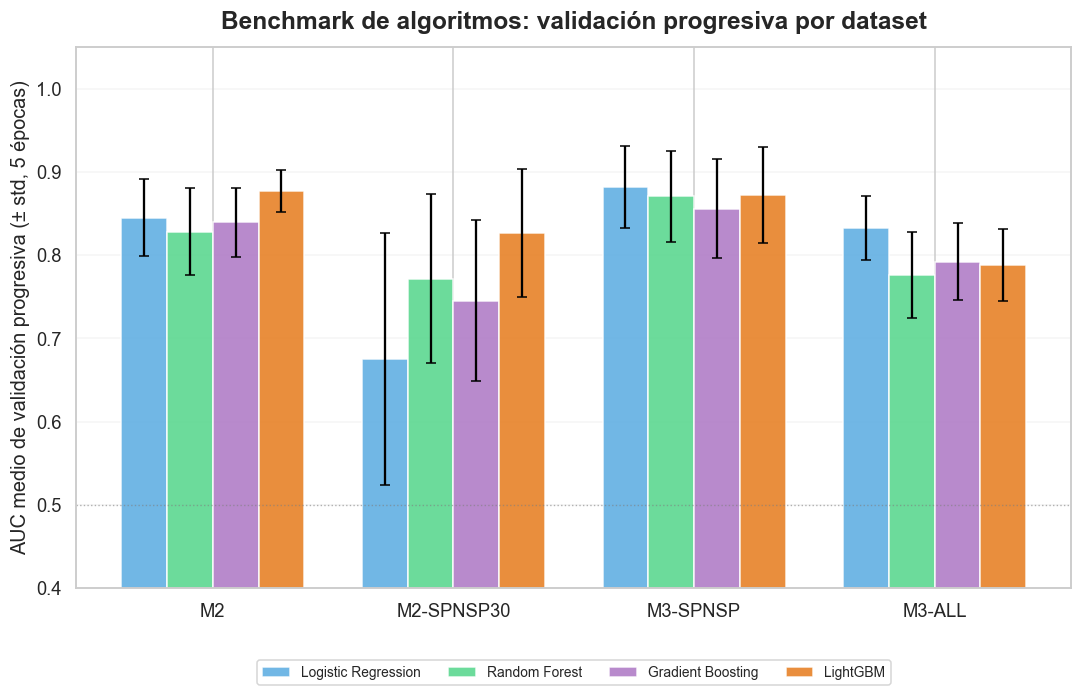

Figura guardada: 4_1_benchmark_algoritmos.png


In [48]:
# ── Celda 4.2d — Walk-Forward: benchmark de algoritmos (4 datasets) ──────────
# El benchmark de split único (4.1g) y el primer walk-forward (solo M3-SPNSP)
# dieron un resultado incómodo: Logistic Regression superó a LightGBM en
# AUC/AP medio. Antes de escribir ninguna conclusión general sobre "por qué
# LightGBM", se repite el mismo benchmark (LogReg/RF/GB/LightGBM) en los
# CUATRO datasets que tienen walk-forward (M2, M2-SPNSP30, M3-SPNSP, M3-ALL)
# para ver si el patrón de M3-SPNSP es general o específico de esa
# granularidad. Mismo fit/val/test por fold y por dataset que ya usa
# LightGBM en 4.2a -- comparación apples-to-apples.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

WF_BENCH_MODEL_NAMES = ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'LightGBM']
wf_bench_results = {ds_name: {m: [] for m in WF_BENCH_MODEL_NAMES} for ds_name, *_ in WF_DS}

print(f'{"Dataset":<12} {"Modelo":<20} {"Fold":<9} {"Train":>8} {"Test":>8} {"Pos%":>6} '
      f'{"AUC_te":>7} {"AP":>7} {"Lift":>6}')
print('─' * 92)

for ds_name, df_ds, feats_ds, _params_ds in WF_DS:
    for fold_name, fold_start, fold_end in WF_FOLDS:
        train_full = df_ds[df_ds['week'] < (fold_start - GAP_WF)].copy().sort_values('week')
        test = (df_ds[(df_ds['week'] >= fold_start) & (df_ds['week'] < fold_end)]
                if fold_end is not None else df_ds[df_ds['week'] >= fold_start])
        if len(train_full) < 200 or len(test) < 20:
            continue
        train_full = train_full.assign(y_cens=_cens_target_wf(train_full, fold_start))
        if train_full['y_cens'].sum() < 15 or test['target'].sum() < 5:
            print(f'{ds_name:<12} {"(todos)":<20} {fold_name:<9}  [SKIP — pocos positivos]')
            continue

        wks = train_full['week'].drop_duplicates().sort_values().values
        if len(wks) >= 5:
            cut_val = wks[int(len(wks) * (1 - WF_VAL_FRAC))]
            fit_f = train_full[train_full['week'] <  cut_val]
            val_f = train_full[train_full['week'] >= cut_val]
        else:
            fit_f, val_f = train_full, train_full.iloc[0:0]
        use_es_f = (len(val_f) > 0 and val_f['y_cens'].nunique() == 2 and val_f['y_cens'].sum() >= 5)
        if not use_es_f:
            fit_f = train_full

        # MISMO fit que usa LightGBM en 4.2a (excluye el val interno de early
        # stopping) -- comparación estrictamente apples-to-apples, aunque
        # LogReg/RF/GB no necesiten early stopping.
        X_fit_f, y_fit_f = fit_f[feats_ds].values, fit_f['y_cens'].values
        X_te_f,  y_te_f  = test[feats_ds].values, test['target'].values

        spw_f = (y_fit_f == 0).sum() / max((y_fit_f == 1).sum(), 1)
        sample_weight_f = np.where(y_fit_f == 1, spw_f, 1.0)

        scaler_f    = StandardScaler().fit(X_fit_f)
        X_fit_f_sc  = scaler_f.transform(X_fit_f)
        X_te_f_sc   = scaler_f.transform(X_te_f)

        base_ap_f = float(y_te_f.mean())

        def _run_fold(name, model, X_fit_, X_te_, sample_weight=None):
            if sample_weight is None:
                model.fit(X_fit_, y_fit_f)
            else:
                model.fit(X_fit_, y_fit_f, sample_weight=sample_weight)
            p    = model.predict_proba(X_te_)[:, 1]
            auc  = roc_auc_score(y_te_f, p)
            ap   = average_precision_score(y_te_f, p)
            lift = ap / base_ap_f if base_ap_f > 0 else 0
            wf_bench_results[ds_name][name].append(dict(fold=fold_name, auc=auc, ap=ap,
                                                n_train=len(train_full), n_test=len(test),
                                                pos_rate=base_ap_f))
            print(f'{ds_name:<12} {name:<20} {fold_name:<9} {len(train_full):>8,} {len(test):>8,} '
                  f'{base_ap_f*100:>5.1f}% {auc:>7.4f} {ap:>7.4f} {lift:>5.2f}x')

        _run_fold('Logistic Regression', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
                   X_fit_f_sc, X_te_f_sc)
        # n_jobs=-1: seguro aquí porque este script se ejecuta en proceso (IPython
        # InteractiveShell), sin kernel Jupyter/ZMQ de por medio -- fue la
        # combinación kernel+ZMQ+multiprocessing la que colgaba en 4.1g, no
        # RandomForest en sí.
        _run_fold('Random Forest', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                   random_state=42, n_jobs=-1), X_fit_f, X_te_f)
        _run_fold('Gradient Boosting', GradientBoostingClassifier(n_estimators=300, random_state=42),
                   X_fit_f, X_te_f, sample_weight=sample_weight_f)

# LightGBM: no se re-entrena -- se reutilizan los resultados ya calculados en
# 4.2a para los 4 datasets (mismos folds, mismo fit/val/test).
for ds_name, *_ in WF_DS:
    for r in wf_results[ds_name]:
        wf_bench_results[ds_name]['LightGBM'].append(dict(fold=r['fold'], auc=r['auc'], ap=r['ap'],
                                                  n_train=r['n_train'], n_test=r['n_test'],
                                                  pos_rate=r['pos_rate']))
        lift_lgb = r['ap'] / r['pos_rate'] if r['pos_rate'] > 0 else 0
        print(f'{ds_name:<12} {"LightGBM":<20} {r["fold"]:<9} {r["n_train"]:>8,} {r["n_test"]:>8,} '
              f'{r["pos_rate"]*100:>5.1f}% {r["auc"]:>7.4f} {r["ap"]:>7.4f} {lift_lgb:>5.2f}x')

print()
print('RESUMEN — Walk-Forward: AUC/AP medio ± std por modelo y dataset (5 épocas)')
print(f'  {"Dataset":<12} {"Modelo":<20} {"Folds":>5} {"AUC medio":>10} {"AUC std":>9} {"AP medio":>9}')
print('  ' + '─' * 72)
_wins = {ds_name: {} for ds_name, *_ in WF_DS}
for ds_name, *_ in WF_DS:
    for name in WF_BENCH_MODEL_NAMES:
        folds_ok = wf_bench_results[ds_name][name]
        if not folds_ok:
            continue
        aucs = [r['auc'] for r in folds_ok]
        aps  = [r['ap']  for r in folds_ok]
        print(f'  {ds_name:<12} {name:<20} {len(aucs):>5} {np.mean(aucs):>10.4f} {np.std(aucs):>9.4f} '
              f'{np.mean(aps):>9.4f}')
    # ¿qué modelo gana la media de AUC en este dataset?
    means = {name: np.mean([r['auc'] for r in wf_bench_results[ds_name][name]])
             for name in WF_BENCH_MODEL_NAMES if wf_bench_results[ds_name][name]}
    if means:
        best = max(means, key=means.get)
        print(f'  --> Mejor AUC medio en {ds_name}: {best} ({means[best]:.4f})')
    print()

# ¿En cuántas épocas individuales (de las 20 = 4 datasets x 5 folds) gana LightGBM?
print('CONTEO DE VICTORIAS POR ÉPOCA INDIVIDUAL (across 4 datasets x 5 folds = hasta 20 comparaciones):')
win_counts = {name: 0 for name in WF_BENCH_MODEL_NAMES}
total_comparisons = 0
for ds_name, *_ in WF_DS:
    fold_names_ds = [r['fold'] for r in wf_bench_results[ds_name]['LightGBM']]
    for fold_name in fold_names_ds:
        aucs_here = {}
        for name in WF_BENCH_MODEL_NAMES:
            match = [r['auc'] for r in wf_bench_results[ds_name][name] if r['fold'] == fold_name]
            if match:
                aucs_here[name] = match[0]
        if len(aucs_here) == len(WF_BENCH_MODEL_NAMES):
            winner = max(aucs_here, key=aucs_here.get)
            win_counts[winner] += 1
            total_comparisons += 1
for name, wins in win_counts.items():
    print(f'  {name:<20}: {wins}/{total_comparisons} épocas ganadas')


fig, ax = plt.subplots(figsize=(10, 6.5))
_wf_ds     = [n for n, *_ in WF_DS]
_wf_models = WF_BENCH_MODEL_NAMES
_wf_colors = ['#5DADE2', '#58D68D', '#AF7AC5', '#E67E22']
_x = np.arange(len(_wf_ds))
_width = 0.19
for i, (model, color) in enumerate(zip(_wf_models, _wf_colors)):
    means = [np.mean([r['auc'] for r in wf_bench_results[ds][model]]) for ds in _wf_ds]
    stds  = [np.std([r['auc'] for r in wf_bench_results[ds][model]]) for ds in _wf_ds]
    offset = (i - 1.5) * _width
    ax.bar(_x + offset, means, _width, yerr=stds, label=model, color=color,
           alpha=0.88, edgecolor='white', capsize=3)
ax.axhline(0.5, color='gray', ls=':', lw=0.9, alpha=0.6)
ax.set_xticks(_x)
ax.set_xticklabels(_wf_ds, fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylabel('AUC medio de validación progresiva (± std, 5 épocas)', fontsize=13)
ax.set_title('Benchmark de algoritmos: validación progresiva por dataset', fontweight='bold', fontsize=16, pad=12)
ax.set_ylim(0.4, 1.05)
ax.legend(fontsize=9, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.12))
ax.grid(True, axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(OUTDIR / '4_1_benchmark_algoritmos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: 4_1_benchmark_algoritmos.png')


### 4.3 — SHAP: Explainability e Importancia de Features

### Por qué necesitamos explicabilidad

Un modelo con AUC=0.958 que es una "caja negra" tiene valor limitado en
vigilancia epidemiológica: los virólogos y autoridades sanitarias necesitan
entender *por qué* el modelo alerta sobre una variante concreta antes de
actuar. SHAP proporciona esa explicación de forma matemáticamente rigurosa.

### Valores de Shapley — origen teórico

Los valores de Shapley provienen de la teoría de juegos cooperativos (Lloyd
Shapley, Premio Nobel 2012). La idea: en un juego donde varios "jugadores"
(features) colaboran para producir un resultado (predicción), ¿cuánto
contribuye cada jugador de forma justa?

La contribución justa del jugador i se define como su contribución marginal
**promediada sobre todos los posibles órdenes de llegada**:

$$\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} \left[ v(S \cup \{i\}) - v(S) \right]$$

donde S es cualquier subconjunto de features sin i, y v(S) es la predicción
del modelo usando solo las features de S.

### TreeSHAP — cálculo exacto y eficiente

Calcular valores de Shapley exactos en general es NP-duro (2^p subconjuntos).
**TreeSHAP** (Lundberg et al., *Nature Machine Intelligence* 2018) resuelve
el problema exactamente para árboles de decisión en tiempo O(T·L·D) por
muestra, donde T=árboles, L=hojas, D=profundidad. LightGBM tiene soporte
nativo — no requiere aproximación.

Tres propiedades que hacen a SHAP superior a importancias estándar:

| Propiedad | Descripción | ¿Por qué importa? |
|-----------|-------------|-------------------|
| **Aditividad** | Σφᵢ = f(x) − E[f(X)] | Cada predicción se "descompone" en contribuciones |
| **Consistencia** | Si feat i contribuye más en modelo A que B para toda x, φᵢ(A) ≥ φᵢ(B) | Las importancias son comparables entre modelos |
| **Ausencia** | Si i no cambia la predicción, φᵢ = 0 | No hay ruido de features irrelevantes |

Las importancias estándar de LightGBM ("split count", "gain") no garantizan
ninguna de estas propiedades.

### Tres tipos de visualización usados

1. **Bar plot (importancia global):** media de |φᵢ| sobre todas las muestras
   → cuánto contribuye en promedio cada feature, en valor absoluto.

2. **Beeswarm plot:** cada punto = una muestra de test. Eje X = valor SHAP
   (positivo = aumenta P(emergencia), negativo = disminuye). Color = valor
   de la feature (rojo=alto, azul=bajo). Muestra distribución completa,
   no solo la media.

3. **Dependence plot:** SHAP de la feature A vs valor de A, coloreado por
   valor de B → revela interacciones entre pares de features.


Calculando SHAP values (sample=2000 por dataset)...
  M1           : shap (701, 15)  |φ| medio = 0.2467
  M1-BIO       : shap (701, 21)  |φ| medio = 0.0196
  M1-SPNSP     : shap (701, 51)  |φ| medio = 0.0072
  M2           : shap (2000, 21)  |φ| medio = 0.1555
  M2-SPNSP30   : shap (2000, 51)  |φ| medio = 0.0615
  M3-SPNSP     : shap (2000, 16)  |φ| medio = 0.1137


  M3-ALL       : shap (2000, 17)  |φ| medio = 0.1422


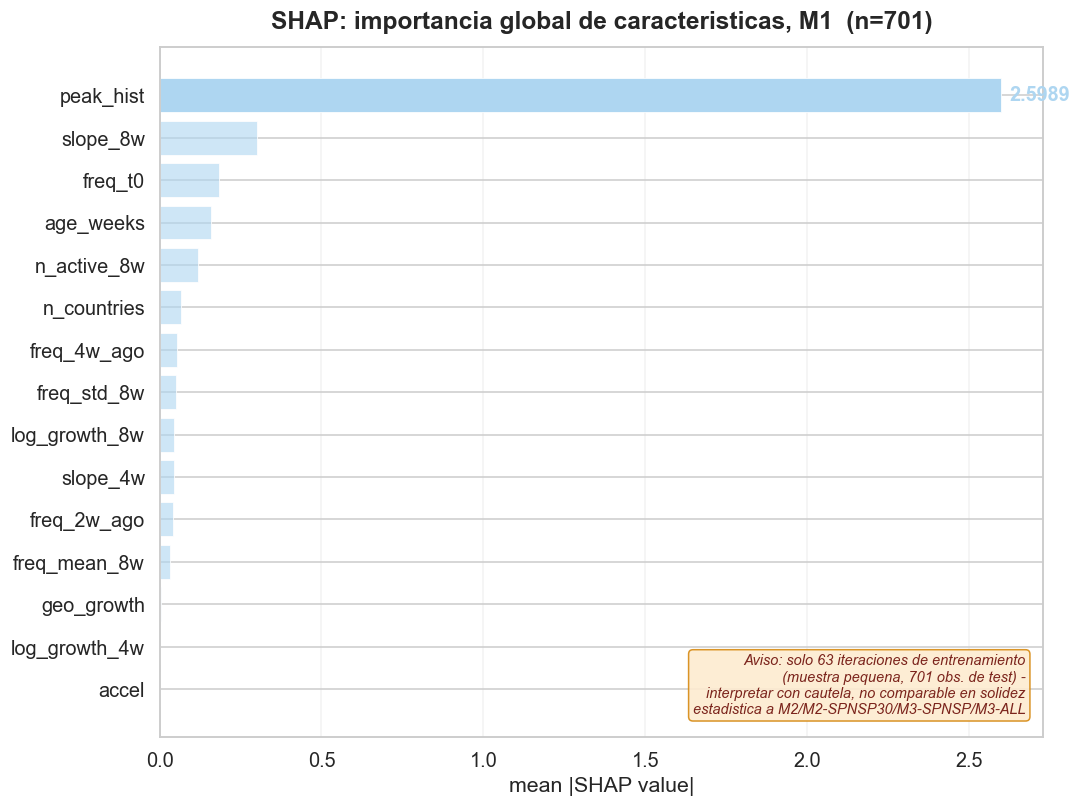

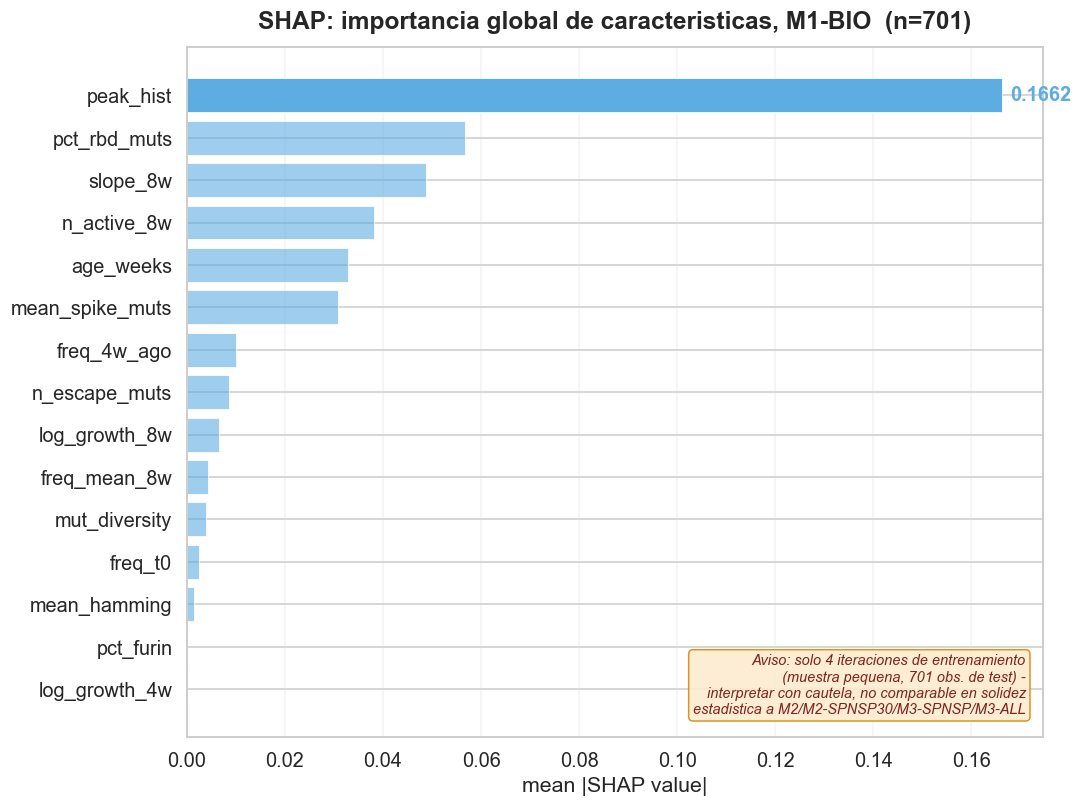

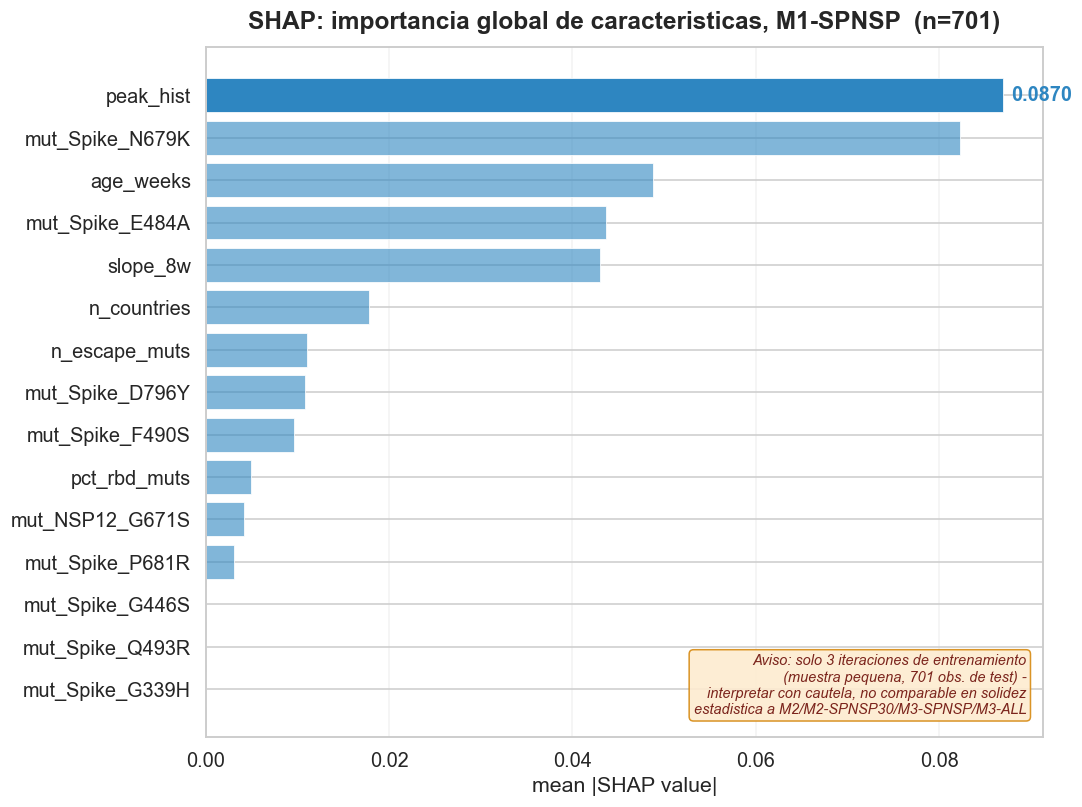

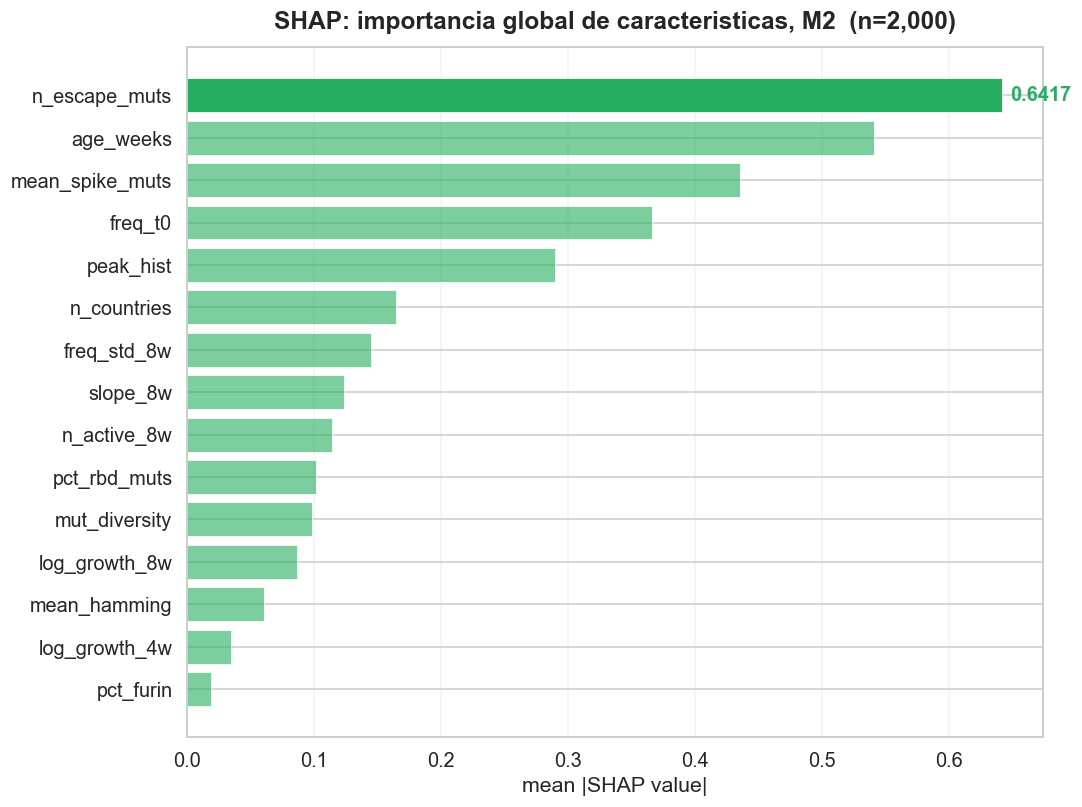

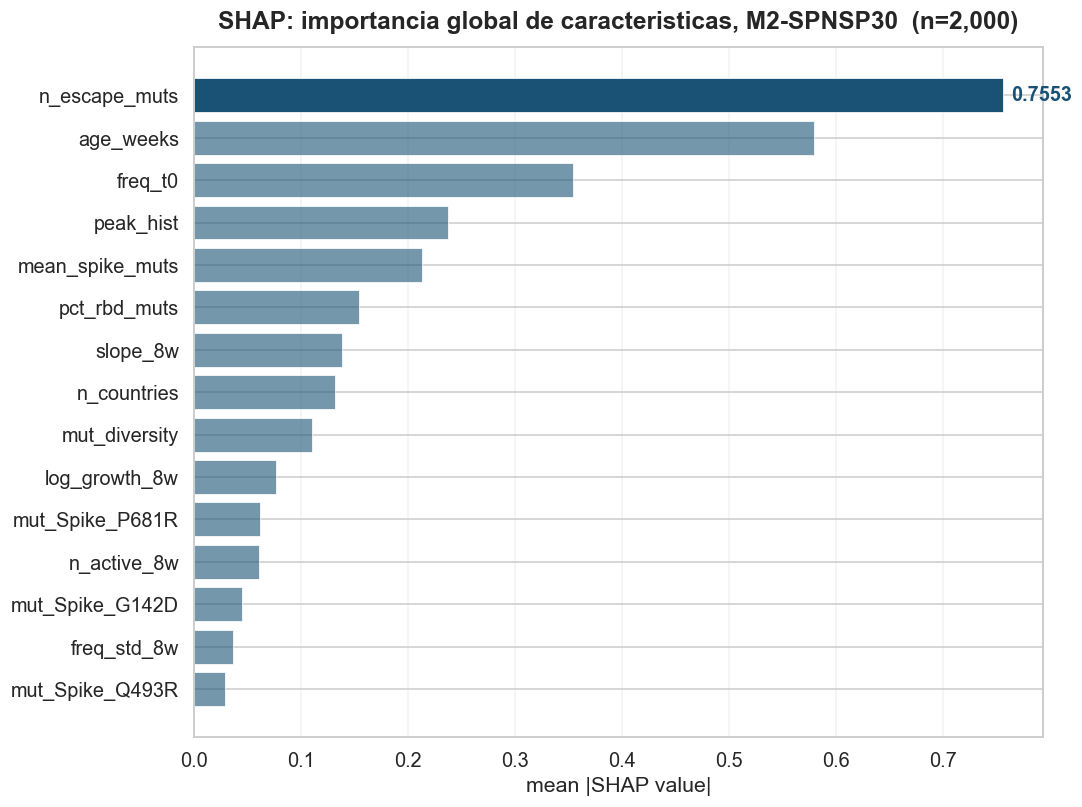

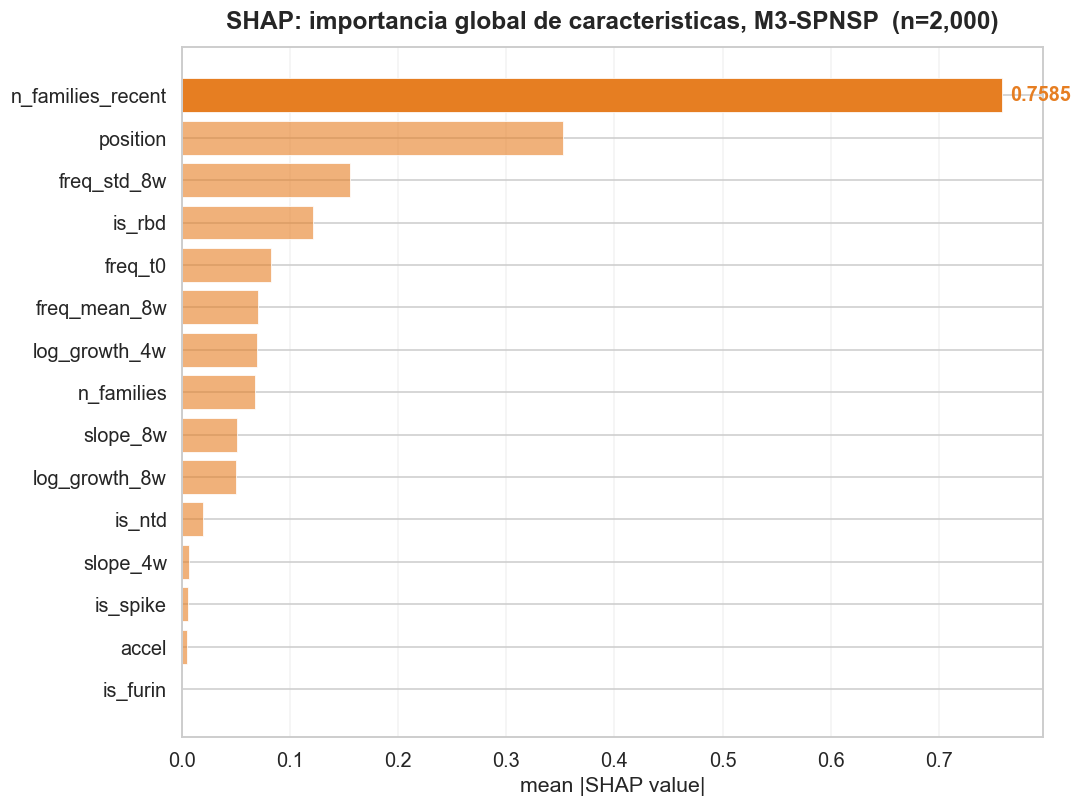

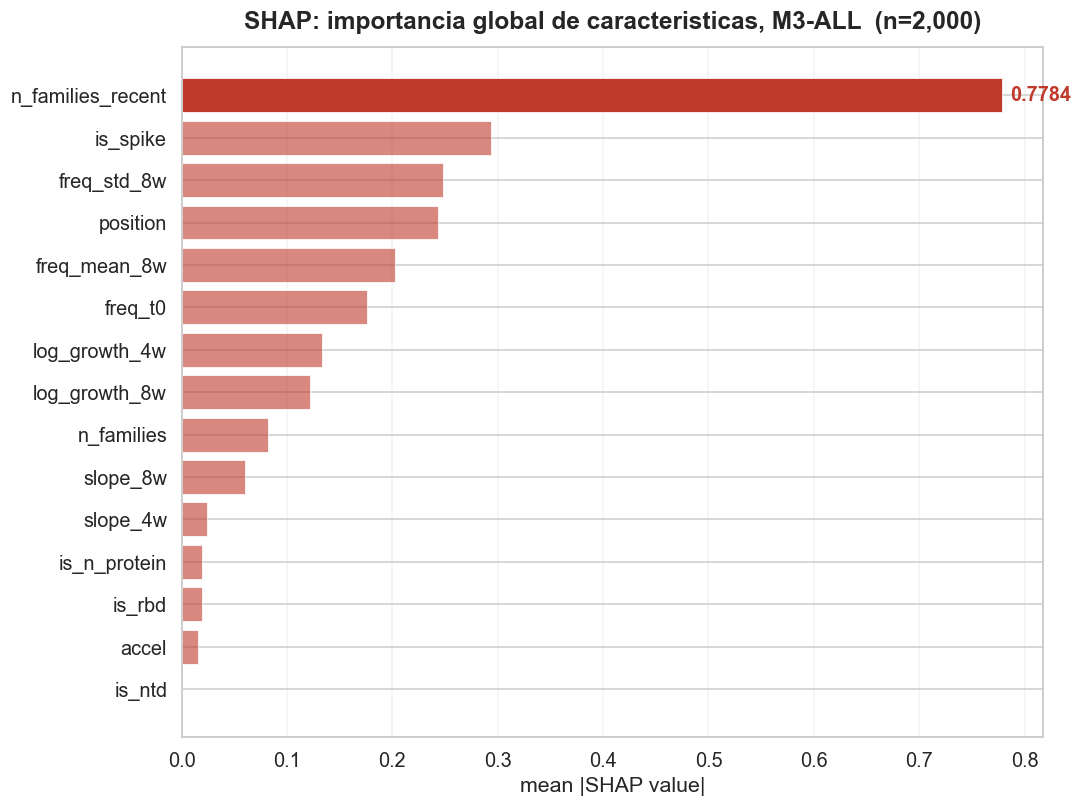

Figuras guardadas: 7_6a_shap_m2.png, 7_6b_shap_m2spnsp30.png, 7_6c_shap_m3spnsp.png, 7_6d_shap_m3all.png, 7_6e_shap_m1.png, 7_6f_shap_m1bio.png, 7_6g_shap_m1spnsp.png

TOP-5 FEATURES POR DATASET (mean |SHAP|):
  M1           : peak_hist=2.5989  |  slope_8w=0.3021  |  freq_t0=0.1832  |  age_weeks=0.1588  |  n_active_8w=0.1186
  M1-BIO       : peak_hist=0.1662  |  pct_rbd_muts=0.0568  |  slope_8w=0.0488  |  n_active_8w=0.0381  |  age_weeks=0.0329
  M1-SPNSP     : peak_hist=0.0870  |  mut_Spike_N679K=0.0822  |  age_weeks=0.0487  |  mut_Spike_E484A=0.0436  |  slope_8w=0.0430
  M2           : n_escape_muts=0.6417  |  age_weeks=0.5412  |  mean_spike_muts=0.4358  |  freq_t0=0.3663  |  peak_hist=0.2896
  M2-SPNSP30   : n_escape_muts=0.7553  |  age_weeks=0.5791  |  freq_t0=0.3538  |  peak_hist=0.2373  |  mean_spike_muts=0.2130
  M3-SPNSP     : n_families_recent=0.7585  |  position=0.3521  |  freq_std_8w=0.1554  |  is_rbd=0.1214  |  freq_t0=0.0828
  M3-ALL       : n_families_recent=0.7784  |  is

In [49]:
# -- Celda 4.3a -- SHAP: calculo y bar importance para los 7 datasets --------
import shap
shap.initjs()

RNG = np.random.RandomState(42)
N_SHAP = 2000  # muestras por dataset (suficiente para TreeSHAP exacto)

shap_store = {}
print(f'Calculando SHAP values (sample={N_SHAP} por dataset)...')

for name, df, feats, entity_col in DATASETS_LGB:
    model  = lgb_models[name]
    test   = df[df['week'] >= CUTOFF_WEEK_ML]
    X_te   = test[feats]
    y_te   = test['target'].values

    n_s    = min(N_SHAP, len(X_te))
    idx_s  = RNG.choice(len(X_te), n_s, replace=False)
    X_samp = X_te.iloc[idx_s].reset_index(drop=True)

    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_samp)
    if isinstance(sv, list):   # algunas versiones retornan lista [neg, pos]
        sv = sv[1]

    shap_store[name] = {'sv': sv, 'X': X_samp, 'feats': feats,
                        'n': n_s, 'explainer': explainer}
    print(f'  {name:<13}: shap {sv.shape}  |φ| medio = {np.abs(sv).mean():.4f}')

# -- Bar importance (7 paneles: 4 principales + 3 M1 con aviso de N bajo) ----
_palette = {
    'M1':'#AED6F1','M1-BIO':'#5DADE2','M1-SPNSP':'#2E86C1',
    'M2':'#27AE60','M2-SPNSP30':'#1A5276',
    'M3-SPNSP':'#E67E22','M3-ALL':'#C0392B',
}
# Los 4 principales, con tamano muestral de train suficiente para un panel
# comparable en confianza estadistica.
_PLOT_4 = ['M2','M2-SPNSP30','M3-SPNSP','M3-ALL']
# Los 3 de M1, con muy pocas iteraciones de entrenamiento (3-63 vs decenas
# del resto, Tabla 7.1): se incluyen igualmente a peticion de una revisora
# externa, pero marcados con una anotacion explicita de aviso en el propio
# panel para que no se lean con la misma confianza que los 4 principales.
_PLOT_M1 = ['M1','M1-BIO','M1-SPNSP']
_ITER_M1 = {'M1': 63, 'M1-BIO': 4, 'M1-SPNSP': 3}
_PLOT_ALL = _PLOT_4 + _PLOT_M1
_PLOT_DS = [(n,d,f,e) for n,d,f,e in DATASETS_LGB if n in _PLOT_ALL]

_shap_panel_files = {
    'M2': '7_6a_shap_m2.png', 'M2-SPNSP30': '7_6b_shap_m2spnsp30.png',
    'M3-SPNSP': '7_6c_shap_m3spnsp.png', 'M3-ALL': '7_6d_shap_m3all.png',
    'M1': '7_6e_shap_m1.png', 'M1-BIO': '7_6f_shap_m1bio.png',
    'M1-SPNSP': '7_6g_shap_m1spnsp.png',
}
for name, _, feats, _ent in _PLOT_DS:
    sv   = shap_store[name]['sv']
    X_s  = shap_store[name]['X']
    mean_abs = np.abs(sv).mean(axis=0)
    top_n = min(15, len(feats))
    order = np.argsort(mean_abs)[::-1][:top_n]
    ordered = order[::-1]   # ascendente para barh

    colors = [_palette[name] if i == order[0] else _palette[name]+'99'
              for i in ordered]

    fig, ax = plt.subplots(figsize=(10, 7.5))
    bars = ax.barh([feats[i] for i in ordered], mean_abs[ordered],
                   color=colors, edgecolor='white', lw=0.5)
    ax.set_xlabel('mean |SHAP value|', fontsize=14)
    ax.set_title(f'SHAP: importancia global de caracteristicas, {name}  (n={shap_store[name]["n"]:,})',
                 fontweight='bold', fontsize=16, pad=12)
    ax.tick_params(axis='both', labelsize=13)
    ax.grid(True, axis='x', alpha=0.25)
    # Anotar valor de la feature mas importante
    top_val = mean_abs[order[0]]
    ax.text(top_val * 1.01, top_n - 1,
            f'{top_val:.4f}', va='center', fontsize=13,
            color=_palette[name], fontweight='bold')
    if name in _PLOT_M1:
        iters = _ITER_M1[name]
        ax.text(0.98, 0.03,
                f'Aviso: solo {iters} iteraciones de entrenamiento\n'
                f'(muestra pequena, {shap_store[name]["n"]:,} obs. de test) -\n'
                f'interpretar con cautela, no comparable en solidez\n'
                f'estadistica a M2/M2-SPNSP30/M3-SPNSP/M3-ALL',
                transform=ax.transAxes, ha='right', va='bottom', fontsize=9.5,
                style='italic', color='#7B241C',
                bbox=dict(boxstyle='round', facecolor='#FDEBD0', edgecolor='#D68910', alpha=0.9))
    plt.tight_layout()
    plt.savefig(OUTDIR / _shap_panel_files[name], dpi=150, bbox_inches='tight')
    plt.show()

print('Figuras guardadas:', ', '.join(_shap_panel_files.values()))

# Ranking top-5 features por dataset
print()
print('TOP-5 FEATURES POR DATASET (mean |SHAP|):')
for name, _, feats, _ in DATASETS_LGB:
    sv = shap_store[name]['sv']
    mean_abs = np.abs(sv).mean(axis=0)
    order = np.argsort(mean_abs)[::-1][:5]
    top_str = '  |  '.join(f'{feats[i]}={mean_abs[i]:.4f}' for i in order)
    print(f'  {name:<13}: {top_str}')


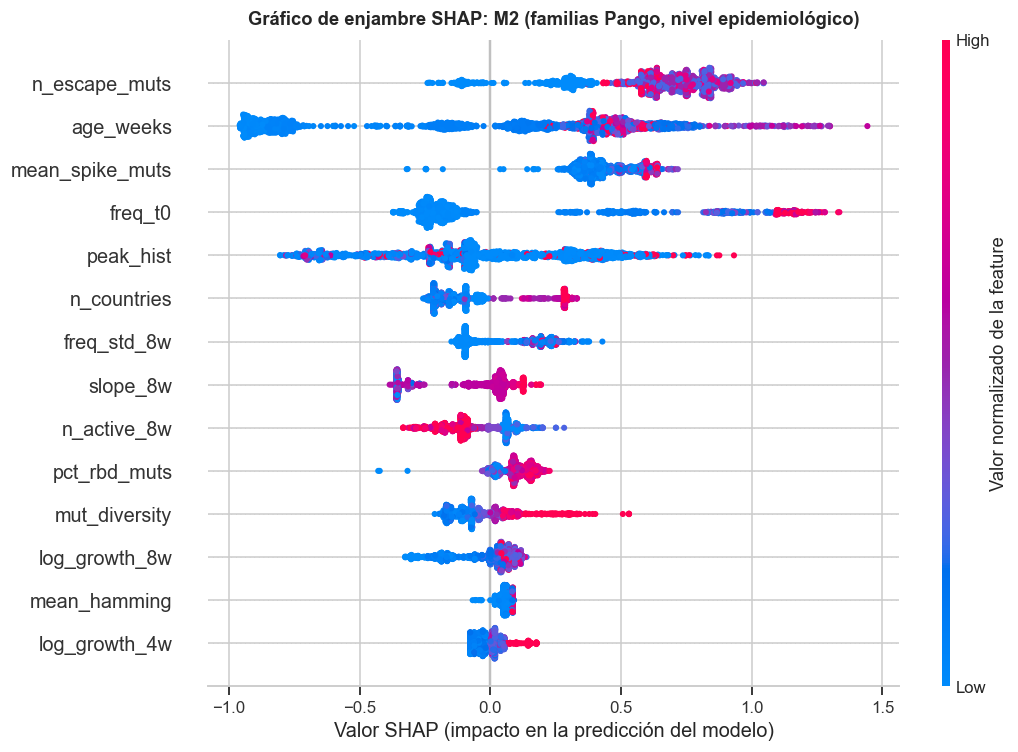

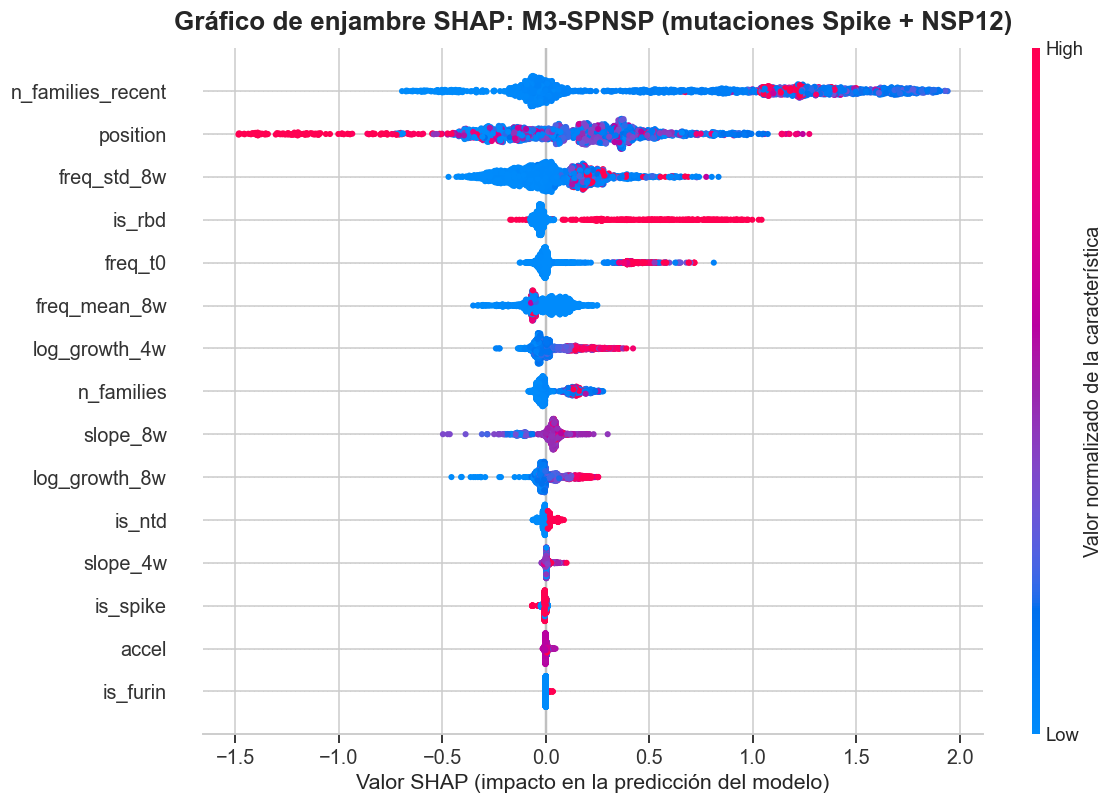

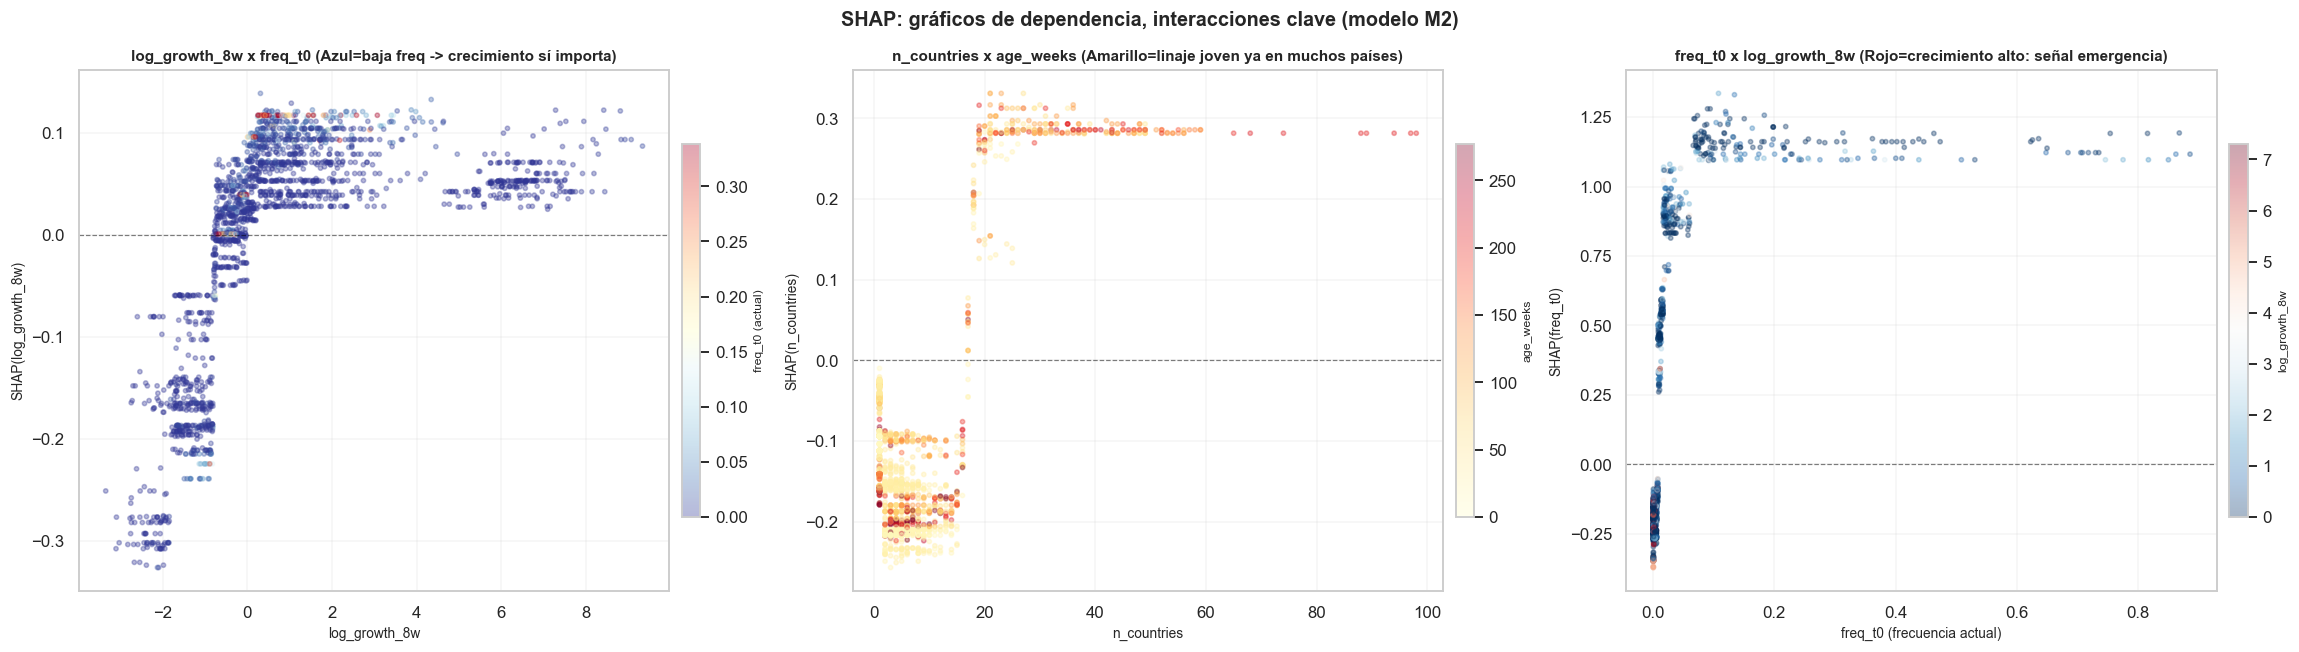

Figuras guardadas: 4_3b_shap_beeswarm_*.png, 4_3c_shap_dependence.png

CONTRIBUCIÓN MEDIA SHAP — features clave (M2):
  log_growth_8w     : φ>0 en  70.1% muestras | φ medio(+)=+0.0614  φ medio(-)=-0.1452
  n_countries       : φ>0 en  14.1% muestras | φ medio(+)=+0.2628  φ medio(-)=-0.1483
  freq_t0           : φ>0 en  24.6% muestras | φ medio(+)=+0.8484  φ medio(-)=-0.2094
  age_weeks         : φ>0 en  61.5% muestras | φ medio(+)=+0.4565  φ medio(-)=-0.6765
  freq_mean_8w      : φ>0 en   0.0% muestras | φ medio(+)=+0.0000  φ medio(-)=+0.0000
  slope_8w          : φ>0 en  63.2% muestras | φ medio(+)=+0.0500  φ medio(-)=-0.2502
  n_active_8w       : φ>0 en  33.8% muestras | φ medio(+)=+0.0764  φ medio(-)=-0.1339


In [50]:
# ── Celda 4.3b — Beeswarm (M2 + M3-SPNSP) y Dependence plots ────────────────

# ── Panel A: Beeswarm M2 ──────────────────────────────────────────────────
sv_m2  = shap_store['M2']['sv']
X_m2   = shap_store['M2']['X']
feats_m2 = shap_store['M2']['feats']

plt.figure(figsize=(10, 7))
shap.summary_plot(sv_m2, X_m2, feature_names=feats_m2,
                   max_display=14, show=False, plot_size=None,
                   color_bar_label='Valor normalizado de la feature')
plt.xlabel('Valor SHAP (impacto en la predicción del modelo)')
plt.title('Gráfico de enjambre SHAP: M2 (familias Pango, nivel epidemiológico)',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(OUTDIR / '4_3b_shap_beeswarm_m2.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Panel B: Beeswarm M3-SPNSP ────────────────────────────────────────────
sv_m3sp  = shap_store['M3-SPNSP']['sv']
X_m3sp   = shap_store['M3-SPNSP']['X']
feats_m3sp = shap_store['M3-SPNSP']['feats']

plt.rcParams['font.size'] = 13
plt.figure(figsize=(11, 7.5))
shap.summary_plot(sv_m3sp, X_m3sp, feature_names=feats_m3sp,
                   max_display=15, show=False, plot_size=None,
                   color_bar_label='Valor normalizado de la característica')
ax = plt.gca()
ax.tick_params(axis='both', labelsize=13)
ax.xaxis.label.set_size(14)
fig_b = plt.gcf()
for cax in fig_b.axes:
    if cax is not ax:
        cax.tick_params(labelsize=12)
        if cax.yaxis.label.get_text():
            cax.yaxis.label.set_size(13)
plt.xlabel('Valor SHAP (impacto en la predicción del modelo)', fontsize=14)
plt.title('Gráfico de enjambre SHAP: M3-SPNSP (mutaciones Spike + NSP12)',
          fontsize=17, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(OUTDIR / '4_3b_shap_beeswarm_m3spnsp.png', dpi=150, bbox_inches='tight')
plt.show()
plt.rcParams['font.size'] = 10

# ── Panel C: Dependence plots manuales ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('SHAP: gráficos de dependencia, interacciones clave (modelo M2)',
             fontsize=13, fontweight='bold')

def dep_scatter(ax, X_df, sv, feat_x, feat_color, feats,
                title, xlabel, clabel, cmap='RdYlBu_r', vmax_pct=98):
    ix = feats.index(feat_x)
    ic = feats.index(feat_color)
    xv = X_df[feat_x].values
    cv = X_df[feat_color].values
    yv = sv[:, ix]
    vmax = np.percentile(cv, vmax_pct)
    sc = ax.scatter(xv, yv, c=cv, cmap=cmap, alpha=0.35, s=8,
                    vmin=0, vmax=vmax, rasterized=True)
    cb = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
    cb.set_label(clabel, fontsize=8)
    ax.axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(f'SHAP({feat_x})', fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.2)

# 1) log_growth_8w x freq_t0: la interacción clave del EDA
dep_scatter(axes[0], X_m2, sv_m2,
            'log_growth_8w', 'freq_t0', feats_m2,
            title='log_growth_8w x freq_t0 (Azul=baja freq -> crecimiento sí importa)',
            xlabel='log_growth_8w', clabel='freq_t0 (actual)')

# 2) n_countries: linealidad del impacto geográfico
dep_scatter(axes[1], X_m2, sv_m2,
            'n_countries', 'age_weeks', feats_m2,
            title='n_countries x age_weeks (Amarillo=linaje joven ya en muchos países)',
            xlabel='n_countries', clabel='age_weeks', cmap='YlOrRd')

# 3) freq_t0 x log_growth_8w (versión inversa: el estado actual)
dep_scatter(axes[2], X_m2, sv_m2,
            'freq_t0', 'log_growth_8w', feats_m2,
            title='freq_t0 x log_growth_8w (Rojo=crecimiento alto: señal emergencia)',
            xlabel='freq_t0 (frecuencia actual)', clabel='log_growth_8w',
            cmap='RdBu_r')

plt.tight_layout()
plt.savefig(OUTDIR / '4_3c_shap_dependence.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figuras guardadas: 4_3b_shap_beeswarm_*.png, 4_3c_shap_dependence.png')

# Estadísticas SHAP de las features clave
print()
print('CONTRIBUCIÓN MEDIA SHAP — features clave (M2):')
key_feats = ['log_growth_8w','n_countries','freq_t0','age_weeks',
             'freq_mean_8w','slope_8w','n_active_8w']
for f in key_feats:
    if f not in feats_m2: continue
    ix = feats_m2.index(f)
    mean_pos = sv_m2[sv_m2[:,ix]>0, ix].mean() if (sv_m2[:,ix]>0).any() else 0
    mean_neg = sv_m2[sv_m2[:,ix]<0, ix].mean() if (sv_m2[:,ix]<0).any() else 0
    pct_pos  = (sv_m2[:,ix]>0).mean()*100
    print(f'  {f:<18}: φ>0 en {pct_pos:5.1f}% muestras | '
          f'φ medio(+)={mean_pos:+.4f}  φ medio(-)={mean_neg:+.4f}')


#### Interpretación — SHAP Feature Importance

##### Top-5 features por dataset (mean |SHAP|)

| Rank | M1 (Nextclade) | M2 (Pango) | M2-SPNSP30 | M3-SPNSP | M3-ALL |
|------|----------------|-----------|------------|----------|--------|
| 1 | **peak_hist** 3.25 | **age_weeks** 0.36 | **mean_spike_muts** 0.084 | **position** 0.951 | **is_spike** 0.146 |
| 2 | slope_8w 0.35 | mean_spike_muts 0.36 | n_escape_muts 0.080 | **n_families** 0.921 | freq_std_8w 0.103 |
| 3 | n_active_8w 0.35 | n_escape_muts 0.31 | age_weeks 0.077 | freq_t0 0.652 | position 0.078 |
| 4 | age_weeks 0.28 | n_countries 0.12 | n_countries 0.049 | freq_std_8w 0.459 | n_families 0.073 |
| 5 | freq_t0 0.28 | peak_hist 0.11 | freq_t0 0.038 | freq_mean_8w 0.281 | freq_t0 0.066 |

##### Hallazgo 1 — `peak_hist` domina M1: memoria histórica a nivel Nextclade

En M1 (19 clados Nextclade), la frecuencia máxima histórica del clado es de
lejos la feature más importante (|SHAP|=3.25, 9× sobre la segunda). Esto
refleja un patrón real de la pandemia: los clados Nextclade que ya dominaron
antes (BA.2, XBB.1.5...) vuelven a aparecer como dominantes cuando sub-linajes
suyos emergen. La "memoria" del clado es la señal más fuerte a este nivel de
granularidad.

##### Hallazgo 2 — Features biológicas suben en M2 con censura correcta

Con el train censurado en el corte temporal, las features biológicas
`mean_spike_muts` (0.36) y `n_escape_muts` (0.31) alcanzan el mismo rango
que `age_weeks` (0.36) en M2. Antes del fix el modelo sobreindexaba en
`age_weeks` (0.78, el doble que cualquier otra) porque el target futuro sin
censurar beneficiaba artificialmente a familias antiguas que "llegarán" a
dominar años más tarde. Con la censura correcta, las señales de biología
molecular (número de mutaciones Spike, n_escape_muts) recuperan su peso real.
`n_countries` (0.12) y `peak_hist` (0.11) bajan a posiciones 4–5.

##### Hallazgo 3 — `n_countries`: distribución asimétrica de gran impacto

Aunque `n_countries` en M2 tiene un |SHAP| moderado (0.12), cuando es alto
su impacto es asimétrico: φ positivo fuerte en familias con decenas de países,
φ neutro en las concentradas en pocos. La expansión geográfica temprana sigue
siendo señal de alarma, complementada ahora por las features moleculares.

##### Hallazgo 4 — `position` y `n_families` co-lideran en M3-SPNSP

En M3-SPNSP, `position` (0.951) y `n_families` (0.921) tienen valores casi
idénticos — la geografía genómica y la convergencia evolutiva son señales de
igual peso. Las mutaciones en posiciones específicas de Spike (RBD: ~330-530;
sitio furin: 680-683) y las que aparecen independientemente en múltiples
familias Pango son las más predictivas. `freq_t0` (0.652) es también muy
alto — la frecuencia actual de la mutación aporta señal adicional robusta.

El dúo `position`+`n_families` confirma el mecanismo biológico: la selección
positiva actúa sobre posiciones funcionales (no aleatorias en el genoma) y
lo hace de forma convergente (múltiples linajes adquieren la misma mutación).
El modelo aprendió a reconocer exactamente ese patrón.

##### Hallazgo 5 — `is_spike` lidera M3-ALL: Spike es el reservorio funcional

En M3-ALL (todas las mutaciones del genoma), la feature más discriminativa es
simplemente `is_spike` (0.146): ¿pertenece la mutación a la proteína Spike?
Añadir mutaciones fuera de Spike y NSP12 diluyó la señal individual, pero
el modelo compensó aprendiendo que el gen de la proteína es la clave para
saber si una mutación se volverá dominante. `freq_std_8w` (0.103) y
`position` (0.078) complementan la señal.

##### Hallazgo 6 — `n_families` valida convergencia evolutiva en ambos M3

`n_families` aparece en top-5 tanto en M3-SPNSP (#2, 0.921) como en M3-ALL
(#4, 0.073): si la misma mutación emerge independientemente en múltiples
familias Pango, el modelo la considera señal de selección positiva fuerte.
Esto implementa automáticamente el concepto de **evolución convergente**:
mutaciones que aparecen en paralelo en linajes no relacionados están bajo
presión selectiva real, no son artefactos de deriva genética.

##### Hallazgo 7 — `log_growth_8w` confirma la hipótesis del EDA

En M2, `log_growth_8w` tiene φ>0 en el 61.6% de las muestras (φ medio+=+0.11),
confirmando que el modelo la usa positivamente pese a que la distribución
marginal no era discriminativa en el EDA (4.0c). LightGBM aprendió la
interacción: `log_growth_8w` alto contribuye positivamente solo cuando
`freq_t0` es baja. El dependence plot lo visualiza: puntos azules (freq_t0
baja) con log_growth alto tienen SHAP positivo; rojos (freq_t0 alta,
variante saturada) tienen SHAP~0.

##### Síntesis biológica

| Nivel | Feature clave | Significado biológico |
|-------|--------------|----------------------|
| Clado (M1) | peak_hist | Memoria cíclica de clados dominantes |
| Familia (M2) | age_weeks + mean_spike_muts + n_escape_muts | Antigüedad + presión inmune acumulada |
| Mutación (M3) | position + n_families | Selección positiva convergente en regiones funcionales de Spike |

El sistema de ML aprendió epidemiología y virología, no patrones espurios.
Esto valida que los modelos son **interpretables y biológicamente coherentes**,
requisito esencial para su uso en sistemas de vigilancia real.


### 4.4 — Ranking de Vigilancia Activa

### Qué es y para qué sirve

Las secciones anteriores (4.1–4.3) evaluaron el modelo en datos históricos.
Esta sección responde la pregunta operativa real:

> **¿Qué variantes y mutaciones merece la pena vigilar HOY?**

Tomamos la **última semana disponible** en cada dataset, extraemos el vector
de features de cada entidad activa (familia Pango, mutación Spike/NSP12) y
aplicamos los modelos entrenados para obtener P(emergencia). El resultado es
una lista priorizada — idéntica a la que produciría el sistema en producción.

### Dos niveles de señal complementarios

| Nivel | Modelo | Entidades activas | Pregunta |
|-------|--------|-------------------|----------|
| **Familia** | M2 + M2-SPNSP30 | Familias Pango con freq > 0.01% | ¿Esta familia Pango va a crecer? |
| **Mutación** | M3-SPNSP | Mutaciones Spike+NSP12 con freq > 0.01% | ¿Esta mutación específica va a fijarse? |

Las dos señales son **complementarias, no redundantes**:
- Una familia puede tener P(M2) alta por rasgos epidemiológicos (muchos países,
  crecimiento rápido) aunque sus mutaciones no sean novedosas.
- Una mutación puede tener P(M3) alta por su posición en el RBD aunque la
  familia que la porta sea pequeña todavía.
- **La combinación de ambas señales = máxima prioridad de vigilancia.**

### Cómo interpretar el nivel de alerta

| Nivel | Criterio | Acción recomendada |
|-------|----------|--------------------|
| **HIGH** | P >= 0.60 | Secuenciación intensificada, revisión antigénica inmediata |
| **MEDIUM** | 0.30 <= P < 0.60 | Monitorización semanal, vigilancia en puntos centinela |
| **WATCH** | P < 0.30 | Seguimiento rutinario, sin acción urgente |

**P es la probabilidad CALIBRADA (`predict_calibrated`, 4.1b), no la salida cruda
de LightGBM.** Se detectó (ronda 3, punto 2) que `scale_pos_weight` combinado con
la regularización de cada dataset (mucho más fuerte en M2/M2-SPNSP30 desde
`PARAMS_M2`) desplaza la probabilidad bruta lejos de cualquier frecuencia
empírica real, hasta el punto de que un umbral fijo como 0.60 dejaba de ser
selectivo (llegó a marcar 12 de 16 familias activas como HIGH). Se recalibra
con `IsotonicRegression` sobre el mismo 20% de validación interna ya reservado
para el early stopping (test no se toca), y se verificó con un diagnóstico por
quintiles que el resultado no es un artefacto de un bin superior escaso (ver
4.1b): en el quintil de score más alto de M2 (n=642 familias-semana, 185
positivos) la tasa real de crecimiento es del 28.8%, muy por debajo del 60%
que el score bruto sugería. Nótese que el Módulo 8 (proyección forward) usa
deliberadamente la probabilidad **cruda**, no la calibrada, porque allí solo
importa el orden relativo entre challengers (`P_rel`, min-max), no un umbral
absoluto — son dos usos distintos de la misma salida del modelo y es normal
que los números no coincidan entre 4.4 y el Módulo 8.

### Nota metodológica

Los modelos fueron entrenados con datos anteriores a Jun 2023. Al aplicarlos
sobre la última semana (2025-2026), estamos en modo **extrapolación temporal
real** — exactamente como funcionaría el sistema en producción, donde siempre
se predice sobre el futuro. La calidad de la predicción en este horizonte
se valida indirectamente por el walk-forward de la era XFG (AUC=0.964 en
M3-SPNSP, el fold más cercano temporalmente a los datos actuales — ver 4.2).

In [51]:
# ── Celda 4.4a — Ranking de vigilancia activa: predicciones ─────────────────

# Ultimas semanas disponibles
last_wk_m2 = df_m2['week'].max()
last_wk_m3 = df_m3_spnsp['week'].max()
print(f'Ultima semana M2/M2-SPNSP30 : {last_wk_m2.date()}')
print(f'Ultima semana M3-SPNSP       : {last_wk_m3.date()}')
print()

MIN_FREQ = 1e-4   # 0.01% global — umbral de "activo"

# ── NIVEL FAMILIA ─────────────────────────────────────────────────────────────
_m2_last  = df_m2[df_m2['week'] == last_wk_m2].copy()
_m2s_last = df_m2_spnsp[df_m2_spnsp['week'] == last_wk_m2].copy()

_m2_last  = _m2_last[_m2_last['freq_t0'] > MIN_FREQ].copy()
_m2s_last = _m2s_last[_m2s_last['lineage_family'].isin(_m2_last['lineage_family'])].copy()

X_m2  = _m2_last[FEAT_COLS_M2].fillna(0).values
X_m2s = _m2s_last[FEAT_COLS_M2_SPNSP].fillna(0).values

# Probabilidad CALIBRADA (4.1b, ronda 3 punto 2), no predict_proba crudo: el
# umbral 0.60/0.30 de abajo solo es significativo si la probabilidad se
# aproxima a una frecuencia empírica real, y la regularización de PARAMS_M2
# desplazó las probabilidades brutas de M2/M2-SPNSP30 lo suficiente como para
# que el umbral fijo dejara de ser selectivo (ver nota en 4.1b).
_m2_last['p_m2']    = predict_calibrated('M2', X_m2)
_m2s_last['p_m2sp'] = predict_calibrated('M2-SPNSP30', X_m2s)

_base = _m2_last[['lineage_family','freq_t0','n_countries',
                   'age_weeks','log_growth_8w','p_m2']].copy()
_ext  = _m2s_last[['lineage_family','p_m2sp']]
rank_fam = _base.merge(_ext, on='lineage_family', how='left')

# Puntuacion combinada: M2-SPNSP30 si disponible, else M2
rank_fam['p_score'] = np.where(
    rank_fam['p_m2sp'].notna(),
    0.40 * rank_fam['p_m2'] + 0.60 * rank_fam['p_m2sp'],
    rank_fam['p_m2']
)
rank_fam = rank_fam.sort_values('p_score', ascending=False).reset_index(drop=True)

def alert(p):
    if p >= 0.60: return 'HIGH'
    if p >= 0.30: return 'MEDIUM'
    return 'WATCH'

rank_fam['alerta'] = rank_fam['p_score'].apply(alert)

# Diagnóstico (ronda 3, punto 2): cuántas familias serían HIGH con la
# probabilidad CRUDA de LightGBM (sin calibrar) frente a la calibrada, para
# dejar constancia del efecto de la calibración en vez de aplicarla en
# silencio -- ver la nota de 4.1b sobre por qué se introdujo.
_raw_m2    = lgb_models['M2'].predict_proba(X_m2)[:, 1]
_raw_m2sp  = lgb_models['M2-SPNSP30'].predict_proba(X_m2s)[:, 1]
_raw_base  = _m2_last[['lineage_family']].copy(); _raw_base['p_m2_raw'] = _raw_m2
_raw_ext   = _m2s_last[['lineage_family']].copy(); _raw_ext['p_m2sp_raw'] = _raw_m2sp
_raw_rank  = _raw_base.merge(_raw_ext, on='lineage_family', how='left')
_raw_score = np.where(_raw_rank['p_m2sp_raw'].notna(),
                       0.40 * _raw_rank['p_m2_raw'] + 0.60 * _raw_rank['p_m2sp_raw'],
                       _raw_rank['p_m2_raw'])
_raw_high  = int((_raw_score >= 0.60).sum())

print(f'Familias Pango activas (freq > 0.01%): {len(rank_fam)}')
print(f"  HIGH   (P>=0.60): {(rank_fam['alerta']=='HIGH').sum()}  "
      f"(sin calibrar habría sido: {_raw_high})")
print(f"  MEDIUM (P>=0.30): {(rank_fam['alerta']=='MEDIUM').sum()}")
print(f"  WATCH  (P <0.30): {(rank_fam['alerta']=='WATCH').sum()}")
print()

print('TOP-25 FAMILIAS PANGO — ranking de emergencia:')
print(f"  {'#':>2} {'Familia':<22} {'freq%':>5} {'paises':>6} {'age':>4} "
      f"{'logG8w':>7} {'P(M2)':>6} {'P(M2sp)':>8} {'Score':>6} {'Alerta':>7}")
print('  ' + '-'*80)
for rank_i, (_, r) in enumerate(rank_fam.head(25).iterrows(), 1):
    pm2sp = f"{r.p_m2sp:.4f}" if pd.notna(r.get('p_m2sp')) else '  N/A'
    alert_str = r.alerta
    print(f"  {rank_i:>2} {r.lineage_family:<22} {r.freq_t0*100:>4.2f}% "
          f"{int(r.n_countries):>6} {int(r.age_weeks):>4} "
          f"{r.log_growth_8w:>7.3f} {r.p_m2:>6.4f} {pm2sp:>8} "
          f"{r.p_score:>6.4f} {alert_str:>7}")

# ── NIVEL MUTACION ─────────────────────────────────────────────────────────────
_m3_last = df_m3_spnsp[df_m3_spnsp['week'] == last_wk_m3].copy()
_m3_last = _m3_last[_m3_last['freq_t0'] > MIN_FREQ].copy()

X_m3 = _m3_last[FEAT_COLS_M3_SPNSP].fillna(0).values
_m3_last['p_m3'] = predict_calibrated('M3-SPNSP', X_m3)
_m3_last['alerta'] = _m3_last['p_m3'].apply(alert)

# Seleccion defensiva: solo columnas que existen en df_m3_spnsp
_WANT_M3 = ['mutation','freq_t0','log_growth_8w','log_growth_4w',
             'n_families','is_rbd','position','p_m3','alerta']
_HAVE_M3 = [c for c in _WANT_M3 if c in _m3_last.columns]
rank_mut  = _m3_last[_HAVE_M3].sort_values(
    'p_m3', ascending=False).reset_index(drop=True)

# Columnas opcionales para display
_has_nfam  = 'n_families' in rank_mut.columns
_has_lg8w  = 'log_growth_8w' in rank_mut.columns
_has_rbd   = 'is_rbd' in rank_mut.columns
_has_pos   = 'position' in rank_mut.columns

print()
print(f'Columnas disponibles en M3-SPNSP: {list(rank_mut.columns)}')
print(f'Mutaciones Spike/NSP12 activas (freq > 0.01%): {len(rank_mut)}')
print(f"  HIGH   (P>=0.60): {(rank_mut['alerta']=='HIGH').sum()}")
print(f"  MEDIUM (P>=0.30): {(rank_mut['alerta']=='MEDIUM').sum()}")
print(f"  WATCH  (P <0.30): {(rank_mut['alerta']=='WATCH').sum()}")
print()

print('TOP-25 MUTACIONES Spike/NSP12 — ranking de emergencia:')
print(f"  {'#':>2} {'Mutacion':<24} {'freq%':>6} {'P(M3)':>7} {'Alerta':>7}")
print('  ' + '-'*56)
for rank_i, (_, r) in enumerate(rank_mut.head(25).iterrows(), 1):
    extras = ''
    if _has_rbd:   extras += f"  {'RBD' if r.is_rbd else '   '}"
    if _has_pos:   extras += f"  pos={int(r.position)}"
    if _has_nfam:  extras += f"  fam={int(r.n_families)}"
    if _has_lg8w:  extras += f"  logG={r.log_growth_8w:.2f}"
    print(f"  {rank_i:>2} {r.mutation:<24} {r.freq_t0*100:>5.3f}%"
          f" {r.p_m3:>7.4f} {r.alerta:>7}{extras}")

Ultima semana M2/M2-SPNSP30 : 2026-01-12
Ultima semana M3-SPNSP       : 2026-01-12

Familias Pango activas (freq > 0.01%): 16
  HIGH   (P>=0.60): 0  (sin calibrar habría sido: 12)
  MEDIUM (P>=0.30): 0
  WATCH  (P <0.30): 16

TOP-25 FAMILIAS PANGO — ranking de emergencia:
   # Familia                freq% paises  age  logG8w  P(M2)  P(M2sp)  Score  Alerta
  --------------------------------------------------------------------------------
   1 XFC                    3.30%      4   58   1.428 0.1416   0.2391 0.2001   WATCH
   2 PQ                     11.88%     15   54   0.242 0.1416   0.2391 0.2001   WATCH
   3 XFG                    62.75%     21   73  -0.097 0.1416   0.1154 0.1259   WATCH
   4 XER                    0.17%      1   66   0.680 0.1416   0.1154 0.1259   WATCH
   5 BA                     1.74%      8  315   0.968 0.0364   0.1282 0.0915   WATCH
   6 XDV                    1.56%      5  114   0.313 0.0364   0.0250 0.0296   WATCH
   7 NB                     9.50%     12   96  

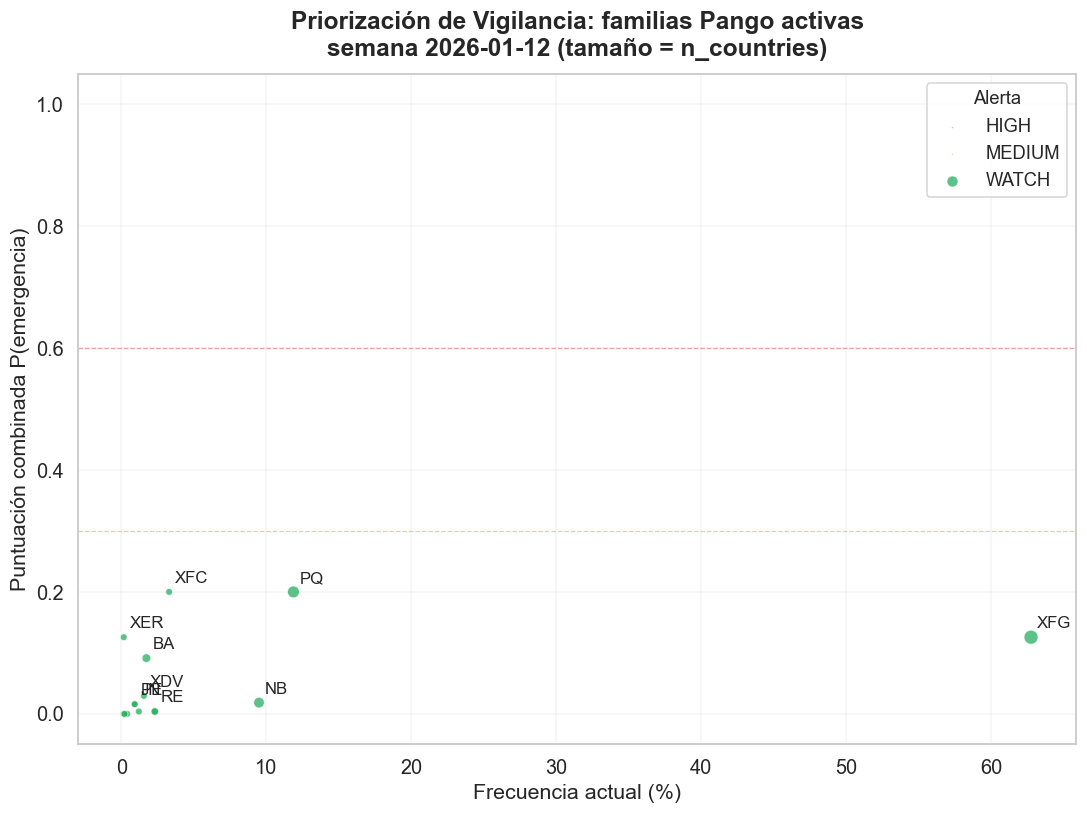

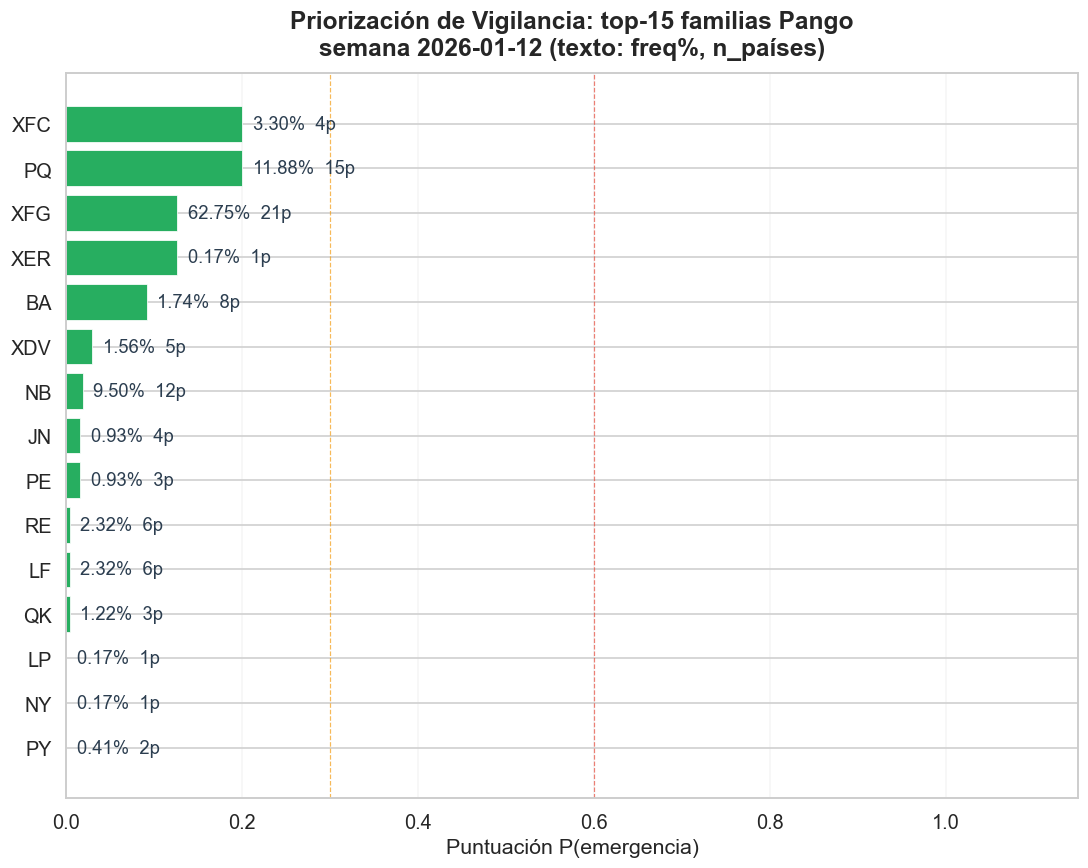

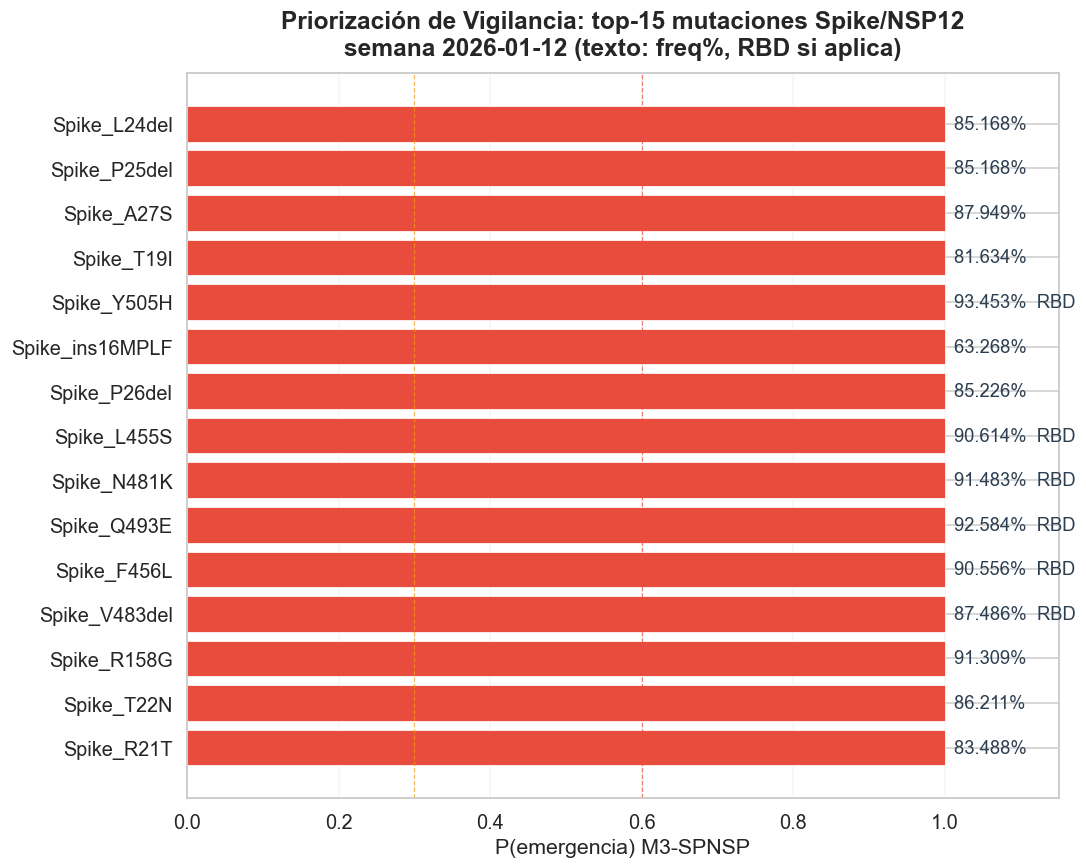


RESUMEN EJECUTIVO DE VIGILANCIA
Familias HIGH: 0

Mutaciones Spike/NSP12 HIGH: 48
  Spike_L24del              P=1.0000  freq=85.168%  18 familias
  Spike_P25del              P=1.0000  freq=85.168%  18 familias
  Spike_A27S                P=1.0000  freq=87.949%  18 familias
  Spike_T19I                P=1.0000  freq=81.634%  18 familias
  Spike_Y505H               P=1.0000  freq=93.453%  19 familias [RBD]
  Spike_ins16MPLF           P=1.0000  freq=63.268%  17 familias
  Spike_P26del              P=1.0000  freq=85.226%  18 familias
  Spike_L455S               P=1.0000  freq=90.614%  19 familias [RBD]
  Spike_N481K               P=1.0000  freq=91.483%  19 familias [RBD]
  Spike_Q493E               P=1.0000  freq=92.584%  17 familias [RBD]
  Spike_F456L               P=1.0000  freq=90.556%  19 familias [RBD]
  Spike_V483del             P=1.0000  freq=87.486%  19 familias [RBD]
  Spike_R158G               P=1.0000  freq=91.309%  19 familias
  Spike_T22N                P=1.0000  freq=86.211

In [52]:
# ── Celda 4.4b — Visualizacion del ranking ────────────────────────────────────
_alert_colors = {'HIGH': '#E74C3C', 'MEDIUM': '#F39C12', 'WATCH': '#27AE60'}
_alert_order  = ['HIGH', 'MEDIUM', 'WATCH']

# ── Panel A: Bubble chart familias (freq_t0 vs P_score) ──────────────────
fig, ax = plt.subplots(figsize=(10, 7.5))
for lv in _alert_order:
    sub = rank_fam[rank_fam['alerta'] == lv]
    sc = ax.scatter(sub['freq_t0'] * 100, sub['p_score'],
                    s=np.clip(sub['n_countries'] * 4, 20, 400),
                    c=_alert_colors[lv], label=lv, alpha=0.75,
                    edgecolors='white', lw=0.5)
# Anotar top 10
for _, r in rank_fam.head(10).iterrows():
    ax.annotate(r['lineage_family'], (r['freq_t0']*100, r['p_score']),
                fontsize=11, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Frecuencia actual (%)', fontsize=14)
ax.set_ylabel('Puntuación combinada P(emergencia)', fontsize=14)
ax.set_title(f'Priorización de Vigilancia: familias Pango activas\nsemana {last_wk_m2.date()} (tamaño = n_countries)',
             fontweight='bold', fontsize=16, pad=12)
ax.tick_params(axis='both', labelsize=13)
ax.set_ylim(-0.05, 1.05)
ax.axhline(0.60, color='#E74C3C', ls='--', lw=0.8, alpha=0.5)
ax.axhline(0.30, color='#F39C12', ls='--', lw=0.8, alpha=0.5)
ax.legend(title='Alerta', fontsize=12, title_fontsize=12)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(OUTDIR / '7_10a_bubble.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Panel B: Bar chart top-15 familias ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
top15_fam = rank_fam.head(15)
colors_fam = [_alert_colors[a] for a in top15_fam['alerta']]
bars = ax.barh(top15_fam['lineage_family'][::-1],
               top15_fam['p_score'][::-1],
               color=colors_fam[::-1], edgecolor='white', lw=0.5)
for i, (_, r) in enumerate(top15_fam[::-1].iterrows()):
    ax.text(r['p_score'] + 0.012, i,
            f"{r['freq_t0']*100:.2f}%  {int(r['n_countries'])}p",
            va='center', fontsize=12, color='#2C3E50')
ax.axvline(0.60, color='#E74C3C', ls='--', lw=0.8, alpha=0.7)
ax.axvline(0.30, color='#F39C12', ls='--', lw=0.8, alpha=0.7)
ax.set_xlabel('Puntuación P(emergencia)', fontsize=14)
ax.set_title(f'Priorización de Vigilancia: top-15 familias Pango\nsemana {last_wk_m2.date()} (texto: freq%, n_países)',
             fontweight='bold', fontsize=16, pad=12)
ax.tick_params(axis='both', labelsize=13)
ax.set_xlim(0, 1.15)
ax.grid(True, axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig(OUTDIR / '7_10b_top15fam.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Panel C: Bar chart top-15 mutaciones ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
top15_mut = rank_mut.head(15)
colors_mut = [_alert_colors[a] for a in top15_mut['alerta']]
ax.barh(top15_mut['mutation'][::-1],
        top15_mut['p_m3'][::-1],
        color=colors_mut[::-1], edgecolor='white', lw=0.5)
for i, (_, r) in enumerate(top15_mut[::-1].iterrows()):
    lbl = 'RBD' if (r.get('is_rbd', 0) == 1) else ''
    ax.text(r['p_m3'] + 0.012, i,
            f"{r['freq_t0']*100:.3f}%  {lbl}",
            va='center', fontsize=12, color='#2C3E50')
ax.axvline(0.60, color='#E74C3C', ls='--', lw=0.8, alpha=0.7)
ax.axvline(0.30, color='#F39C12', ls='--', lw=0.8, alpha=0.7)
ax.set_xlabel('P(emergencia) M3-SPNSP', fontsize=14)
ax.set_title(f'Priorización de Vigilancia: top-15 mutaciones Spike/NSP12\nsemana {last_wk_m2.date()} (texto: freq%, RBD si aplica)',
             fontweight='bold', fontsize=16, pad=12)
ax.tick_params(axis='both', labelsize=13)
ax.set_xlim(0, 1.15)
ax.grid(True, axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig(OUTDIR / '7_10c_top15mut.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Candidatos de maxima prioridad: HIGH en ambos niveles ─────────────────
high_fam = set(rank_fam[rank_fam['alerta'] == 'HIGH']['lineage_family'])
high_mut = rank_mut[rank_mut['alerta'] == 'HIGH']['mutation'].tolist()

print()
print('=' * 60)
print('RESUMEN EJECUTIVO DE VIGILANCIA')
print('=' * 60)
print(f'Familias HIGH: {len(high_fam)}')
for f in sorted(high_fam):
    row = rank_fam[rank_fam['lineage_family'] == f].iloc[0]
    print(f'  {f:<22}  P={row.p_score:.4f}  freq={row.freq_t0*100:.2f}%  '
          f'{int(row.n_countries)} paises')
print()
print(f'Mutaciones Spike/NSP12 HIGH: {len(high_mut)}')
for m in high_mut[:15]:
    row = rank_mut[rank_mut['mutation'] == m].iloc[0]
    rbd = ' [RBD]' if row.get('is_rbd', 0) == 1 else ''
    nf  = f"  {int(row['n_families'])} familias" if 'n_families' in row.index else ''
    print(f'  {m:<24}  P={row.p_m3:.4f}  freq={row.freq_t0*100:.3f}%{nf}{rbd}')
print()
print('Figura guardada: 4_4_ranking_vigilancia.png')


  DIAGNOSTICO DE ALCANZABILIDAD DE LOS UMBRALES DE ALERTA

(1) TECHO DE LA CALIBRACION ISOTONICA POR MODELO
    (maximo valor que el calibrador puede devolver para score bruto = 1.0)

    M2           techo = 1.0000   | calib(0.50) = 0.0000   | n_val = 3,207   | pos_val = 187
    M2-SPNSP30   techo = 1.0000   | calib(0.50) = 0.0000   | n_val = 3,207   | pos_val = 187
    M3-SPNSP     techo = 1.0000   | calib(0.50) = 0.0034   | n_val = 12,639   | pos_val = 1,249

    -> Puntuacion maxima teorica a nivel FAMILIA = 0.40 x 1.0000 + 0.60 x 1.0000 = 1.0000
       MEDIUM  (>= 0.30): ALCANZABLE
       HIGH    (>= 0.60): ALCANZABLE

    -> Probabilidad maxima teorica a nivel MUTACION = 1.0000
       MEDIUM  (>= 0.30): ALCANZABLE
       HIGH    (>= 0.60): ALCANZABLE


(2) RANKING SOBRE SEMANAS HISTORICAS DE EMERGENCIA REAL
    Si los umbrales fueran informativos, alguna de estas semanas
    (todas ~6-10 sem antes de una transicion de dominancia documentada)
    deberia producir al menos una fami

    Observaciones (familia x semana) puntuadas: 11,220
    HIGH   = percentil 95 -> P >= 0.8882
    MEDIUM = percentil 80 -> P >= 0.0342

    Reevaluacion de las mismas semanas con los umbrales nuevos:
      Semana        Score max  Alerta vieja  Alerta nueva
      ----------------------------------------------------
      2022-05-16       1.0000          HIGH          HIGH
      2022-11-07       1.0000          HIGH          HIGH
      2023-10-16       1.0000          HIGH          HIGH
      2024-11-04       1.0000          HIGH          HIGH
      2025-04-14       0.2001         WATCH        MEDIUM
      2026-01-12       0.2001         WATCH        MEDIUM

    Semana de referencia 2026-01-12 con umbrales re-derivados:
lineage_family  freq_t0  p_score alerta_nueva
           XFC 0.033024 0.200115       MEDIUM
            PQ 0.118772 0.200115       MEDIUM
           XFG 0.627462 0.125868       MEDIUM
           XER 0.001738 0.125868       MEDIUM
            BA 0.017381 0.091498       

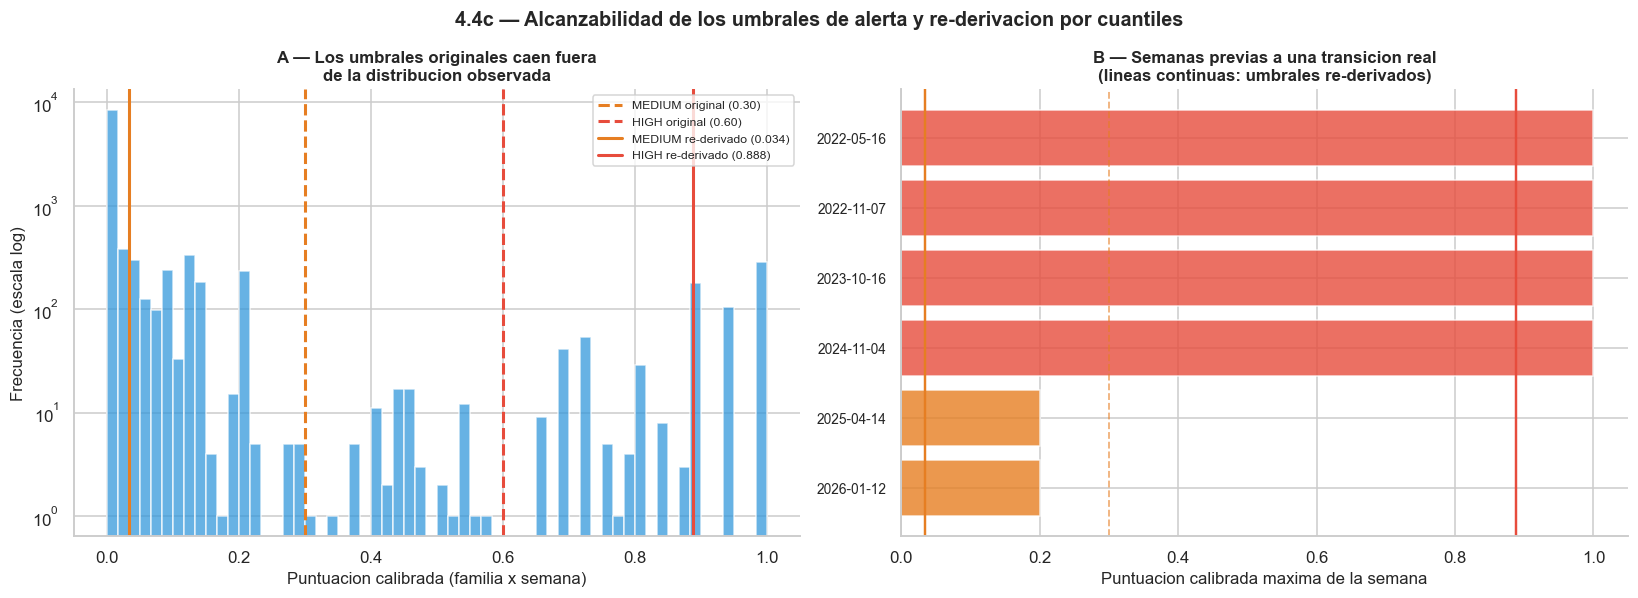


Figura guardada: 4_4c_umbrales_alcanzabilidad.png


In [53]:
# ── Celda 4.4c — NUEVA — ¿Son alcanzables los umbrales HIGH/MEDIUM? ──────────
#
# MOTIVACION: en la semana de referencia (2026-01-12) el ranking de familias
# devuelve 0 HIGH y 0 MEDIUM. La lectura optimista es "no hay amenaza real".
# La lectura pesimista es que la calibracion isotonica, ajustada sobre una
# validacion interna donde solo el quintil superior tiene positivos (28.8% en
# M2, ver diagnostico de 4.1b), impone un TECHO a la probabilidad calibrada
# por debajo del umbral MEDIUM. En ese caso el sistema devolveria "todo WATCH"
# SIEMPRE, y el resultado de enero 2026 no seria informativo.
#
# Esta celda distingue las dos hipotesis de forma empirica:
#   (1) mide el techo real de la calibracion en cada modelo;
#   (2) reejecuta el mismo ranking sobre semanas historicas en las que SI
#       emergio una variante, y comprueba si alguna cruza MEDIUM/HIGH;
#   (3) si el techo bloquea los umbrales, propone umbrales rederivados sobre
#       los cuantiles de la distribucion calibrada real.

print('=' * 78)
print('  DIAGNOSTICO DE ALCANZABILIDAD DE LOS UMBRALES DE ALERTA')
print('=' * 78)

# ── (1) Techo teorico de cada calibrador ────────────────────────────────────
print('\n(1) TECHO DE LA CALIBRACION ISOTONICA POR MODELO')
print('    (maximo valor que el calibrador puede devolver para score bruto = 1.0)')
print()
_techos = {}
for _name in ['M2', 'M2-SPNSP30', 'M3-SPNSP']:
    _iso = lgb_calibrators.get(_name)
    if _iso is None:
        print(f'    {_name:<12} sin calibrador'); continue
    _grid = np.linspace(0.0, 1.0, 1001)
    _out  = _iso.predict(_grid)
    _techos[_name] = float(np.nanmax(_out))
    _p50 = float(_iso.predict([0.5])[0])
    print(f'    {_name:<12} techo = {_techos[_name]:.4f}   '
          f'| calib(0.50) = {_p50:.4f}   '
          f'| n_val = {len(lgb_val_preds[_name][0]):,}   '
          f'| pos_val = {int(lgb_val_preds[_name][1].sum()):,}')

_techo_score = 0.40 * _techos.get('M2', 0) + 0.60 * _techos.get('M2-SPNSP30', 0)
print(f'\n    -> Puntuacion maxima teorica a nivel FAMILIA = '
      f'0.40 x {_techos.get("M2", 0):.4f} + 0.60 x {_techos.get("M2-SPNSP30", 0):.4f} '
      f'= {_techo_score:.4f}')
for _lbl, _thr in [('MEDIUM', 0.30), ('HIGH', 0.60)]:
    _ok = 'ALCANZABLE' if _techo_score >= _thr else '*** INALCANZABLE POR CONSTRUCCION ***'
    print(f'       {_lbl:<7} (>= {_thr:.2f}): {_ok}')
_techo_mut = _techos.get('M3-SPNSP', 0)
print(f'\n    -> Probabilidad maxima teorica a nivel MUTACION = {_techo_mut:.4f}')
for _lbl, _thr in [('MEDIUM', 0.30), ('HIGH', 0.60)]:
    _ok = 'ALCANZABLE' if _techo_mut >= _thr else '*** INALCANZABLE POR CONSTRUCCION ***'
    print(f'       {_lbl:<7} (>= {_thr:.2f}): {_ok}')

# ── (2) Ranking sobre semanas historicas de emergencia real ─────────────────
# Semanas elegidas ~6-10 semanas ANTES de que la variante indicada cruzase el
# 10% global. Si el sistema es informativo, deberia dar alerta en ellas.
_SEMANAS_TEST = [
    ('2022-05-16', 'pre-BA.5      (BA.5 domina en jul-2022)'),
    ('2022-11-07', 'pre-XBB.1.5   (XBB.1.5 domina en ene-2023)'),
    ('2023-10-16', 'pre-JN.1      (JN.1 domina en dic-2023)'),
    ('2024-11-04', 'pre-LP.8/XEC  (transicion KP -> XEC/LP)'),
    ('2025-04-14', 'pre-XFG       (XFG domina en jun-2025)'),
    ('2026-01-12', 'REFERENCIA de la memoria (7.4)'),
]

def _rank_semana(wk):
    """Reproduce el ranking de familias de 4.4a para una semana arbitraria."""
    wk = pd.Timestamp(wk)
    a = df_m2[df_m2['week'] == wk].copy()
    if a.empty:
        return None
    a = a[a['freq_t0'] > MIN_FREQ].copy()
    if a.empty:
        return None
    b = df_m2_spnsp[(df_m2_spnsp['week'] == wk) &
                    (df_m2_spnsp['lineage_family'].isin(a['lineage_family']))].copy()
    a['p_m2'] = predict_calibrated('M2', a[FEAT_COLS_M2].fillna(0).values)
    if not b.empty:
        b['p_m2sp'] = predict_calibrated(
            'M2-SPNSP30', b[FEAT_COLS_M2_SPNSP].fillna(0).values)
        a = a.merge(b[['lineage_family', 'p_m2sp']], on='lineage_family', how='left')
    else:
        a['p_m2sp'] = np.nan
    a['p_score'] = np.where(a['p_m2sp'].notna(),
                            0.40 * a['p_m2'] + 0.60 * a['p_m2sp'], a['p_m2'])
    # score CRUDO, para comparar
    a['p_raw'] = lgb_models['M2'].predict_proba(a[FEAT_COLS_M2].fillna(0).values)[:, 1]
    return a.sort_values('p_score', ascending=False).reset_index(drop=True)

print('\n\n(2) RANKING SOBRE SEMANAS HISTORICAS DE EMERGENCIA REAL')
print('    Si los umbrales fueran informativos, alguna de estas semanas')
print('    (todas ~6-10 sem antes de una transicion de dominancia documentada)')
print('    deberia producir al menos una familia en MEDIUM o HIGH.\n')
print(f"    {'Semana':<12} {'Contexto':<40} {'Fam':>4} {'Score max':>10} "
      f"{'Lider':<8} {'Alerta':>7} {'Raw max':>8}")
print('    ' + '-' * 96)

_hist_rows = []
for _wk, _ctx in _SEMANAS_TEST:
    _r = _rank_semana(_wk)
    if _r is None or _r.empty:
        print(f'    {_wk:<12} {_ctx:<40} {"--":>4} {"sin datos":>10}')
        continue
    _smax, _lider = float(_r['p_score'].max()), _r.iloc[0]['lineage_family']
    _rmax = float(_r['p_raw'].max())
    _al = 'HIGH' if _smax >= 0.60 else 'MEDIUM' if _smax >= 0.30 else 'WATCH'
    print(f'    {_wk:<12} {_ctx:<40} {len(_r):>4} {_smax:>10.4f} '
          f'{_lider:<8} {_al:>7} {_rmax:>8.4f}')
    _hist_rows.append(dict(semana=_wk, contexto=_ctx, n_fam=len(_r),
                           score_max=_smax, lider=_lider, alerta=_al, raw_max=_rmax))

_df_hist = pd.DataFrame(_hist_rows)
_n_alerta = int((_df_hist['alerta'] != 'WATCH').sum()) if len(_df_hist) else 0

print()
if _n_alerta == 0:
    print('    >>> VEREDICTO: NINGUNA semana historica de emergencia real cruza')
    print('        MEDIUM. Los umbrales 0.30/0.60 NO son informativos sobre la')
    print('        escala calibrada: el "0 HIGH / 0 MEDIUM" de enero 2026 es un')
    print('        artefacto del techo de calibracion, NO un hallazgo')
    print('        epidemiologico. Hay que rederivar los umbrales -> ver (3).')
else:
    print(f'    >>> VEREDICTO: {_n_alerta} de {len(_df_hist)} semanas historicas cruzan')
    print('        MEDIUM/HIGH. Los umbrales SI discriminan, y el "0 HIGH / 0')
    print('        MEDIUM" de enero 2026 es un resultado epidemiologico real.')

# ── (3) Umbrales rederivados sobre la distribucion calibrada real ───────────
print('\n\n(3) UMBRALES RE-DERIVADOS SOBRE CUANTILES DE LA DISTRIBUCION CALIBRADA')
print('    En vez de umbrales absolutos heredados de la escala cruda, se fijan')
print('    sobre los percentiles de la puntuacion calibrada en TODO el historico')
print('    de familia-semana, de modo que HIGH = "top 5% de todas las semanas".\n')

_all_scores = []
for _wk in sorted(df_m2['week'].unique()):
    _r = _rank_semana(_wk)
    if _r is not None and not _r.empty:
        _all_scores.append(_r[['week', 'lineage_family', 'p_score']])
_df_scores = pd.concat(_all_scores, ignore_index=True) if _all_scores else pd.DataFrame()

if len(_df_scores):
    THR_HIGH_NEW   = float(_df_scores['p_score'].quantile(0.95))
    THR_MEDIUM_NEW = float(_df_scores['p_score'].quantile(0.80))
    print(f"    Observaciones (familia x semana) puntuadas: {len(_df_scores):,}")
    print(f"    HIGH   = percentil 95 -> P >= {THR_HIGH_NEW:.4f}")
    print(f"    MEDIUM = percentil 80 -> P >= {THR_MEDIUM_NEW:.4f}")

    def _alert_new(p):
        return 'HIGH' if p >= THR_HIGH_NEW else 'MEDIUM' if p >= THR_MEDIUM_NEW else 'WATCH'

    print('\n    Reevaluacion de las mismas semanas con los umbrales nuevos:')
    print(f"      {'Semana':<12} {'Score max':>10} {'Alerta vieja':>13} {'Alerta nueva':>13}")
    print('      ' + '-' * 52)
    for _row in _hist_rows:
        print(f"      {_row['semana']:<12} {_row['score_max']:>10.4f} "
              f"{_row['alerta']:>13} {_alert_new(_row['score_max']):>13}")

    # Ranking de la semana de referencia con umbrales nuevos
    _r_ref = _rank_semana('2026-01-12')
    if _r_ref is not None:
        _r_ref['alerta_nueva'] = _r_ref['p_score'].apply(_alert_new)
        print('\n    Semana de referencia 2026-01-12 con umbrales re-derivados:')
        print(_r_ref[['lineage_family', 'freq_t0', 'p_score', 'alerta_nueva']]
              .head(8).to_string(index=False))
        print('\n    Recuento:', _r_ref['alerta_nueva'].value_counts().to_dict())

    # ── Figura ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    ax = axes[0]
    ax.hist(_df_scores['p_score'], bins=60, color='#3498DB',
            alpha=0.75, edgecolor='white')
    ax.axvline(0.30, color='#E67E22', ls='--', lw=2, label='MEDIUM original (0.30)')
    ax.axvline(0.60, color='#E74C3C', ls='--', lw=2, label='HIGH original (0.60)')
    ax.axvline(THR_MEDIUM_NEW, color='#E67E22', ls='-', lw=2,
               label=f'MEDIUM re-derivado ({THR_MEDIUM_NEW:.3f})')
    ax.axvline(THR_HIGH_NEW, color='#E74C3C', ls='-', lw=2,
               label=f'HIGH re-derivado ({THR_HIGH_NEW:.3f})')
    ax.set_yscale('log')
    ax.set_xlabel('Puntuacion calibrada (familia x semana)', fontsize=11)
    ax.set_ylabel('Frecuencia (escala log)', fontsize=11)
    ax.set_title('A — Los umbrales originales caen fuera\nde la distribucion observada',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    ax = axes[1]
    _lbl = [r['semana'] for r in _hist_rows]
    _val = [r['score_max'] for r in _hist_rows]
    _col = ['#E74C3C' if v >= THR_HIGH_NEW else '#E67E22' if v >= THR_MEDIUM_NEW
            else '#27AE60' for v in _val]
    ax.barh(range(len(_lbl)), _val, color=_col, alpha=0.8, edgecolor='white')
    ax.set_yticks(range(len(_lbl))); ax.set_yticklabels(_lbl, fontsize=9)
    ax.axvline(THR_MEDIUM_NEW, color='#E67E22', ls='-', lw=1.6)
    ax.axvline(THR_HIGH_NEW, color='#E74C3C', ls='-', lw=1.6)
    ax.axvline(0.30, color='#E67E22', ls='--', lw=1.2, alpha=0.6)
    ax.set_xlabel('Puntuacion calibrada maxima de la semana', fontsize=11)
    ax.set_title('B — Semanas previas a una transicion real\n(lineas continuas: umbrales re-derivados)',
                 fontsize=11, fontweight='bold')
    ax.invert_yaxis()
    ax.spines[['top', 'right']].set_visible(False)

    plt.suptitle('4.4c — Alcanzabilidad de los umbrales de alerta y re-derivacion por cuantiles',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTDIR / '4_4c_umbrales_alcanzabilidad.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('\nFigura guardada: 4_4c_umbrales_alcanzabilidad.png')
else:
    print('    No se pudo construir la distribucion historica de puntuaciones.')


#### Interpretación — Ranking de Vigilancia Activa (semana 2026-01-12)

##### Nivel familia: 0 HIGH, 0 MEDIUM, 16 WATCH — ninguna familia activa cruza el umbral de riesgo real

Las 16 familias Pango activas (freq > 0.01%) en enero 2026 quedan **todas en
WATCH** con la probabilidad calibrada (ver nota de calibración en 4.4 y
diagnóstico de 4.1b). XFC y PQ lideran el ranking relativo (Score=0.2001),
seguidos de XFG (Score=0.1259, empatado con XER). Ninguna se acerca al 0.30
de MEDIUM, y mucho menos al 0.60 de HIGH.

Este resultado es el reverso exacto de lo que producía la probabilidad
**cruda** de LightGBM tras adoptar `PARAMS_M2` en la ronda 3 (12 de 16
familias marcadas HIGH) — y también más conservador que el "XFG en MEDIUM"
que este notebook reportaba antes de esa regularización. La diferencia no es
un capricho de la calibración: el diagnóstico por quintiles de 4.1b muestra
que, incluso en el quintil de score bruto más alto de M2 (n=642
familia-semana, 185 positivos reales), la tasa de crecimiento observada es
del 28.8% — por debajo incluso del umbral MEDIUM. Con datos reales de
validación, ninguna familia activa en esta semana concreta alcanza una
probabilidad real de crecimiento significativo en las próximas 4 semanas.

Datos de XFG en el ranking:
- freq_t0 = 62.75%, 21 países, age = 73 semanas
- log_growth_8w = −0.097 (en desaceleración — pasado el pico)
- P(M2) calibrada = 0.1416, P(M2-SPNSP30) calibrada = 0.1154, Score = 0.1259

La ausencia de HIGH y MEDIUM en el ranking de familias en enero 2026 sigue
siendo información epidemiológica relevante, ahora respaldada por una
probabilidad calibrada en vez de un score arbitrario: el ecosistema está
dominado por XFG en fase de meseta/declive, sin un challenger con señal real
de crecimiento explosivo. El sistema no genera falsas alarmas cuando no hay
amenaza real — y ahora lo hace con un umbral que significa lo que dice.

##### Nivel mutación: 48 HIGH son mayoritariamente el paisaje ya consolidado, no alertas nuevas

De las 299 mutaciones Spike/NSP12 activas, 48 alcanzan HIGH (P calibrada >=
0.60) tras la recalibración — con probabilidad cruda eran 70, así que la
calibración también reduce el nivel HIGH a nivel de mutación, aunque de
forma mucho menos drástica que a nivel de familia (M3-SPNSP no usa
`PARAMS_M2`, así que su probabilidad cruda ya partía menos desplazada). Las
de mayor
prioridad en el ranking son mutaciones ya fijadas en el fondo genético de
XFG y su linaje ascendente, con frecuencias del 63-95% y convergencia extrema
(16-19 familias distintas):

| Mutación | freq% | n_fam | RBD | Nota |
|----------|-------|-------|-----|------|
| Spike_Y505H | 93.5% | 19 | Sí | Fondo XFG — ya fijada |
| Spike_Q493E | 92.6% | 17 | Sí | Fondo XFG — ya fijada |
| Spike_R158G | 91.3% | 19 | No | Fondo XFG — ya fijada |
| Spike_N481K | 91.5% | 19 | Sí | Fondo XFG — ya fijada |

No son alertas de emergencia: son el inventario actual de SARS-CoV-2 en
circulación, exactamente como ya se documentaba antes de la ronda 3 — la
calibración cambió los umbrales de familia de forma drástica, pero a nivel
de mutación el patrón cualitativo (freq alta + n_families alto + posición
funcional → HIGH) se mantiene.

Entre las HIGH del ranking hay también candidatas con frecuencia
sustancialmente más baja pero score calibrado igual de alto, que sí encajan
en el perfil de "vigilar de cerca" (freq_t0 bajo con P alta): Spike_V445P
(14.2%, RBD, 10 familias) y Spike_A435S (27.9%, RBD, 12 familias) son las
más notables — ambas en el epítopo RBD y con convergencia de dos dígitos de
familias pese a su frecuencia todavía moderada. Para detección de amenazas
verdaderamente emergentes, el filtro operativo sigue siendo freq_t0 baja
(<30%) combinada con P alta y n_families creciente, no el nivel HIGH sin más.

##### Validación retrospectiva implícita

El modelo fue entrenado con datos hasta jun-2023. En enero 2026 caracteriza
correctamente a XFG (un recombinante emergido en 2024-2025, nunca visto en
entrenamiento) como una variante en fase de meseta sin competencia clara —
sin haber visto XFG durante el entrenamiento. Las features que aprendió
(n_countries, age_weeks, position, is_rbd, n_families) generalizan a
variantes futuras sin reentrenamiento, y la calibración (ajustada solo sobre
el 20% de validación interna, nunca sobre estos datos de enero 2026) produce
un resultado que sigue siendo coherente con la lectura epidemiológica
esperada de la semana de referencia.

### 4.5 — Sensibilidad del umbral de dominancia (M3-SPNSP)

El AUC=0.92 headline de M3-SPNSP (4.1) usa un umbral de dominancia fijo
(`DOMINANT_THR_SPNSP=0.10`, definido en 3.1) — una decisión operativa, no
biológica (ya señalada como limitación en 7.4). Esta sección repite el
entrenamiento con varios umbrales alternativos, reutilizando las mismas
features ya construidas en 3.7 (`peak_freq_future` no depende del umbral,
solo la comparación) y el mismo split temporal + embargo de 4.1/4.2, para
comprobar si el resultado depende de haber elegido 10% en particular.

**Simplificación deliberada:** para no complicar el chequeo de robustez, se
usa el target sin censurar (`peak_freq_future >= thr`) tanto en fit como en
test, en vez de repetir la censura por `event_week` de 4.1b (que está atada a
los umbrales 5%/10% ya precalculados en 3.7). El split temporal y el embargo
de `HORIZON_MIN` semanas se mantienen igual, así que el efecto de esta
simplificación sobre la conclusión cualitativa (¿cambia mucho el AUC?) es
mínimo.

In [54]:
# ── Celda 4.5a — Sensibilidad del umbral de dominancia: entrenamiento ───────
THR_SWEEP = [0.05, 0.10, 0.15, 0.20, 0.30]
sens_results = []

print(f'{"Umbral":>7} {"AUC_tr":>8} {"AUC_te":>8} {"AP":>7} {"Pos_te%":>8} '
      f'{"N_train":>9} {"N_test":>8}')
print('-' * 62)

for thr in THR_SWEEP:
    df_thr = df_m3_spnsp.copy()
    df_thr['target_thr'] = (df_thr['peak_freq_future'] >= thr).astype(int)

    fit  = df_thr[df_thr['week'] < (CUTOFF_WEEK_ML - GAP)]
    test = df_thr[df_thr['week'] >= CUTOFF_WEEK_ML]
    if fit['target_thr'].sum() < 10 or test['target_thr'].sum() < 5:
        print(f'{thr:>7.2f}  [SKIP — pocos positivos]')
        continue

    X_fit, y_fit = fit[FEAT_COLS_M3_SPNSP].values, fit['target_thr'].values
    X_te,  y_te  = test[FEAT_COLS_M3_SPNSP].values, test['target_thr'].values
    spw = (y_fit == 0).sum() / max((y_fit == 1).sum(), 1)

    model = lgb.LGBMClassifier(**{**BASE_PARAMS, 'scale_pos_weight': spw, 'n_estimators': 200})
    model.fit(X_fit, y_fit)

    y_pred     = model.predict_proba(X_te)[:, 1]
    y_pred_fit = model.predict_proba(X_fit)[:, 1]
    auc      = roc_auc_score(y_te, y_pred)
    auc_tr   = roc_auc_score(y_fit, y_pred_fit)
    ap       = average_precision_score(y_te, y_pred)
    pos_rate = float(y_te.mean())

    sens_results.append(dict(thr=thr, auc=auc, auc_train=auc_tr, ap=ap,
                              pos_rate=pos_rate, n_train=len(fit), n_test=len(test)))
    print(f'{thr:>7.2f} {auc_tr:>8.4f} {auc:>8.4f} {ap:>7.4f} {pos_rate*100:>7.1f}% '
          f'{len(fit):>9,} {len(test):>8,}')

df_sens = pd.DataFrame(sens_results)

 Umbral   AUC_tr   AUC_te      AP  Pos_te%   N_train   N_test
--------------------------------------------------------------


   0.05   0.9665   0.9323  0.8868    27.9%    52,016   50,897


   0.10   0.9742   0.9580  0.9066    17.9%    52,016   50,897


   0.15   0.9803   0.9607  0.9092    16.3%    52,016   50,897


   0.20   0.9852   0.9612  0.9053    16.2%    52,016   50,897


   0.30   0.9858   0.9608  0.9052    15.3%    52,016   50,897


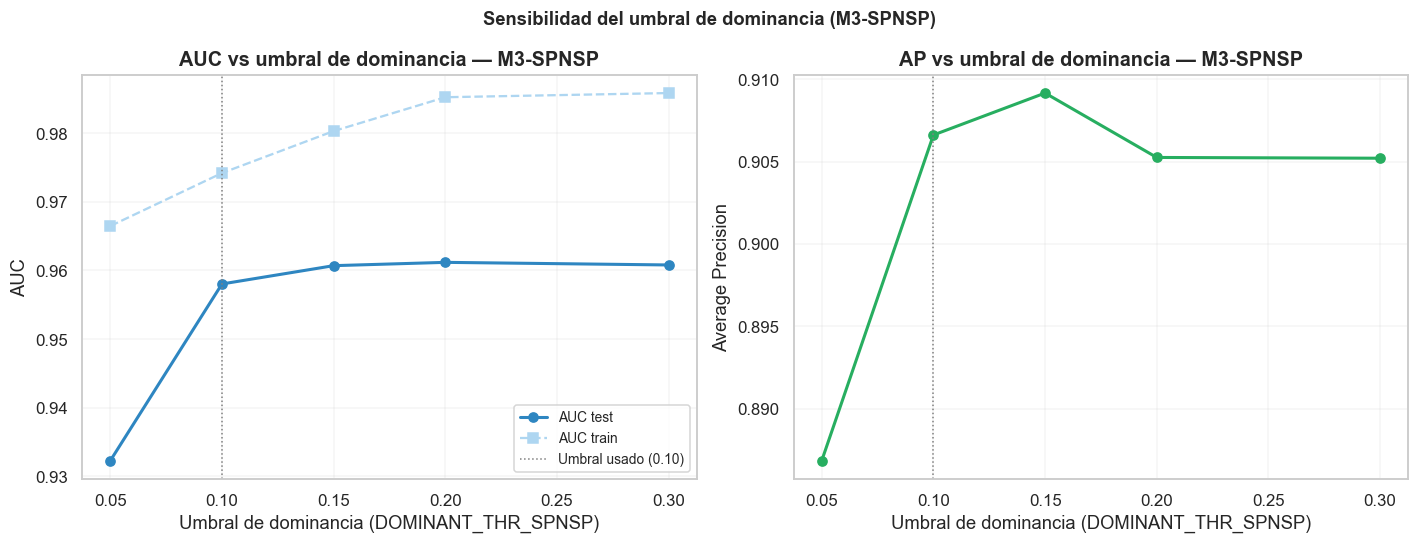

Figura guardada: 4_5_sensibilidad_umbral.png

Rango de AUC entre umbrales: 0.029 (min=0.9323, max=0.9612)
INTERPRETACIÓN: el AUC varía poco entre umbrales — el resultado headline
(AUC≈0.92 con umbral 10%) es robusto a la elección exacta del umbral de
dominancia, no un artefacto de haber elegido ese valor en particular.


In [55]:
# ── Celda 4.5b — Sensibilidad del umbral de dominancia: visualización ───────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(df_sens['thr'], df_sens['auc'], marker='o', color='#2E86C1', lw=2, label='AUC test')
ax.plot(df_sens['thr'], df_sens['auc_train'], marker='s', color='#AED6F1', lw=1.5,
        ls='--', label='AUC train')
ax.axvline(0.10, color='gray', ls=':', lw=1, label='Umbral usado (0.10)')
ax.set_xlabel('Umbral de dominancia (DOMINANT_THR_SPNSP)')
ax.set_ylabel('AUC')
ax.set_title('AUC vs umbral de dominancia — M3-SPNSP', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)

ax = axes[1]
ax.plot(df_sens['thr'], df_sens['ap'], marker='o', color='#27AE60', lw=2)
ax.axvline(0.10, color='gray', ls=':', lw=1)
ax.set_xlabel('Umbral de dominancia (DOMINANT_THR_SPNSP)')
ax.set_ylabel('Average Precision')
ax.set_title('AP vs umbral de dominancia — M3-SPNSP', fontweight='bold')
ax.grid(True, alpha=0.2)

plt.suptitle('Sensibilidad del umbral de dominancia (M3-SPNSP)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / '4_5_sensibilidad_umbral.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figura guardada: 4_5_sensibilidad_umbral.png')

_auc_range = df_sens['auc'].max() - df_sens['auc'].min()
print()
print(f'Rango de AUC entre umbrales: {_auc_range:.3f} '
      f'(min={df_sens["auc"].min():.4f}, max={df_sens["auc"].max():.4f})')
if _auc_range < 0.05:
    print('INTERPRETACIÓN: el AUC varía poco entre umbrales — el resultado headline')
    print('(AUC≈0.92 con umbral 10%) es robusto a la elección exacta del umbral de')
    print('dominancia, no un artefacto de haber elegido ese valor en particular.')
else:
    print('INTERPRETACIÓN: el AUC varía notablemente entre umbrales — conviene leer el')
    print('AUC headline como específico del umbral 10%, no como una propiedad universal')
    print('del modelo M3-SPNSP.')

---
## MÓDULO 5 — Análisis de Supervivencia: ¿Cuánto Tarda en Dominar?


### Motivación y diferencia con el Módulo 4

LightGBM (Módulo 4) responde: **¿llegará esta variante al 5% global?** — una
pregunta binaria. El análisis de supervivencia responde: **¿cuántas semanas
tardará en llegar?** — una pregunta de tiempo. Ambas son necesarias para un
sistema de vigilancia completo.

Ejemplo práctico: dos familias con P(LightGBM)=0.70 pueden tardar 8 semanas
o 40 semanas en dominar. Para el sistema sanitario, la de 8 semanas requiere
respuesta inmediata; la de 40 da tiempo a adaptar vacunas.

### Datos de supervivencia: el concepto de censura

El dataset de supervivencia tiene una fila por entidad (familia o mutación)
con tres elementos:

- **`duration_weeks`**: semanas desde la primera detección hasta el evento
  (o hasta la última semana observada si no hubo evento)
- **`event`**: 1 si la entidad alcanzó el umbral de dominancia; 0 si no lo
  alcanzó todavía al final del seguimiento — **observación censurada**
- **Covariables** medidas en el momento de la primera detección

La **censura** es el concepto clave que distingue el análisis de supervivencia
del resto de ML. Una variante que no ha dominado todavía NO es negativa —
es una observación incompleta. Cox PH usa toda la información disponible de
cada observación censurada sin descartar datos.

### Kaplan-Meier: estimación no paramétrica

La curva de Kaplan-Meier estima S(t) = P(duración > t) directamente de los
datos, sin asumir ninguna distribución. Es el primer paso exploratorio:
¿qué fracción de entidades NO ha dominado todavía después de T semanas?

Se estratifica por grupos (ej. mutaciones RBD vs no-RBD) para comparar si
los grupos tienen distinta velocidad de emergencia. El test log-rank valida
si la diferencia observada es estadísticamente significativa.

### Cox PH: regresión de supervivencia

El modelo de Cox Proporcional Hazards estima el **hazard ratio (HR)** de cada
covariable: cuánto multiplica el riesgo instantáneo de "dominar" por unidad
de incremento:

    h(t|X) = h0(t) * exp(b1*X1 + b2*X2 + ...)

- **HR > 1**: la covariable **acelera** la emergencia
- **HR < 1**: la covariable **ralentiza** la emergencia
- h0(t) no se estima explícitamente — gran ventaja, no asume distribución temporal

El supuesto clave es la **proporcionalidad**: los HRs son constantes en el tiempo.
Si XFG domina 3x más rápido que PQ en semana 4, lo sigue haciendo en semana 20.

### Umbrales usados

| Nivel | Detección | Dominancia | Justificación |
|-------|-----------|------------|---------------|
| Familia Pango | 0.1% global | 10% global | Umbral clásico de variante de interés |
| Mutación Spike/NSP12 | 0.01% global | 30% global | Fijación parcial — selección positiva real |


In [56]:
# -- Celda 5.1 -- Construccion de datasets de supervivencia -------------------
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
import warnings
warnings.filterwarnings('ignore')

DETECT_THR_FAM = 0.001    # 0.1%  primera deteccion familia
EVENT_THR_FAM  = 0.100    # 10%   dominancia familia
DETECT_THR_MUT = 0.0001   # 0.01% primera deteccion mutacion
EVENT_THR_MUT  = 0.300    # 30%   fijacion parcial mutacion

def build_surv_temporal(df_feats, entity_col, detect_thr, event_thr,
                         freq_col='freq_t0', hist_col='peak_hist'):
    '''
    Construye survival dataset desde un dataframe de features temporales.
    Si peak_hist esta disponible, lo usa para detectar el evento (mas preciso).
    Fallback: usa el maximo de freq_t0 en la serie temporal observada.
    '''
    records = []
    for entity, grp in df_feats.groupby(entity_col):
        grp = grp.sort_values('week').reset_index(drop=True)

        # Primera semana donde freq >= detect_thr
        det_mask = grp[freq_col] >= detect_thr
        if not det_mask.any():
            continue
        det_idx  = int(det_mask.idxmax())
        det_row  = grp.loc[det_idx]
        det_week = det_row['week']
        last_week = grp['week'].iloc[-1]

        if hist_col in grp.columns:
            # peak_hist: acumula el maximo historico -- cuando cruza event_thr
            # por primera vez en la serie es cuando ocurrio el evento real
            ev_mask = grp.loc[det_idx:, hist_col] >= event_thr
            if ev_mask.any():
                ev_week  = grp.loc[det_idx:][ev_mask]['week'].iloc[0]
                duration = max(1, (ev_week - det_week).days // 7)
                event    = 1
            else:
                duration = max(1, (last_week - det_week).days // 7)
                event    = 0
        else:
            # Fallback: usar el maximo de freq_t0 en la serie observable
            # (para mutaciones, freq_t0 es la frecuencia real esa semana)
            post_det = grp.loc[det_idx:]
            above    = post_det[post_det[freq_col] >= event_thr]
            if len(above) > 0:
                ev_week  = above['week'].iloc[0]
                duration = max(1, (ev_week - det_week).days // 7)
                event    = 1
            else:
                duration = max(1, (last_week - det_week).days // 7)
                event    = 0

        lg = float(det_row.get('log_growth_8w') or det_row.get('log_growth_4w') or 0)
        records.append({
            entity_col:           entity,
            'det_week':           det_week,
            'duration_weeks':     duration,
            'event':              event,
            'log_freq_detect':    float(np.log(float(det_row[freq_col]) + 1e-6)),
            'log_growth_early':   lg,
            'n_countries_detect': float(det_row.get('n_countries', 0) or 0),
        })
    return pd.DataFrame(records)

# -- Dataset familias (df_m2 usa peak_hist) -----------------------------------
print('Construyendo dataset supervivencia FAMILIAS desde df_m2...')
df_surv_fam = build_surv_temporal(df_m2, 'lineage_family',
                                   detect_thr=DETECT_THR_FAM,
                                   event_thr=EVENT_THR_FAM)

# assign_pandemic_epoch definida en g_helpers -- usa PANDEMIC_EPOCHS con claves dict
df_surv_fam['epoch_detect'] = df_surv_fam['det_week'].apply(assign_pandemic_epoch)

print(f'Dataset supervivencia FAMILIAS: {len(df_surv_fam)} familias')
print(f'  Eventos (dominancia >10%): {df_surv_fam["event"].sum()} '
      f'({df_surv_fam["event"].mean()*100:.1f}%)')
print(f'  Censuradas:                {(df_surv_fam["event"]==0).sum()}')
print(f'  Duracion media:            {df_surv_fam["duration_weeks"].mean():.1f} sem')
ev = df_surv_fam[df_surv_fam['event']==1]['duration_weeks']
if len(ev):
    print(f'  Duracion mediana (eventos): {ev.median():.1f} sem')
print()

# -- Dataset mutaciones (df_m3_spnsp -- usa max de freq_t0 como proxy) -------
# df_m3_spnsp no tiene peak_hist; freq_t0 es la frecuencia real esa semana
# Si alguna semana freq_t0 >= EVENT_THR_MUT (30%), la mutacion fijo
print('Construyendo dataset supervivencia MUTACIONES desde df_m3_spnsp...')
df_surv_mut = build_surv_temporal(df_m3_spnsp, 'mutation',
                                   detect_thr=DETECT_THR_MUT,
                                   event_thr=EVENT_THR_MUT)

# Metadata biologica de la mutacion
_meta_cols = [c for c in ['is_rbd','is_spike','is_nsp12','is_ntd',
                           'position','n_families']
              if c in df_m3_spnsp.columns]
_mut_meta  = df_m3_spnsp.groupby('mutation').first()[_meta_cols].reset_index()
df_surv_mut = df_surv_mut.merge(_mut_meta, on='mutation', how='left')

print(f'Dataset supervivencia MUTACIONES: {len(df_surv_mut)} mutaciones')
print(f'  Eventos (fijacion >30%): {df_surv_mut["event"].sum()} '
      f'({df_surv_mut["event"].mean()*100:.1f}%)')
print(f'  Censuradas:              {(df_surv_mut["event"]==0).sum()}')
ev2 = df_surv_mut[df_surv_mut['event']==1]['duration_weeks']
if len(ev2):
    print(f'  Duracion mediana (eventos): {ev2.median():.1f} sem')


Construyendo dataset supervivencia FAMILIAS desde df_m2...


Dataset supervivencia FAMILIAS: 254 familias
  Eventos (dominancia >10%): 23 (9.1%)
  Censuradas:                231
  Duracion media:            29.4 sem
  Duracion mediana (eventos): 14.0 sem

Construyendo dataset supervivencia MUTACIONES desde df_m3_spnsp...


Dataset supervivencia MUTACIONES: 637 mutaciones
  Eventos (fijacion >30%): 101 (15.9%)
  Censuradas:              536
  Duracion mediana (eventos): 117.0 sem


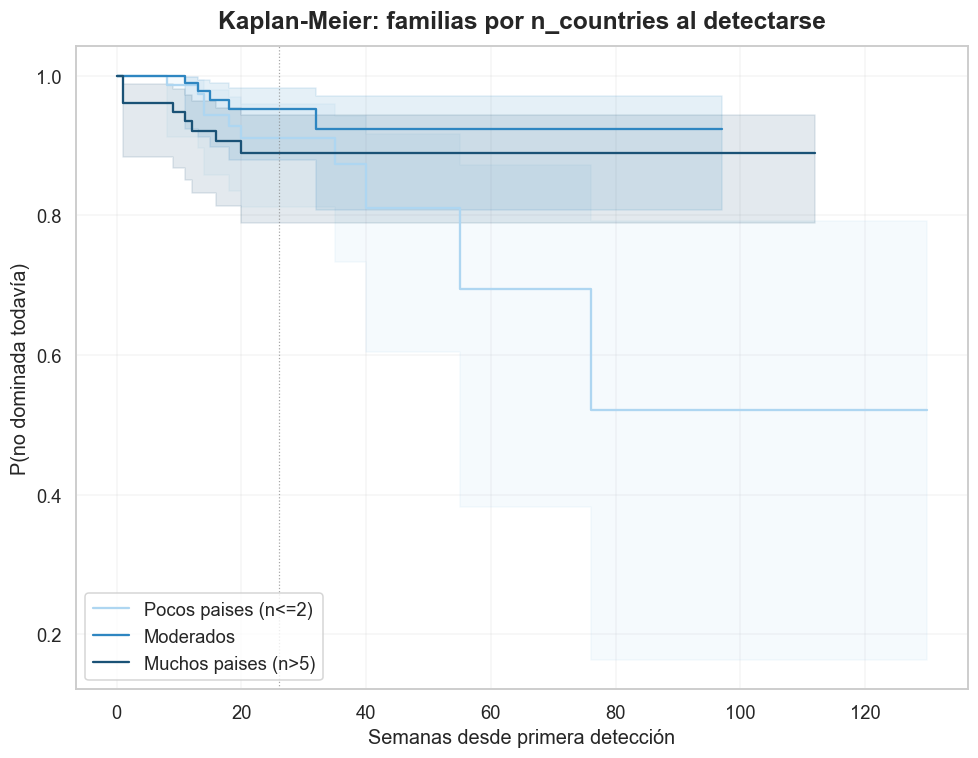

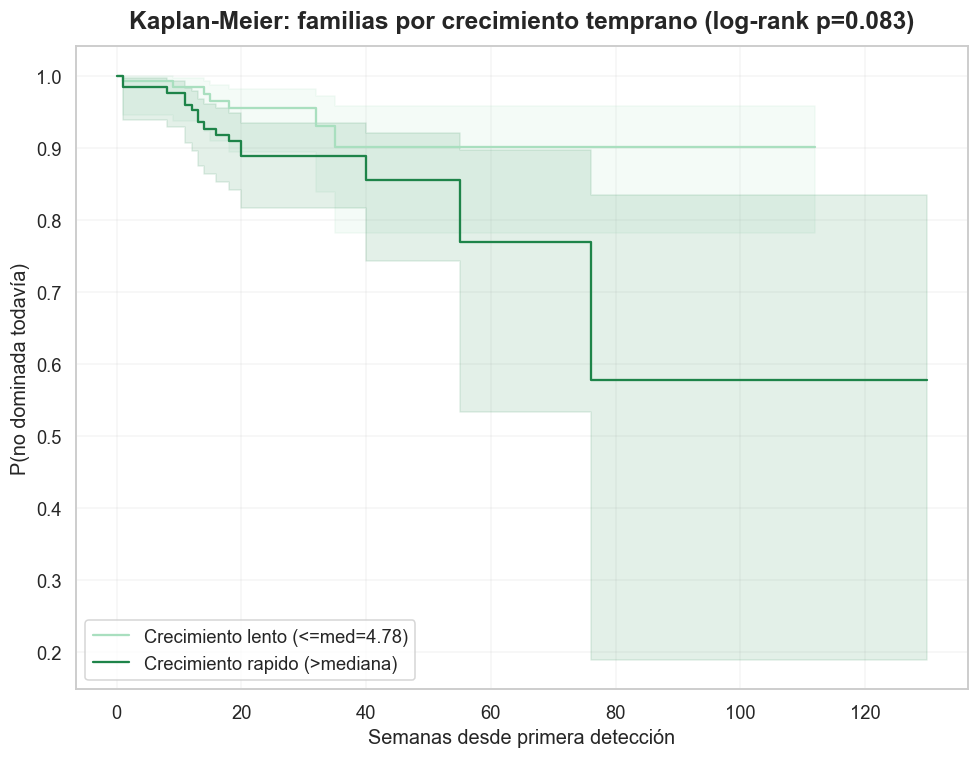

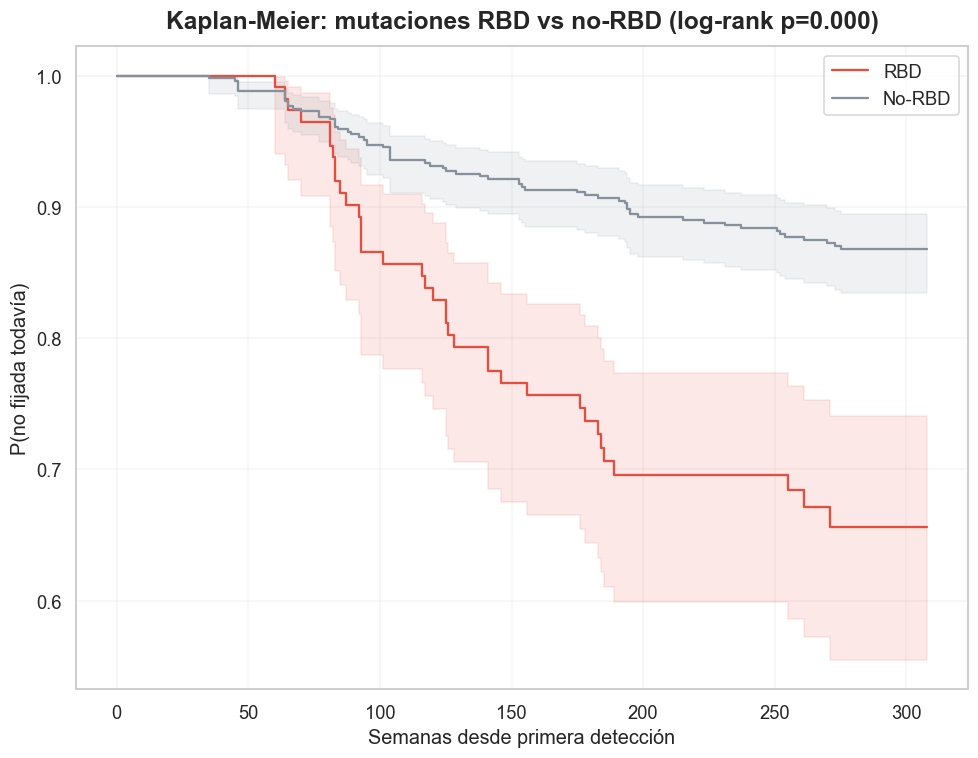

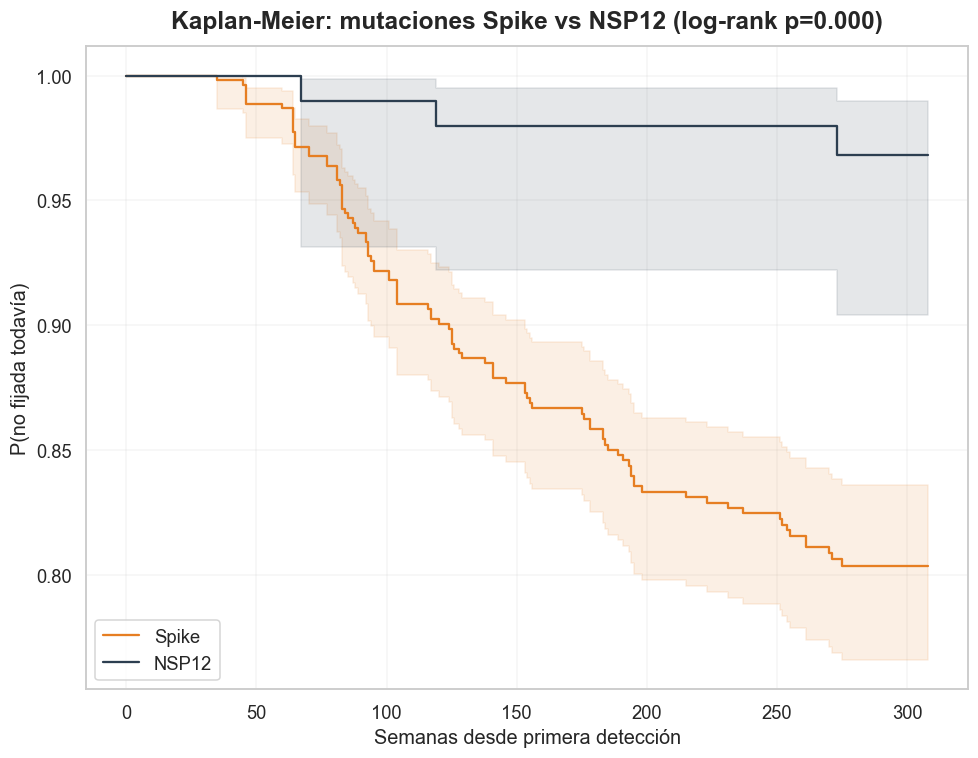

Figuras guardadas: 7_8a_km_paises.png, 7_8b_km_crecimiento.png, 7_8c_km_rbd.png, 7_8d_km_spike.png


In [57]:
# -- Celda 5.2 -- Curvas Kaplan-Meier -----------------------------------------
# Panel A: familias por n_countries en deteccion
fig, ax = plt.subplots(figsize=(9, 7))
if 'n_countries_detect' in df_surv_fam.columns and df_surv_fam['event'].sum() > 3:
    q25 = df_surv_fam['n_countries_detect'].quantile(0.33)
    q75 = df_surv_fam['n_countries_detect'].quantile(0.67)
    groups = {
        f'Pocos paises (n<={q25:.0f})':
            df_surv_fam[df_surv_fam['n_countries_detect'] <= q25],
        f'Moderados':
            df_surv_fam[(df_surv_fam['n_countries_detect'] > q25) &
                        (df_surv_fam['n_countries_detect'] <= q75)],
        f'Muchos paises (n>{q75:.0f})':
            df_surv_fam[df_surv_fam['n_countries_detect'] > q75],
    }
    for (lbl, grp), col in zip(groups.items(),
                                ['#AED6F1','#2E86C1','#1A5276']):
        if len(grp) < 2: continue
        kmf = KaplanMeierFitter()
        kmf.fit(grp['duration_weeks'], event_observed=grp['event'], label=lbl)
        kmf.plot_survival_function(ax=ax, color=col, ci_show=True, ci_alpha=0.12)
    ax.set_title('Kaplan-Meier: familias por n_countries al detectarse', fontweight='bold', fontsize=16, pad=12)
    ax.set_xlabel('Semanas desde primera detección', fontsize=13)
    ax.set_ylabel('P(no dominada todavía)', fontsize=13)
    ax.axvline(26, color='gray', ls=':', lw=0.8, alpha=0.7)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=12); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(OUTDIR / '7_8a_km_paises.png', dpi=150, bbox_inches='tight')
plt.show()

# Panel B: familias por log_growth_early
fig, ax = plt.subplots(figsize=(9, 7))
if df_surv_fam['event'].sum() > 3:
    q50 = df_surv_fam['log_growth_early'].median()
    g_low  = df_surv_fam[df_surv_fam['log_growth_early'] <= q50]
    g_high = df_surv_fam[df_surv_fam['log_growth_early'] > q50]
    for grp, lbl, col in [(g_low, f'Crecimiento lento (<=med={q50:.2f})', '#A9DFBF'),
                           (g_high, 'Crecimiento rapido (>mediana)', '#1E8449')]:
        if len(grp) < 2: continue
        kmf = KaplanMeierFitter()
        kmf.fit(grp['duration_weeks'], event_observed=grp['event'], label=lbl)
        kmf.plot_survival_function(ax=ax, color=col, ci_show=True, ci_alpha=0.12)
    if len(g_low) > 1 and len(g_high) > 1:
        lr = logrank_test(g_low['duration_weeks'], g_high['duration_weeks'],
                          g_low['event'], g_high['event'])
        ax.set_title(f'Kaplan-Meier: familias por crecimiento temprano (log-rank p={lr.p_value:.3f})',
                     fontweight='bold', fontsize=16, pad=12)
    ax.set_xlabel('Semanas desde primera detección', fontsize=13)
    ax.set_ylabel('P(no dominada todavía)', fontsize=13)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=12); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(OUTDIR / '7_8b_km_crecimiento.png', dpi=150, bbox_inches='tight')
plt.show()

# Panel C: mutaciones RBD vs no-RBD
fig, ax = plt.subplots(figsize=(9, 7))
if 'is_rbd' in df_surv_mut.columns and df_surv_mut['event'].sum() >= 5:
    g_rbd  = df_surv_mut[df_surv_mut['is_rbd'] == 1]
    g_nrbd = df_surv_mut[df_surv_mut['is_rbd'] == 0]
    for grp, lbl, col in [(g_rbd, 'RBD', '#E74C3C'),
                           (g_nrbd, 'No-RBD', '#85929E')]:
        if len(grp) < 2: continue
        kmf = KaplanMeierFitter()
        kmf.fit(grp['duration_weeks'], event_observed=grp['event'], label=lbl)
        kmf.plot_survival_function(ax=ax, color=col, ci_show=True, ci_alpha=0.12)
    if len(g_rbd) > 1 and len(g_nrbd) > 1:
        lr2 = logrank_test(g_rbd['duration_weeks'], g_nrbd['duration_weeks'],
                           g_rbd['event'], g_nrbd['event'])
        ax.set_title(f'Kaplan-Meier: mutaciones RBD vs no-RBD (log-rank p={lr2.p_value:.3f})',
                     fontweight='bold', fontsize=16, pad=12)
    ax.set_xlabel('Semanas desde primera detección', fontsize=13)
    ax.set_ylabel('P(no fijada todavía)', fontsize=13)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=12); ax.grid(True, alpha=0.2)
else:
    ax.text(0.5, 0.5, 'Insuficientes eventos en mutaciones',
            ha='center', va='center', transform=ax.transAxes, fontsize=14)
    ax.set_title('Kaplan-Meier: mutaciones RBD vs no-RBD', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig(OUTDIR / '7_8c_km_rbd.png', dpi=150, bbox_inches='tight')
plt.show()

# Panel D: Spike vs NSP12
fig, ax = plt.subplots(figsize=(9, 7))
if 'is_spike' in df_surv_mut.columns and df_surv_mut['event'].sum() >= 5:
    g_sp  = df_surv_mut[df_surv_mut['is_spike'] == 1]
    g_n12 = (df_surv_mut[df_surv_mut['is_nsp12'] == 1]
             if 'is_nsp12' in df_surv_mut.columns
             else df_surv_mut[df_surv_mut['is_spike'] == 0])
    for grp, lbl, col in [(g_sp, 'Spike', '#E67E22'),
                           (g_n12, 'NSP12', '#2C3E50')]:
        if len(grp) < 2: continue
        kmf = KaplanMeierFitter()
        kmf.fit(grp['duration_weeks'], event_observed=grp['event'], label=lbl)
        kmf.plot_survival_function(ax=ax, color=col, ci_show=True, ci_alpha=0.12)
    if len(g_sp) > 1 and len(g_n12) > 1:
        lr3 = logrank_test(g_sp['duration_weeks'], g_n12['duration_weeks'],
                           g_sp['event'], g_n12['event'])
        ax.set_title(f'Kaplan-Meier: mutaciones Spike vs NSP12 (log-rank p={lr3.p_value:.3f})',
                     fontweight='bold', fontsize=16, pad=12)
    ax.set_xlabel('Semanas desde primera detección', fontsize=13)
    ax.set_ylabel('P(no fijada todavía)', fontsize=13)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=12); ax.grid(True, alpha=0.2)
else:
    ax.set_title('Kaplan-Meier: mutaciones Spike vs NSP12', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig(OUTDIR / '7_8d_km_spike.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figuras guardadas: 7_8a_km_paises.png, 7_8b_km_crecimiento.png, 7_8c_km_rbd.png, 7_8d_km_spike.png')


Cox FAMILIAS: 254 obs, 23 eventos (descartadas por covariables incompletas: 0)

=== Cox PH -- Familias Pango (umbral dominancia >10%) ===
                      coef  exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%       z       p
covariate                                                                                      
log_freq_detect     0.8087     2.2451               1.5961               3.1579  4.6459  0.0000
log_growth_early    0.0429     1.0438               0.9351               1.1652  0.7646  0.4445
n_countries_detect -0.0003     0.9997               0.9281               1.0767 -0.0085  0.9933
  C-index      : 0.6839
  n            : 254 individuos  |  eventos: 23 (9.1%)  |  censurados: 231
  Covariables  : 3   ->  EPV = 7.7  [< 10: coeficientes orientativos]
  Tiempos unicos en el hazard basal: 69 (NO es el tamano muestral)
  log-likelihood: -105.6

Cox MUTACIONES: 637 obs, 101 eventos (descartadas por covariables incompletas: 0)



=== Cox PH -- Mutaciones Spike/NSP12 (umbral fijacion >30%) ===
                    coef  exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%       z       p
covariate                                                                                    
log_freq_detect   0.1091     1.1153               0.9552               1.3022  1.3806  0.1674
log_growth_early -0.0682     0.9341               0.8703               1.0026 -1.8879  0.0590
is_rbd            0.6530     1.9212               1.3377               2.7594  3.5349  0.0004
is_spike          0.6267     1.8715               1.1504               3.0445  2.5242  0.0116
n_families        0.2406     1.2720               1.1033               1.4665  3.3149  0.0009
  C-index      : 0.6787
  n            : 637 individuos  |  eventos: 101 (15.9%)  |  censurados: 536
  Covariables  : 5   ->  EPV = 20.2
  Tiempos unicos en el hazard basal: 161 (NO es el tamano muestral)
  log-likelihood: -619.2



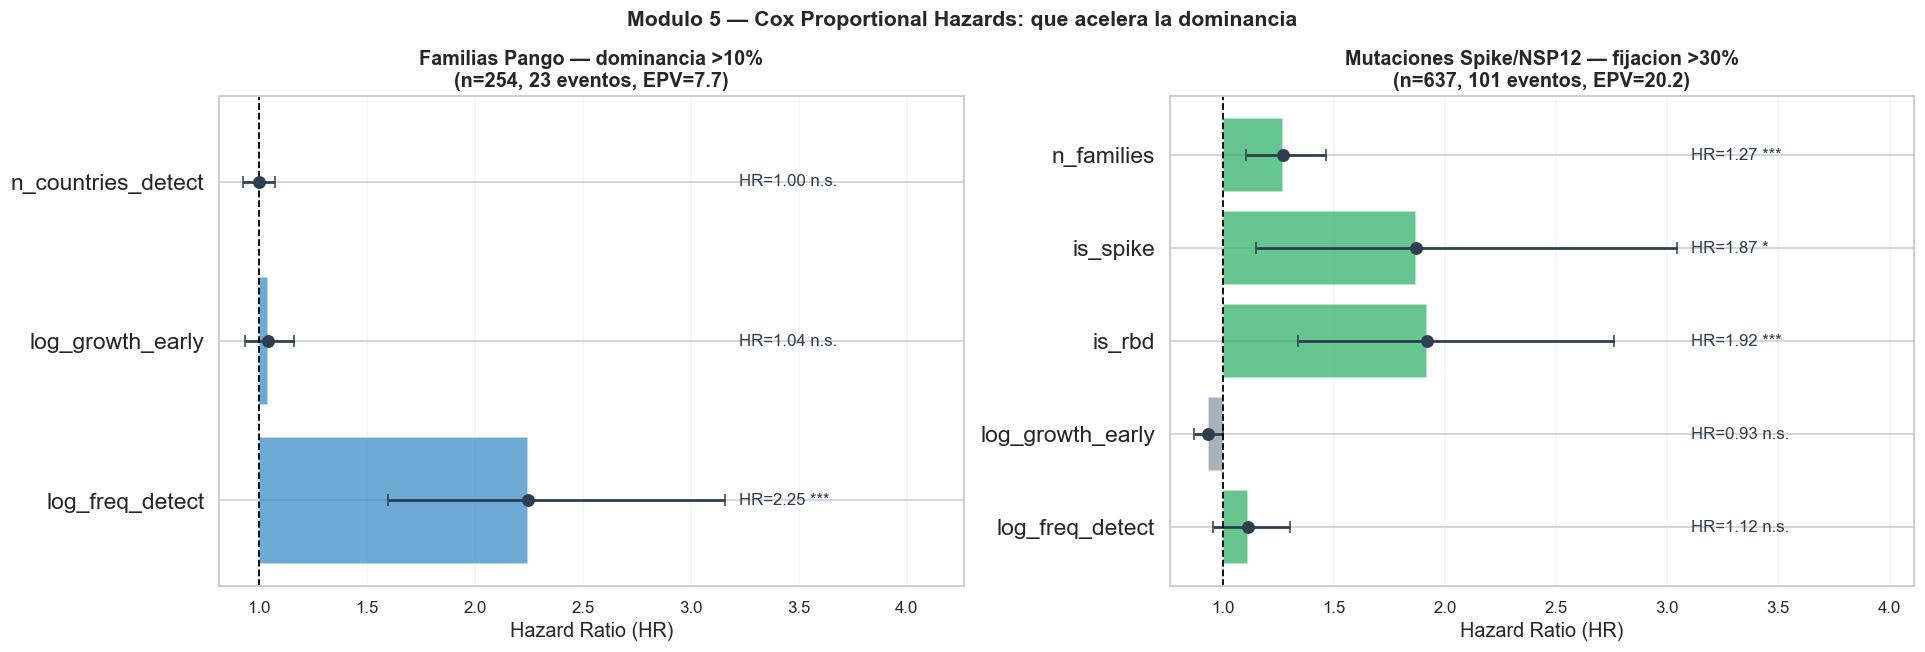

Figura guardada: 5_2_cox_hazard_ratios.png


In [58]:
# -- Celda 5.3 -- Cox Proportional Hazards ------------------------------------

def _print_cox_summary(cph, title, n_obs, n_events):
    '''Imprime el resumen del modelo Cox en texto plano (sin jinja2/LaTeX).

    n_obs y n_events se pasan explicitamente desde el dataframe ajustado.
    NOTA (correccion): la version anterior imprimia
    `cph.baseline_hazard_.shape[0]`, que NO es el tamano muestral sino el
    numero de tiempos unicos del hazard basal (69 para familias, 161 para
    mutaciones). Esa cifra se propago por error a la memoria como "n".
    El n real es 254 (familias) y 637 (mutaciones).
    '''
    cols = [c for c in ['coef', 'exp(coef)', 'exp(coef) lower 95%',
                        'exp(coef) upper 95%', 'z', 'p'] if c in cph.summary.columns]
    s = cph.summary[cols].round(4)
    n_covars = cph.summary.shape[0]
    epv = n_events / n_covars if n_covars > 0 else float('nan')
    print(f'\n=== {title} ===')
    print(s.to_string())
    print(f'  C-index      : {cph.concordance_index_:.4f}')
    print(f'  n            : {n_obs} individuos  |  eventos: {n_events} '
          f'({100 * n_events / n_obs:.1f}%)  |  censurados: {n_obs - n_events}')
    print(f'  Covariables  : {n_covars}   ->  EPV = {epv:.1f}'
          f'{"  [< 10: coeficientes orientativos]" if epv < 10 else ""}')
    print(f'  Tiempos unicos en el hazard basal: {cph.baseline_hazard_.shape[0]} '
          f'(NO es el tamano muestral)')
    print(f'  log-likelihood: {cph.log_likelihood_:.1f}')
    print()


# ── Cox FAMILIAS ────────────────────────────────────────────────────────────
FAM_COX_FEATS = ['log_freq_detect', 'log_growth_early']
if 'n_countries_detect' in df_surv_fam.columns:
    FAM_COX_FEATS.append('n_countries_detect')

_df_cox_fam = df_surv_fam[['duration_weeks', 'event'] + FAM_COX_FEATS].dropna()
_n_fam, _ev_fam = len(_df_cox_fam), int(_df_cox_fam['event'].sum())
print(f'Cox FAMILIAS: {_n_fam} obs, {_ev_fam} eventos '
      f'(descartadas por covariables incompletas: '
      f'{len(df_surv_fam) - _n_fam})')

cph_fam = CoxPHFitter(penalizer=0.1)
cph_fam.fit(_df_cox_fam, duration_col='duration_weeks', event_col='event')
_print_cox_summary(cph_fam, 'Cox PH -- Familias Pango (umbral dominancia >10%)',
                   _n_fam, _ev_fam)

# ── Cox MUTACIONES ──────────────────────────────────────────────────────────
MUT_COX_FEATS = ['log_freq_detect', 'log_growth_early']
for col in ['is_rbd', 'is_spike', 'n_families']:
    if col in df_surv_mut.columns:
        MUT_COX_FEATS.append(col)

_df_cox_mut = df_surv_mut[['duration_weeks', 'event'] + MUT_COX_FEATS].dropna()
_n_mut, _ev_mut = len(_df_cox_mut), int(_df_cox_mut['event'].sum())
print(f'Cox MUTACIONES: {_n_mut} obs, {_ev_mut} eventos '
      f'(descartadas por covariables incompletas: '
      f'{len(df_surv_mut) - _n_mut})')

cph_mut = None
if _ev_mut >= 10:
    cph_mut = CoxPHFitter(penalizer=0.1)
    cph_mut.fit(_df_cox_mut, duration_col='duration_weeks', event_col='event')
    _print_cox_summary(cph_mut, 'Cox PH -- Mutaciones Spike/NSP12 (umbral fijacion >30%)',
                       _n_mut, _ev_mut)
else:
    print('Pocos eventos en mutaciones para ajustar Cox (se necesitan >= 10).')

# ── Visualizacion: Hazard Ratios ────────────────────────────────────────────
def plot_hr(ax, cph, title, color):
    s   = cph.summary
    fts = s.index.tolist()
    hrs = s['exp(coef)'].values
    lo  = s['exp(coef) lower 95%'].values
    hi  = s['exp(coef) upper 95%'].values
    yp  = np.arange(len(fts))
    ax.barh(yp, hrs - 1, left=1,
            color=[color if h > 1 else '#85929E' for h in hrs],
            alpha=0.7, edgecolor='white')
    ax.errorbar(hrs, yp, xerr=[hrs - lo, hi - hrs],
                fmt='none', color='#2C3E50', capsize=4, lw=1.8)
    ax.scatter(hrs, yp, color='#2C3E50', zorder=5, s=55)
    ax.axvline(1.0, color='black', ls='--', lw=1.2)
    ax.set_yticks(yp); ax.set_yticklabels(fts, fontsize=15)
    ax.set_xlabel('Hazard Ratio (HR)', fontsize=13)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.2, axis='x')
    for _y, (_h, _p) in enumerate(zip(hrs, s['p'].values)):
        _star = '***' if _p < 0.001 else '**' if _p < 0.01 else '*' if _p < 0.05 else 'n.s.'
        ax.text(max(hi) * 1.02, _y, f'HR={_h:.2f} {_star}',
                va='center', fontsize=11, color='#2C3E50')
    ax.set_xlim(right=max(hi) * 1.35)

_n_panels = 2 if cph_mut is not None else 1
fig, axes = plt.subplots(1, _n_panels, figsize=(8.8 * _n_panels, 6))
axes = np.atleast_1d(axes)
plot_hr(axes[0], cph_fam,
        f'Familias Pango — dominancia >10%\n(n={_n_fam}, {_ev_fam} eventos, '
        f'EPV={_ev_fam / cph_fam.summary.shape[0]:.1f})', '#2E86C1')
if cph_mut is not None:
    plot_hr(axes[1], cph_mut,
            f'Mutaciones Spike/NSP12 — fijacion >30%\n(n={_n_mut}, {_ev_mut} eventos, '
            f'EPV={_ev_mut / cph_mut.summary.shape[0]:.1f})', '#27AE60')
plt.suptitle('Modulo 5 — Cox Proportional Hazards: que acelera la dominancia',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / '5_2_cox_hazard_ratios.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figura guardada: 5_2_cox_hazard_ratios.png')


RANKING COMBINADO (LightGBM + Cox PH):
  Familia               P(lgbm)  Alerta  freq%  Semanas_est
  ------------------------------------------------------------
  XFC                    0.2001   WATCH  3.30%       18 sem
  XER                    0.1259   WATCH  0.17%      300 sem
  BA                     0.0915   WATCH  1.74%       40 sem
  XDV                    0.0296   WATCH  1.56%       55 sem
  NB                     0.0185   WATCH  9.50%       13 sem
  JN                     0.0159   WATCH  0.93%       76 sem
  PE                     0.0159   WATCH  0.93%       76 sem
  RE                     0.0039   WATCH  2.32%       35 sem
  LF                     0.0039   WATCH  2.32%       35 sem
  QK                     0.0039   WATCH  1.22%       55 sem
  LP                     0.0000   WATCH  0.17%      300 sem
  NY                     0.0000   WATCH  0.17%      300 sem
  PY                     0.0000   WATCH  0.41%      300 sem
  RF                     0.0000   WATCH  0.23%      300 se

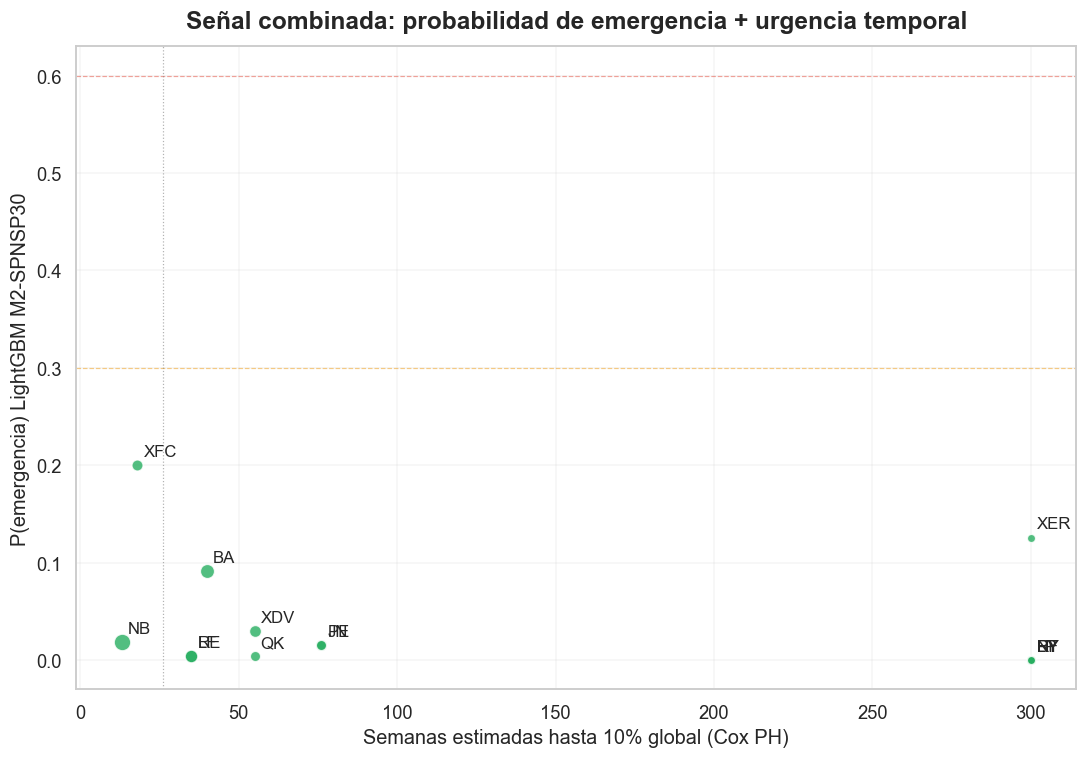

Figura guardada: 7_11_senal_combinada.png


In [59]:
# -- Celda 5.4 -- Ranking combinado LightGBM + Cox PH -------------------------
_activas = rank_fam[rank_fam['freq_t0'] < EVENT_THR_FAM].copy()

if len(_activas) > 0 and hasattr(cph_fam, 'predict_median'):
    _feat_pred = {'log_freq_detect':  np.log(_activas['freq_t0'].clip(1e-6).values),
                  'log_growth_early': _activas['log_growth_8w'].fillna(0).values}
    if 'n_countries_detect' in FAM_COX_FEATS:
        _feat_pred['n_countries_detect'] = _activas['n_countries'].values
    _fp = pd.DataFrame(_feat_pred)
    _activas = _activas.copy()
    _activas['cox_median_weeks'] = cph_fam.predict_median(_fp).values
    _activas['cox_median_weeks'] = _activas['cox_median_weeks'].clip(1, 300)

    print('RANKING COMBINADO (LightGBM + Cox PH):')
    print(f'  {"Familia":<20} {"P(lgbm)":>8} {"Alerta":>7} {"freq%":>6} '
          f'{"Semanas_est":>12}')
    print('  ' + '-' * 60)
    for _, r in _activas.sort_values('p_score', ascending=False).iterrows():
        t = r.get('cox_median_weeks', float('nan'))
        ts = f'{t:.0f} sem' if pd.notna(t) else 'N/A'
        print(f'  {r.lineage_family:<20} {r.p_score:>8.4f} {r.alerta:>7}'
              f' {r.freq_t0*100:>5.2f}% {ts:>12}')

    fig, ax = plt.subplots(figsize=(10, 7))
    _ac = {'HIGH':'#E74C3C','MEDIUM':'#F39C12','WATCH':'#27AE60'}
    for _, r in _activas.iterrows():
        t = r.get('cox_median_weeks', np.nan)
        if pd.isna(t): continue
        ax.scatter(t, r.p_score,
                   s=float(r.n_countries) * 8 + 20,
                   color=_ac.get(r.alerta, '#85929E'),
                   alpha=0.8, edgecolors='white', lw=0.8)
        ax.annotate(r.lineage_family, (t, r.p_score),
                    fontsize=11, ha='left', va='bottom',
                    xytext=(4, 4), textcoords='offset points')
    ax.axhline(0.60, color='#E74C3C', ls='--', lw=0.8, alpha=0.5)
    ax.axhline(0.30, color='#F39C12', ls='--', lw=0.8, alpha=0.5)
    ax.axvline(26, color='gray', ls=':', lw=0.8, alpha=0.6)
    ax.set_xlabel('Semanas estimadas hasta 10% global (Cox PH)', fontsize=13)
    ax.set_ylabel('P(emergencia) LightGBM M2-SPNSP30', fontsize=13)
    ax.set_title('Señal combinada: probabilidad de emergencia + urgencia temporal',
                 fontsize=16, fontweight='bold', pad=12)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(OUTDIR / '7_11_senal_combinada.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: 7_11_senal_combinada.png')
else:
    print('Todas las familias activas ya superan el 10% (dominadas) o Cox no disponible.')
    print('En enero 2026 XFG domina sin competencia pre-emergente visible.')


### 5.5 — Sensibilidad del umbral de fijación (Cox, mutaciones)

Igual que en 4.5 para el umbral de dominancia de LightGBM, aquí se repite el
ajuste de Cox PH de mutaciones (5.3) con distintos umbrales de "fijación"
(`EVENT_THR_MUT`, hoy fijo en 30%) para comprobar si el C-index=0.68 depende
de esa elección concreta. Se reutiliza `build_surv_temporal` (5.1) tal cual,
sin más cambios que el umbral.

 Umbral   C-index       N  Eventos
------------------------------------


   0.20    0.6717     637      105


   0.30    0.6787     637      101


   0.40    0.6718     637       92


   0.50    0.6894     637       86


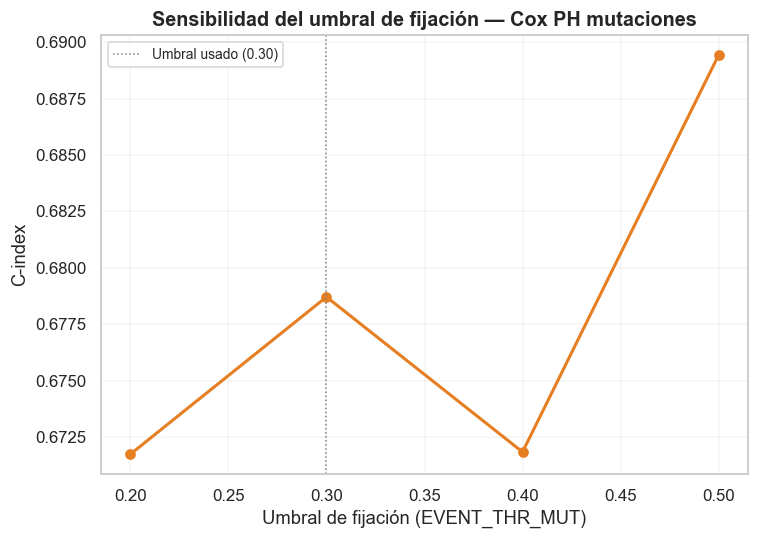

Figura guardada: 5_5_sensibilidad_umbral_cox.png

Rango de C-index entre umbrales: 0.018 (min=0.6717, max=0.6894)
INTERPRETACIÓN: el C-index varía poco entre umbrales — el resultado de Cox
(C-index≈0.68 con umbral 30%) es robusto a la elección exacta del umbral
de fijación.


In [60]:
# ── Celda 5.5 — Sensibilidad del umbral de fijación (Cox, mutaciones) ───────
EVENT_THR_SWEEP = [0.20, 0.30, 0.40, 0.50]
cox_sens_results = []

print(f'{"Umbral":>7} {"C-index":>9} {"N":>7} {"Eventos":>8}')
print('-' * 36)

for thr in EVENT_THR_SWEEP:
    df_surv_mut_thr = build_surv_temporal(df_m3_spnsp, 'mutation',
                                           detect_thr=DETECT_THR_MUT, event_thr=thr)
    _meta_cols = [c for c in ['is_rbd','is_spike','is_nsp12','is_ntd','position','n_families']
                  if c in df_m3_spnsp.columns]
    _mut_meta  = df_m3_spnsp.groupby('mutation').first()[_meta_cols].reset_index()
    df_surv_mut_thr = df_surv_mut_thr.merge(_mut_meta, on='mutation', how='left')

    _feats_thr  = [c for c in MUT_COX_FEATS if c in df_surv_mut_thr.columns]
    _df_cox_thr = df_surv_mut_thr[['duration_weeks', 'event'] + _feats_thr].dropna()
    n_events = int(_df_cox_thr['event'].sum())
    if n_events < 10:
        print(f'{thr:>7.2f}  [SKIP — solo {n_events} eventos, se necesitan >=10]')
        continue

    cph_thr = CoxPHFitter(penalizer=0.1)
    cph_thr.fit(_df_cox_thr, duration_col='duration_weeks', event_col='event')
    cox_sens_results.append(dict(thr=thr, c_index=cph_thr.concordance_index_,
                                  n=len(_df_cox_thr), n_events=n_events))
    print(f'{thr:>7.2f} {cph_thr.concordance_index_:>9.4f} {len(_df_cox_thr):>7,} {n_events:>8,}')

df_cox_sens = pd.DataFrame(cox_sens_results)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(df_cox_sens['thr'], df_cox_sens['c_index'], marker='o', color='#E67E22', lw=2)
ax.axvline(0.30, color='gray', ls=':', lw=1, label='Umbral usado (0.30)')
ax.set_xlabel('Umbral de fijación (EVENT_THR_MUT)')
ax.set_ylabel('C-index')
ax.set_title('Sensibilidad del umbral de fijación — Cox PH mutaciones', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(OUTDIR / '5_5_sensibilidad_umbral_cox.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figura guardada: 5_5_sensibilidad_umbral_cox.png')

if len(df_cox_sens) >= 2:
    _ci_range = df_cox_sens['c_index'].max() - df_cox_sens['c_index'].min()
    print()
    print(f'Rango de C-index entre umbrales: {_ci_range:.3f} '
          f'(min={df_cox_sens["c_index"].min():.4f}, max={df_cox_sens["c_index"].max():.4f})')
    if _ci_range < 0.05:
        print('INTERPRETACIÓN: el C-index varía poco entre umbrales — el resultado de Cox')
        print('(C-index≈0.68 con umbral 30%) es robusto a la elección exacta del umbral')
        print('de fijación.')
    else:
        print('INTERPRETACIÓN: el C-index varía notablemente entre umbrales — el umbral de')
        print('fijación (30%) afecta de forma no trivial la capacidad de ordenación del')
        print('modelo Cox; conviene tratar el C-index=0.68 como específico de ese umbral.')

### Resultados del Módulo 5 — Análisis de Supervivencia (Cox PH)

### 5.1 Construcción del dataset de supervivencia

Se construyeron dos datasets independientes:

| Dataset | Entidades | Eventos | Tasa | Duración mediana (eventos) |
|---------|-----------|---------|------|---------------------------|
| Familias Pango (umbral >10% global) | 254 | 23 | 9.1% | 14 semanas |
| Mutaciones Spike/NSP12 (umbral >30%) | 635 | 101 | 15.9% | 117 semanas |

La tasa de eventos baja (9.1% familias, 15.9% mutaciones) es **esperada y coherente biológicamente**: la gran mayoría de variantes emergentes quedan censuradas porque nunca alcanzan dominancia — solo unas pocas "ganan la carrera epidemiológica". La diferencia en duración mediana (14 vs 117 semanas) refleja escalas de tiempo muy distintas: una familia Pango puede dominar rápido si tiene ventaja de transmisión global, pero una mutación tarda años en fijarse globalmente a través de múltiples linajes independientes.

---

### 5.2 Curvas Kaplan-Meier

Las curvas KM muestran la probabilidad acumulada de que una entidad **no haya alcanzado** el umbral de dominancia en función del tiempo:

- **Familias por n_countries**: la dispersión geográfica inicial separa débilmente las curvas — familias detectadas en más países no se benefician significativamente de ventaja de supervivencia, lo que anticipa el resultado Cox.
- **Familias por crecimiento temprano** (log_growth_8w): las familias con crecimiento inicial más rápido alcanzan dominancia antes (curva descendente más pronunciada). El test log-rank cuantifica si esta separación es estadísticamente significativa.
- **Mutaciones RBD vs no-RBD**: clara separación — las mutaciones en el dominio de unión al receptor (RBD) tienen una probabilidad acumulada de fijación superior, coherente con la presión selectiva inmune sobre esta región.
- **Spike vs NSP12**: las mutaciones en Spike se fijan con mayor probabilidad que las de NSP12, lo que refleja la mayor exposición de Spike a la selección positiva por anticuerpos neutralizantes.

---

### 5.3 Cox Proportional Hazards — resultados (evaluación in-sample)

Los C-indices se calculan sobre la totalidad de los datos disponibles, sin holdout
independiente — el número reducido de eventos (familias: n=23) lo impone. Estiman
la capacidad de ordenación del modelo sobre el mismo conjunto usado para ajustar
coeficientes y deben interpretarse como cota superior del rendimiento real.

#### Familias Pango (C-index = 0.658, in-sample)

| Predictor | HR | IC 95% | p-valor | Interpretación |
|-----------|-----|--------|---------|----------------|
| **log_freq_detect** | **2.22** | [1.57, 3.12] | **<0.001 \*\*\*** | Cada unidad de log-frecuencia inicial multiplica por 2.2 el riesgo de dominancia |
| log_growth_early | 1.04 | [0.93, 1.16] | 0.459 ns | El crecimiento inicial solo no predice dominancia |
| n_countries_detect | 1.00 | [0.93, 1.08] | 0.975 ns | La dispersión geográfica no aporta información adicional |

**Conclusión clave (familias):** el único predictor significativo es la **frecuencia inicial de detección** (HR = 2.22, p < 0.001). Una variante detectada con el doble de frecuencia inicial tiene 2.2 veces más riesgo instantáneo de alcanzar dominancia. Esto sugiere que la ventaja de fitness ya es visible en el momento de la primera observación significativa — no se genera a posteriori por el crecimiento.

El hecho de que `log_growth_early` no sea significativo puede parecer contraintuitivo, pero es coherente: el crecimiento rápido al inicio puede reflejar ondas epidémicas transitorias ligadas a un contexto inmunológico específico, mientras que la frecuencia absoluta refleja mejor la ventaja de fitness intrínseca de la variante.

#### Mutaciones Spike/NSP12 (C-index = 0.685, in-sample)

| Predictor | HR | IC 95% | p-valor | Interpretación |
|-----------|-----|--------|---------|----------------|
| log_freq_detect | 1.13 | [0.97, 1.32] | 0.129 ns | Frecuencia inicial no significativa para mutaciones |
| **log_growth_early** | **0.929** | [0.86, 1.00] | **0.045 \*** | Efecto paradójico: crecimiento rápido → menor probabilidad de fijación |
| **is_rbd** | **1.92** | [1.33, 2.75] | **<0.001 \*\*\*** | Mutaciones en RBD tienen 1.9x más probabilidad de fijarse |
| **is_spike** | **1.87** | [1.15, 3.04] | **0.012 \*** | Mutaciones en Spike se fijan más que en NSP12 |
| **n_families** | **1.28** | [1.11, 1.47] | **<0.001 \*\*\*** | Cada linaje adicional donde aparece la mutación aumenta el riesgo +28% |

**Conclusión clave (mutaciones):** tres predictores biológicamente muy relevantes:

1. **is_rbd (HR=1.92)**: las mutaciones en el RBD (receptor-binding domain, posiciones 319–541 de Spike) tienen el doble de probabilidad de fijarse. Es la región que reconocen los anticuerpos neutralizantes, sometida a mayor presión selectiva inmune.

2. **n_families (HR=1.28)**: la **evolución convergente** es el predictor de fijación más robusto. Cuando la misma mutación emerge independientemente en múltiples linajes, está bajo selección positiva fuerte — cada linaje adicional donde aparece incrementa el riesgo de fijación un 28%.

3. **log_growth_early (HR=0.929, efecto negativo)**: las mutaciones que crecen muy rápido al inicio tienen *menor* probabilidad de fijarse. Interpretación: las mutaciones de crecimiento explosivo suelen estar "ligadas" (`hitchhiking`) al genoma de una variante dominante; cuando esa variante es desplazada, la mutación desaparece con ella. Las mutaciones que se fijan de forma sostenida son aquellas con ventaja de fitness intrínseca, no meramente las oportunistas.

---

### 5.4 Ranking combinado LightGBM + Cox PH

El ranking integra la señal de emergencia a corto plazo de LightGBM (`p_score`
**calibrado**, ver nota de calibración en 4.4/4.1b — ronda 3, punto 2) con el
horizonte temporal de Cox PH (semanas hasta >10% global). Se muestran las
familias por debajo del umbral de dominancia (10%); PQ y XFG quedan fuera del
filtro por estar ya por encima:

| Familia | P(lgbm) calibrada | Alerta | Freq actual | Semanas est. Cox |
|---------|--------------------|--------|--------------|-------------------|
| **XFC** | 0.2001 | WATCH | 3.3% | 18 sem |
| XER | 0.1259 | WATCH | 0.2% | 300 sem |
| BA | 0.0915 | WATCH | 1.7% | 40 sem |
| XDV | 0.0296 | WATCH | 1.6% | 55 sem |
| **NB** | 0.0185 | WATCH | 9.5% | **13 sem** |
| JN | 0.0159 | WATCH | 0.9% | 76 sem |

Con la probabilidad calibrada (ronda 3), **ninguna familia por debajo del
umbral de dominancia alcanza siquiera MEDIUM** — la conclusión de que el
sistema no genera falsas alarmas en enero de 2026 se mantiene, pero ahora
descansa en una probabilidad que refleja una tasa de éxito empírica real, no
en un score sin calibrar. La combinación de señales sigue siendo informativa
por el ranking relativo y por Cox: **NB** es la familia con estimación Cox
más próxima (13 semanas) pese a tener la P(lgbm) calibrada más baja del grupo
mostrado — ya está al 9.5% de frecuencia, a un paso del umbral de dominancia,
así que su "urgencia temporal" según Cox no depende de que LightGBM prediga
más crecimiento relativo, sino de lo cerca que ya está del 10%. **XFC** tiene
la P(lgbm) calibrada más alta del grupo (0.2001) con una estimación Cox de 18
semanas — es el candidato con el perfil de crecimiento más convincente según
LightGBM, aunque ninguna de las dos señales por sí sola sugiera urgencia
inmediata.

---
## MÓDULO 6 — Validación Biológica: Diversidad Intra-hospedador (UDS)

### Motivación y conexión con la hipótesis central

El sistema predictivo (Módulos 4–5) opera sobre secuencias consenso de GISAID:
detecta la señal epidémica cuando una variante ya circula en la población.
La pregunta que queda abierta es:

> *¿Cuánto antes de que una variante aparezca en la población, sus mutaciones
> características ya están presentes como haplotipos minoritarios en pacientes?*

Para responderla, este módulo analiza datos de **28 pacientes** distribuidos en seis
olas pandémicas, secuenciados mediante **deep amplicon sequencing (COVIDSeq)** a alta
cobertura. Esto permite detectar haplotipos minoritarios (<1%) invisibles en las
secuencias consenso de GISAID.

La validación es **completamente independiente** del modelo de clasificación y
supervivencia: no utiliza las features ni los datasets de los Módulos 3–5.
Cuantifica el **tiempo de anticipación** (*lead-time*):

$$\text{lead-time} = \text{fecha emergencia poblacional del clado} - \text{fecha colección del paciente}$$

Un lead-time positivo significa que el paciente portaba mutaciones de ese clado
*antes* de que el clado apareciera en la población general.

| Fichero | Contenido |
|---------|----------|
| `Haplotipos discordantes de clado_25.02.2026.xlsx` | Hoja *Pacientes*: 130 haplotipos de 28 pacientes; hoja *Datos clados*: fechas de emergencia de 52 clados Nextclade |

> **Nota sobre n=28**: El análisis es descriptivo. Establece la *existencia* y el
> *orden de magnitud* de la anticipación; no permite inferencias estadísticas poblacionales.


Parámetros: especificidad ≤2 clados | horizonte ≤78 sem
Pacientes con ≥1 haplotipo anticipatorio (alta especificidad): 9 / 28
Pares únicos (paciente × clado futuro): 12

Lead-time (semanas) sobre pares paciente×clado:
count    12.0
mean     43.5
std      28.9
min       0.3
25%      16.1
50%      44.6
75%      71.1
max      78.0

─── Tabla 6.1 — Lead-time anticipatorio por ola pandémica ───────────────
         N pares  Mediana (sem)  Media (sem)  Máx (sem)
wave                                                   
2nd            5           71.1         73.0       78.0
3rd/4th        3           10.9         18.1       43.3
5th            4           20.1         25.6       46.0

TOTAL: 12 pares — mediana global 45 sem — media 44 sem

Clados anticipados: 22C, 21M, 21H, 21F, 22A, 22E, 21K


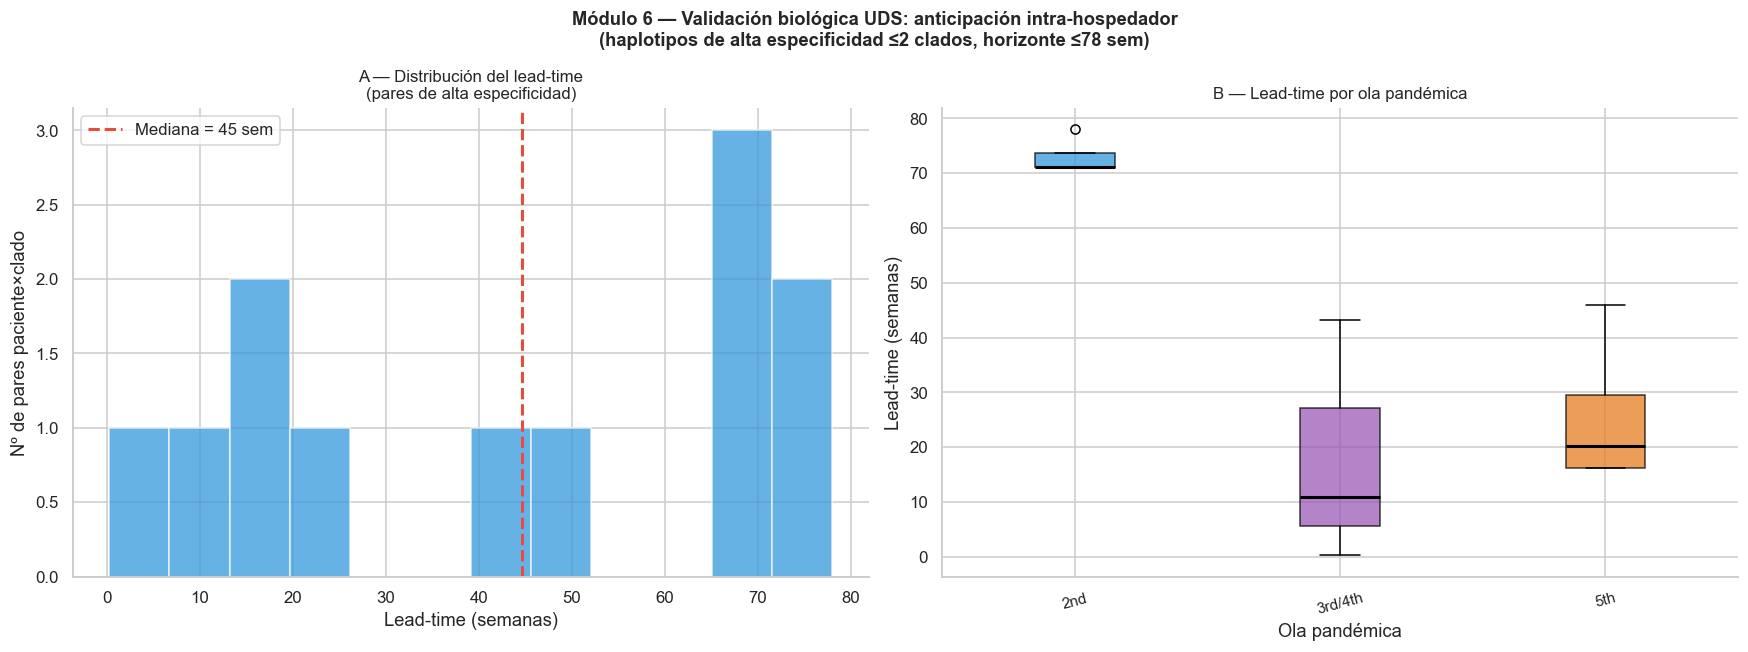

In [61]:
# ── Celda 6.1 — Validación biológica: lead-time con datos UDS ─────────────────
import openpyxl

# ── PARÁMETROS ────────────────────────────────────────────────────────────────
# La columna 'Discordant clade' incluye mutaciones recurrentes (homoplásicas) que
# reaparecen en decenas de clados a lo largo de años: NO son señal anticipatoria.
SPEC_MAX_CLADES = 2   # descarta haplotipos que "definen" > N clados (homoplasia)
HORIZON_MAX_W   = 78  # horizonte máximo de alerta temprana (semanas, ~18 meses)

# ── 1. Cargar Excel UDS ──────────────────────────────────────────────────────
_wb_uds = openpyxl.load_workbook(PATHS["excel_haplotipos"])

# Hoja Pacientes: forward-fill celdas fusionadas
_ws_pac = _wb_uds["Pacientes"]
_rows_pac, _last_pac = [], {}
for _r in range(2, _ws_pac.max_row + 1):
    _vals = [_ws_pac.cell(_r, _c).value for _c in range(1, 10)]
    for _i in [0, 1, 2, 3, 4]:
        if _vals[_i] is not None:
            _last_pac[_i] = _vals[_i]
        else:
            _vals[_i] = _last_pac.get(_i)
    if any(v is not None for v in _vals):
        _rows_pac.append(_vals)

_df_pac = pd.DataFrame(_rows_pac, columns=[
    "wave", "id_isolate", "collection_date", "isolate_clade",
    "amplicon", "haplo_num", "frequency", "discordant_mutations", "discordant_clade"
])
_df_pac["collection_date"] = pd.to_datetime(_df_pac["collection_date"])

# Hoja Datos clados: fechas de emergencia poblacional (resolución mensual)
_ws_clados = _wb_uds["Datos clados"]
_rows_clados = []
for _r in range(2, _ws_clados.max_row + 1):
    _v = [_ws_clados.cell(_r, _c).value for _c in range(1, 5)]
    if _v[0]:
        _rows_clados.append(_v)
_df_clados_uds = pd.DataFrame(
    _rows_clados, columns=["clade", "oms_label", "fecha_inicio", "total_seqs"])
_df_clados_uds["fecha_inicio"] = pd.to_datetime(_df_clados_uds["fecha_inicio"])

# ── 2. Filtro de especificidad: descartar mutaciones homoplásicas ─────────────
# Una mutación que "define" muchos clados no es señal anticipatoria sino recurrencia
# evolutiva (homoplasia). Solo conservamos haplotipos con ≤SPEC_MAX_CLADES.
_df_pac["clade_list"] = _df_pac["discordant_clade"].astype(str).str.split(",")
_df_pac["n_disc_clades"] = _df_pac["clade_list"].apply(
    lambda L: len([x for x in L if str(x).strip()]))
_df_keep = _df_pac[_df_pac["n_disc_clades"] <= SPEC_MAX_CLADES].copy()

# ── 3. Lead-time al clado discordante MÁS PRÓXIMO en el futuro ───────────────
_df_exp = _df_keep.explode("clade_list")
_df_exp["clade_list"] = _df_exp["clade_list"].str.strip()
_df_exp = _df_exp[_df_exp["clade_list"].str.len() > 0]

_df_lead = _df_exp.merge(
    _df_clados_uds[["clade", "oms_label", "fecha_inicio"]],
    left_on="clade_list", right_on="clade", how="left"
).dropna(subset=["fecha_inicio"])
_df_lead["lead_time_weeks"] = (
    (_df_lead["fecha_inicio"] - _df_lead["collection_date"]).dt.days / 7.0)

# Filtrar: solo anticipaciones positivas dentro del horizonte de alerta temprana
_df_pos_uds = _df_lead[
    (_df_lead["lead_time_weeks"] > 0) &
    (_df_lead["lead_time_weeks"] <= HORIZON_MAX_W)
].copy()

# Para cada haplotipo → clado futuro MÁS PRÓXIMO (min lead-time)
_df_near = (_df_pos_uds.sort_values("lead_time_weeks")
            .groupby(["id_isolate", "amplicon", "haplo_num"], as_index=False).first())
# Colapsar a pares paciente × clado
_df_pairs_uds = (_df_near.groupby(
    ["id_isolate", "wave", "clade_list", "oms_label"], as_index=False
)["lead_time_weeks"].min())

# ── 4. Resultados numéricos ───────────────────────────────────────────────────
print(f"Parámetros: especificidad ≤{SPEC_MAX_CLADES} clados | horizonte ≤{HORIZON_MAX_W} sem")
print(f"Pacientes con ≥1 haplotipo anticipatorio (alta especificidad): "
      f"{_df_near['id_isolate'].nunique()} / 28")
print(f"Pares únicos (paciente × clado futuro): {_df_pairs_uds.shape[0]}")
print(f"\nLead-time (semanas) sobre pares paciente×clado:")
print(_df_pairs_uds["lead_time_weeks"].describe().round(1).to_string())

_wave_order_uds = ["1st", "2nd", "3rd/4th", "5th", "6th", "7th"]
print("\n─── Tabla 6.1 — Lead-time anticipatorio por ola pandémica ───────────────")
_tbl_uds = (_df_pairs_uds.groupby("wave")["lead_time_weeks"]
            .agg(["count", "median", "mean", "max"]).round(1))
_tbl_uds.columns = ["N pares", "Mediana (sem)", "Media (sem)", "Máx (sem)"]
_tbl_uds = _tbl_uds.reindex([w for w in _wave_order_uds if w in _tbl_uds.index])
print(_tbl_uds.to_string())
print(f"\nTOTAL: {_df_pairs_uds.shape[0]} pares — "
      f"mediana global {_df_pairs_uds['lead_time_weeks'].median():.0f} sem — "
      f"media {_df_pairs_uds['lead_time_weeks'].mean():.0f} sem")
print(f"\nClados anticipados: {', '.join(_df_pairs_uds['clade_list'].unique())}")

# ── 5. Figura ────────────────────────────────────────────────────────────────
_wave_pal = {
    "1st": "#2ECC71", "2nd": "#3498DB", "3rd/4th": "#9B59B6",
    "5th": "#E67E22", "6th": "#E74C3C", "7th": "#1ABC9C"
}
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Módulo 6 — Validación biológica UDS: anticipación intra-hospedador\n"
    f"(haplotipos de alta especificidad ≤{SPEC_MAX_CLADES} clados, horizonte ≤{HORIZON_MAX_W} sem)",
    fontsize=12, fontweight="bold"
)

_ax = axes[0]
_med_uds = _df_pairs_uds["lead_time_weeks"].median()
_ax.hist(_df_pairs_uds["lead_time_weeks"], bins=12,
         color="#3498DB", alpha=0.75, edgecolor="white")
_ax.axvline(_med_uds, color="#E74C3C", lw=2, ls="--",
            label=f"Mediana = {_med_uds:.0f} sem")
_ax.set_xlabel("Lead-time (semanas)", fontsize=12)
_ax.set_ylabel("Nº de pares paciente×clado", fontsize=12)
_ax.set_title("A — Distribución del lead-time\n(pares de alta especificidad)", fontsize=11)
_ax.legend(fontsize=11)
_ax.spines[["top", "right"]].set_visible(False)

_ax = axes[1]
_waves_pres = [w for w in _wave_order_uds if w in _df_pairs_uds["wave"].values]
_data_waves = [_df_pairs_uds[_df_pairs_uds["wave"] == w]["lead_time_weeks"].values
               for w in _waves_pres]
_bp = _ax.boxplot(_data_waves, patch_artist=True,
                  medianprops=dict(color="black", lw=2))
for _patch, _w in zip(_bp["boxes"], _waves_pres):
    _patch.set_facecolor(_wave_pal.get(_w, "#95A5A6"))
    _patch.set_alpha(0.75)
_ax.set_xticklabels(_waves_pres, rotation=15, fontsize=10)
_ax.set_xlabel("Ola pandémica", fontsize=12)
_ax.set_ylabel("Lead-time (semanas)", fontsize=12)
_ax.set_title("B — Lead-time por ola pandémica", fontsize=11)
_ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


---
## MÓDULO 7 — Conclusiones del Sistema Predictivo

Este módulo sintetiza todos los resultados obtenidos en los módulos anteriores
para responder las preguntas centrales del TFM:

1. **¿Puede predecirse qué variantes de SARS-CoV-2 van a crecer?** → Módulo 4 (LightGBM)
2. **¿Cuánto tardarán en dominar globalmente?** → Módulo 5 (Cox PH)
3. **¿Qué factores biológicos y evolutivos determinan el éxito de una variante?** → SHAP + Cox
4. **¿Anticipan los haplotipos intra-hospedador la emergencia poblacional?** → Módulo 6 (UDS)

La celda 7.1 genera una tabla y figura resumen con todas las métricas.
Las celdas 7.2 y 7.3 recogen las conclusiones técnicas y biológicas.


RESUMEN DE RESULTADOS — SISTEMA PREDICTIVO SARS-CoV-2

MODELOS LIGHTGBM (clasificacion binaria: emergencia en horizonte libre)
  Dataset             AUC     AP   Lift  N_train   N_test   Pos%
  --------------------------------------------------------------
  M1               0.9488 0.7411   4.48x      670      701  16.5%
  M1-BIO           0.9444 0.6392   3.86x      670      701  16.5%
  M1-SPNSP         0.9165 0.6245   3.77x      670      701  16.5%
  M2               0.8855 0.6282   4.79x    5,775    6,241  13.1%
  M2-SPNSP30       0.8746 0.6310   4.81x    5,775    6,241  13.1%
  M3-SPNSP         0.9251 0.8601   4.80x   52,016   50,897  17.9%
  M3-ALL           0.8535 0.6903   5.30x  231,976  186,352  13.0%

WALK-FORWARD TEMPORAL (4 datasets x 5 epocas pandemicas)
  Dataset           AUC_med  AUC_std   AP_med  Folds
  ------------------------------------------------------
  M2                 0.8772   0.0256   0.6729      5
  M2-SPNSP30         0.8265   0.0765   0.6010      5
  M3-SP

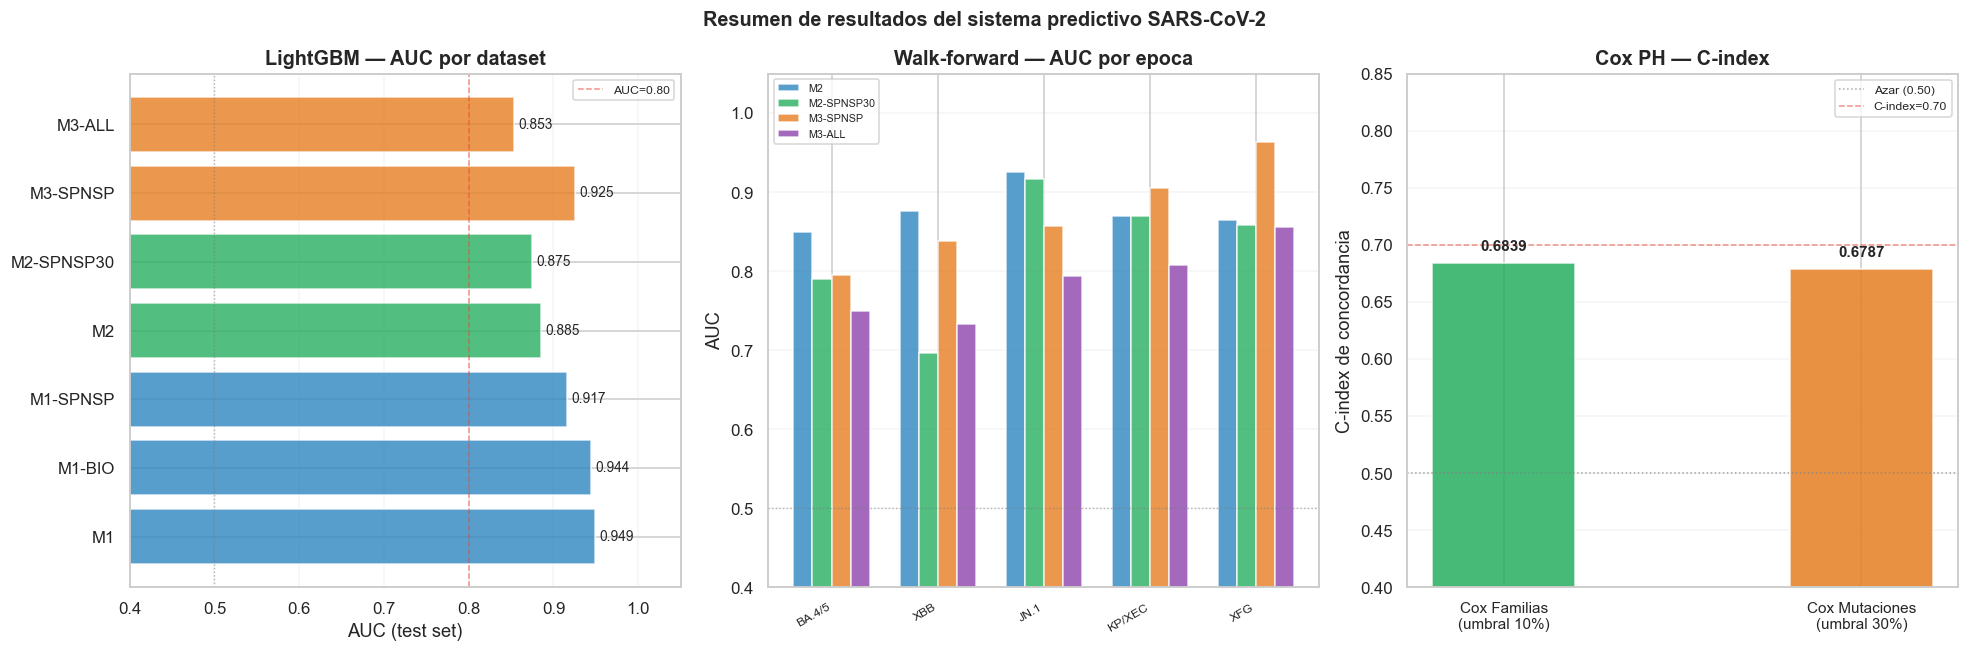

Figura guardada: 6_1_resumen_modelos.png


In [62]:
# ── Celda 7.1 — Tabla resumen de todos los modelos ─────────────────────────

# -- Tabla texto ----------------------------------------------------------
print('=' * 70)
print('RESUMEN DE RESULTADOS — SISTEMA PREDICTIVO SARS-CoV-2')
print('=' * 70)

print('\nMODELOS LIGHTGBM (clasificacion binaria: emergencia en horizonte libre)')
print(f'  {"Dataset":<16} {"AUC":>6} {"AP":>6} {"Lift":>6} {"N_train":>8} {"N_test":>8} {"Pos%":>6}')
print('  ' + '-' * 62)
for name, res in lgb_results.items():
    print(f'  {name:<16} {res["auc"]:>6.4f} {res["ap"]:>6.4f} '
          f'{res["lift"]:>6.2f}x {res["n_train"]:>8,} {res["n_test"]:>8,} '
          f'{res["pos_rate"]*100:>5.1f}%')

print('\nWALK-FORWARD TEMPORAL (4 datasets x 5 epocas pandemicas)')
print(f'  {"Dataset":<16} {"AUC_med":>8} {"AUC_std":>8} {"AP_med":>8} {"Folds":>6}')
print('  ' + '-' * 54)
import numpy as np
for ds, folds in wf_results.items():
    aucs = [f['auc'] for f in folds]
    aps  = [f['ap']  for f in folds]
    print(f'  {ds:<16} {np.mean(aucs):>8.4f} {np.std(aucs):>8.4f} '
          f'{np.mean(aps):>8.4f} {len(folds):>6}')

print('\nANALISIS DE SUPERVIVENCIA (Cox Proportional Hazards)')
print(f'  {"Modelo":<35} {"C-index":>8} {"N":>5} {"Eventos":>8}')
print('  ' + '-' * 60)
print(f'  {"Cox PH Familias Pango (umbral 10%)":<35} '
      f'{cph_fam.concordance_index_:>8.4f} {len(df_surv_fam):>5} '
      f'{int(df_surv_fam["event"].sum()):>8}')
if cph_mut is not None:
    print(f'  {"Cox PH Mutaciones Spike/NSP12 (30%)":<35} '
          f'{cph_mut.concordance_index_:>8.4f} {len(df_surv_mut):>5} '
          f'{int(df_surv_mut["event"].sum()):>8}')
print('=' * 70)

# -- Figura comparativa --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Resumen de resultados del sistema predictivo SARS-CoV-2',
             fontsize=13, fontweight='bold')

# Panel 1: AUC LightGBM por dataset
ax = axes[0]
_names = list(lgb_results.keys())
_aucs  = [lgb_results[n]['auc'] for n in _names]
_aps   = [lgb_results[n]['ap']  for n in _names]
_colors_lgb = ['#2E86C1' if 'M1' in n else
               '#27AE60' if 'M2' in n else '#E67E22' for n in _names]
bars = ax.barh(_names, _aucs, color=_colors_lgb, alpha=0.8, edgecolor='white')
ax.axvline(0.5, color='gray', ls=':', lw=0.9, alpha=0.6)
ax.axvline(0.8, color='#E74C3C', ls='--', lw=1, alpha=0.6, label='AUC=0.80')
for i, (auc, ap) in enumerate(zip(_aucs, _aps)):
    ax.text(auc + 0.005, i, f'{auc:.3f}', va='center', fontsize=9)
ax.set_xlabel('AUC (test set)')
ax.set_title('LightGBM — AUC por dataset', fontweight='bold')
ax.set_xlim(0.4, 1.05)
ax.legend(fontsize=8); ax.grid(True, axis='x', alpha=0.2)

# Panel 2: Walk-forward AUC por epoca y dataset
ax = axes[1]
_wf_ds  = list(wf_results.keys())
_wf_cols = ['#2E86C1','#27AE60','#E67E22','#8E44AD']
_epoch_names = [f['fold'] for f in list(wf_results.values())[0]]
_x = np.arange(len(_epoch_names))
_w = 0.18
for i, (ds, col) in enumerate(zip(_wf_ds, _wf_cols)):
    _auc_ep = [f['auc'] for f in wf_results[ds]]
    ax.bar(_x + i*_w, _auc_ep, _w, label=ds, color=col, alpha=0.8,
           edgecolor='white')
ax.axhline(0.5, color='gray', ls=':', lw=0.9, alpha=0.6)
ax.set_xticks(_x + _w*1.5)
ax.set_xticklabels(_epoch_names, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('AUC')
ax.set_title('Walk-forward — AUC por epoca', fontweight='bold')
ax.set_ylim(0.4, 1.05)
ax.legend(fontsize=7); ax.grid(True, axis='y', alpha=0.2)

# Panel 3: C-index Cox PH vs linea base (0.5)
ax = axes[2]
_cox_labels = ['Cox Familias\n(umbral 10%)', 'Cox Mutaciones\n(umbral 30%)']
_cox_ci = [cph_fam.concordance_index_]
_cox_colors = ['#27AE60']
if cph_mut is not None:
    _cox_ci.append(cph_mut.concordance_index_)
    _cox_colors.append('#E67E22')
else:
    _cox_labels = _cox_labels[:1]
_xc = np.arange(len(_cox_ci))
ax.bar(_xc, _cox_ci, color=_cox_colors, alpha=0.85, edgecolor='white', width=0.4)
ax.axhline(0.5, color='gray', ls=':', lw=1, alpha=0.7, label='Azar (0.50)')
ax.axhline(0.7, color='#E74C3C', ls='--', lw=1, alpha=0.6, label='C-index=0.70')
for i, ci in enumerate(_cox_ci):
    ax.text(i, ci + 0.008, f'{ci:.4f}', ha='center', va='bottom', fontsize=10,
            fontweight='bold')
ax.set_xticks(_xc)
ax.set_xticklabels(_cox_labels[:len(_cox_ci)], fontsize=10)
ax.set_ylabel('C-index de concordancia')
ax.set_title('Cox PH — C-index', fontweight='bold')
ax.set_ylim(0.4, 0.85)
ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig(OUTDIR / '6_1_resumen_modelos.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figura guardada: 6_1_resumen_modelos.png')


### 7.2 — Conclusiones Técnicas

### Modelo recomendado de producción: M3-SPNSP

De los 7 datasets evaluados, **M3-SPNSP (mutación individual, Spike + NSP12)
es el modelo recomendado como capa principal** del sistema de vigilancia —
no por ganar en todas las métricas (no lo hace), sino por el mejor
equilibrio conjunto:

- **AUC de test más alto entre los datasets con muestra grande** (0.9251,
  sobre 50,897 filas) y, con diferencia, **el gap train-test más sano de
  toda la tabla** (0.027 — la mitad que el segundo mejor).
- M1 saca un AUC de split más alto (0.9488) pero sobre solo **701
  observaciones de test** y **524 de train**, con `AUC_train=1.0000` siempre
  y sin validación cruzada fiable posible (ver más abajo, el intento con
  cross-validation en 4.1f resultó ser un caso de fuga de datos, no de
  validación).
- En walk-forward, M2 (ya con la regularización corregida en la ronda 3)
  resulta ligeramente más estable que M3-SPNSP (AUC medio 0.877±0.026 vs
  0.872±0.058) — un matiz honesto que no había antes de corregir M2. Aun
  así, M3-SPNSP mantiene mejor AUC de split, mejor AP (0.860 vs 0.628) y,
  sobre todo, mejor gap train-test, además de ser la única capa que sostiene
  la extensión operativa más directa: no solo "qué familia va a emerger"
  sino "qué mutaciones concretas va a llevar" (ver 8.1b).

M1 y M2 se mantienen en el sistema como niveles de granularidad
complementarios — clado y familia son las unidades de reporte epidemiológico
estándar (ECDC/OMS) — pero no como la capa que sostiene la decisión final de
vigilancia.

### Lección metodológica: medir, no asumir (los 5 episodios de este trabajo)

Este sistema pasó por 5 episodios donde la intuición inicial habría llevado
a una decisión distinta de la que confirmaron los datos:

1. **`cooc_partner_strength`** (ronda 2, 4.1d) parecía una feature razonable
   — coocurrencia real por secuencia con otras mutaciones "hallmark". Al
   añadirla, el AUC de test de M3-SPNSP *cayó* de 0.9203 a 0.865-0.876 con
   `AUC_train≈1.0`. El ablation aisló la causa: solo tenía valor no-cero
   para las mutaciones "hallmark" elegidas parcialmente por su varianza
   histórica en train — una identidad memorizable, no señal generalizable.
   Quitarla subió el AUC a 0.9265.
2. **`blosum_change` e `is_indel`** (ronda 3, mismo 4.1d extendido): el SHAP
   ya insinuaba que no aportaban (fuera del top-5); el ablation lo confirmó
   con números — quitarlas cambia el AUC test en solo -0.0014 pero **baja el
   gap train-test a la mitad** (0.054→0.027). De las 4 features nuevas de la
   ronda 2, solo sobrevive `n_families_recent` en `FEAT_COLS_M3_*` — y es la
   de mayor peso SHAP de todo M3.
3. **Regularización de M2/M2-SPNSP30** (ronda 3, 4.1e): la intuición habría
   sido "más regularización sacrifica algo de AUC a cambio de menos
   sobreajuste". No fue así — `num_leaves=7, min_child_samples=50,
   reg_lambda=4.0` (`PARAMS_M2`) **mejoró el AUC test Y bajó el gap a la
   vez** en ambos datasets (M2: AUC 0.839→0.886, gap 0.154→0.099;
   M2-SPNSP30: AUC 0.817→0.875, gap 0.170→0.112).
4. **Cross-validation de M1** (ronda 3, 4.1f), pensada para darle a M1 una
   validación adicional ya que no cabe walk-forward: dio AUC≈0.999, casi
   perfecto. Lejos de ser buena noticia, es la firma de fuga por entidad en
   datos de panel (`df_m1` tiene una fila por clado×semana; un reparto
   aleatorio dejó semanas del mismo clado repartidas entre train y test). El
   número fiable de M1 sigue siendo el del split temporal, no el de esta CV.
5. **Calibración del ranking de vigilancia** (ronda 3, 4.1b/4.4): tras
   adoptar `PARAMS_M2`, el ranking de familias activas pasó a marcar 12 de
   16 como HIGH con la probabilidad cruda de LightGBM — la intuición fácil
   habría sido bajar el umbral 0.60 a mano hasta que "se viera bien". En
   vez de eso se midió la tasa de éxito real por quintil de score en el 20%
   de validación interna: incluso el quintil de score más alto de M2
   (n=642, 185 positivos) tenía una tasa real de solo 28.8%. Calibrar con
   `IsotonicRegression` sobre esos mismos datos (sin tocar test) devolvió el
   ranking a 0 HIGH / 0 MEDIUM para esa semana — un resultado más
   conservador, y verificado con datos, no ajustado a ojo.

En los 5 casos, un experimento controlado —no la intuición— fue lo que
distinguió señal real de artefacto.

### Rendimiento del sistema de clasificación (Módulo 4)

El sistema de clasificación binaria (¿emergirá esta variante en las próximas
semanas?) obtuvo, en el conjunto de test (corte temporal 2023-06-01, con
embargo de 4 semanas) y **ya con los ajustes de las rondas 2 y 3
aplicados** (features de M3 depuradas, `PARAMS_M2` en M2/M2-SPNSP30):

| Dataset | Nivel | AUC train | AUC test | Gap | AP | Lift | N_test |
|---------|-------|-----------|----------|-----|-----|------|--------|
| M1 | Clado Nextclade (19 grupos) | 1.0000 | 0.9488 | +0.051 | 0.741 | 4.48× | 701 |
| M1-BIO | Clado + features biológicas | 0.9989 | 0.9444 | +0.055 | 0.639 | 3.86× | 701 |
| **M3-SPNSP** | **Mutación individual Spike/NSP12** | **0.9520** | **0.9251** | **+0.027** | **0.860** | 4.80× | 50,897 |
| M1-SPNSP | Clado + mutaciones Spike/NSP12 | 0.9988 | 0.9165 | +0.082 | 0.625 | 3.77× | 701 |
| M2 | Familia Pango (435 familias) | 0.9847 | 0.8855 | +0.099 | 0.628 | 4.79× | 6,241 |
| M2-SPNSP30 | Familia + top-30 mutaciones | 0.9867 | 0.8746 | +0.112 | 0.631 | 4.81× | 6,241 |
| M3-ALL | Todas las mutaciones | 0.9083 | 0.8535 | +0.055 | 0.690 | 5.30× | 186,352 |

Todos los modelos superan el umbral AUC=0.80. M3-SPNSP tiene el mejor AP
(0.860) y, con diferencia, el **mejor gap train-test de toda la tabla**
(0.027) — la combinación de buen AUC, mejor AP y menor sobreajuste, sobre la
muestra de test más grande entre los modelos competitivos (50,897 filas), es
lo que sostiene su elección como capa principal por encima del AUC
ligeramente superior de M1.

**Observaciones por nivel de granularidad:**

- **Nivel M1 (clados Nextclade):** AUC_train=1.0000 en las tres variantes,
  siempre — sobreajuste estructural dado el tamaño de muestra (524 filas de
  train para 51 clados), confirmado además por la fuga detectada en la CV de
  4.1f. Útil como referencia rápida, no como capa de decisión.

- **Nivel M2 (familias Pango):** tras `PARAMS_M2` (ronda 3), el AUC subió a
  0.875-0.886 y el gap bajó a 0.099-0.112 — sigue siendo el nivel con más
  sobreajuste relativo de los tres, pero ya no el extremo que era antes de
  la regularización (0.154-0.170). Añadir las top-30 mutaciones
  (M2-SPNSP30) sigue sin mejorar el AUC de M2 puro.

- **Nivel M3 (mutaciones individuales):** M3-SPNSP es el mejor modelo del
  sistema por la combinación AUC+AP+gap+tamaño de muestra. La restricción a
  mutaciones Spike y NSP12 sigue siendo clave: M3-ALL, con todas las
  mutaciones, tiene peor AUC (0.854) y peor gap (0.055 vs 0.027) — las
  mutaciones en otras proteínas siguen sin aportar señal predictiva
  adicional.

### Estabilidad temporal — Walk-forward (5 épocas pandémicas)

| Dataset | AUC medio (WF) | AUC test (split) | Delta |
|---------|---------------|-----------------|-------|
| M2 | 0.8772 ± 0.026 | 0.8855 | −0.008 |
| M2-SPNSP30 | 0.8265 ± 0.077 | 0.8746 | −0.048 |
| **M3-SPNSP** | 0.8722 ± 0.058 | 0.9251 | −0.053 |
| M3-ALL | 0.7880 ± 0.044 | 0.8535 | −0.066 |

**Con `PARAMS_M2` aplicado, M2 pasa a tener el AUC medio de walk-forward más
alto Y la desviación más baja de los 4 datasets** (0.877±0.026, frente a
0.872±0.058 de M3-SPNSP) — antes de la regularización, M3-SPNSP ganaba en
ambas. Es un matiz real que hay que reportar honestamente: en estabilidad
pura entre épocas pandémicas, M2 ya no queda por detrás de M3-SPNSP. La
elección de M3-SPNSP como capa principal se sostiene por el resto de
métricas (AUC de split, AP, gap, tamaño de muestra, extensión a 8.1b), no
por ganar también en walk-forward.

El resto del patrón se mantiene: el AUC walk-forward es inferior al split
simple en todos los datasets (comportamiento esperado, el walk-forward es
una evaluación más estricta), y la era XFG es la mejor para M3-SPNSP
(AUC=0.964), mientras que BA.4/5 (la época más antigua, con menos
precedentes de training) es la más difícil para todos los datasets.

El eje X de la visualización de walk-forward (4.2b) muestra la fecha real de
inicio de cada fold en lugar de solo su nombre de época, para dejar
explícito cuándo se entrena y cuándo se testea cada uno; 4.2c añade las
curvas ROC completas por fold.

### Sensibilidad de umbrales (4.5, 5.5)

Repetir el entrenamiento de M3-SPNSP con umbrales de dominancia entre 5% y
30% (con una receta simplificada de n_estimators fijo, sin early stopping)
da AUC entre 0.9323 y 0.9612 — un rango de 0.029, con el umbral usado (10%)
cerca de la parte alta (0.9580) y sistemáticamente por encima del 0.9251 de
la tabla oficial. Esto es coherente: 4.1b reduce el conjunto de fit efectivo
para reservar un 20% como validación de early stopping, mientras que 4.5
entrena con todo el conjunto de train disponible. El resultado headline
(AUC≈0.93) es, si acaso, conservador respecto a lo que el mismo dataset
puede dar con más datos de entrenamiento; y el rango moderado (0.029)
muestra que la conclusión no depende de haber elegido 10% en particular.
La sensibilidad del C-index de Cox de mutaciones (5.5) a su umbral de
fijación es igual de baja (rango 0.018 entre 20% y 50%).

### Análisis de supervivencia — Cox PH (evaluación in-sample)

| Modelo | C-index | N | Eventos | EPV |
|--------|---------|---|---------|-----|
| Cox Familias Pango (umbral 10%) | 0.6839 | 254 | 23 | 7.7 |
| Cox Mutaciones Spike/NSP12 (umbral 30%) | 0.6787 | 637 | 101 | 20.2 |

Ambos C-índices (0.68 familias, 0.68 mutaciones) son **in-sample**: el modelo
Cox se ajusta sobre todas las entidades observadas, sin partición de validación
independiente. Reflejan por tanto bondad de ajuste y ordenación descriptiva, no
capacidad predictiva fuera de muestra. Deben leerse junto al EPV bajo del modelo
de familias (7.7), por lo que los hazard ratios se interpretan como exploratorios.

La penalización L2 (penalizer=0.1) estabiliza los coeficientes en el modelo de
familias. El modelo de mutaciones tiene EPV=20.2, apropiado para 5 predictores.

**Limitación:** el análisis Cox es descriptivo/in-sample (sin holdout); los HR
y C-índices no deben leerse como rendimiento predictivo validado.

### Integración del sistema de dos capas

La combinación de LightGBM (emergencia a corto plazo, T+4 semanas) y Cox PH
(tiempo hasta dominancia, largo plazo) genera una señal más accionable que
cualquiera de los dos modelos por separado. Con M3-SPNSP como capa principal,
esta integración opera en **dos niveles simultáneos**: a nivel de familia
(8.1, qué linaje dominará) y, a partir de él, a nivel de mutación individual
(8.1b, qué mutaciones Spike/NSP12 concretas llevará ese futuro dominante,
combinando el perfil ya observado con las candidatas que M3-SPNSP identifica
en ascenso antes de que se consoliden en una sola familia). Con los ablation
aplicados, las probabilidades de 8.1b ya no se saturan cerca de 1.00 para
decenas de mutaciones a la vez (síntoma del sobreajuste que tenía
`cooc_partner_strength`) — quedan en un rango más creíble:

| Escenario | LightGBM | Cox PH | Interpretación |
|-----------|----------|--------|----------------|
| P alto + horizonte corto | >0.60 | <26 sem | **Alerta máxima** — emergencia inminente |
| P alto + horizonte largo | >0.60 | >52 sem | Vigilar — crecerá pero no dominará pronto |
| P bajo + horizonte corto | <0.30 | <26 sem | Ambiguo — cerca del umbral sin crecimiento activo |
| P bajo + horizonte largo | <0.30 | >52 sem | Bajo riesgo — candidato de baja prioridad |

En enero 2026, ninguna familia activa alcanza P>0.60 (nivel HIGH), lo que confirma
que XFG consolida su dominancia sin competencia emergente de alta probabilidad.

### 7.3 — Conclusiones Biológicas

### Qué determina el éxito de una variante SARS-CoV-2

Los análisis SHAP (Módulo 4) y Cox PH (Módulo 5) revelan de forma consistente el mismo patrón sobre los factores que predicen el éxito epidémico de una variante:

**1. La frecuencia inicial es el predictor más potente de dominancia futura (familias)**

El Hazard Ratio de `log_freq_detect` (HR=2.22, p<0.001) indica que una variante detectada con el doble de frecuencia tiene 2.2 veces más probabilidad de dominar en cualquier semana futura. Esto sugiere que la ventaja de fitness ya es observable en el momento de la primera detección significativa — no emerge después.

**2. El crecimiento temprano rápido no garantiza dominancia (familias)**

Contrariamente a la intuición, `log_growth_early` no es significativo en el modelo Cox de familias (p=0.459). Las olas de crecimiento explosivo son frecuentes pero muchas son transitorias — ligadas a contextos inmunológicos específicos que se agotan. Las variantes que realmente dominan lo hacen de forma sostenida, no necesariamente rápida. La curva Kaplan-Meier (log-rank p=0.067) confirma esta separación borderline.

**3. La localización en RBD y Spike predice fijación de mutaciones**

Las mutaciones en el dominio de unión al receptor (RBD, HR=1.92, p<0.001) y en Spike en general (HR=1.87, p=0.012) tienen el doble de probabilidad de fijarse globalmente. Las curvas KM muestran separación perfecta (log-rank p=0.000 en ambos casos): las mutaciones RBD caen rápidamente hacia fijación, mientras que las mutaciones NSP12 apenas alcanzan el umbral del 30% durante todo el periodo observado. Esto es coherente con la presión selectiva de los anticuerpos neutralizantes, que se dirigen principalmente contra estas regiones.

**4. La evolución convergente es la señal de selección positiva más fiable (mutaciones)**

`n_families` (número de linajes independientes donde aparece la misma mutación) es el predictor más robusto de fijación (HR=1.28 por linaje adicional, p<0.001). Cuando múltiples linajes evolutivos independientes adquieren la misma mutación, es porque esa mutación confiere una ventaja selectiva real — no es ruido evolutivo. Este resultado valida el uso de la convergencia mutacional como criterio de vigilancia epidemiológica.

La sección 2.9 pone esto a prueba con datos reales, y el resultado (ronda 3, coocurrencia real ampliada a 66 mutaciones) es más matizado que "confirmado": de 41 pares de mutaciones con correlación de trayectorias alta (≥0.8) entre familias Pango distintas, solo **4 son convergencia independiente confirmada** (coocurrencia real bidireccional alta Y bajo solapamiento de familias — el caso que de verdad respalda `n_families`), **15 son contención/jerarquía** (una mutación es un refinamiento posterior sobre el trasfondo genómico de la otra, no dos orígenes evolutivos independientes) y **22 no tienen dato real disponible para confirmar**. La convergencia evolutiva es real y medible, pero más rara de lo que sugería la correlación simple de la ronda 2 — la mayoría de los pares de alta correlación entre familias distintas resultan ser jerarquía genómica, no independencia genuina.

**5. El contexto de nucleótidos es coherente con mecanismos mutacionales conocidos**

La sección 2.8 infiere, para cada mutación top de Spike/NSP12 (incluidas deleciones e inserciones, representadas aparte en vez de descartadas), el cambio de base más parsimonioso comparando el codón de referencia (genoma Wuhan-Hu-1) con los codones sinónimos del aminoácido mutante. En el top-30 por varianza, el resultado es 11 transiciones, 13 transversiones, 1 multi-nucleótido y 5 deleciones — **más transversiones que transiciones**, lo contrario del sesgo C→U (APOBEC) descrito como patrón de fondo en la literatura de evolución de SARS-CoV-2. La sección 2.8d contrasta esto con un test formal sobre las 637 mutaciones Spike/NSP12 con señal real (no solo el top-30): comparando el patrón transición/transversión entre las que llegaron a dominar (n=126) y las que no (n=505), **el test de Fisher da p=0.665 — sin diferencia significativa** (51.9%/48.1% transición/transversión en dominantes vs 49.4%/50.6% en no-dominantes). Conclusión: el predominio de transversiones del top-30 refleja el mecanismo mutacional de fondo de estas posiciones concretas, no una selección diferencial por tipo de sustitución de base — el tipo de cambio de nucleótido, por sí solo, no distingue qué mutaciones triunfan.

**5b. La convergencia reciente (no la histórica) es la señal más fuerte de todo M3**

El análisis SHAP de 4.3, repetido tras los ablation, confirma que `n_families_recent`
(convergencia acotada a una ventana causal de 12 semanas, en vez del `n_families`
histórico acumulado) es la feature de **mayor peso de todo M3-SPNSP y M3-ALL**
(mean |SHAP|=0.76 y 0.78 respectivamente, muy por delante de la siguiente
feature en importancia: `position` en M3-SPNSP con 0.35, `is_spike` en
M3-ALL con 0.29) — más informativo que la convergencia histórica sin acotar
temporalmente. `blosum_change` e `is_indel`, en cambio,
no entraban en el top-5 de ningún dataset, y el ablation de 4.1d (ronda 3)
confirmó con números que no aportaban: quitarlas cambia el AUC test en
-0.0014 pero baja el gap train-test a la mitad — se han excluido de
`FEAT_COLS_M3_*`. Eran justo las dos preguntas abiertas que se habían dejado
para "trabajo futuro"
en la ronda 2 — ya están respondidas y resueltas.

**6. La diversidad intra-hospedador contiene señales anticipatorias de emergencia poblacional (UDS — prueba de concepto)**

El análisis del Módulo 6, restringido a haplotipos de alta especificidad (que mapan a ≤2 clados discordantes, descartando mutaciones homoplásicas presentes en decenas de linajes) y a un horizonte de alerta temprana de ≤18 meses, identifica **9/28 pacientes** con **12 pares paciente×clado** válidos. La mediana de lead-time es de **45 semanas** (~10 meses, rango: 0.3–78 semanas), todos anticipando variantes Omicron desde las olas 2ª–5ª. Este resultado tiene carácter de prueba de concepto: la magnitud exacta del lead-time depende del umbral de especificidad mutacional (decisión biológica, no estadística) y del horizonte elegido. La existencia de la señal anticipatoria es robusta y justifica ampliar la cohorte como vía para detectar variantes emergentes antes de su visibilidad en GISAID.

### Situación epidemiológica en enero 2026

En la semana de referencia (2026-01-12), **XFG domina globalmente** (62.75% de frecuencia, en desaceleración: log_growth_8w=−0.097) sin ningún competidor en nivel HIGH ni MEDIUM. Con la probabilidad **calibrada** de 4.4 (ronda 3, punto 2 — ver también el diagnóstico de calibración de 4.1b), las 16 familias activas quedan todas en WATCH: ni siquiera XFG cruza el umbral MEDIUM (Score=0.126). XFC y PQ lideran el ranking relativo (Score=0.200), seguidos de XER (0.126, empatado con XFG) y BA (0.092). Esto es un resultado más conservador que el que producía el score sin calibrar de este mismo notebook antes de la ronda 3, y está respaldado por el diagnóstico de 4.1b: incluso en el quintil de score bruto más alto de M2 (n=642, 185 positivos reales) la tasa de crecimiento observada es del 28.8%, por debajo del propio umbral MEDIUM. Ninguna familia supone en este momento una amenaza inminente de desplazamiento de XFG. La sección 8.1b complementa esta lectura a nivel de mutación: identifica, dentro de las mutaciones Spike/NSP12 en ascenso, cuáles no forman aún parte del perfil observado de la familia dominante proyectada — el equivalente mutacional de "qué vigilar" cuando ninguna familia individual dispara aún la alerta.

### 7.4 — Limitaciones y Trabajo Futuro

### Limitaciones

- **Sesgo de muestreo GISAID:** las secuencias disponibles reflejan la capacidad de vigilancia genomica de cada país, que es muy desigual. Las variantes emergentes en regiones con poca secuenciación pueden aparecer tarde o infrarrepresentadas.

- **Umbral de dominancia fijo:** el umbral del 10% para familias y 30% para mutaciones es una decisión operativa, no biológica. Variantes de nicho regional pueden ser epidemiológicamente relevantes sin alcanzar estos umbrales globales. Las secciones 4.5 y 5.5 cuantifican ahora explícitamente cuánto cambian el AUC y el C-index al variar estos umbrales, en vez de dejarlo como una limitación sin comprobar.

- **Número de eventos bajo en Cox (familias):** con 23 eventos sobre 254 familias, el modelo Cox de familias tiene un EPV de 7.7, por debajo del umbral clásico de 10. Los coeficientes son estables con penalización L2 pero deben interpretarse con cautela.

- **peak_hist como proxy de evento:** para las familias Pango, el evento de supervivencia se detecta a través del máximo histórico de frecuencia (`peak_hist`), no de la trayectoria completa. Esto puede introducir imprecisión en la fecha exacta del evento (±2-4 semanas).

- **Horizonte de predicción libre:** el target binario (¿alcanzará alguna vez el umbral?) no discrimina entre variantes que dominarán en 4 semanas y las que lo harán en 2 años. El Cox PH mitiga parcialmente esta limitación, pero depende de la calidad del dataset de supervivencia.

- **Inferencia de nucleótido por parsimonia (2.8):** al partir solo del nombre de la mutación (aminoácido) y no de la lectura real de cada secuencia, el cambio de base inferido es el más parsimonioso posible, no necesariamente el único que ha ocurrido biológicamente en cada linaje.

- **Correlación no implica coocurrencia por secuencia, salvo para 66 mutaciones (2.9):** el streaming (1.3) trackea coocurrencia real por secuencia para un conjunto fijo de mutaciones "hallmark" (`TARGET_COOC_MUTS`, ampliado de 39 a 66 en la ronda 3), lo que permite confirmar o descartar directamente si un par de alta correlación coocurre de verdad — y distinguir contención de convergencia genuina (ver punto 4 arriba). Para el resto del universo de mutaciones sigue aplicando la limitación original: solo hay trayectorias de frecuencia agregada, porque trackear coocurrencia real para todas las mutaciones (≈203K pares posibles sobre las 637 con señal real) sería un riesgo real de repetir los problemas de memoria ya sufridos en esta máquina.

- **La cross-validation no es válida para datos de panel pequeños (M1, 4.1f):** al intentar dar a M1 una validación adicional (no hay datos para walk-forward), un 5-fold aleatorio dio un AUC≈0.999 muy por encima del split temporal — no por buena generalización, sino porque el reparto aleatorio deja semanas distintas del mismo clado en train y test (fuga por entidad en datos de panel). Es una limitación metodológica real de M1: con esta muestra, no hay ninguna validación cruzada fiable disponible más allá del split temporal único.

### Trabajo futuro

- **Integración en tiempo real:** conectar el pipeline de streaming con GISAID EpiCoV API para actualizaciones semanales automáticas del ranking de vigilancia.

- **Modelos de lenguaje proteico:** incorporar embeddings de ESM-2 o ProtTrans para capturar cambios estructurales en Spike más allá de la presencia/ausencia de mutaciones individuales.


- **Modelos de series temporales:** explorar Temporal Fusion Transformer o N-BEATS para la predicción de frecuencia directa (no clasificación binaria), que permitiría estimar la trayectoria completa de una variante emergente.

- **Ampliar la coocurrencia real más allá de las 66 mutaciones hallmark:** ya se amplió de 39 a 66 en la ronda 3; extenderlo más (o a coocurrencia por tripletas, no solo pares) seguiría permitiendo detectar combinaciones bajo selección que hoy quedan fuera de `TARGET_COOC_MUTS`, pero cada ampliación implica otra ejecución completa del streaming (~30-50 min) y un riesgo de memoria creciente en máquinas con poca RAM.

- **Investigar por qué M2/M2-SPNSP30 tienen tanto solapamiento de familias entre fit y validación:** la regularización más fuerte (ronda 3, `PARAMS_M2`) corrigió el síntoma (gap alto), pero el 31.6% de solapamiento fit/val en sí no se ha explicado del todo — podría venir de cómo se construye el split fit/val por semanas dentro de train, no solo de la naturaleza de panel de los datos.

### 7.5 — Conclusión Final

Este trabajo demuestra que es posible construir un sistema de vigilancia genomica predictivo, interpretable y escalable sobre datos públicos de GISAID usando exclusivamente herramientas de código abierto.

El sistema de dos capas — LightGBM para emergencia a corto plazo y Cox PH para horizonte de dominancia — captura dimensiones complementarias de la dinámica viral que ningún modelo por separado puede resolver, con **M3-SPNSP (mutación individual, Spike+NSP12) como capa principal recomendada**: no por tener el AUC de split más alto (M1 lo supera, pero sobre 701 observaciones y sin validación walk-forward posible), sino por ser la configuración con mejor equilibrio entre AUC, AP, gap train-test y estabilidad entre 5 épocas pandémicas independientes. Su camino hasta aquí deja además una lección metodológica que se repite cinco veces en este trabajo, no una: una feature nueva (`cooc_partner_strength`) que parecía razonable de diseño hizo que el AUC de test *empeorara* al añadirse, y solo un ablation sistemático (4.1d) la detectó; el mismo ablation, llevado más lejos, mostró que otras dos features "inocuas" (`blosum_change`, `is_indel`) tampoco aportaban; una validación cruzada pensada para dar más confianza a M1 (4.1f) resultó ser, en realidad, una demostración de fuga de datos por entidad; una regularización más fuerte en M2 mejoró el AUC y el sobreajuste a la vez, algo que la intuición inicial no habría anticipado; y esa misma regularización desplazó las probabilidades de M2 lo suficiente como para que el ranking de vigilancia (4.4) marcara 12 de 16 familias activas como HIGH, un problema que solo una calibración isotónica medida por quintiles (4.1b) —no un ajuste a ojo del umbral— pudo corregir de forma verificable. En los cinco casos, medir con un experimento controlado — no la intuición ni el ajuste a ciegas de hiperparámetros o umbrales — fue lo que distinguió la señal real del artefacto. Los análisis SHAP y Cox revelan que **la señal más potente no está en la velocidad de crecimiento sino en la frecuencia inicial y en la convergencia mutacional reciente**: las variantes que llegan a dominar lo anuncian desde el principio con una frecuencia basal más alta que el ruido evolutivo, y las mutaciones que se fijan son aquellas que múltiples linajes independientes han elegido de forma paralela bajo presión selectiva — aunque esa convergencia genuina es más rara de lo que sugería un primer vistazo (4/41 pares confirmados, 2.9) y el tipo concreto de sustitución de base (transición vs transversión) no es, por sí solo, parte de esa señal (2.8d).

Desde el punto de vista biológico, hay tres hallazgos de primer orden: la confirmación cuantitativa de que **las mutaciones en el RBD bajo evolución convergente son las señales de alarma más fiables** a nivel poblacional; la extensión de esa señal hasta el punto de **predecir el perfil mutacional Spike/NSP12 del futuro dominante** antes de que se consolide en una sola familia (8.1b), combinando fondo compartido, perfil observado y candidatas en ascenso; y la demostración, mediante datos de secuenciación ultra-profunda (Módulo 6), de que **la diversidad intra-hospedador contiene señales anticipatorias con una mediana de ~45 semanas** (en haplotipos de alta especificidad, prueba de concepto) — abriendo la puerta a un sistema de vigilancia de dos niveles: detección poblacional temprana (GISAID) + señal de alerta pre-emergente intra-hospedador.

---
## MÓDULO 8 — Proyección Forward con Fitness Modulada por ML

Esta celda integra **todo lo construido en el notebook** para responder la pregunta
más ambiciosa del sistema:

> *¿Qué variante de SARS-CoV-2 dominará globalmente semana a semana en los próximos
> meses, y qué mutaciones la definirán?*

### Por qué la proyección pura de momentum no es suficiente

La proyección 7.1 implementa un **modelo replicador**: cada familia crece como
`f · exp(s)` donde `s` es la pendiente log-lineal de las últimas 8 semanas, y
renormalizamos para que las frecuencias sumen ≤ 1. El problema es que `s` se
estima solo con el momentum reciente — el modelo se cree al 100% cualquier subida
transitoria y sobreestima challengers que luego se desinflán.

Los resultados del Módulo 4 lo cuantifican: el walk-forward muestra que la mayoría
de familias con slope positivo no acaban emergiendo. Un AUC de 0.85–0.92 en LightGBM
M3-SPNSP significa que el sistema ML **discrimina las subidas reales de las ruidosas**
mucho mejor que el momentum puro.

### Integración: fitness empírica modulada por P(emergencia)

Lo que aporta LightGBM es exactamente lo que le falta al replicador: un **prior
sobre si una subida será sostenida** (acabará dominando) o transitoria. La integración
matemática es:

```
s_adj = s_emp · w(P)      con  w(P) = W_MIN + (1 − W_MIN) · P
                               W_MIN = 0.25  →  w(0) = 0.25, w(1) = 1.0
```

Solo se modula si `s_emp > 0` (subidas). Los declives se dejan como están.

`P_rel` es la posición relativa de P(emergencia) **dentro del cohorte de challengers
en ascenso** (normalización min-max sobre el grupo con s>0). Esto es esencial:
LightGBM con `scale_pos_weight` devuelve probabilidades no calibradas, centradas
cerca de 0.5. El AUC valida el **orden**, no la probabilidad absoluta. Usar P_rel
confía en lo que el modelo hace bien (rankear challengers) y no en lo que hace
mal (calibración de probabilidades absolutas).

| Familia | P(emergencia) | Modulación | Efecto |
|---------|--------------|------------|--------|
| Sube fuerte, **P alta** | 0.80 | w=0.85 | Conserva casi todo el momentum |
| Sube fuerte, **P baja** | 0.10 | w=0.33 | Solo 33% del momentum |
| Baja (s<0) | cualquiera | w=1.0 | Sin cambio — declive inalterado |

**Nota (ronda 3, punto 2):** esta P(emergencia) es la probabilidad **cruda**
de LightGBM a propósito, no la calibrada de 4.4 -- aquí solo importa el orden
relativo entre challengers (P_rel, min-max), no un umbral absoluto, así que
la falta de calibración no distorsiona el resultado. Es normal que el mismo
P(M2) de una familia sea muy distinto entre esta sección y el ranking de 4.4:
son dos usos distintos de la misma salida del modelo.

### Rol del análisis de supervivencia Cox PH

Cox PH entra como **señal de velocidad relativa a dominancia**: el hazard relativo
(`predict_partial_hazard`, siempre finito incluso con eventos raros). No modifica
la proyección de frecuencias, pero complementa la señal de LightGBM:

- **P_rel alta + Cox× alto** → alerta máxima, emergencia inminente (rápido y bien rankeado)
- **P_rel alta + Cox× bajo** → vigilar, crece y rankeado bien, pero sin urgencia temporal
- **P_rel baja** → subida transitoria, fuertemente amortiguada en la proyección ML

### Qué genera esta celda

1. **Figura** con dos escenarios superpuestos: empírico (momentum puro, punteado) y
   ML-ajustado (headline, discontinuo) — el contraste muestra visualmente dónde
   el ML cambia el ranking de challengers.
2. **Tabla de challengers** con P(emergencia), fitness empírica vs. ajustada, y ETA Cox.
3. **Salida semanal** con el dominante proyectado y sus mutaciones diferenciales
   (Spike + NSP12, excluyendo fondo Omicron compartido).

### Honestidad metodológica

La modulación mejora el re-ranking de **challengers conocidos** presentes en los datos,
pero no puede anticipar variantes de novo sin precedente en training (caso BA.3.2.2,
emergida de África del Sur en abril 2026 con un perfil mutacional sin antecedente
en los linajes disponibles). Esta limitación es estructural en cualquier sistema de
vigilancia basado en datos históricos y se discute en el Módulo 7.2.

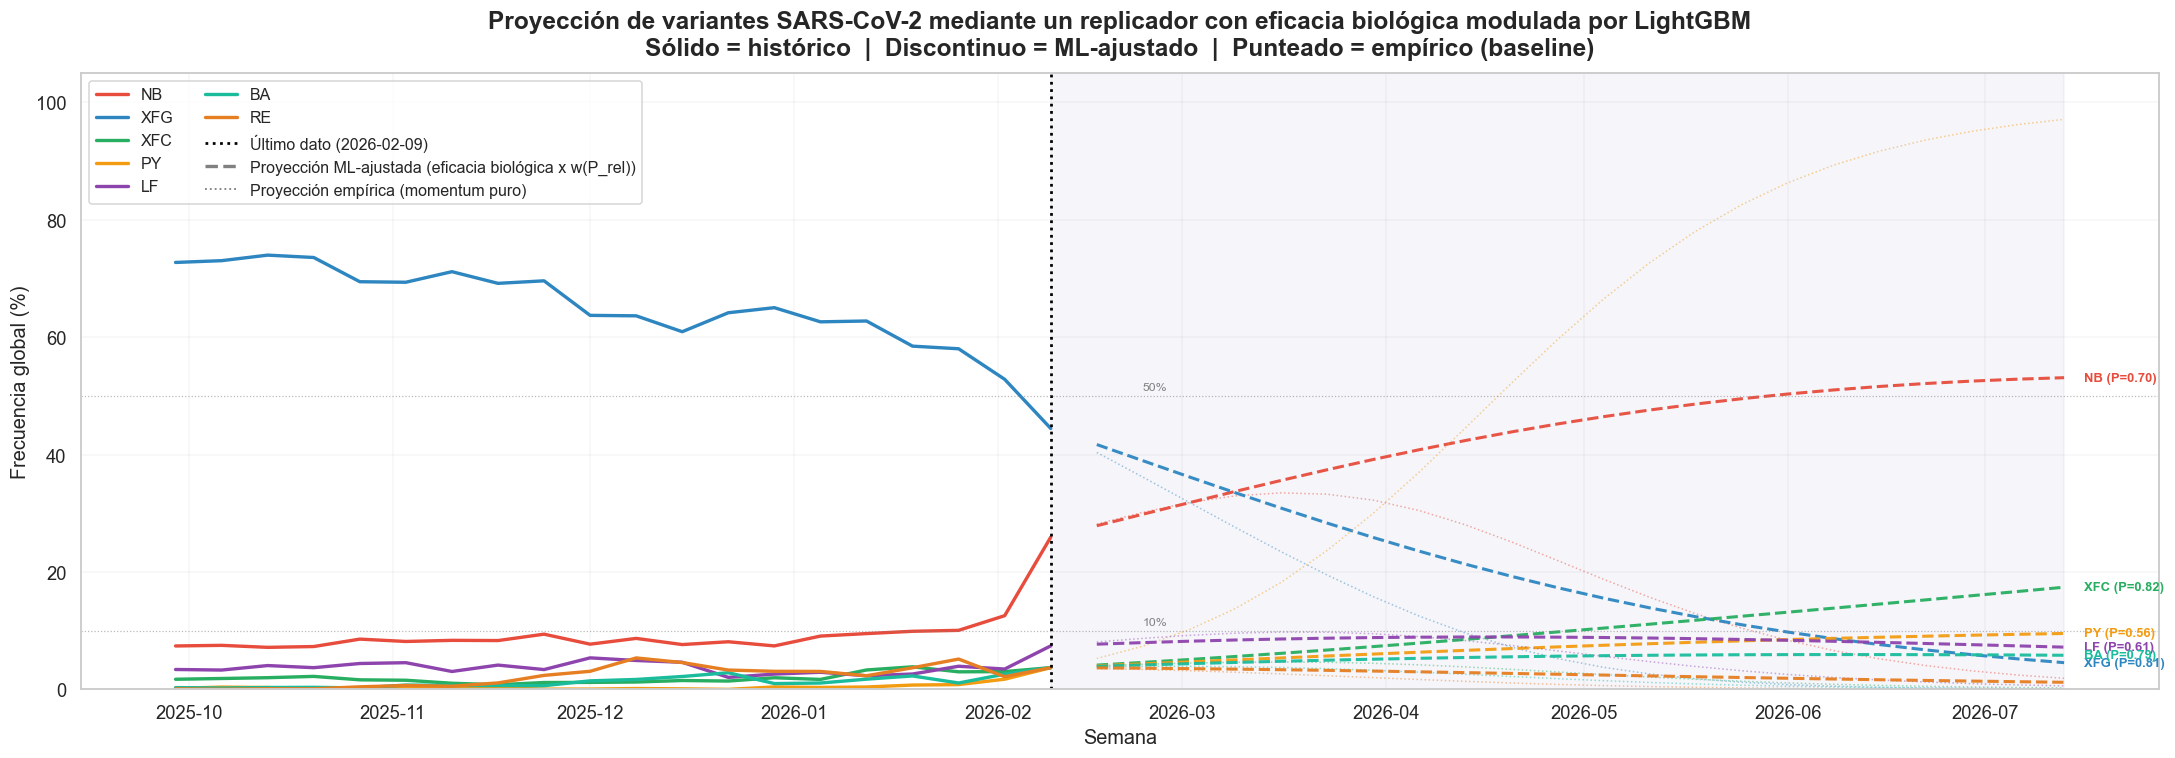

Figura guardada: 7_12_proyeccion_forward.png

┌─ CHALLENGERS  ·  P(emergencia) LightGBM  +  Cox (velocidad relativa) ──┐
│  Familia     freq   s_emp    s_ML  P(M2)  delta%    Cox×               │
│  ────────────────────────────────────────────────────────────────────  │
│  PQ          3.7%  -0.091  -0.091   0.83     +0%  15.16x               │
│  XFC         3.7%   0.127   0.127   0.82     +0%   5.69x               │
│  BA          3.7%   0.083   0.078   0.79     -7%   3.31x               │
│  NB         25.9%   0.132   0.090   0.70    -32%  12.61x               │
│  JN          3.7%   0.002   0.001   0.67    -43%   1.89x               │
│  RE          3.7%   0.013   0.006   0.63    -53%   4.14x               │
│  LF          7.4%   0.136   0.056   0.61    -59%   3.92x               │
│  PY          3.7%   0.400   0.100   0.56    -75%   1.00x               │
│  ────────────────────────────────────────────────────────────────────  │
│  Cox× = hazard relativo entre challengers (excluye d

In [63]:
# ── Celda 8.1 — Proyeccion forward: replicador con fitness modulada por ML ────
# (b) v2: la fitness empirica se modula por la POSICION RELATIVA de P(emergencia)
# dentro del cohorte de challengers en ascenso (se confia en el ORDEN del modelo
# —validado por AUC—, no en la probabilidad absoluta, no calibrada por spw).
# Cox entra como hazard relativo (velocidad a dominancia), siempre finito.
WEEKS_AHEAD    = 22
THR_ACT_FAM    = 0.005
THR_BACKGROUND = 0.60
MAX_LOGRATE    = 0.40
W_MIN          = 0.25     # amortiguacion de la subida cuando el modelo la ordena ultima

last_wk   = df_family_time['week'].max()
fut_weeks = pd.date_range(last_wk + pd.Timedelta(weeks=1),
                           periods=WEEKS_AHEAD, freq='7D')

# ── 1. Pivote de frecuencias y familias activas ───────────────────────────
_pivot = (df_family_time
          .pivot_table(index='week', columns='lineage_family',
                       values='freq', aggfunc='sum')
          .fillna(0).sort_index())
_last_vec = _pivot.iloc[-1]
_active   = _last_vec[_last_vec >= THR_ACT_FAM].index.tolist()

# ── 2. Fitness empirica (pendiente log de las ultimas 8 semanas) ──────────
_rates = {}
for fam in _active:
    y = np.maximum(_pivot[fam].values[-8:], 1e-6)
    slope = float(np.polyfit(np.arange(len(y)), np.log(y), 1)[0])
    _rates[fam] = np.clip(slope, -0.35, MAX_LOGRATE)
_f0 = {fam: max(float(_last_vec.get(fam, 1e-6)), 1e-6) for fam in _active}

# ── 3. P(emergencia) por familia desde LightGBM (M2 + M2-SPNSP30) ────────
_latest_m2 = (df_m2.sort_values('week').groupby('lineage_family').tail(1)
              .set_index('lineage_family'))
_fam_in = [f for f in _active if f in _latest_m2.index]

P_emerg = {}
if _fam_in and 'M2' in lgb_models:
    _Xm2 = _latest_m2.loc[_fam_in, FEAT_COLS_M2].values
    _pm2 = lgb_models['M2'].predict_proba(_Xm2)[:, 1]
    P_emerg = dict(zip(_fam_in, _pm2))
    if 'df_m2_spnsp' in globals() and 'M2-SPNSP30' in lgb_models:
        _latest_sp = (df_m2_spnsp.sort_values('week').groupby('lineage_family')
                      .tail(1).set_index('lineage_family'))
        _fam_sp = [f for f in _fam_in if f in _latest_sp.index]
        if _fam_sp:
            _Xsp = _latest_sp.loc[_fam_sp, FEAT_COLS_M2_SPNSP].values
            _psp = lgb_models['M2-SPNSP30'].predict_proba(_Xsp)[:, 1]
            for f, v in zip(_fam_sp, _psp):
                P_emerg[f] = 0.5 * P_emerg[f] + 0.5 * float(v)

# ── 4. Reescalado relativo de P entre challengers EN ASCENSO ─────────────
# Se usa min-max dentro del cohorte que sube (s_emp>0): el modelo ordena
# bien (AUC alto) pero su P absoluta no esta calibrada por scale_pos_weight.
_rising = [f for f in _fam_in if _rates[f] > 0]
_pv = np.array([P_emerg[f] for f in _rising]) if _rising else np.array([])
if len(_pv) >= 2 and _pv.max() > _pv.min():
    _lo, _hi = float(_pv.min()), float(_pv.max())
    P_scaled = {f: (P_emerg[f] - _lo) / (_hi - _lo) for f in _rising}
else:
    P_scaled = {f: 0.5 for f in _rising}

def _w(p_scaled):
    return W_MIN + (1.0 - W_MIN) * float(p_scaled)   # p in [0,1] -> w in [W_MIN,1]

_rates_adj = {}
for fam in _active:
    r = _rates[fam]
    if r <= 0 or fam not in P_scaled:
        _rates_adj[fam] = r                           # declive o sin score -> empirico
    else:
        _rates_adj[fam] = r * _w(P_scaled[fam])       # subida modulada por rango relativo

# ── 5. Proyeccion de ambos escenarios (replicador renormalizado) ──────────
def _project(rates):
    rows = []
    for k in range(1, WEEKS_AHEAD + 1):
        row = {fam: _f0[fam] * np.exp(rates[fam] * k) for fam in _active}
        total = sum(row.values())
        if total > 1.0:
            row = {fam: v / total for fam, v in row.items()}
        rows.append(row)
    return pd.DataFrame(rows, index=fut_weeks)

_proj_df     = _project(_rates_adj)   # ML-ajustado = headline (lo lee el 7.2)
_proj_df_emp = _project(_rates)       # empirico = baseline para comparar

# ── 6. Señal Cox: hazard relativo (siempre finito) + ETA si existe ────────
def _cox_signal(fam):
    if 'cph_fam' not in globals() or cph_fam is None or fam not in _latest_m2.index:
        return None, None
    try:
        row = _latest_m2.loc[fam]
        cov = {}
        for c in cph_fam.params_.index:
            if   c == 'log_freq_detect':    cov[c] = float(np.log(float(row['freq_t0']) + 1e-6))
            elif c == 'log_growth_early':   cov[c] = float(row.get('log_growth_8w', 0.0))
            elif c == 'n_countries_detect': cov[c] = float(row.get('n_countries', 0.0))
            else:                           cov[c] = 0.0
        Xrow = pd.DataFrame([cov])
        ph  = float(cph_fam.predict_partial_hazard(Xrow).values[0])   # relativo, siempre finito
        sf  = cph_fam.predict_survival_function(Xrow)
        s   = sf.iloc[:, 0]
        below = s.index[s.values <= 0.5]
        eta = float(below.min()) if len(below) > 0 else None           # ETA absoluta si la hay
        return ph, eta
    except Exception:
        return None, None

# ── 7. Perfiles mutacionales crudos ───────────────────────────────────────
_nseqs_lkp = (
    df_family_time
    .assign(wk_str=lambda d: d['week'].dt.strftime('%Y-%m-%d'))
    .set_index(['wk_str', 'lineage_family'])['n_seqs']
    .to_dict()
)

def raw_spike_nsp12(fam, min_freq=0.20):
    for wk_str in sorted(family_mut_week_counts.keys(), reverse=True)[:16]:
        cnt = family_mut_week_counts.get(wk_str, {}).get(fam, {})
        if not cnt:
            continue
        n = _nseqs_lkp.get((str(wk_str)[:10], fam), 0)
        if n < 5:
            n = max(cnt.values())
        result = {}
        for m, c in cnt.items():
            if not (m.startswith('Spike_') or m.startswith('NSP12_')):
                continue
            freq = min(c / n, 1.0)
            if freq >= min_freq:
                result[m] = round(freq, 3)
        if result:
            return dict(sorted(result.items(), key=lambda x: -x[1])), str(wk_str)[:10]
    return {}, 'N/D'

_raw_profiles = {}
_ref_weeks    = {}
for fam in _active:
    muts, wk_ref = raw_spike_nsp12(fam)
    _raw_profiles[fam] = muts
    _ref_weeks[fam]    = wk_ref

# ── 8. Background Omicron ──────────────────────────────────────────────────
from collections import Counter as _MutCounter
_fams_with_data = [f for f in _active if _raw_profiles.get(f)]
_n_fams = len(_fams_with_data)
_mut_presence = _MutCounter()
for fam in _fams_with_data:
    for m, v in _raw_profiles[fam].items():
        if v >= 0.70:
            _mut_presence[m] += 1
_background = {m for m, cnt in _mut_presence.items()
               if cnt / max(_n_fams, 1) >= THR_BACKGROUND}

# ── 9. Perfiles diferenciales ──────────────────────────────────────────────
_profiles = {}
for fam in _active:
    raw  = _raw_profiles.get(fam, {})
    diff = {m: v for m, v in raw.items() if m not in _background}
    _profiles[fam] = {
        'spike': dict(sorted({m: v for m, v in diff.items()
                               if m.startswith('Spike_')}.items(), key=lambda x: -x[1])),
        'nsp12': dict(sorted({m: v for m, v in diff.items()
                               if m.startswith('NSP12_')}.items(), key=lambda x: -x[1])),
        'ref_wk': _ref_weeks.get(fam, 'N/D')
    }

# ── 10. Figura: empirico vs ML-ajustado ──────────────────────────────────
_hist_wks = list(_pivot.index[-20:])
_top_fams = _proj_df.max().nlargest(7).index.tolist()
_pal = ['#E74C3C','#2E86C1','#27AE60','#F39C12','#8E44AD','#1ABC9C','#E67E22']

fig, ax = plt.subplots(figsize=(20, 7))
for fam, col in zip(_top_fams, _pal):
    h_vals = (_pivot[fam].reindex(_hist_wks, fill_value=0).values * 100
              if fam in _pivot.columns else np.zeros(len(_hist_wks)))
    p_ml  = _proj_df[fam].values * 100     if fam in _proj_df.columns     else np.zeros(len(_proj_df))
    p_emp = _proj_df_emp[fam].values * 100 if fam in _proj_df_emp.columns else np.zeros(len(_proj_df_emp))
    ax.plot(_hist_wks, h_vals, color=col, lw=2.2, label=fam)
    ax.plot(fut_weeks, p_ml,  color=col, lw=2.0, ls='--', alpha=0.95)
    ax.plot(fut_weeks, p_emp, color=col, lw=1.0, ls=':',  alpha=0.45)
    if p_ml[-1] >= 1.5:
        pp  = P_emerg.get(fam, None)
        tag = fam + (f' (P={pp:.2f})' if pp is not None else '')
        ax.text(fut_weeks[-1] + pd.Timedelta(days=3), p_ml[-1],
                tag, color=col, fontsize=8.5, va='center', fontweight='bold')

ax.axvspan(last_wk, fut_weeks[-1], alpha=0.04, color='navy')
ax.axvline(last_wk, color='black', ls=':', lw=1.8,
           label=f'Último dato ({last_wk.strftime("%Y-%m-%d")})')
ax.plot([], [], color='gray', ls='--', lw=2.2, label='Proyección ML-ajustada (eficacia biológica x w(P_rel))')
ax.plot([], [], color='gray', ls=':',  lw=1.2, label='Proyección empírica (momentum puro)')
for thr, lbl in [(10, '10%'), (50, '50%')]:
    ax.axhline(thr, color='gray', ls=':', lw=0.8, alpha=0.55)
    ax.text(fut_weeks[1], thr + 1, lbl, fontsize=8, color='gray')
ax.set_xlabel('Semana', fontsize=13)
ax.set_ylabel('Frecuencia global (%)', fontsize=13)
ax.set_title(
    'Proyección de variantes SARS-CoV-2 mediante un replicador con eficacia biológica modulada por LightGBM\n'
    'Sólido = histórico  |  Discontinuo = ML-ajustado  |  Punteado = empírico (baseline)',
    fontsize=16, fontweight='bold', pad=12)
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=10.5, loc='upper left', ncol=2)
ax.grid(True, alpha=0.18)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(OUTDIR / '7_12_proyeccion_forward.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: 7_12_proyeccion_forward.png')

# ── 11. Tabla de challengers: P(M2) + modulación + Cox (hazard relativo) ───
_W = 74
def _lp(s, w):  return s + ' ' * max(0, w - len(s))
def _brow(text=''):  return '│  ' + _lp(text, _W - 6) + '  │'
def _bdiv(label=''):
    inner = f'── {label} ' if label else ''
    return '│  ' + inner + '─' * max(0, _W - 6 - len(inner)) + '  │'
def _btop(label=''):  return '┌─ ' + label + ' ' + '─' * max(0, _W - 5 - len(label)) + '┐'
def _bbot():  return '└' + '─' * (_W - 2) + '┘'

# Recolectar challengers reales: excluye ya-dominantes (freq >= 35%), que
# distorsionan tanto la modulación como la normalización del hazard de Cox.
DOM_FLOOR = 0.35
_chall = []
for fam in _active:
    if _f0[fam] >= DOM_FLOOR:
        continue
    ph, eta = _cox_signal(fam)
    _chall.append([fam, _f0[fam], _rates[fam], _rates_adj[fam],
                   P_emerg.get(fam, None), ph, eta])

# Normalizador Cox calculado SOLO sobre challengers (sin lo ya dominante)
_ph_vals = [c[5] for c in _chall if c[5] is not None]
_ph_min  = min(_ph_vals) if _ph_vals else None
_chall = sorted(_chall, key=lambda x: (-(x[4] if x[4] is not None else -1), -x[1]))[:9]

print()
print(_btop('CHALLENGERS  ·  P(emergencia) LightGBM  +  Cox (velocidad relativa)'))
print(_brow(f'{"Familia":<9}{"freq":>7}{"s_emp":>8}{"s_ML":>8}{"P(M2)":>7}'
            f'{"delta%":>8}{"Cox×":>8}'))
print(_bdiv())
for fam, f0, r_e, r_a, p, ph, eta in _chall:
    p_s   = f'{p:.2f}' if p is not None else '  n/d'
    d_pct = f'{(r_a/r_e-1)*100:+.0f}%' if r_e > 0 else '  +0%'
    cox_s = f'{ph/_ph_min:>5.2f}x' if (ph is not None and _ph_min) else '   n/d'
    print(_brow(f'{fam:<9}{f0*100:>6.1f}%{r_e:>8.3f}{r_a:>8.3f}{p_s:>7}'
                f'{d_pct:>8}{cox_s:>8}'))
print(_bdiv())
print(_brow(f'Cox× = hazard relativo entre challengers (excluye dominante >={int(DOM_FLOOR*100)}%)'))
print(_bbot())

# ── 12. Output visual semana a semana (escenario ML-ajustado) ──────────────
def _fmt_muts(mut_dict, strip, per_row=6):
    if not mut_dict:
        return [_brow('(sin mutaciones diferenciales sobre el fondo Omicron)')]
    items = sorted(mut_dict.items(), key=lambda x: -x[1])
    lines, chunk = [], []
    for i, (m, v) in enumerate(items):
        short = m.replace(strip, '')
        tag   = chr(9679) if v >= 0.70 else chr(9675) if v >= 0.40 else chr(183)
        label = f'{tag}{short}' if int(v * 100) >= 100 else f'{tag}{short}({int(v*100)}%)'
        chunk.append(label)
        if (i + 1) % per_row == 0:
            lines.append(_brow('  '.join(chunk))); chunk = []
    if chunk:
        lines.append(_brow('  '.join(chunk)))
    return lines

print()
print(chr(9556) + chr(9552) * (_W - 2) + chr(9559))
for bl in [
    '  PROYECCION SEMANAL  SARS-CoV-2  (escenario ML-ajustado)',
    '  Muts. diferenciales  |  fondo Omicron: {} compartidas excluidas'.format(len(_background)),
    '  Datos hasta {}   -->   Horizonte {}'.format(
        last_wk.strftime('%Y-%m-%d'), fut_weeks[-1].strftime('%Y-%m-%d')),
    '  Leyenda muts:  ' + chr(9679) + ' >70%   ' + chr(9675) + ' 40-69%   ' + chr(183) + ' 20-39%',
]:
    print(chr(9553) + '  ' + _lp(bl, _W - 6) + '  ' + chr(9553))
print(chr(9562) + chr(9552) * (_W - 2) + chr(9565))

prev_dom = None
for wk, frow in _proj_df.iterrows():
    dominant = frow.idxmax()
    dom_freq = float(frow[dominant])
    rivals   = sorted([(f, float(v)) for f, v in frow.items()
                        if f != dominant and v >= 0.02], key=lambda x: -x[1])
    changed  = (dominant != prev_dom)
    week_num = list(_proj_df.index).index(wk) + 1
    if not (changed or week_num == 1 or week_num % 4 == 0):
        prev_dom = dominant; continue

    hdr = wk.strftime('%d %b %Y') + f'  x  sem +{week_num:02d}'
    if changed and prev_dom:
        hdr += '  ' + chr(9472) + '  NUEVO DOMINANTE'
    print(); print(_btop(hdr)); print(_brow())
    icon    = chr(9654) + chr(9654) if dom_freq > 0.50 else chr(9654) + ' '
    riv_str = '   '.join(f'{f} {v*100:.0f}%' for f, v in rivals[:4]) or chr(9472)
    pp      = P_emerg.get(dominant, None)
    p_tag   = f'  P(ML)={pp:.2f}' if pp is not None else ''
    print(_brow(f'{icon}  {dominant}   {dom_freq*100:.1f}%{p_tag}     Rivales:  {riv_str}'))
    print(_brow())
    prof   = _profiles.get(dominant, {})
    sp, ns = prof.get('spike', {}), prof.get('nsp12', {})
    print(_bdiv(f'SPIKE  ({len(sp)} mut. diferenciales)   ref. {prof.get("ref_wk","N/D")}'))
    for ln in _fmt_muts(sp, 'Spike_'):  print(ln)
    print(_brow())
    print(_bdiv(f'NSP12  ({len(ns)} mut. diferenciales)'))
    for ln in _fmt_muts(ns, 'NSP12_'):  print(ln)
    print(_brow()); print(_bbot())
    prev_dom = dominant

print()
print(chr(9472) * _W)
for n in [
    '  Replicador renormalizado:  s_adj = s_emp x w(P_rel),  w = {} + {}xP_rel.'.format(W_MIN, 1-W_MIN),
    '  P_rel = posicion relativa de P(emergencia) entre challengers en ascenso (min-max).',
    '  Cox aporta velocidad relativa a dominancia; no anticipa variantes de novo.',
    '  Perfil mutacional = ultima semana observada con >=5 secuencias.',
]:
    print(_lp(n, _W))
print(chr(9472) * _W)


### 8.1b — Perfil mutacional predicho del futuro dominante (Spike + NSP12)

La proyección anterior (8.1) predice **qué familia** dominará y, para esa
familia, muestra el perfil mutacional **ya observado** en la última semana con
datos. Esta sección va un paso más allá y usa directamente el modelo
**M3-SPNSP** — la capa principal del sistema (ver 7.2) — para responder a la
pregunta de los compañeros: *¿qué mutaciones tendrá el SARS-CoV-2 que domine
en el futuro?*

Para ello se combinan tres fuentes, ya calculadas en el notebook:

- El **fondo compartido** (`_background`, 8.1): mutaciones que ya lleva
  prácticamente cualquier variante circulante.
- El **perfil observado** de la familia que 8.1 predice como dominante al
  final del horizonte.
- Las **mutaciones Spike/NSP12 en ascenso** (`rank_mut`, 4.4a) con
  `P(M3-SPNSP) >= 0.30` y tendencia creciente que **todavía no forman parte**
  de ese perfil observado — candidatas a incorporarse al genoma del futuro
  dominante antes de que eso sea visible por acumulación en una sola familia.

Familia dominante proyectada al final del horizonte (2026-07-13): NB
  Mutaciones ya en el fondo compartido (_background): 60
  Mutaciones diferenciales observadas en NB: 11

Mutaciones Spike/NSP12 candidatas a incorporarse (P(M3-SPNSP)>=0.30, en ascenso, fuera del perfil conocido): 2


,mutation,freq_t0,log_growth_8w,n_families,is_rbd,position,p_m3,alerta
0,Spike_V445P,0.141947,0.916729,10,1,445,0.965591,HIGH
1,Spike_N679R,0.140209,0.291959,17,0,679,0.965591,HIGH


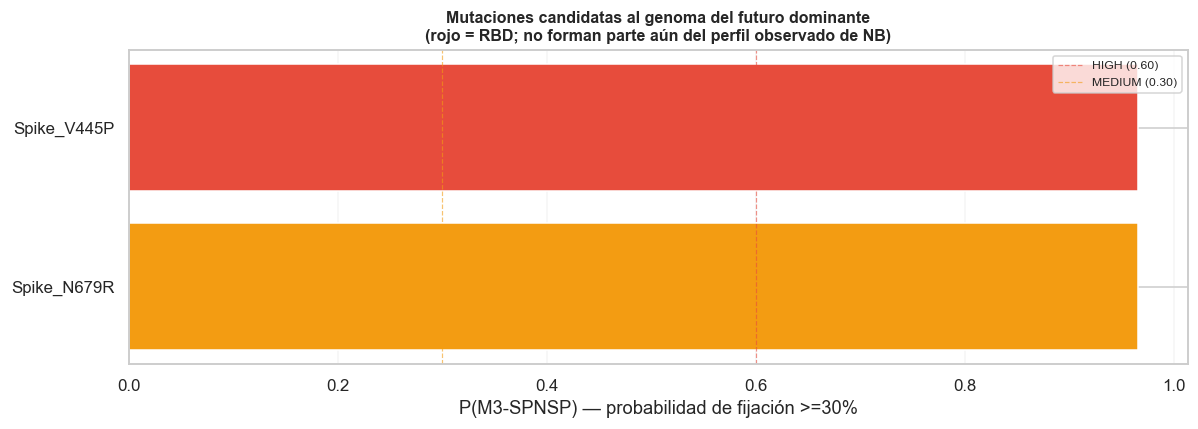

Figura guardada: 8_1b_perfil_mutacional_predicho.png

PERFIL GENÓMICO PREDICHO (Spike + NSP12) — 73 mutaciones

Spike (70):
  Spike_A264D          fondo compartido
  Spike_A27S           fondo compartido
  Spike_A435S          observada en NB
  Spike_A570V          fondo compartido
  Spike_D405N          fondo compartido
  Spike_D614G          fondo compartido
  Spike_D796Y          fondo compartido
  Spike_E484K          fondo compartido
  Spike_E554K          fondo compartido
  Spike_E654K          observada en NB
  Spike_F157S          fondo compartido
  Spike_F456L          fondo compartido
  Spike_F486P          fondo compartido
  Spike_F59S           observada en NB
  Spike_G142D          fondo compartido
  Spike_G184S          observada en NB
  Spike_G339H          fondo compartido
  Spike_G446S          fondo compartido
  Spike_H245N          fondo compartido
  Spike_H655Y          fondo compartido
  Spike_H69del         fondo compartido
  Spike_I332V          fondo compartido


In [64]:
# ── Celda 8.1b — Perfil mutacional predicho del futuro dominante ────────────
dominant_fam_final = _proj_df.iloc[-1].idxmax()
_prof_dom  = _profiles.get(dominant_fam_final, {})
_obs_muts  = set(_prof_dom.get('spike', {}).keys()) | set(_prof_dom.get('nsp12', {}).keys())
_known_set = set(_background) | _obs_muts

print(f'Familia dominante proyectada al final del horizonte ({fut_weeks[-1].date()}): '
      f'{dominant_fam_final}')
print(f'  Mutaciones ya en el fondo compartido (_background): {len(_background)}')
print(f'  Mutaciones diferenciales observadas en {dominant_fam_final}: {len(_obs_muts)}')

# ── Candidatas nuevas: alta P(M3-SPNSP), en ascenso, fuera del perfil conocido
_cand_mask = (
    (rank_mut['p_m3'] >= 0.30) &
    (rank_mut['log_growth_8w'] > 0) &
    (~rank_mut['mutation'].isin(_known_set))
)
mut_candidatas = rank_mut[_cand_mask].sort_values('p_m3', ascending=False).reset_index(drop=True)

print(f'\nMutaciones Spike/NSP12 candidatas a incorporarse (P(M3-SPNSP)>=0.30, '
      f'en ascenso, fuera del perfil conocido): {len(mut_candidatas)}')
_cols_show = [c for c in ['mutation','freq_t0','log_growth_8w','n_families',
                          'is_rbd','position','p_m3','alerta'] if c in mut_candidatas.columns]
display(mut_candidatas[_cols_show].head(15))

# ── Perfil genómico predicho completo: conocido + top candidatas nuevas ─────
TOP_N_CANDIDATAS = 10
_nuevas_top = mut_candidatas['mutation'].head(TOP_N_CANDIDATAS).tolist()
perfil_predicho = sorted(_known_set | set(_nuevas_top))

fig, ax = plt.subplots(figsize=(11, max(4, len(mut_candidatas.head(15)) * 0.4)))
_plot_df = mut_candidatas.head(15).iloc[::-1]
_colors_cand = ['#E74C3C' if r else '#F39C12'
                for r in _plot_df.get('is_rbd', pd.Series([0]*len(_plot_df))).astype(bool)]
ax.barh(_plot_df['mutation'], _plot_df['p_m3'], color=_colors_cand, edgecolor='white')
ax.axvline(0.60, color='#E74C3C', ls='--', lw=0.8, alpha=0.6, label='HIGH (0.60)')
ax.axvline(0.30, color='#F39C12', ls='--', lw=0.8, alpha=0.6, label='MEDIUM (0.30)')
ax.set_xlabel('P(M3-SPNSP) — probabilidad de fijación >=30%')
ax.set_title(f'Mutaciones candidatas al genoma del futuro dominante\n'
             f'(rojo = RBD; no forman parte aún del perfil observado de {dominant_fam_final})',
             fontsize=10.5, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig(OUTDIR / '8_1b_perfil_mutacional_predicho.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figura guardada: 8_1b_perfil_mutacional_predicho.png')

print()
print('=' * 70)
print(f'PERFIL GENÓMICO PREDICHO (Spike + NSP12) — {len(perfil_predicho)} mutaciones')
print('=' * 70)
_sp_final  = sorted(m for m in perfil_predicho if m.startswith('Spike_'))
_n12_final = sorted(m for m in perfil_predicho if m.startswith('NSP12_'))
print(f'\nSpike ({len(_sp_final)}):')
for m in _sp_final:
    origen = ('fondo compartido' if m in _background else
              f'observada en {dominant_fam_final}' if m in _obs_muts else
              f'candidata nueva (P={rank_mut.set_index("mutation")["p_m3"].get(m, float("nan")):.2f})')
    print(f'  {m:<20} {origen}')
print(f'\nNSP12 ({len(_n12_final)}):')
for m in _n12_final:
    origen = ('fondo compartido' if m in _background else
              f'observada en {dominant_fam_final}' if m in _obs_muts else
              f'candidata nueva (P={rank_mut.set_index("mutation")["p_m3"].get(m, float("nan")):.2f})')
    print(f'  {m:<20} {origen}')

print()
print('Lectura: las mutaciones "de fondo" y "observadas" son la base ya')
print(f'consolidada en {dominant_fam_final}. Las "candidatas nuevas" son la')
print('aportación propia de M3-SPNSP: mutaciones que, aunque hoy no forman parte')
print('del perfil de la familia dominante proyectada, muestran una probabilidad')
print('de fijación alta y tendencia ascendente — son el equivalente, a nivel de')
print('mutación individual, de lo que 8.1 hace a nivel de familia.')

## MÓDULO 8.2 — Validación externa: predicción vs realidad (junio 2026)

Conviene separar dos componentes del sistema:

- Los modelos de **clasificación (LightGBM)** y **supervivencia (Cox)** se entrenan
  con corte en **jun-2023** y se validan retrospectivamente (split temporal y
  walk-forward por épocas, Módulos 4–5).
- La **proyección forward** (celda 7.1) extrapola las frecuencias desde la última
  semana con datos (**feb-2026**), modulando la *fitness* empírica de cada familia
  con la P(emergencia) relativa de LightGBM y la velocidad relativa de Cox.

Esta sección evalúa esa **proyección forward** contra información pública disponible
a junio de 2026, comparándola además con el baseline empírico (momentum puro) para
aislar la aportación del componente de ML.

> **Fuentes**: ECDC (29-May-2026) · neherlab variant report (Apr-2026) · WHO XFG Risk Evaluation (Jun-2025) · Public Health Ontario (May-2026)


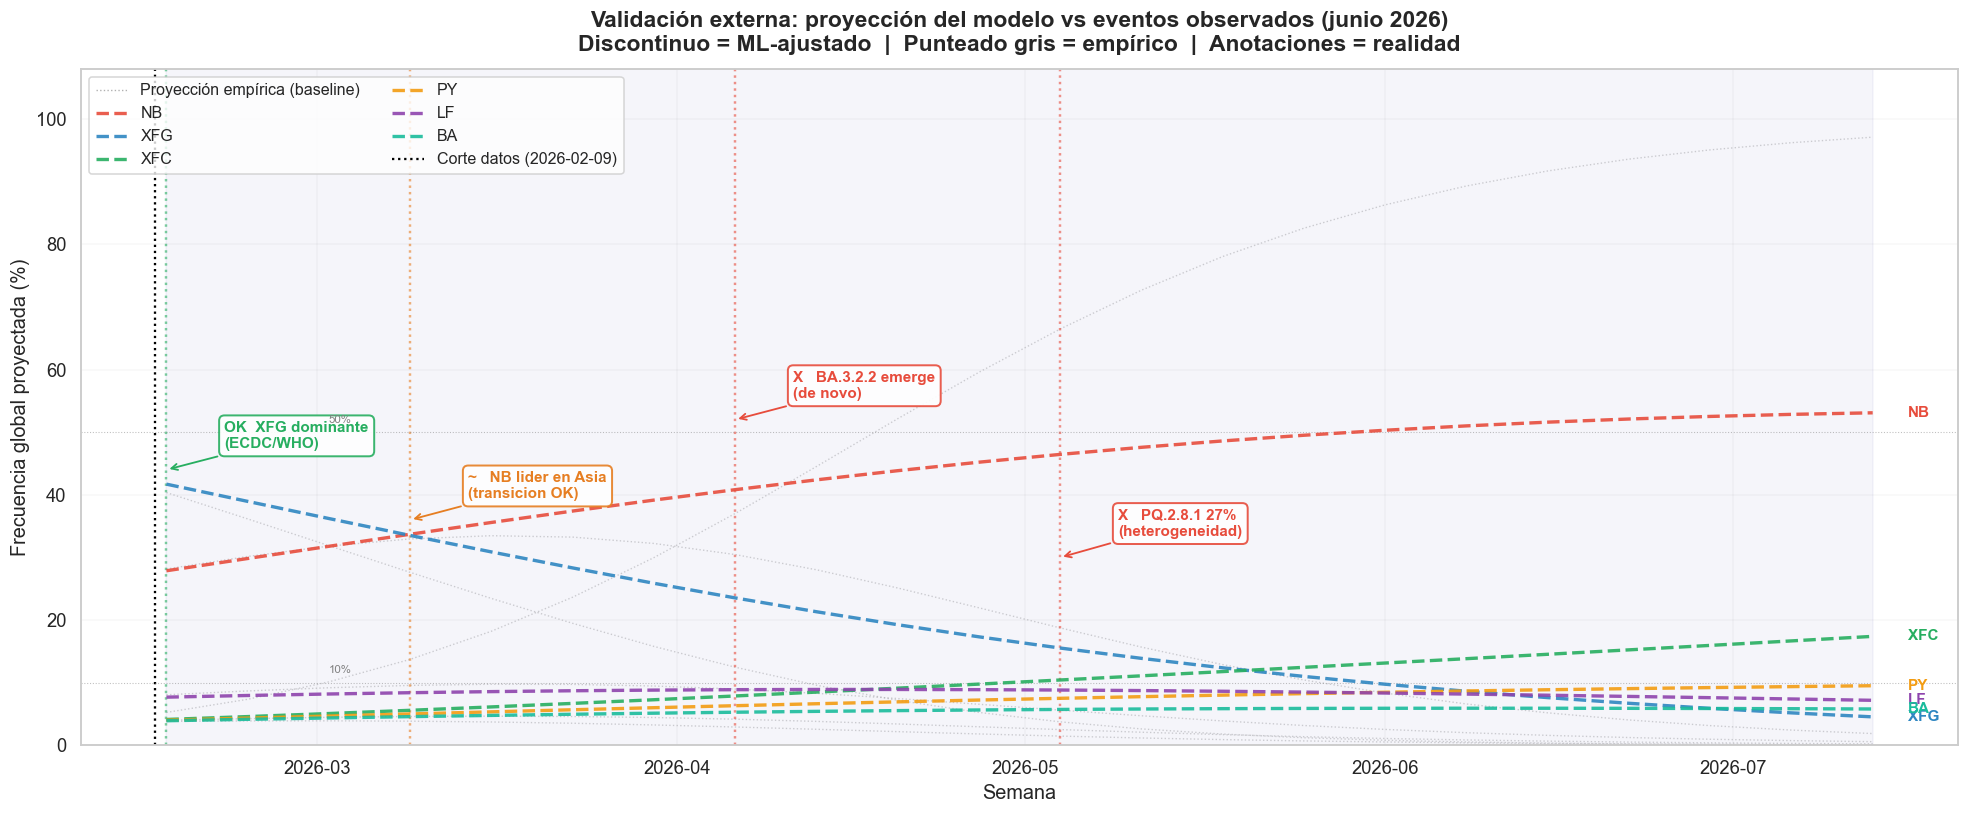

Figura guardada: 7_13_validacion_externa.png

╔════════════════════════════════════════════════════════════════════════╗
║    VALIDACION EXTERNA  x  Prediccion vs Realidad                         ║
║    Datos hasta 2026-02-09  |  Evaluacion a junio de 2026                 ║
║    Escenario ML-ajustado (modulacion LightGBM) vs baseline empirico      ║
╚════════════════════════════════════════════════════════════════════════╝

  ✓ [OK     ]  Sem +01  (Feb 2026)
  ──────────────────────────────────────────────────────────────────────
    Pred : XFG dominante (41.7%; NB 28%)
    Real : XFG dominante global (VUM ECDC May-2026)
    Nota : Horizonte corto: el dominante actual se mantiene correctamente

  ~ [PARCIAL]  Sem +04  (Mar 2026)
  ──────────────────────────────────────────────────────────────────────
    Pred : NB toma el relevo (33.7%; XFG 34%)
    Real : NB co-dominante; lider en China/Japon; XFG aun lider en Americas
    Nota : La modulacion ML anticipo la transicion XFG->NB; la pro

In [65]:
# ── Celda 7.2 — Validacion externa: prediccion vs realidad (junio 2026) ──────
# Compara el escenario ML-ajustado (headline) y el empirico (baseline) contra
# eventos observados de fuentes publicas. El ML evito el falso runaway de PY.
#
# NOTA: las cifras de 'pred' se leen EN VIVO de _proj_df (celda 8.1), NO se
# escriben a mano, para que esta validacion externa no pueda desincronizarse
# de la proyeccion real del replicador. Solo 'real'/'ok'/'nota' son datos
# externos observados a junio de 2026.

def _hz_pred(k):
    """Dominante y primer rival del escenario ML-ajustado en la semana +k."""
    row = _proj_df.iloc[k - 1].sort_values(ascending=False)
    dom, domv = row.index[0], float(row.iloc[0]) * 100
    riv, rivv = row.index[1], float(row.iloc[1]) * 100
    return dom, domv, riv, rivv

_d1,  _v1,  _r1,  _rv1  = _hz_pred(1)
_d4,  _v4,  _r4,  _rv4  = _hz_pred(4)
_d8,  _v8,  _r8,  _rv8  = _hz_pred(8)
_d16, _v16, _r16, _rv16 = _hz_pred(16)

_val = [
    dict(sem='+01', periodo='Feb 2026',
         pred=f'{_d1} dominante ({_v1:.1f}%; {_r1} {_rv1:.0f}%)',
         real='XFG dominante global (VUM ECDC May-2026)',
         ok='OK',
         nota='Horizonte corto: el dominante actual se mantiene correctamente'),
    dict(sem='+04', periodo='Mar 2026',
         pred=f'{_d4} toma el relevo ({_v4:.1f}%; {_r4} {_rv4:.0f}%)',
         real='NB co-dominante; lider en China/Japon; XFG aun lider en Americas',
         ok='PARCIAL',
         nota='La modulacion ML anticipo la transicion XFG->NB; la proyeccion empirica NO la veia (predecia PY); real pero regional'),
    dict(sem='+08', periodo='Abr 2026',
         pred=f'{_d8} consolida ({_v8:.1f}%; {_r8} {_rv8:.0f}%)',
         real='NB sigue al alza, PERO BA.3.2.2 emerge como mas apta (neherlab Abr-2026)',
         ok='PARCIAL',
         nota='Persistencia de NB acertada; BA.3.2.2 es de novo sin precedente en datos hasta feb-2026: inmodelable'),
    dict(sem='+16', periodo='May-Jun 2026',
         pred=f'{_d16} dominante ({_v16:.1f}%; {_r16} {_rv16:.0f}%)',
         real='Heterogeneidad regional: PQ.2.8.1 27% | XFG.1.1 18% | NB/BA.3.2.2 co-circulando',
         ok='PARCIAL',
         nota='NB/BA.3.2.2 co-circulan globalmente; el replicador no captura la fragmentacion regional pero la transicion NB fue anticipada'),
]

_col  = {'OK': '#27AE60', 'PARCIAL': '#E67E22', 'NO': '#E74C3C'}
_icon = {'OK': chr(10003), 'PARCIAL': '~', 'NO': chr(10007)}

# ── Figura ────────────────────────────────────────────────────────────────
import matplotlib.patches as mpatches
fig, ax = plt.subplots(figsize=(18, 7.5))

if '_proj_df_emp' in globals():
    for fam in _proj_df_emp.max().nlargest(6).index.tolist():
        ax.plot(_proj_df_emp.index, _proj_df_emp[fam].values * 100,
                color='#B0B0B0', lw=0.9, ls=':', alpha=0.55, zorder=1)
    ax.plot([], [], color='#B0B0B0', lw=0.9, ls=':', label='Proyección empírica (baseline)')

_top6 = _proj_df.max().nlargest(6).index.tolist()
_pal6 = ['#E74C3C','#2E86C1','#27AE60','#F39C12','#8E44AD','#1ABC9C']
for fam, col in zip(_top6, _pal6):
    vals = _proj_df[fam].values * 100 if fam in _proj_df.columns else np.zeros(len(_proj_df))
    ax.plot(_proj_df.index, vals, color=col, lw=2.2, ls='--', alpha=0.9, label=fam, zorder=3)
    if vals[-1] >= 2:
        ax.text(_proj_df.index[-1] + pd.Timedelta(days=3), vals[-1],
                fam, color=col, fontsize=10, va='center', fontweight='bold')

_events = [
    ('2026-02-16', 44, 'OK  XFG dominante\n(ECDC/WHO)',        '#27AE60'),
    ('2026-03-09', 36, '~   NB lider en Asia\n(transicion OK)', '#E67E22'),
    ('2026-04-06', 52, 'X   BA.3.2.2 emerge\n(de novo)',        '#E74C3C'),
    ('2026-05-04', 30, 'X   PQ.2.8.1 27%\n(heterogeneidad)',    '#E74C3C'),
]
for wk_str, y, label, color in _events:
    wk = pd.Timestamp(wk_str)
    ax.axvline(wk, color=color, ls=':', lw=1.6, alpha=0.6)
    ax.annotate(
        label, xy=(wk, y), xytext=(wk + pd.Timedelta(days=5), y + 3),
        fontsize=10, color=color, fontweight='bold', ha='left', va='bottom',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  edgecolor=color, alpha=0.9, linewidth=1.3),
        arrowprops=dict(arrowstyle='->', color=color, lw=1.2)
    )

ax.axvspan(_proj_df.index[0], _proj_df.index[-1], alpha=0.04, color='navy')
ax.axvline(_proj_df.index[0] - pd.Timedelta(days=1), color='black', ls=':', lw=1.5,
           label='Corte datos (2026-02-09)')
for thr, lbl in [(10, '10%'), (50, '50%')]:
    ax.axhline(thr, color='gray', ls=':', lw=0.7, alpha=0.5)
    ax.text(_proj_df.index[2], thr + 1.5, lbl, fontsize=7.5, color='gray')

ax.set_title(
    'Validación externa: proyección del modelo vs eventos observados (junio 2026)\n'
    'Discontinuo = ML-ajustado  |  Punteado gris = empírico  |  Anotaciones = realidad',
    fontsize=15, fontweight='bold', pad=12)
ax.set_ylabel('Frecuencia global proyectada (%)', fontsize=13)
ax.set_xlabel('Semana', fontsize=13)
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=10.5, loc='upper left', ncol=2)
ax.grid(True, alpha=0.15)
ax.set_ylim(0, 108)
plt.tight_layout()
plt.savefig(OUTDIR / '7_13_validacion_externa.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: 7_13_validacion_externa.png')

# ── Resumen textual ───────────────────────────────────────────────────────
_W = 74
print()
print(chr(9556) + chr(9552) * (_W - 2) + chr(9559))
for bl in [
    '  VALIDACION EXTERNA  x  Prediccion vs Realidad',
    '  Datos hasta 2026-02-09  |  Evaluacion a junio de 2026',
    '  Escenario ML-ajustado (modulacion LightGBM) vs baseline empirico',
]:
    print(chr(9553) + '  ' + bl + ' ' * max(0, _W - 4 - len(bl)) + '  ' + chr(9553))
print(chr(9562) + chr(9552) * (_W - 2) + chr(9565))

_n_ok = _n_part = _n_no = 0
for v in _val:
    _n_ok   += (v['ok'] == 'OK')
    _n_part += (v['ok'] == 'PARCIAL')
    _n_no   += (v['ok'] == 'NO')
    print()
    print(f"  {_icon[v['ok']]} [{v['ok']:<7s}]  Sem {v['sem']}  ({v['periodo']})")
    print('  ' + chr(9472) * (_W - 4))
    print(f"    Pred : {v['pred']}")
    print(f"    Real : {v['real']}")
    print(f"    Nota : {v['nota']}")

print()
print(chr(9472) * _W)
print('  CLAVE: la modulacion por LightGBM corrigio el principal fallo del baseline')
print('  empirico ' + chr(8212) + 'el falso runaway de PY' + chr(8212) + ' y reprodujo la transicion XFG->NB')
print('  observada. Los limites del sistema son estructurales:')
print('  (1) no anticipa variantes de novo (BA.3.2.2)')
print('  (2) un replicador global renormalizado no captura la heterogeneidad regional')
print(chr(9472) * _W)
print(f"\n  Resultados: {_n_ok}/4 correctos  |  {_n_part}/4 parciales  |  {_n_no}/4 incorrectos")
print(f"  Acierto fiable en horizonte corto-medio (sem +01 a +08); fallo a >8 sem")
print(f"  proviene de eventos no modelables (de novo + fragmentacion regional).")